# Fed-ResViT on HAM10000 — Research Implementation

> **Designed for Google Colab.** The notebook uses persistent storage for experiment artifacts and round-boundary recovery.

This notebook implements the current Fed-ResViT experimental protocol for HAM10000. The executable configuration is the source of truth; the summary below describes the active research design.

| Component | Current protocol |
|---|---|
| Architecture | ResNet-50 + ViT-small (`vit_small_patch16_224`), feature fusion, 7-class head |
| Federated learning | 10 clients, 30 rounds, 2 local epochs, batch size 16, Dirichlet α=0.5 and stratified-balanced partitions |
| Optimisation | AdamW recipe used by the active research profile, with the configured partial fine-tuning, augmentation and round schedule |
| Attack | Targeted label flipping: MEL/BCC/AKIEC → NV; `FLIP_PROB=1.0` on selected malicious clients |
| Aggregators | FedAvg, Krum, coordinate-wise trimmed mean, coordinate-wise median, Trust-aware aggregation |
| Main matrix | 2 partitions × 5 seeds (42–46) × 4 malicious fractions (0/10/20/30%) × 5 aggregators = 200 runs |
| Adaptive stage | 25 runs: 5 aggregators × 5 seeds, Dirichlet α=0.5, 20% malicious |
| Sensitivity stage | 45 configured Trust runs: 9 settings × 5 seeds; 5 unchanged defaults reuse matching main runs, leaving 40 additional runs |
| Evaluation | Accuracy, macro precision/recall/F1/specificity, malignant binary recall, subtype recall, ASR and Trust detection metrics where applicable |

The final research results must use completed, validated artifacts only. Pilot/recovery checks are validation evidence and are not pooled into the main study.

## Running in Colab

1. Upload this notebook and select the GPU runtime you intend to use.
2. Mount persistent Google Drive storage when prompted.
3. Run the notebook from the setup cells onward in order.
4. Review the displayed study plan before enabling long-running training.
5. If a session ends, recreate the runtime, mount the same storage, and rerun the setup cells. Completed runs are reused after artifact verification; incomplete runs resume from their saved round boundary.

The study root is configured under `MyDrive/FedResViT_Mentor_v2_G4/study`. A stage may be split across sessions using `JOB_START`/`JOB_STOP`.


## Execution contract

Run cells in order. Persistent storage is required for experiment artifacts and recovery. A run is identified by its revision, research-code hash, configuration, pipeline and dataset manifest.

Completed experiments are immutable: their completion marker and artifact checksums are verified before reuse. Incomplete experiments require the recorded execution environment to match so that continuation is not silently mixed with a different runtime.

Recovery is committed at round boundaries. If a session ends during a round, the unfinished round is replayed from the latest valid completed-round state. Two checksum-verified recovery generations protect incomplete runs.


## 1. Colab setup — Kaggle credentials & persistent storage

The setup cell mounts persistent storage and creates the experiment root. Do not place credentials directly in saved notebook cells.


In [4]:
import os, sys
from pathlib import Path
from importlib.util import find_spec
IN_COLAB = find_spec('google.colab') is not None if find_spec('google') is not None else False
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')  # do not continue if this fails
    if not Path('/content/drive/MyDrive').is_dir():
        raise RuntimeError('Persistent Google Drive mount is required')
    OUTPUT_DIR = '/content/drive/MyDrive/FedResViT_G4_Pass'
else:
    OUTPUT_DIR = os.environ.get('FEDRESVIT_OUTPUT_ROOT', './FedResViT_Mentor_v2')
    print('Verify this output root is persistent before training:', OUTPUT_DIR)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
DRIVE_OUTPUT_DIR = None  # all artifacts are already written directly to OUTPUT_DIR
print('Persistent experiment root:', OUTPUT_DIR)
# Configure Kaggle through its supported login/secret mechanism if the download
# requires authentication. Never paste credentials into a saved notebook cell.

Mounted at /content/drive
Persistent experiment root: /content/drive/MyDrive/FedResViT_G4_Pass


## 2. Install dependencies

Install only the auxiliary libraries required by the research notebook. The runtime environment is recorded automatically for each experiment.


In [ ]:
# Auxiliary research dependencies. The runtime provides the PyTorch/torchvision stack.
%pip install kagglehub==0.3.13 timm==1.0.19 scikit-learn==1.6.1 scipy==1.15.3 matplotlib==3.10.3 pillow==11.2.1


## 3. Imports and global configuration

This section imports the runtime modules first, then defines the active model/training profile and study controls. Run it after Section 2 dependency installation.


In [ ]:
# Imports required by the active configuration and all downstream sections.
import os, sys, json, hashlib, random, copy, time, platform, inspect, warnings, math
from pathlib import Path
from collections import defaultdict
from importlib.metadata import version, PackageNotFoundError
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
from torchvision.models import resnet50, ResNet50_Weights
import timm
import sklearn
import kagglehub
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader


HAS_STRATIFIED_GROUP_KFOLD = True


# ---------------------------------------------------------------------
# Active research profile
# ---------------------------------------------------------------------
# The study-control block below sets the final experiment matrix. This profile
# supplies the active model/training recipe used by the current study.
EXPERIMENT_PROFILE = "target90_v4_multirun"

BASE_CONFIG = {
    # ---- Dataset (Sec 5.1) ------------------------------------------
    "DATASET_REF": "kmader/skin-cancer-mnist-ham10000",
    "IMG_SIZE": 224,                       # Sec 5.2
    "TEST_SIZE": 0.15,                     # Sec 5.2: 70:15:15 split
    "VAL_SIZE": 0.15,
    "SPLIT_SEED": 42,

    # ---- Federated learning (Sec 5.3) -------------------------------
    "DIRICHLET_ALPHA": 0.5,                # Sec 5.3
    "PARTITION_METHOD": "dirichlet",        # options: "dirichlet" or "stratified_balanced"
    "USE_CLIENT_BALANCED_SAMPLER": False,  # client-level weighted sampler for rare classes
    "FREEZE_BATCHNORM_STATS": False,       # keep ResNet BN running stats fixed during FL fine-tuning
    "ROUND_LR_SCHEDULE": "constant",       # options: "constant" or "cosine"
    "MIN_LR_MULT": 0.10,                   # final LR multiplier for cosine round schedule
    "INIT_CLASSIFIER_BIAS": False,         # initialize final classifier bias with train-set class prior
    "NUM_WORKERS": 0,
    "PIN_MEMORY": False,
    "PERSISTENT_WORKERS": False,
    "PREFETCH_FACTOR": 2,

    # ---- Runtime optimizations --------------------------------------
    # These do NOT change the model/research method when left at defaults.
    "USE_CHANNELS_LAST": False,           # optional CUDA memory format; turn on only if stable on your GPU
    "USE_STRONG_AUG": False,              # stronger train-time augmentation for full-data accuracy runs
    "USE_RANDOM_ERASING": False,          # regularization for fine-tuning runs
    "TTA_EVAL": False,                    # test-time horizontal flip averaging during validation/test
    "USE_BEST_VAL_MODEL": False,          # evaluate the best validation round, not only the final round
    "BEST_MODEL_METRIC": "accuracy",      # "accuracy" or "macro_f1"
    "BEST_MODEL_MIN_ROUND": 1,            # ignore very early rounds for best-model tracking
    "UNFREEZE_RESNET_LAYER3": False,      # train the second-to-last ResNet block too (more capacity)
    "UNFREEZE_RESNET_LAYER4": False,      # train only final ResNet block when backbones are otherwise frozen
    "UNFREEZE_VIT_LAST_N_BLOCKS": 0,      # train last N ViT transformer blocks when backbones are otherwise frozen
    "UNFREEZE_VIT_NORM": False,           # train ViT final norm layer during partial fine-tuning
    "BACKBONE_LR_MULT": 0.20,             # lower LR for partially unfrozen backbone layers
    "EVAL_EVERY": 1,                      # validate every round; increase to 2/5 for faster exploratory runs
    "MAX_VAL_BATCHES": None,              # use an integer only for quick sanity checks
    "CLEAR_CUDA_EACH_CLIENT": False,      # empty_cache is slow; keep False unless you hit CUDA OOM
    "MAX_TRAIN_BATCHES_PER_CLIENT": None, # cap client batches only for quick/low-memory runs
    "MAX_TEST_BATCHES": None,             # cap final test batches only for sanity runs
    "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,# prevents y_prob/pred arrays from accumulating across runs
    "SAVE_PREDICTIONS_TO_DISK": True,     # save predictions as compact .npz files instead of holding them
    "SAVE_MODEL_CHECKPOINTS": True,       # set False in low-memory/quick profiles to avoid heavy .pt files
    "RESUME_FROM_PARTIAL": True,          # skip finished runs when re-running after a crash

    # ---- Model (Sec 4.2) --------------------------------------------
    "NUM_CLASSES": 7,
    "RESNET_PRETRAINED": True,
    "VIT_PRETRAINED": True,
    # Sec 2.2 compares against full hybrid CNN-ViT models (e.g. GlobalSkinNet).
    # Use vit_base_patch16_224 -- the standard ViT from Dosovitskiy et al. [23].
    "VIT_BACKBONE": "vit_base_patch16_224",
    "FUSION_DIM": 512,
    "DROPOUT": 0.30,
    "FREEZE_BACKBONES": False,

    # ---- Optimisation (Sec 5.3) -------------------------------------
    # Sec 5.3: "Adam optimizer with an initial learning rate of 1x10^-4
    #           and a batch size of 32".
    "OPTIMIZER": "adam",
    "LR": 1e-4,
    "WEIGHT_DECAY": 0.0,                   # Adam, no decay mentioned in Sec 5.3
    "LABEL_SMOOTHING": 0.0,                # set >0 (e.g. 0.05-0.1) in high-accuracy profiles;
                                            # softens one-hot targets, reduces overconfidence/overfitting
    "LR_WARMUP_ROUNDS": 0,                 # linearly ramp LR from 0 -> target over N rounds; helps
                                            # when several backbone layers are unfrozen simultaneously
    "USE_AMP": True,                       # speed only; does not change math
    # Sec 4.2: "optionally replaced by a focal loss formulation [21]".
    # We make focal loss OPTIONAL and DEFAULT OFF, because the manuscript says
    # "optionally". If you want the focal-loss variant, set this to True.
    "USE_FOCAL_LOSS": False,
    "FOCAL_GAMMA": 2.0,
    # Optional class weighting. Helpful for HAM10000 because the original dataset is
    # highly imbalanced and tiny Colab smoke tests can otherwise collapse to one class.
    "USE_CLASS_WEIGHTED_LOSS": False,
    "CLASS_WEIGHT_POWER": 0.5,            # 0.5 = softened inverse-frequency weighting

    # ---- Poisoning (Sec 4.4 + Sec 5.4) ------------------------------
    "FLIP_PROB": 1.0,                      # Sec 5.4: "rho = 1.0"
    "MALICIOUS_CLASSES": ["mel", "bcc", "akiec"],   # Sec 5.4
    "TARGET_BENIGN_CLASS": "nv",                    # Sec 5.4

    # ---- Aggregation baselines (Sec 5.4) ---------------------------
    "AGGREGATORS": ["fedavg", "krum", "trimmed_mean", "trust"],
    "TRIM_RATIO": 0.2,                     # Sec 5.4: trimmed mean

    # ---- Trust-aware aggregation (Sec 4.5) --------------------------
    # IMPORTANT: matches Algorithm 1 verbatim.
    # - Geometric median as reference (not coordinate median).
    # - Fixed T_low / T_high thresholds on Euclidean distance.
    # - Momentum reputation r_i with parameter rho_m.
    # - Aggregation: w_g = sum_i r_i * phi * w_i / sum_i r_i * phi.
    # No validation blending, no min-agg-weight floor, no auto-thresholds.
    "TRUST_T_LOW": 1.0e-2,                 # distance below which client is fully trusted
    "TRUST_T_HIGH": 1.0e-1,                # distance above which client gets zero trust
    "TRUST_MOMENTUM": 0.85,                # rho_m in Eq. for r_i^(t+1)
    "TRUST_FLAG_PHI_THRESHOLD": 0.5,       # for detection-rate metric (Sec 5.5)
    "TRUST_FLAG_ROUNDS": 5,                # "within a fixed number of rounds" (Sec 5.5)
    "TRUST_GEOM_MEDIAN_ITERS": 10,         # Weiszfeld iterations for GeomMed
    # Raw L2 distance over millions of parameters can make all phi values zero.
    # "rms" uses L2/sqrt(num_parameters), which is more numerically stable in Colab runs.
    # Use "l2" only if your manuscript explicitly defines raw Euclidean distance.
    "TRUST_DISTANCE_MODE": "rms",          # options: "rms" or "l2"
    "TRUST_ADAPTIVE_THRESHOLDS": True,     # robust MAD thresholds reduce all-zero trust weights
    "TRUST_MAD_LOW_MULT": 0.5,
    "TRUST_MAD_HIGH_MULT": 3.0,

    # ---- Centralized upper bound (Sec 5.4) -------------------------
    "RUN_CENTRALIZED_BASELINE": True,
    "CENTRALIZED_EPOCHS": 15,

    # ---- Output -----------------------------------------------------
    # Use the OUTPUT_DIR set by the Colab setup cell (cell 1) if available;
    # otherwise fall back to a Colab-aware default.
    "OUTPUT_DIR": OUTPUT_DIR if 'OUTPUT_DIR' in globals() else (
        "/content/fedresvit_outputs_manuscript" if os.path.exists("/content")
        else "./fedresvit_outputs_manuscript"
    ),
}

PROFILE_OVERRIDES = {
    'target90_v4_multirun': {'SMOKE_TEST': False, 'SMOKE_MAX_IMAGES': None, 'NUM_CLIENTS': 5, 'NUM_ROUNDS': 30, 'LOCAL_EPOCHS': 2, 'BATCH_SIZE': 16, 'PARTITION_METHOD': 'stratified_balanced', 'DIRICHLET_ALPHA': 10.0, 'MALICIOUS_FRACTIONS': [0.0, 0.2], 'SEEDS': [42, 43], 'AGGREGATORS': ['fedavg', 'trust'], 'RUN_CENTRALIZED_BASELINE': False, 'EVAL_EVERY': 1, 'MAX_VAL_BATCHES': None, 'MAX_TEST_BATCHES': None, 'MAX_TRAIN_BATCHES_PER_CLIENT': None, 'NUM_WORKERS': 2, 'PIN_MEMORY': True, 'PERSISTENT_WORKERS': False, 'CLEAR_CUDA_EACH_CLIENT': True, 'SAVE_RUN_ARTIFACTS_IN_MEMORY': False, 'SAVE_MODEL_CHECKPOINTS': True, 'SAVE_PREDICTIONS_TO_DISK': True, 'RESUME_FROM_PARTIAL': True, 'USE_AMP': True, 'USE_CHANNELS_LAST': True, 'OPTIMIZER': 'adamw', 'LR': 0.0002, 'BACKBONE_LR_MULT': 0.08, 'WEIGHT_DECAY': 0.0001, 'LABEL_SMOOTHING': 0.05, 'LR_WARMUP_ROUNDS': 3, 'ROUND_LR_SCHEDULE': 'cosine', 'MIN_LR_MULT': 0.05, 'USE_CLASS_WEIGHTED_LOSS': False, 'USE_CLIENT_BALANCED_SAMPLER': False, 'USE_FOCAL_LOSS': False, 'VIT_BACKBONE': 'vit_small_patch16_224', 'FUSION_DIM': 768, 'DROPOUT': 0.2, 'FREEZE_BACKBONES': True, 'FREEZE_BATCHNORM_STATS': True, 'UNFREEZE_RESNET_LAYER3': True, 'UNFREEZE_RESNET_LAYER4': True, 'UNFREEZE_VIT_LAST_N_BLOCKS': 4, 'UNFREEZE_VIT_NORM': True, 'USE_STRONG_AUG': True, 'USE_RANDOM_ERASING': True, 'TTA_EVAL': True, 'USE_BEST_VAL_MODEL': True, 'BEST_MODEL_METRIC': 'accuracy', 'BEST_MODEL_MIN_ROUND': 5, 'INIT_CLASSIFIER_BIAS': True, 'TRUST_GEOM_MEDIAN_ITERS': 3, 'TRUST_DISTANCE_MODE': 'rms', 'TRUST_ADAPTIVE_THRESHOLDS': True}
}

if EXPERIMENT_PROFILE not in PROFILE_OVERRIDES:
    raise ValueError(
        f"Unknown EXPERIMENT_PROFILE={EXPERIMENT_PROFILE}. "
        "Use target90_v4_multirun."
    )

CONFIG = BASE_CONFIG.copy()
CONFIG.update(PROFILE_OVERRIDES[EXPERIMENT_PROFILE])
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

CLASS_ORDER = ["nv", "mel", "bkl", "bcc", "akiec", "vasc", "df"]
CLASS_NAMES = {
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "bkl": "Benign keratosis-like lesions",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratoses",
    "vasc": "Vascular lesions",
    "df": "Dermatofibroma",
}
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASS_ORDER)}
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_ORDER)}

MALIGNANT_IDXS = [CLASS_TO_IDX[c] for c in CONFIG["MALICIOUS_CLASSES"]]
TARGET_BENIGN_IDX = CLASS_TO_IDX[CONFIG["TARGET_BENIGN_CLASS"]]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Experiment profile:", EXPERIMENT_PROFILE)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("timm:", timm.__version__)
print("sklearn:", sklearn.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

print("\nActive CONFIG:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


# ---------------------------------------------------------------------
# CUDA speed settings
# ---------------------------------------------------------------------
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.set_float32_matmul_precision("high")
        print("CUDA speed options enabled: cuDNN benchmark + TF32 matmul")
    except Exception as e:
        print("CUDA speed option warning:", repr(e))

# ================= MENTOR REVISION: EDIT THESE CONTROLS =================
STUDY_STAGE = 'sensitivity'   # pilot | main | adaptive | sensitivity
TRAIN_ENABLED = True # set True only after reviewing the manifest and budget
INCLUDE_MULTI_KRUM = False
JOB_START = 0           # zero-based plan row; allows scheduling disjoint ranges
JOB_STOP = 45        # exclusive; None = end of the chosen stage
SESSION_HOURS = 23.0    # save after a round, then stop before a new round
STOP_AFTER_ROUND = None # optional pilot recovery drill: 1, then None on reconnect
PILOT_ROUNDS = 2        # validation only, NEVER pool pilot results into paper results
OUTPUT_DIR = '/content/drive/MyDrive/FedResViT_G4_Pass'
STUDY_ROOT = str(Path(OUTPUT_DIR) / ('pilot' if STUDY_STAGE == 'pilot' else 'study'))
Path(STUDY_ROOT).mkdir(parents=True, exist_ok=True)
CONFIG.update({
    'OUTPUT_DIR': STUDY_ROOT, 'NUM_CLIENTS': 10,
    'NUM_ROUNDS': PILOT_ROUNDS if STUDY_STAGE == 'pilot' else 30,
    'LOCAL_EPOCHS': 2, 'BATCH_SIZE': 16, 'SEEDS': [42,43,44,45,46],
    'MALICIOUS_FRACTIONS': [0.0,0.1,0.2,0.3],
    'AGGREGATORS': ['fedavg','krum','trimmed_mean','coordinate_median','trust'],
    'PARTITION_METHOD':'stratified_balanced', 'DIRICHLET_ALPHA':0.5,
    'MIN_CLIENT_SAMPLES':16, 'ATTACK_MODE':'targeted_label_flipping',
    'ADAPTIVE_BLEND_GRID':[1.0,0.75,0.5,0.25,0.1,0.0],
    'SETTING':'default', 'RUN_CENTRALIZED_BASELINE':False,
    'SAVE_MODEL_CHECKPOINTS':True,'SAVE_PREDICTIONS_TO_DISK':True,
    'RESUME_FROM_PARTIAL':True, 'PERSISTENT_WORKERS':False,
    'TRUST_ADAPTIVE_THRESHOLDS':True, 'BEST_MODEL_METRIC':'accuracy',
    'BEST_MODEL_MIN_ROUND':1 if STUDY_STAGE=='pilot' else 5,
    'MAX_TRAIN_BATCHES_PER_CLIENT':1 if STUDY_STAGE=='pilot' else None,
    'MAX_VAL_BATCHES':None if STUDY_STAGE=='pilot' else None,
    'MAX_TEST_BATCHES':None if STUDY_STAGE=='pilot' else None,
    'MULTI_KRUM_M':None,
})
torch.backends.cudnn.benchmark=False
torch.use_deterministic_algorithms(True, warn_only=True)
print('Revision settings:', {k:CONFIG[k] for k in ['NUM_CLIENTS','NUM_ROUNDS','VIT_BACKBONE','DIRICHLET_ALPHA']})
print('Stage:', STUDY_STAGE, '| training enabled:', TRAIN_ENABLED)


Experiment profile: target90_v4_multirun
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
timm: 1.0.19
sklearn: 1.6.1
Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition

Active CONFIG:
  DATASET_REF: kmader/skin-cancer-mnist-ham10000
  IMG_SIZE: 224
  TEST_SIZE: 0.15
  VAL_SIZE: 0.15
  SPLIT_SEED: 42
  DIRICHLET_ALPHA: 10.0
  PARTITION_METHOD: stratified_balanced
  USE_CLIENT_BALANCED_SAMPLER: False
  FREEZE_BATCHNORM_STATS: True
  ROUND_LR_SCHEDULE: cosine
  MIN_LR_MULT: 0.05
  INIT_CLASSIFIER_BIAS: True
  NUM_WORKERS: 2
  PIN_MEMORY: True
  PERSISTENT_WORKERS: False
  PREFETCH_FACTOR: 2
  USE_CHANNELS_LAST: True
  USE_STRONG_AUG: True
  USE_RANDOM_ERASING: True
  TTA_EVAL: True
  USE_BEST_VAL_MODEL: True
  BEST_MODEL_METRIC: accuracy
  BEST_MODEL_MIN_ROUND: 5
  UNFREEZE_RESNET_LAYER3: True
  UNFREEZE_RESNET_LAYER4: True
  UNFREEZE_VIT_LAST_N_BLOCKS: 4
  UNFREEZE_VIT_NORM: True
  BACKBONE_LR_MULT: 0.08
  EVAL_EVERY: 1
  MAX_VAL_BATCHES: None
  CLEAR_CUDA_EACH_CLIENT: True
 

In [ ]:
def run_identified(aggregation_method, malicious_fraction, seed, num_rounds, local_epochs):
    """Isolate all artifacts and resume state by full settings/data/code identity."""

    # Match the core training settings before recording/checking the environment.
    set_seed(seed)

    old_output=CONFIG['OUTPUT_DIR']

    runtime_keys={
        'OUTPUT_DIR',
        'RESUME_FROM_PARTIAL',
        'DRIVE_OUTPUT_DIR',
        'MAX_RUNS_PER_SESSION',
        'SESSION_HOURS'
    }

    cfg={
        k:v for k,v in CONFIG.items()
        if k not in runtime_keys
    }

    cfg.update(
        aggregation=aggregation_method,
        malicious_fraction=malicious_fraction,
        seed=seed,
        actual_rounds=num_rounds,
        actual_local_epochs=local_epochs
    )

    manifest=data_manifest({
        'train':train_df,
        'validation':val_df,
        'test':test_df
    })

    identity={
        'revision':REVISION,
        'code_sha256':RESEARCH_CODE_SHA,
        'config':cfg,
        'pipeline':{
            'train':repr(train_tfms),
            'evaluation':repr(globals().get('eval_tfms')),
            'classes':list(CLASS_ORDER),
            'malignant_ids':list(MALIGNANT_IDXS),
            'target_id':int(TARGET_BENIGN_IDX)
        },
        'data_sha256':hashlib.sha256(
            canonical(manifest).encode()
        ).hexdigest()
    }

    run_id=hashlib.sha256(
        canonical(identity).encode()
    ).hexdigest()[:24]

    folder=Path(STUDY_ROOT)/'runs'/run_id
    folder.mkdir(parents=True,exist_ok=True)

    env=environment_record()
    manifest_path=folder/'manifest.json'
    done=folder/'completed.json'

    # ------------------------------------------------------------
    # COMPLETED RUNS
    # ------------------------------------------------------------
    # Completed experiments are immutable. Verify their identity
    # and artifact checksums, then reuse them without requiring
    # the current runtime environment to match.
    if done.exists():

        saved=json.loads(done.read_text())

        if saved['run_id'] != run_id:
            raise RuntimeError('Completed ID mismatch')

        if manifest_path.exists():

            prior=json.loads(
                manifest_path.read_text()
            )

            if prior['identity'] != jsonable(identity):
                raise RuntimeError(
                    'Manifest identity mismatch'
                )

        for name,digest in saved['artifact_sha256'].items():

            path=folder/name

            if not path.is_file() or file_sha(path)!=digest:
                raise RuntimeError(
                    f'Completed artifact missing/corrupt: {name}. '
                    'Restore backup; refusing silent reuse.'
                )

        print('Skipping completed experiment',run_id)

        return {
            'result':saved['result'],
            'history':pd.read_csv(
                folder/'round_history.csv'
            )
        }

    # ------------------------------------------------------------
    # NEW / INCOMPLETE RUNS
    # ------------------------------------------------------------
    # Only new or incomplete experiments require an exact
    # environment match.
    if manifest_path.exists():

        prior=json.loads(
            manifest_path.read_text()
        )

        if prior['identity'] != jsonable(identity):
            raise RuntimeError(
                'Manifest identity mismatch'
            )

        if prior['environment'] != env:
            raise RuntimeError(
                'Environment changed. Restore the recorded '
                'environment before resuming or reusing this run.'
            )

    else:

        atomic_json(
            manifest_path,
            dict(
                identity=identity,
                run_id=run_id,
                environment=env
            )
        )

        atomic_json(
            folder/'split_manifest.json',
            manifest
        )

    CONFIG['OUTPUT_DIR']=str(folder)

    globals()['ACTIVE_RUN_ID']=run_id
    globals()['ACTIVE_ENVIRONMENT']=env

    try:

        output=_run_federated_core(
            aggregation_method,
            malicious_fraction,
            seed,
            num_rounds,
            local_epochs
        )

        result=output['result']

        result.update(
            run_id=run_id,
            partition=CONFIG['PARTITION_METHOD'],
            dirichlet_alpha=CONFIG['DIRICHLET_ALPHA'],
            attack=CONFIG['ATTACK_MODE'],
            setting=CONFIG['SETTING'],
            num_clients=CONFIG['NUM_CLIENTS'],
            evidence_state='EXECUTED',
            environment=env,
            adversary_bound_policy='oracle_count',
            trim_count=int(
                round(
                    CONFIG['NUM_CLIENTS'] *
                    malicious_fraction
                )
            )
        )

        output['history'].to_csv(
            folder/'round_history.csv',
            index=False
        )

        # Completion marker is written last, only after
        # every required artifact exists.
        for key in [
            'model_path',
            'prediction_path',
            'classification_report_path'
        ]:

            if not Path(result[key]).is_file():
                raise RuntimeError(
                    f'Missing artifact {key}'
                )

        required=[
            Path(result[k])
            for k in [
                'model_path',
                'prediction_path',
                'classification_report_path'
            ]
        ]

        required += [
            folder/n
            for n in [
                'confusion_matrix.csv',
                'round_history.csv',
                'round_history.json',
                'clients.json',
                'poison_stats.csv',
                'split_manifest.json'
            ]
        ]

        hashes={
            p.name:file_sha(p)
            for p in required
        }

        atomic_json(
            done,
            dict(
                run_id=run_id,
                result=result,
                artifact_sha256=hashes
            )
        )

        return output

    finally:

        CONFIG['OUTPUT_DIR']=old_output


def build_plan(stage, include_multikrum=False):
    methods=['fedavg','krum','trimmed_mean','coordinate_median','trust']
    if include_multikrum: methods.insert(2,'multi_krum')
    rows=[]
    def add(part,frac,method,seed,attack='targeted_label_flipping',setting='default',overrides=None):
        rows.append(dict(partition=part,malicious_fraction=frac,aggregation=method,seed=seed,
                         attack='none' if frac==0 else attack,setting=setting,overrides=overrides or {}))
    if stage=='pilot':
        for method in methods: add('dirichlet',0.2,method,42)
    elif stage=='main':
        for part in ['stratified_balanced','dirichlet']:
            for seed in [42,43,44,45,46]:
                for frac in [0.0,0.1,0.2,0.3]:
                    for method in methods: add(part,frac,method,seed)
    elif stage=='adaptive':
        for seed in [42,43,44,45,46]:
            for method in methods: add('dirichlet',0.2,method,seed,'adaptive_omniscient_blend')
    elif stage=='sensitivity':
        settings={
            'default':{},
            'mad_narrow':{'TRUST_MAD_LOW_MULT':0.25,'TRUST_MAD_HIGH_MULT':2.0},
            'mad_wide':{'TRUST_MAD_LOW_MULT':1.0,'TRUST_MAD_HIGH_MULT':4.0},
            'ema_fast':{'TRUST_MOMENTUM':0.70},'ema_slow':{'TRUST_MOMENTUM':0.95},
            'flag_low':{'TRUST_FLAG_PHI_THRESHOLD':0.25},
            'flag_high':{'TRUST_FLAG_PHI_THRESHOLD':0.75},
            'window_1':{'TRUST_FLAG_ROUNDS':1},'window_10':{'TRUST_FLAG_ROUNDS':10}}
        for seed in [42,43,44,45,46]:
            for setting,ov in settings.items(): add('dirichlet',0.2,'trust',seed,setting=setting,overrides=ov)
    else: raise ValueError('Stage must be pilot, main, adaptive, or sensitivity')
    return rows


def collect_results(root):
    """Collect one canonical completed run per protocol key.

    If historical artifacts contain multiple code revisions for the same protocol,
    prefer the artifact produced by the currently loaded RESEARCH_CODE_SHA. All
    folders remain preserved on disk for provenance.
    """
    rows=[]
    current_sha=globals().get('RESEARCH_CODE_SHA')
    for path in (Path(root)/'runs').glob('*/completed.json'):
        saved=json.loads(path.read_text())
        row=saved['result'].copy()
        row['artifact_dir']=str(path.parent)
        row['code_sha256']=None
        manifest_path=path.parent/'manifest.json'
        if manifest_path.exists():
            try:
                manifest=json.loads(manifest_path.read_text())
                row['code_sha256']=manifest.get('identity',{}).get('code_sha256')
                row['revision']=manifest.get('identity',{}).get('revision',row.get('revision'))
            except Exception:
                pass
        rows.append(row)
    frame=pd.DataFrame(rows)
    keys=['partition','dirichlet_alpha','attack','malicious_fraction','setting','num_clients','aggregation','seed']
    if frame.empty: return frame
    duplicate_mask=frame.duplicated(keys,keep=False)
    if duplicate_mask.any():
        kept=[]
        for _,group in frame.groupby(keys,dropna=False,sort=False):
            if len(group)==1:
                kept.append(group)
                continue
            matches=group[group['code_sha256']==current_sha]
            if len(matches)==1:
                kept.append(matches)
                continue
            # Historical study roots may predate the current code hash. In that
            # case, use the newest completed artifact for this protocol key.
            # This preserves one canonical row while retaining every raw folder.
            group=group.copy()
            group['_completed_mtime']=[Path(p).stat().st_mtime for p in group['artifact_dir']]
            newest=group.sort_values('_completed_mtime',ascending=False).head(1)
            if len(newest)!=1:
                details=group[keys+['run_id','code_sha256','artifact_dir']].to_dict('records')
                raise ValueError('Ambiguous duplicate protocol keys: '+repr(details))
            kept.append(newest.drop(columns=['_completed_mtime']))
        frame=pd.concat(kept,ignore_index=True)
        print(f'Canonical result selection: {len(rows)-len(frame)} duplicate artifact(s) excluded from summaries; raw folders preserved.')
    return frame.reset_index(drop=True)


def run_study(plan):
    original=copy.deepcopy(CONFIG); outputs=[]
    globals()['SESSION_DEADLINE']=time.monotonic()+3600*SESSION_HOURS
    try:
        for job in plan[JOB_START:JOB_STOP]:
            if time.monotonic()>=SESSION_DEADLINE: break
            CONFIG.clear(); CONFIG.update(copy.deepcopy(original))
            CONFIG.update(PARTITION_METHOD=job['partition'],ATTACK_MODE=job['attack'],SETTING=job['setting'])
            CONFIG.update(job['overrides'])
            try:
                outputs.append(run_identified(job['aggregation'],job['malicious_fraction'],job['seed'],CONFIG['NUM_ROUNDS'],CONFIG['LOCAL_EPOCHS']))
            except SessionBudgetReached as e:
                print(e); break
        return outputs
    finally:
        CONFIG.clear(); CONFIG.update(original)
        records=collect_results(STUDY_ROOT)
        records.to_csv(Path(STUDY_ROOT)/'all_completed_results.csv',index=False)


def statistical_report(results, folder):
    """Complete paired seeds only; Holm correction across all tests in this export."""
    from scipy.stats import ttest_rel, wilcoxon
    grouping=['partition','dirichlet_alpha','attack','malicious_fraction','setting','num_clients']
    metrics=['test_macro_f1','test_asr','test_malignant_binary_recall','test_macro_precision','test_macro_recall','test_accuracy','test_macro_specificity']
    comparisons=[]; differences=[]
    if results.empty: return pd.DataFrame()
    for group,sub in results.groupby(grouping,dropna=False):
        for method in sorted(set(sub.aggregation)-{'trust'}):
            for metric in metrics:
                if metric not in sub: continue
                selected=sub[sub.aggregation.isin(['trust',method])]
                if selected.duplicated(['seed','aggregation']).any():
                    raise ValueError('Multiple experiments share a comparison key; filter to one protocol/revision first')
                paired=selected.pivot(index='seed',columns='aggregation',values=metric)
                if 'trust' not in paired or method not in paired: continue
                paired=paired[['trust',method]].dropna(); d=paired['trust']-paired[method]; n=len(d)
                row=dict(zip(grouping,group)); row.update(baseline=method,metric=metric,n=n,
                    mean_difference=float(d.mean()) if n else None,
                    sd_difference=float(d.std(ddof=1)) if n>1 else None,
                    paired_t_p=None,wilcoxon_p=None,status='descriptive_only')
                for seed,value in d.items(): differences.append(dict(row,seed=int(seed),difference=float(value)))
                if n>=5:
                    row['status']='exploratory_small_sample'
                    if np.all(d.to_numpy()==0): row.update(paired_t_p=1.0,wilcoxon_p=1.0)
                    else:
                        if float(d.std(ddof=1))>1e-15: row['paired_t_p']=float(ttest_rel(paired['trust'],paired[method]).pvalue)
                        row['wilcoxon_p']=float(wilcoxon(d,method='auto').pvalue)
                comparisons.append(row)
    for name in ['paired_t_p','wilcoxon_p']:
        valid=sorted([(i,r[name]) for i,r in enumerate(comparisons) if r[name] is not None and np.isfinite(r[name])],key=lambda x:x[1])
        prev=0.0
        for rank,(i,p) in enumerate(valid):
            prev=max(prev,min(1.0,p*(len(valid)-rank))); comparisons[i][name+'_holm']=prev
    frame=pd.DataFrame(comparisons); frame.to_csv(Path(folder)/'paired_statistics.csv',index=False)
    pd.DataFrame(differences).to_csv(Path(folder)/'paired_seed_differences.csv',index=False)
    return frame


In [ ]:
print("build_plan available:", "build_plan" in globals())
print("run_study available:", "run_study" in globals())
print("run_identified available:", "run_identified" in globals())

build_plan available: True
run_study available: True
run_identified available: True


In [ ]:
print("collect_results loaded:", callable(collect_results))
print("STUDY_ROOT:", STUDY_ROOT)

collect_results loaded: True
STUDY_ROOT: /content/drive/MyDrive/FedResViT_G4_Pass/study


## Protocol
The current model is retained; `paper_full` is not activated. Five-seed inference remains exploratory. Runs are paired on a fixed lesion-disjoint split, with seed-controlled partition/model/attack randomness. These seeds do not constitute five independent datasets.


## Attack and baseline assumptions
Krum and Trimmed Mean receive the oracle malicious-client count as a declared bound, including zero in clean runs. Multi-Krum is optional and uses `m=n-f-2` by default. Median is coordinate-wise (average middle values for even n), distinct from the geometric median.


## 3. Reproducibility helpers

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

_original_set_seed = set_seed
def set_seed(seed=42):
    _original_set_seed(seed)
    torch.backends.cudnn.benchmark=False
    torch.use_deterministic_algorithms(True, warn_only=True)

# Initialize only after the final seed wrapper applies execution settings.
set_seed(CONFIG["SPLIT_SEED"])

## 4. Download HAM10000 from KaggleHub

Manuscript §5.1: HAM10000 comprises 10,015 dermoscopic images across 7 classes.


In [ ]:
path = kagglehub.dataset_download(CONFIG["DATASET_REF"])
print("Path to dataset files:", path)
DATA_ROOT = Path(path)
print("Exists:", DATA_ROOT.exists())

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000
Exists: True


## 5. Locate metadata CSV

The Kaggle dataset ships `HAM10000_metadata.csv` with columns
`lesion_id, image_id, dx, dx_type, age, sex, localization` — exactly the
schema referenced in manuscript §5.1.


In [ ]:
def print_tree(root, max_depth=3, max_files_per_dir=8):
    root = Path(root)
    print(root)
    for current_root, dirs, files in os.walk(root):
        current_root = Path(current_root)
        depth = len(current_root.relative_to(root).parts)
        if depth >= max_depth:
            dirs[:] = []
        indent = "  " * depth
        if depth > 0:
            print(f"{indent}{current_root.name}/")
        shown_files = files[:max_files_per_dir]
        for file in shown_files:
            print(f"{indent}  {file}")
        if len(files) > max_files_per_dir:
            print(f"{indent}  ... {len(files) - max_files_per_dir} more files")

print_tree(DATA_ROOT, max_depth=2)

metadata_candidates = list(DATA_ROOT.rglob("*metadata*.csv"))
print("Metadata candidates:")
for p in metadata_candidates:
    print(" -", p)

if not metadata_candidates:
    raise FileNotFoundError("Could not find HAM10000 metadata CSV.")

metadata_path = metadata_candidates[0]
print("Using metadata:", metadata_path)

df = pd.read_csv(metadata_path)
print("Metadata shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

/kaggle/input/skin-cancer-mnist-ham10000
  hmnist_8_8_RGB.csv
  hmnist_28_28_RGB.csv
  hmnist_8_8_L.csv
  hmnist_28_28_L.csv
  HAM10000_metadata.csv
  HAM10000_images_part_1/
    ISIC_0028933.jpg
    ISIC_0028394.jpg
    ISIC_0027799.jpg
    ISIC_0028100.jpg
    ISIC_0027960.jpg
    ISIC_0028872.jpg
    ISIC_0026412.jpg
    ISIC_0024872.jpg
    ... 4992 more files
  ham10000_images_part_1/
    ISIC_0028933.jpg
    ISIC_0028394.jpg
    ISIC_0027799.jpg
    ISIC_0028100.jpg
    ISIC_0027960.jpg
    ISIC_0028872.jpg
    ISIC_0026412.jpg
    ISIC_0024872.jpg
    ... 4992 more files
  HAM10000_images_part_2/
    ISIC_0030912.jpg
    ISIC_0030585.jpg
    ISIC_0033697.jpg
    ISIC_0030062.jpg
    ISIC_0031213.jpg
    ISIC_0031317.jpg
    ISIC_0033841.jpg
    ISIC_0033096.jpg
    ... 5007 more files
  ham10000_images_part_2/
    ISIC_0030912.jpg
    ISIC_0030585.jpg
    ISIC_0033697.jpg
    ISIC_0030062.jpg
    ISIC_0031213.jpg
    ISIC_0031317.jpg
    ISIC_0033841.jpg
    ISIC_0033096.jpg
   

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
from tqdm.auto import tqdm

In [ ]:
import hashlib

def file_sha(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

## 6. Build image-path mapping and clean metadata

HAM10000 ships images in `HAM10000_images_part_1/` and `HAM10000_images_part_2/`.
We map `image_id -> path` and keep only the 7 diagnostic classes used in the
manuscript (Table 2).


In [ ]:
image_files = (
    list(DATA_ROOT.rglob("*.jpg"))
    + list(DATA_ROOT.rglob("*.jpeg"))
    + list(DATA_ROOT.rglob("*.png"))
)
print("Total image files found:", len(image_files))

image_map = {}
for p in image_files:
    image_map[Path(p).stem] = str(p)

required_cols = {"image_id", "lesion_id", "dx"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Metadata is missing required columns: {missing_cols}")

df["image_path"] = df["image_id"].map(image_map)
missing_paths = df["image_path"].isna().sum()
print("Rows without image path:", missing_paths)

df = df.dropna(subset=["image_path"]).copy()
df = df[df["dx"].isin(CLASS_ORDER)].copy()
df["label_idx"] = df["dx"].map(CLASS_TO_IDX).astype(int)
df["class_name"] = df["dx"].map(CLASS_NAMES)

print("Clean metadata shape:", df.shape)
display(df.head())

if missing_paths: raise RuntimeError('Dataset incomplete: restore missing images before running this protocol.')
if df['image_id'].duplicated().any(): raise ValueError('Duplicate image identifiers')
if df['lesion_id'].isna().any(): raise ValueError('Missing lesion IDs prevent leakage checks')
print('Hashing dataset image bytes for reproducible run identities...')
df['image_sha256']=[file_sha(p) for p in tqdm(df['image_path'],desc='Dataset integrity')]

Total image files found: 20030
Rows without image path: 0
Clean metadata shape: (10015, 10)


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label_idx,class_name
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2,Benign keratosis-like lesions
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2,Benign keratosis-like lesions
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2,Benign keratosis-like lesions
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2,Benign keratosis-like lesions
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2,Benign keratosis-like lesions


Hashing dataset image bytes for reproducible run identities...


Dataset integrity:   0%|          | 0/10015 [00:00<?, ?it/s]

## 7. EDA — class distribution (Manuscript Table 2)

The expected counts (manuscript Table 2):

| Class  | Count | %     |
|--------|-------|-------|
| nv     | 6705  | 66.9% |
| mel    | 1113  | 11.1% |
| bkl    | 1099  | 11.0% |
| bcc    | 514   | 5.1%  |
| akiec  | 327   | 3.3%  |
| vasc   | 142   | 1.4%  |
| df     | 115   | 1.1%  |
| Total  | 10015 | 100%  |


,class_code,count,class_name,percentage
0,nv,6705,Melanocytic nevi,66.949576
1,mel,1113,Melanoma,11.113330
2,bkl,1099,Benign keratosis-like lesions,10.973540
3,bcc,514,Basal cell carcinoma,5.132302
4,akiec,327,Actinic keratoses,3.265102
5,vasc,142,Vascular lesions,1.417873
6,df,115,Dermatofibroma,1.148278


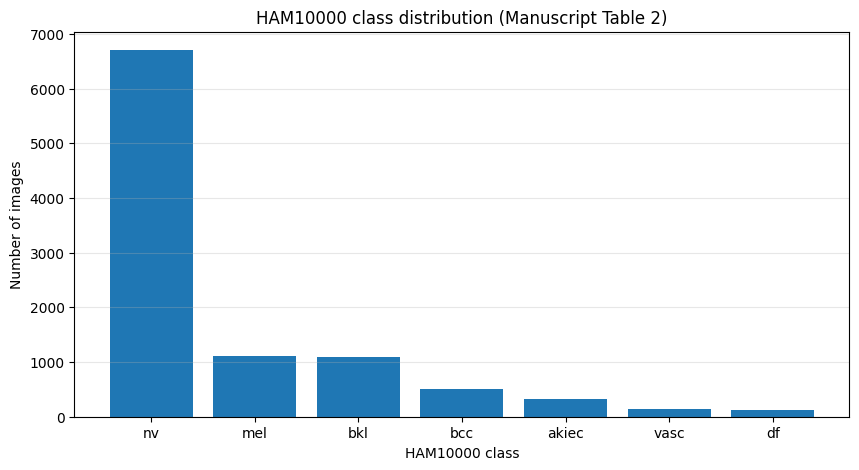

In [ ]:
class_counts = (
    df["dx"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .rename_axis("class_code")
    .reset_index(name="count")
)
class_counts["class_name"] = class_counts["class_code"].map(CLASS_NAMES)
class_counts["percentage"] = 100 * class_counts["count"] / class_counts["count"].sum()
display(class_counts)

plt.figure(figsize=(10, 5))
plt.bar(class_counts["class_code"], class_counts["count"])
plt.xlabel("HAM10000 class")
plt.ylabel("Number of images")
plt.title("HAM10000 class distribution (Manuscript Table 2)")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 8. Example images per class (Manuscript Figure 3)

In [ ]:
def show_examples(df, n_per_class=3):
    fig, axes = plt.subplots(
        len(CLASS_ORDER), n_per_class,
        figsize=(3 * n_per_class, 2.4 * len(CLASS_ORDER)),
    )
    for row, cls in enumerate(CLASS_ORDER):
        subset = df[df["dx"] == cls].sample(
            min(n_per_class, (df["dx"] == cls).sum()), random_state=42
        )
        for col in range(n_per_class):
            ax = axes[row, col] if len(CLASS_ORDER) > 1 else axes[col]
            ax.axis("off")
            if col < len(subset):
                img = Image.open(subset.iloc[col]["image_path"]).convert("RGB")
                ax.imshow(img)
                ax.set_title(f"{cls}: {CLASS_NAMES[cls]}", fontsize=8)
    plt.tight_layout()
    plt.show()

show_examples(df, n_per_class=3)


Output hidden; open in https://colab.research.google.com to view.

## Lesion-disjoint split (approximately 70:15:15; measured fractions printed below)

The grouped split is evaluated for lesion leakage and the measured fractions are printed after construction.


In [ ]:
def patient_level_split(df, test_size=0.15, val_size=0.15, seed=42):
    df = df.reset_index(drop=True).copy()

    if HAS_STRATIFIED_GROUP_KFOLD:
        # 1 fold of 7 gives ~14.3% test -- closest to 15%.
        sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=seed)
        y = df["label_idx"].values
        groups = df["lesion_id"].values
        train_val_idx, test_idx = next(sgkf.split(df, y, groups))
        train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
        test_df = df.iloc[test_idx].reset_index(drop=True)

        # 1 fold of 6 over the remaining ~85.7% gives ~14.3% overall val.
        sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=seed + 1)
        y2 = train_val_df["label_idx"].values
        groups2 = train_val_df["lesion_id"].values
        train_idx2, val_idx2 = next(sgkf2.split(train_val_df, y2, groups2))

        train_df = train_val_df.iloc[train_idx2].reset_index(drop=True)
        val_df = train_val_df.iloc[val_idx2].reset_index(drop=True)
    else:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        train_val_idx, test_idx = next(gss.split(df, groups=df["lesion_id"]))
        train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
        test_df = df.iloc[test_idx].reset_index(drop=True)

        adjusted_val_size = val_size / (1.0 - test_size)
        gss2 = GroupShuffleSplit(
            n_splits=1, test_size=adjusted_val_size, random_state=seed + 1
        )
        train_idx2, val_idx2 = next(gss2.split(train_val_df, groups=train_val_df["lesion_id"]))
        train_df = train_val_df.iloc[train_idx2].reset_index(drop=True)
        val_df = train_val_df.iloc[val_idx2].reset_index(drop=True)

    return train_df, val_df, test_df


train_df, val_df, test_df = patient_level_split(
    df,
    test_size=CONFIG["TEST_SIZE"],
    val_size=CONFIG["VAL_SIZE"],
    seed=CONFIG["SPLIT_SEED"],
)

# Optional smoke-test sub-sample (debug/smoke profiles only).
if CONFIG.get("SMOKE_TEST"):
    print(f"SMOKE_TEST active -- capping each class to ~{CONFIG['SMOKE_MAX_IMAGES'] // 7} train samples.")
    train_df = (
        train_df.groupby("dx", group_keys=False)
        .apply(lambda x: x.sample(
            min(len(x), max(20, CONFIG["SMOKE_MAX_IMAGES"] // len(CLASS_ORDER))),
            random_state=42,
        ))
        .reset_index(drop=True)
    )
    val_df = (
        val_df.groupby("dx", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), 50), random_state=43))
        .reset_index(drop=True)
    )
    test_df = (
        test_df.groupby("dx", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), 50), random_state=44))
        .reset_index(drop=True)
    )

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

split_counts = pd.DataFrame({
    "train": train_df["dx"].value_counts().reindex(CLASS_ORDER),
    "val":   val_df["dx"].value_counts().reindex(CLASS_ORDER),
    "test":  test_df["dx"].value_counts().reindex(CLASS_ORDER),
}).fillna(0).astype(int)
display(split_counts)


def compute_balanced_class_weights(labels, num_classes=7, power=0.5):
    """Soft inverse-frequency class weights for imbalanced HAM10000 training.

    power=1.0 gives full inverse-frequency weighting; power=0.5 is safer for
    small/federated runs because it avoids over-correcting rare classes.
    """
    labels = np.asarray(labels, dtype=np.int64)
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    weights = counts.sum() / (num_classes * counts)
    weights = np.power(weights, float(power))
    weights = weights / weights.mean()
    return weights.astype(np.float32)

GLOBAL_CLASS_WEIGHTS = torch.tensor(
    compute_balanced_class_weights(
        train_df["label_idx"].values,
        num_classes=CONFIG["NUM_CLASSES"],
        power=CONFIG.get("CLASS_WEIGHT_POWER", 0.5),
    ),
    dtype=torch.float32,
)
print("Global class weights used if USE_CLASS_WEIGHTED_LOSS=True:")
print(dict(zip(CLASS_ORDER, np.round(GLOBAL_CLASS_WEIGHTS.numpy(), 3))))

GLOBAL_CLASS_PRIOR = np.bincount(
    train_df["label_idx"].values,
    minlength=CONFIG["NUM_CLASSES"],
).astype(np.float64)
GLOBAL_CLASS_PRIOR = GLOBAL_CLASS_PRIOR / np.maximum(GLOBAL_CLASS_PRIOR.sum(), 1.0)
print("Global train class prior:")
print(dict(zip(CLASS_ORDER, np.round(GLOBAL_CLASS_PRIOR, 4))))


train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])
print("Train ∩ Val lesion overlap:", len(train_lesions & val_lesions))
print("Train ∩ Test lesion overlap:", len(train_lesions & test_lesions))
print("Val ∩ Test lesion overlap:", len(val_lesions & test_lesions))

assert not (train_lesions & val_lesions or train_lesions & test_lesions or val_lesions & test_lesions), 'Lesion leakage'
for left,right in [(train_df,val_df),(train_df,test_df),(val_df,test_df)]:
    assert not set(left.image_id)&set(right.image_id), 'Image leakage'
print('Measured split fractions:',[round(len(x)/len(df),4) for x in [train_df,val_df,test_df]])


Train: (7160, 11)
Val: (1407, 11)
Test: (1448, 11)


,train,val,test
dx,,,
nv,4722,979,1004
mel,810,157,146
bkl,832,132,135
bcc,359,80,75
akiec,248,31,48
vasc,110,13,19
df,79,15,21


Global class weights used if USE_CLASS_WEIGHTED_LOSS=True:
{'nv': np.float32(0.249), 'mel': np.float32(0.602), 'bkl': np.float32(0.594), 'bcc': np.float32(0.904), 'akiec': np.float32(1.088), 'vasc': np.float32(1.634), 'df': np.float32(1.928)}
Global train class prior:
{'nv': np.float64(0.6595), 'mel': np.float64(0.1131), 'bkl': np.float64(0.1162), 'bcc': np.float64(0.0501), 'akiec': np.float64(0.0346), 'vasc': np.float64(0.0154), 'df': np.float64(0.011)}
Train ∩ Val lesion overlap: 0
Train ∩ Test lesion overlap: 0
Val ∩ Test lesion overlap: 0
Measured split fractions: [0.7149, 0.1405, 0.1446]


## 10. PyTorch Dataset and transforms (Manuscript §5.2)

Manuscript §5.2:
> "Each image will be resized to 224×224 pixels ... pixel intensities
>  normalized using channel-wise mean and standard deviation statistics.
>  Standard augmentation, including random horizontal and vertical flips,
>  small-angle rotation, and color-jitter, will be applied during local
>  client training ... validation and test images will be evaluated
>  without augmentation."


In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD = [0.229, 0.224, 0.225]

if CONFIG.get("USE_STRONG_AUG", False):
    # Stronger but still safe augmentation for HAM10000 fine-tuning.
    # RandomResizedCrop makes the model less dependent on exact lesion position;
    # RandAugment adds mild color/contrast/geometry variation.
    _train_aug = [
        transforms.RandomResizedCrop(
            CONFIG["IMG_SIZE"], scale=(0.75, 1.0), ratio=(0.90, 1.10)
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.12, hue=0.02),
    ]
    try:
        _train_aug.append(transforms.RandAugment(num_ops=2, magnitude=7))
    except Exception:
        pass
else:
    _train_aug = [
        transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.08, hue=0.02),
    ]

_train_aug.extend([
    transforms.ToTensor(),
    transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
])

if CONFIG.get("USE_RANDOM_ERASING", False):
    _train_aug.append(transforms.RandomErasing(p=0.15, scale=(0.02, 0.08), ratio=(0.3, 3.3)))

train_tfms = transforms.Compose(_train_aug)

eval_tfms = transforms.Compose([
    transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
])


class HAM10000Dataset(Dataset):
    """Lightweight dataset.

    Improvement over dataframe.iloc inside __getitem__:
    paths/labels are converted to arrays once, which noticeably reduces
    Python overhead in Colab when many client loaders are created.
    """
    def __init__(self, dataframe, transform=None):
        df_local = dataframe.reset_index(drop=True)
        self.paths = df_local["image_path"].astype(str).to_numpy()
        self.labels = df_local["label_idx"].astype(np.int64).to_numpy()
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(self.labels[idx])


def make_class_balanced_sampler(dataframe):
    """Return a WeightedRandomSampler using class frequency inside one client.

    This is optional. It helps minority classes and macro-F1, but it may slightly
    reduce top-line accuracy because HAM10000 is strongly imbalanced.
    """
    labels = dataframe["label_idx"].astype(np.int64).to_numpy()
    counts = np.bincount(labels, minlength=CONFIG["NUM_CLASSES"]).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    sample_weights = 1.0 / counts[labels]
    sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)


def make_loader(dataframe, transform, batch_size=None, shuffle=False, balanced_sampler=False):
    if batch_size is None:
        batch_size = CONFIG["BATCH_SIZE"]
    ds = HAM10000Dataset(dataframe, transform=transform)

    sampler = None
    if balanced_sampler:
        sampler = make_class_balanced_sampler(dataframe)
        shuffle = False

    loader_kwargs = dict(
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        sampler=sampler,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=CONFIG.get("PIN_MEMORY", True) and torch.cuda.is_available(),
        drop_last=False,
    )

    # Only valid when num_workers > 0. Keeping workers off is usually safer
    # on Colab free/T4 for repeated client DataLoader creation.
    if CONFIG["NUM_WORKERS"] > 0:
        loader_kwargs["persistent_workers"] = CONFIG.get("PERSISTENT_WORKERS", True)
        loader_kwargs["prefetch_factor"] = CONFIG.get("PREFETCH_FACTOR", 2)

    return DataLoader(ds, **loader_kwargs)


val_loader = make_loader(val_df, eval_tfms, shuffle=False)
test_loader = make_loader(test_df, eval_tfms, shuffle=False)

print("Val batches:", len(val_loader), "Test batches:", len(test_loader))

Val batches: 88 Test batches: 91


## 11. Non-IID Dirichlet client partitioning (Manuscript §5.3)

Dirichlet α=0.5 is the heterogeneous-client condition used by the main study.


,client_id,n,nv,mel,bkl,bcc,akiec,vasc,df
0,0,718,473,81,84,36,25,11,8
1,1,718,473,81,84,36,25,11,8
2,2,716,472,81,83,36,25,11,8
3,3,716,472,81,83,36,25,11,8
4,4,716,472,81,83,36,25,11,8
5,5,716,472,81,83,36,25,11,8
6,6,716,472,81,83,36,25,11,8
7,7,716,472,81,83,36,25,11,8
8,8,715,472,81,83,36,24,11,8
9,9,713,472,81,83,35,24,11,7


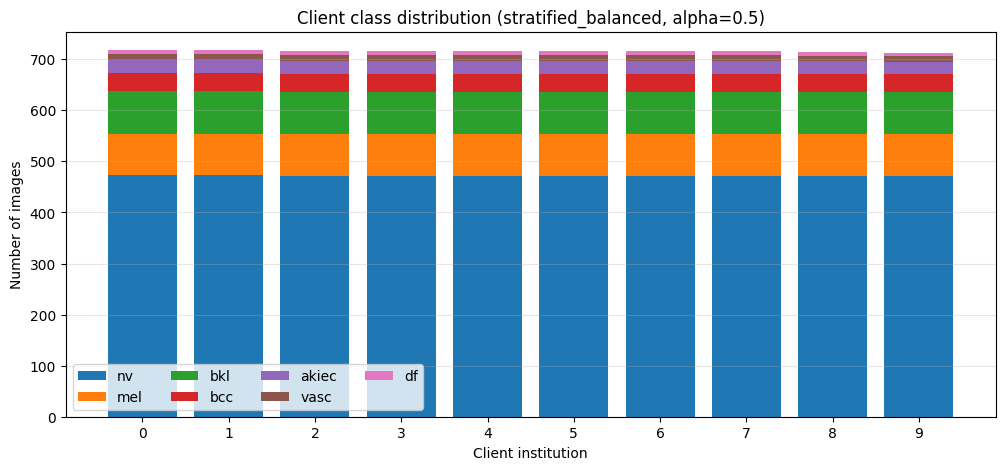

In [ ]:
def dirichlet_partition(dataframe, num_clients=10, alpha=0.5, seed=42, min_size=None):
    minimum=int(CONFIG.get('MIN_CLIENT_SAMPLES',16) if min_size is None else min_size)
    if alpha<=0 or len(dataframe)<num_clients*minimum:
        raise ValueError('Invalid alpha or insufficient data for minimum client size')
    rng=np.random.default_rng(seed); labels=dataframe['label_idx'].to_numpy()
    for attempt in range(1000):
        parts=[[] for _ in range(num_clients)]
        for c in range(CONFIG['NUM_CLASSES']):
            ids=np.where(labels==c)[0]; rng.shuffle(ids)
            counts=rng.multinomial(len(ids),rng.dirichlet(np.full(num_clients,alpha)))
            for i,chunk in enumerate(np.split(ids,np.cumsum(counts)[:-1])): parts[i].extend(chunk.tolist())
        if min(map(len,parts))>=minimum:
            for part in parts: rng.shuffle(part)
            return parts
    raise RuntimeError('Dirichlet minimum-size rejection sampler exhausted; revise protocol explicitly')


def stratified_balanced_partition(dataframe, num_clients=5, seed=42):
    """Near-IID client split with each class distributed across all clients.

    Use this only for clean high-accuracy experiments. For robustness/non-IID
    manuscript experiments, keep PARTITION_METHOD="dirichlet".
    """
    rng = np.random.default_rng(seed)
    labels = dataframe["label_idx"].values
    client_indices = [[] for _ in range(num_clients)]

    for class_idx in range(CONFIG["NUM_CLASSES"]):
        class_indices = np.where(labels == class_idx)[0]
        rng.shuffle(class_indices)
        splits = np.array_split(class_indices, num_clients)
        for client_id, split in enumerate(splits):
            client_indices[client_id].extend(split.tolist())

    for client_id in range(num_clients):
        rng.shuffle(client_indices[client_id])

    return client_indices


def make_client_indices(dataframe, seed=42):
    method = str(CONFIG.get("PARTITION_METHOD", "dirichlet"))
    if method == "stratified_balanced":
        return stratified_balanced_partition(
            dataframe,
            num_clients=CONFIG["NUM_CLIENTS"],
            seed=seed,
        )
    if method == "dirichlet":
        return dirichlet_partition(
            dataframe,
            num_clients=CONFIG["NUM_CLIENTS"],
            alpha=CONFIG["DIRICHLET_ALPHA"],
            seed=seed,
        )
    raise ValueError(f"Unknown PARTITION_METHOD={method}. Use 'dirichlet' or 'stratified_balanced'.")



client_indices = make_client_indices(train_df, seed=CONFIG["SPLIT_SEED"])

client_summary = []
for cid, idxs in enumerate(client_indices):
    sub = train_df.iloc[idxs]
    counts = sub["dx"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)
    row = {"client_id": cid, "n": len(sub)}
    row.update(counts.to_dict())
    client_summary.append(row)

client_summary_df = pd.DataFrame(client_summary)
display(client_summary_df)

plt.figure(figsize=(12, 5))
bottom = np.zeros(len(client_summary_df))
x = client_summary_df["client_id"].astype(str)
for cls in CLASS_ORDER:
    plt.bar(x, client_summary_df[cls], bottom=bottom, label=cls)
    bottom += client_summary_df[cls].values
plt.xlabel("Client institution")
plt.ylabel("Number of images")
plt.title(f"Client class distribution ({CONFIG.get('PARTITION_METHOD', 'dirichlet')}, alpha={CONFIG.get('DIRICHLET_ALPHA', None)})")
plt.legend(ncol=4)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 12. Label-flipping poisoning attack (Manuscript §4.4 + §5.4)

The configured attack flips the selected malignant classes to the benign target class on malicious clients.


In [ ]:
def poison_client_dataframe(client_df, flip_prob=1.0, seed=42):
    rng = np.random.default_rng(seed)
    poisoned = client_df.copy()
    y = poisoned["label_idx"].values.copy()

    malignant_mask = np.isin(y, MALIGNANT_IDXS)
    flip_mask = malignant_mask & (rng.random(len(y)) < flip_prob)

    y[flip_mask] = TARGET_BENIGN_IDX
    poisoned["original_label_idx"] = poisoned["label_idx"].values
    poisoned["label_idx"] = y.astype(int)
    poisoned["is_flipped"] = flip_mask.astype(int)

    return poisoned


# Demonstration on client 0
demo_client = train_df.iloc[client_indices[0]].copy()
demo_poisoned = poison_client_dataframe(demo_client, flip_prob=1.0, seed=42)
print("Demo flipped labels:", int(demo_poisoned["is_flipped"].sum()))
display(pd.crosstab(
    demo_client["dx"],
    demo_poisoned["label_idx"].map(IDX_TO_CLASS),
    rownames=["Original"], colnames=["Poisoned"],
))


Demo flipped labels: 142


Poisoned,bkl,df,nv,vasc
Original,,,,
akiec,0,0,25,0
bcc,0,0,36,0
bkl,84,0,0,0
df,0,8,0,0
mel,0,0,81,0
nv,0,0,473,0
vasc,0,0,0,11


## 13. Fed-ResViT hybrid architecture (Manuscript §4.2)

Manuscript §4.2:
> "The convolutional stream applies a ResNet-50 backbone [22],
>  F_cnn = ResNet50(x) ∈ ℝ^{H'×W'×C} ... The global-context stream first
>  partitions x into fixed-size, non-overlapping patches, linearly embeds
>  each patch, and adds a learned positional encoding, following the
>  original Vision Transformer formulation [23] ... processed through L
>  Transformer encoder blocks, each computing multi-head self-attention ...
>
>  The pooled convolutional feature vector and the aggregated ViT token
>  representation are concatenated and passed through a fusion projection
>  layer with a non-linear activation and dropout regularization, producing
>  a fused feature vector h. A final linear classification head with softmax
>  activation maps h to a probability distribution over the seven HAM10000
>  diagnostic categories."

For the paper-full profile we use `vit_base_patch16_224` (the canonical ViT
of Dosovitskiy et al. [23]) so the comparison to hybrid CNN-ViT works in
§2.2 (e.g. GlobalSkinNet) is on the same backbone class.


In [ ]:
class FedResViT(nn.Module):
    def __init__(
        self,
        num_classes=7,
        vit_backbone="vit_base_patch16_224",
        fusion_dim=512,
        dropout=0.3,
        resnet_pretrained=True,
        vit_pretrained=True,
        freeze_backbones=False,
    ):
        super().__init__()

        # ---- CNN stream: ResNet-50 (Sec 4.2, ref [22]) ----
        try:
            from torchvision.models import ResNet50_Weights
            weights = ResNet50_Weights.IMAGENET1K_V2 if resnet_pretrained else None
            self.cnn = resnet50(weights=weights)
        except Exception as e:
            print("ResNet pretrained load failed. Falling back to random init:", repr(e))
            self.cnn = resnet50(weights=None)

        cnn_in = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        # ---- ViT stream (Sec 4.2, ref [23]) ----
        try:
            self.vit = timm.create_model(
                vit_backbone, pretrained=vit_pretrained, num_classes=0
            )
        except Exception as e:
            print("ViT pretrained load failed. Falling back to random init:", repr(e))
            self.vit = timm.create_model(
                vit_backbone, pretrained=False, num_classes=0
            )

        vit_dim = self.vit.num_features

        if freeze_backbones:
            for p in self.cnn.parameters():
                p.requires_grad = False
            for p in self.vit.parameters():
                p.requires_grad = False

            # Accuracy-oriented partial fine-tuning:
            # keep most pretrained features frozen but allow the final semantic
            # layers to adapt to dermoscopic lesions. This is much lighter than
            # full backpropagation through ResNet-50 + ViT.
            if CONFIG.get("UNFREEZE_RESNET_LAYER3", False) and hasattr(self.cnn, "layer3"):
                for p in self.cnn.layer3.parameters():
                    p.requires_grad = True

            if CONFIG.get("UNFREEZE_RESNET_LAYER4", False) and hasattr(self.cnn, "layer4"):
                for p in self.cnn.layer4.parameters():
                    p.requires_grad = True

            n_vit = int(CONFIG.get("UNFREEZE_VIT_LAST_N_BLOCKS", 0) or 0)
            if n_vit > 0 and hasattr(self.vit, "blocks"):
                for block in self.vit.blocks[-n_vit:]:
                    for p in block.parameters():
                        p.requires_grad = True

            if CONFIG.get("UNFREEZE_VIT_NORM", False) and hasattr(self.vit, "norm"):
                for p in self.vit.norm.parameters():
                    p.requires_grad = True

        # ---- Fusion + classifier (Sec 4.2) ----
        self.fusion = nn.Sequential(
            nn.Linear(cnn_in + vit_dim, fusion_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, num_classes),
        )

        # Optional classifier-prior initialization.
        # This only sets the initial bias and can speed convergence on imbalanced HAM10000.
        if CONFIG.get("INIT_CLASSIFIER_BIAS", False) and "GLOBAL_CLASS_PRIOR" in globals():
            try:
                prior = np.asarray(GLOBAL_CLASS_PRIOR, dtype=np.float32)
                prior = np.clip(prior, 1e-6, 1.0)
                bias = torch.log(torch.tensor(prior / prior.sum(), dtype=torch.float32))
                with torch.no_grad():
                    self.fusion[-1].bias.copy_(bias)
                print("Initialized classifier bias from train-set class prior.")
            except Exception as e:
                print("Classifier bias prior initialization skipped:", repr(e))

    def forward(self, x):
        local_feat = self.cnn(x)          # CNN stream
        global_feat = self.vit(x)         # ViT stream
        fused = torch.cat([local_feat, global_feat], dim=1)
        logits = self.fusion(fused)
        return logits


def build_model():
    model = FedResViT(
        num_classes=CONFIG["NUM_CLASSES"],
        vit_backbone=CONFIG["VIT_BACKBONE"],
        fusion_dim=CONFIG["FUSION_DIM"],
        dropout=CONFIG["DROPOUT"],
        resnet_pretrained=CONFIG["RESNET_PRETRAINED"],
        vit_pretrained=CONFIG["VIT_PRETRAINED"],
        freeze_backbones=CONFIG["FREEZE_BACKBONES"],
    )
    if CONFIG.get("USE_CHANNELS_LAST", False) and DEVICE.type == "cuda":
        model = model.to(memory_format=torch.channels_last)
    return model


# Smoke check
model = build_model().to(DEVICE)
x = torch.randn(2, 3, CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]).to(DEVICE)
with torch.no_grad():
    y = model(x)
print("Output shape:", y.shape)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
del model, x, y
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Initialized classifier bias from train-set class prior.
Output shape: torch.Size([2, 7])
Total parameters: 47,047,623
Trainable parameters: 31,035,655


## Evaluation definitions
Malignant binary recall counts MEL/BCC/AKIEC predictions as malignant for a true
MEL/BCC/AKIEC image. Exact malignant recall instead requires the correct subtype.
Report individual MEL/BCC/AKIEC recall and all seven classes, including VASC/DF.
ASR is the fraction of malignant images classified as NV under attack; it includes
baseline errors and does not by itself measure the causal increase due to poisoning.
The historical `malignant_safety` field is exactly 1-ASR, a derived non-NV rate,
not a clinical safety guarantee. Clean malignant-to-NV rates remain available for
matched comparison. Report macro-precision alongside macro-recall and F1.


In [ ]:
def compute_specificity_macro(y_true, y_pred, num_classes=7):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specificities = []
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        denom = tn + fp
        spec = tn / denom if denom > 0 else np.nan
        specificities.append(spec)
    return float(np.nanmean(specificities))


def compute_asr(y_true, y_pred):
    '''ASR (Sec 5.5): proportion of malignant test samples predicted as the
    benign target class by the poisoned global model.'''
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    malignant_mask = np.isin(y_true, MALIGNANT_IDXS)
    if malignant_mask.sum() == 0:
        return np.nan
    return float(np.mean(y_pred[malignant_mask] == TARGET_BENIGN_IDX))


def compute_malignant_safety(y_true, y_pred):
    asr = compute_asr(y_true, y_pred)
    if np.isnan(asr):
        return np.nan
    return float(1.0 - asr)


def compute_metrics(y_true, y_pred, prefix=""):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred,
        labels=list(range(CONFIG["NUM_CLASSES"])),
        average="macro", zero_division=0,
    )
    specificity = compute_specificity_macro(y_true, y_pred, num_classes=CONFIG["NUM_CLASSES"])
    asr = compute_asr(y_true, y_pred)
    malignant_safety = compute_malignant_safety(y_true, y_pred)

    return {
        f"{prefix}accuracy": float(acc),
        f"{prefix}macro_precision": float(precision),
        f"{prefix}macro_recall": float(recall),
        f"{prefix}macro_f1": float(f1),
        f"{prefix}macro_specificity": float(specificity),
        f"{prefix}asr": float(asr) if not np.isnan(asr) else np.nan,
        f"{prefix}malignant_safety": float(malignant_safety) if not np.isnan(malignant_safety) else np.nan,
    }

def additional_metrics(y_true, y_pred, malignant_ids, target, classes):
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred)
    malignant=np.isin(y_true, malignant_ids); predicted_malignant=np.isin(y_pred, malignant_ids)
    denom=int(malignant.sum()); tp=int((malignant & predicted_malignant).sum())
    fn=int((malignant & ~predicted_malignant).sum()); fp=int((~malignant & predicted_malignant).sum())
    tn=int((~malignant & ~predicted_malignant).sum())
    result=dict(malignant_support=denom, malignant_binary_tp=tp, malignant_binary_fn=fn,
                malignant_binary_fp=fp, malignant_binary_tn=tn,
                malignant_binary_recall=tp/denom if denom else np.nan,
                malignant_exact_recall=float((y_true[malignant]==y_pred[malignant]).mean()) if denom else np.nan,
                malignant_to_nv_rate=float((y_pred[malignant]==target).mean()) if denom else np.nan)
    recalls=[]
    for i in malignant_ids:
        mask=y_true==i; count=int(mask.sum()); value=float((y_pred[mask]==i).mean()) if count else np.nan
        result[f'{classes[i]}_recall']=value; result[f'{classes[i]}_support']=count; recalls.append(value)
    result['malignant_macro_recall']=float(np.nanmean(recalls)) if denom else np.nan
    return result


_original_compute_metrics = compute_metrics
def compute_metrics(y_true, y_pred, prefix=''):
    result=_original_compute_metrics(y_true,y_pred,prefix)
    result.update({prefix+k:v for k,v in additional_metrics(y_true,y_pred,MALIGNANT_IDXS,TARGET_BENIGN_IDX,CLASS_ORDER).items()})
    return result


## 15. Cross-entropy (and optional focal loss) — Manuscript §4.2

Manuscript §4.2:
> "The model is trained to minimize categorical cross-entropy between ŷ and
>  the ground-truth label, optionally replaced by a focal loss formulation
>  [21] to mitigate the substantial class imbalance documented in Table 2."

We keep class weights off by default (the manuscript does not mention class
weighting; it mentions only focal loss as the imbalance-mitigation mechanism).
Set `USE_FOCAL_LOSS=True` for the focal variant.


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = float(gamma)
        self.weight = weight

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1.0 - pt) ** self.gamma) * ce
        return loss.mean()

## 16. Local training and evaluation

Manuscript §5.3:
> "Adam optimizer with an initial learning rate of 1×10⁻⁴ and a batch size of 32."

Each client runs `E = 3` local epochs per round on its own partition.


In [ ]:
def cleanup_memory():
    """Release Python and CUDA cached memory between clients/rounds."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

def freeze_batchnorm_stats(model):
    """Keep BatchNorm running_mean/running_var fixed during federated fine-tuning.

    This matters in FL because each client has a small and often non-IID batch
    distribution. Averaging client-specific BatchNorm running stats can harm
    validation accuracy even when the train loss decreases.
    """
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d, nn.SyncBatchNorm)):
            module.eval()
            for p in module.parameters():
                p.requires_grad = False


def round_learning_rate(round_idx, num_rounds):
    base_lr = float(CONFIG["LR"])

    # Linear warmup: several profiles unfreeze many pretrained layers at once
    # (ResNet layer3/layer4 + several ViT blocks). Hitting all of those with
    # the full target LR on round 1 tends to cause a rough start that the
    # federated averaging never fully recovers from -- a warmup avoids that.
    warmup_rounds = int(CONFIG.get("LR_WARMUP_ROUNDS", 0) or 0)
    if warmup_rounds > 0 and round_idx <= warmup_rounds:
        warmup_lr = base_lr * (round_idx / float(warmup_rounds))
        return max(warmup_lr, base_lr * 0.05)

    schedule = str(CONFIG.get("ROUND_LR_SCHEDULE", "constant")).lower()
    if schedule != "cosine":
        return base_lr

    min_mult = float(CONFIG.get("MIN_LR_MULT", 0.10))
    # Progress is measured over the post-warmup rounds so the cosine curve
    # still spans the full remaining schedule instead of being compressed.
    remaining_rounds = max(num_rounds - warmup_rounds, 1)
    progress = (round_idx - warmup_rounds - 1) / max(remaining_rounds - 1, 1)
    progress = min(max(progress, 0.0), 1.0)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return base_lr * (min_mult + (1.0 - min_mult) * cosine)



def train_local_model(
    model,
    loader,
    local_epochs=1,
    lr=1e-4,
    weight_decay=0.0,
    device=DEVICE,
    max_batches=None,
):
    """Train one local client model.

    max_batches is used only for quick Colab-safe runs. Keep it None for
    manuscript/final results.
    """
    model.train()
    if CONFIG.get("FREEZE_BATCHNORM_STATS", False):
        freeze_batchnorm_stats(model)

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if len(trainable_params) == 0:
        raise RuntimeError("No trainable parameters found. Check FREEZE_BACKBONES/fusion settings.")

    # Differential learning rate:
    # the fusion head can learn faster, while partially unfrozen pretrained
    # backbone layers use a smaller LR to prevent catastrophic forgetting.
    if hasattr(model, "fusion"):
        fusion_param_ids = {id(p) for p in model.fusion.parameters() if p.requires_grad}
        fusion_params = [p for p in model.fusion.parameters() if p.requires_grad]
        backbone_params = [p for p in trainable_params if id(p) not in fusion_param_ids]
        param_groups = []
        if len(backbone_params) > 0:
            param_groups.append({
                "params": backbone_params,
                "lr": lr * float(CONFIG.get("BACKBONE_LR_MULT", 0.2)),
                "weight_decay": weight_decay,
            })
        if len(fusion_params) > 0:
            param_groups.append({
                "params": fusion_params,
                "lr": lr,
                "weight_decay": weight_decay,
            })
    else:
        param_groups = [{"params": trainable_params, "lr": lr, "weight_decay": weight_decay}]

    if CONFIG.get("OPTIMIZER", "adam") == "adam":
        optimizer = torch.optim.Adam(param_groups)
    else:
        optimizer = torch.optim.AdamW(param_groups)

    label_smoothing = float(CONFIG.get("LABEL_SMOOTHING", 0.0) or 0.0)

    if CONFIG.get("USE_FOCAL_LOSS", False):
        criterion = FocalLoss(gamma=CONFIG.get("FOCAL_GAMMA", 2.0))
    elif CONFIG.get("USE_CLASS_WEIGHTED_LOSS", False):
        # Uses clean global train distribution, not poisoned client labels.
        # This improves macro-F1 stability in small Colab runs without changing
        # the federated aggregation logic.
        criterion = nn.CrossEntropyLoss(
            weight=GLOBAL_CLASS_WEIGHTS.to(device), label_smoothing=label_smoothing
        )
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    use_amp = CONFIG["USE_AMP"] and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    total_loss = 0.0
    total_count = 0

    for _ in range(local_epochs):
        for batch_idx, (images, labels) in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            images = images.to(device, non_blocking=True)
            if CONFIG.get("USE_CHANNELS_LAST", False) and device.type == "cuda":
                images = images.to(memory_format=torch.channels_last)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()

            bs = images.size(0)
            total_loss += float(loss.detach().item()) * bs
            total_count += bs

            # reduce temporary GPU references before the next batch
            del images, labels, logits, loss

    return total_loss / max(total_count, 1)


@torch.inference_mode()
def evaluate_model(model, loader, device=DEVICE, max_batches=None):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    use_amp = CONFIG.get("USE_AMP", False) and device.type == "cuda"
    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        images = images.to(device, non_blocking=True)
        if CONFIG.get("USE_CHANNELS_LAST", False) and device.type == "cuda":
            images = images.to(memory_format=torch.channels_last)

        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(images)
            probs = torch.softmax(logits, dim=1)

            # Optional test-time augmentation. Horizontal flip averaging is
            # cheap and often improves clean HAM10000 accuracy slightly.
            if CONFIG.get("TTA_EVAL", False):
                logits_flip = model(torch.flip(images, dims=[3]))
                probs_flip = torch.softmax(logits_flip, dim=1)
                probs = 0.5 * (probs + probs_flip)
                del logits_flip, probs_flip

        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())
        y_prob.extend(probs.detach().cpu().numpy().tolist())

        del images, logits, probs, preds

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    metrics = compute_metrics(y_true, y_pred)
    return metrics, y_true, y_pred, y_prob

## 17. Aggregation utilities (Manuscript §4.5, Algorithm 1)

This section defines the aggregation rules and Trust-aware state used by the federated runner.


In [ ]:
def clone_state_dict(state_dict):
    """Detach a state dict and move it to CPU."""
    return {k: v.detach().cpu().clone() for k, v in state_dict.items()}


def is_float_tensor(t):
    return torch.is_tensor(t) and torch.is_floating_point(t)


def subtract_state_dict(local_state, base_state):
    """Return local_state - base_state for floating tensors."""
    delta = {}
    for k in base_state.keys():
        if is_float_tensor(base_state[k]):
            delta[k] = local_state[k].float() - base_state[k].float()
        else:
            delta[k] = base_state[k].clone()
    return delta


def add_delta_to_state(base_state, delta_state):
    """Return base_state + delta_state for floating tensors."""
    out = {}
    for k in base_state.keys():
        if is_float_tensor(base_state[k]):
            out[k] = (base_state[k].float() + delta_state[k].float()).to(dtype=base_state[k].dtype)
        else:
            out[k] = base_state[k].clone()
    return out


def aggregate_weighted_average(states, weights):
    """Weighted average over state dicts or delta dicts."""
    weights = np.asarray(weights, dtype=np.float64)
    total_w = float(np.sum(weights))
    if total_w <= 1e-12:
        weights = np.ones(len(states), dtype=np.float64)
        total_w = float(np.sum(weights))

    out = {}
    for k in states[0].keys():
        first = states[0][k]
        if is_float_tensor(first):
            acc = torch.zeros_like(first, dtype=torch.float32)
            for state, w in zip(states, weights):
                acc += state[k].float() * float(w)
            out[k] = (acc / total_w).to(dtype=first.dtype)
        else:
            out[k] = first.clone()
    return out


# ---------------------------------------------------------------------------
# FedAvg (Manuscript ref [9])
# ---------------------------------------------------------------------------
def aggregate_fedavg_delta(client_deltas, client_sizes):
    return aggregate_weighted_average(client_deltas, np.asarray(client_sizes, dtype=np.float64))


# ---------------------------------------------------------------------------
# Krum (Manuscript ref [10])
# ---------------------------------------------------------------------------
def state_distance_sq(a, b, normalize=False):
    """Squared L2 distance between two state/delta dictionaries.
    normalize=False keeps the raw L2 norm (matches manuscript Sec 4.5)."""
    total = 0.0
    for k in a.keys():
        if is_float_tensor(a[k]):
            diff = a[k].float() - b[k].float()
            total += float(torch.sum(diff * diff).item())
    return total


def aggregate_krum_delta(client_deltas, f=0):
    return aggregate_krum_checked(client_deltas,f)


# ---------------------------------------------------------------------------
# Coordinate-wise trimmed mean (Manuscript ref [11])
# ---------------------------------------------------------------------------
def aggregate_trimmed_mean_delta(client_deltas, trim_ratio=0.2):
    n = len(client_deltas)
    trim_k = int(math.floor(trim_ratio * n))
    if 2 * trim_k >= n:
        trim_k = max(0, (n - 1) // 2)

    out = {}
    for k in client_deltas[0].keys():
        first = client_deltas[0][k]
        if is_float_tensor(first):
            stacked = torch.stack([s[k].float() for s in client_deltas], dim=0)
            sorted_vals, _ = torch.sort(stacked, dim=0)
            trimmed = sorted_vals[trim_k:n - trim_k] if trim_k > 0 else sorted_vals
            out[k] = trimmed.mean(dim=0).to(dtype=first.dtype)
        else:
            out[k] = first.clone()
    return out


# ---------------------------------------------------------------------------
# Geometric median via Weiszfeld iteration (Manuscript Sec 4.5)
# ---------------------------------------------------------------------------
def aggregate_geometric_median(client_deltas, max_iters=10, eps=1e-6):
    """Geometric median over client deltas via Weiszfeld's algorithm.

    Returns a state-delta dict approximating
        argmin_x  sum_i || x - d_i ||_2

    We initialise from the coordinate-wise mean (a robust-ish start),
    then iterate:
        x_{t+1} = sum_i (d_i / ||d_i - x_t||) / sum_i (1 / ||d_i - x_t||)
    and stop after `max_iters` or when the relative change is below `eps`.
    """
    n = len(client_deltas)
    if n == 0:
        raise ValueError("Cannot take geometric median of zero deltas.")
    if n == 1:
        return clone_state_dict(client_deltas[0])

    # Initialise x_0 = coordinate-wise mean.
    x = aggregate_weighted_average(client_deltas, np.ones(n, dtype=np.float64))

    float_keys = [k for k in x.keys() if is_float_tensor(x[k])]

    def l2_dist(d1, d2):
        total = 0.0
        for k in float_keys:
            diff = d1[k].float() - d2[k].float()
            total += float(torch.sum(diff * diff).item())
        return math.sqrt(max(total, 0.0))

    for it in range(max_iters):
        # Compute weights 1 / ||d_i - x_t|| (with eps floor).
        ws = np.zeros(n, dtype=np.float64)
        for i in range(n):
            d = l2_dist(client_deltas[i], x)
            ws[i] = 1.0 / max(d, eps)

        if ws.sum() <= 0:
            break

        x_new = {}
        for k in x.keys():
            if not is_float_tensor(x[k]):
                x_new[k] = x[k].clone()
                continue
            acc = torch.zeros_like(x[k], dtype=torch.float32)
            for i in range(n):
                acc += client_deltas[i][k].float() * float(ws[i])
            x_new[k] = (acc / float(ws.sum())).to(dtype=x[k].dtype)

        # Check convergence.
        change = l2_dist(x_new, x)
        x = x_new
        if change < eps:
            break

    return x



# ---------------------------------------------------------------------------
# Trust-aware aggregator -- memory-safe + numerically stable distance option.
# ---------------------------------------------------------------------------
class TrustAwareAggregator:
    """Trust-aware aggregation.

    Two practical improvements are included:

    1) TRUST_DISTANCE_MODE="rms" computes L2/sqrt(parameter_count). Raw L2 over
       millions of parameters is often too large for fixed thresholds and may
       drive every phi to zero.

    2) TRUST_ADAPTIVE_THRESHOLDS=True uses median/MAD-based thresholds per round.
       This prevents the all-zero-trust collapse in small Colab runs. Disable it
       if you need the exact fixed-threshold manuscript version.
    """

    def __init__(
        self,
        num_clients,
        t_low,
        t_high,
        momentum=0.85,
        flag_phi_threshold=0.5,
        flag_rounds=5,
        geom_median_iters=10,
        distance_mode="rms",
        adaptive_thresholds=True,
        mad_low_mult=0.5,
        mad_high_mult=3.0,
    ):
        self.num_clients = int(num_clients)
        self.t_low = float(t_low)
        self.t_high = float(t_high)
        self.momentum = float(momentum)
        self.flag_phi_threshold = float(flag_phi_threshold)
        self.flag_rounds = int(flag_rounds)
        self.geom_median_iters = int(geom_median_iters)
        self.distance_mode = str(distance_mode).lower()
        self.adaptive_thresholds = bool(adaptive_thresholds)
        self.mad_low_mult = float(mad_low_mult)
        self.mad_high_mult = float(mad_high_mult)

        if self.t_high <= self.t_low:
            raise ValueError("T_high must be > T_low.")
        if self.distance_mode not in {"l2", "rms"}:
            raise ValueError("distance_mode must be 'l2' or 'rms'.")

        self.reputation = np.ones(self.num_clients, dtype=np.float64)
        self.phi_history = defaultdict(list)
        self.rounds_seen = 0

    @staticmethod
    def _phi(delta, t_low, t_high):
        if delta <= t_low:
            return 1.0
        if delta >= t_high:
            return 0.0
        return float((t_high - delta) / max(t_high - t_low, 1e-12))

    def _distance(self, a, b):
        total = 0.0
        n_params = 0
        for k in a.keys():
            if is_float_tensor(a[k]):
                diff = a[k].float() - b[k].float()
                total += float(torch.sum(diff * diff).item())
                n_params += diff.numel()
        dist = math.sqrt(max(total, 0.0))
        if self.distance_mode == "rms":
            dist = dist / math.sqrt(max(n_params, 1))
        return dist

    def _round_thresholds(self, distances):
        if not self.adaptive_thresholds or len(distances) < 3:
            return self.t_low, self.t_high

        distances = np.asarray(distances, dtype=np.float64)
        med = float(np.median(distances))
        mad = float(np.median(np.abs(distances - med)))

        # If MAD collapses to zero, fall back to an IQR/percentile scale.
        if mad <= 1e-12:
            q25, q75 = np.percentile(distances, [25, 75])
            spread = float(max(q75 - q25, np.std(distances), 1e-12))
        else:
            spread = 1.4826 * mad  # robust sigma estimate

        t_low = med + self.mad_low_mult * spread
        t_high = med + self.mad_high_mult * spread
        if t_high <= t_low:
            t_high = t_low + max(abs(t_low) * 0.1, 1e-8)

        return float(t_low), float(t_high)

    def aggregate(self, client_deltas, client_sizes):
        w_ref = aggregate_geometric_median(
            client_deltas, max_iters=self.geom_median_iters
        )

        distances = np.zeros(len(client_deltas), dtype=np.float64)
        for i, d in enumerate(client_deltas):
            distances[i] = self._distance(d, w_ref)

        round_t_low, round_t_high = self._round_thresholds(distances)

        phi = np.zeros(len(client_deltas), dtype=np.float64)
        for i in range(len(client_deltas)):
            phi[i] = self._phi(distances[i], round_t_low, round_t_high)

        self.reputation = (
            self.momentum * self.reputation + (1.0 - self.momentum) * phi
        )
        self.rounds_seen += 1

        for i in range(len(client_deltas)):
            self.phi_history[i].append(phi[i])
            if len(self.phi_history[i]) > self.flag_rounds:
                self.phi_history[i].pop(0)

        flagged_now = np.zeros(len(client_deltas), dtype=bool)
        for i in range(len(client_deltas)):
            hist = self.phi_history[i]
            if hist and min(hist) < self.flag_phi_threshold:
                flagged_now[i] = True

        weights = self.reputation * phi

        if weights.sum() <= 1e-12:
            print("All trust weights are zero this round; falling back to FedAvg-delta.")
            weights = np.asarray(client_sizes, dtype=np.float64)

        aggregated_delta = aggregate_weighted_average(client_deltas, weights)

        info = {
            "distances": distances,
            "phi": phi,
            "reputation": self.reputation.copy(),
            "weights": weights.copy(),
            "flagged_now": flagged_now.copy(),
            "distance_mode": self.distance_mode,
            "round_t_low": round_t_low,
            "round_t_high": round_t_high,
            "distance_vector_l2_norm": float(np.linalg.norm(distances)),
            "normalized_weights": weights / max(float(weights.sum()), 1e-12),
        }
        return aggregated_delta, info

In [ ]:
# ============================================================
# Research helpers: persistence, validation and adaptive attack
# ============================================================

import os, json, hashlib, random, copy, time, platform, inspect, warnings
from pathlib import Path
import numpy as np
import torch
REVISION = 'mentor-v2.0'

def scientific_source(obj):
    # inspect.getsource(Class) can fail in IPython (__main__ has no file).
    # Function/method code objects retain the notebook cell source location.
    if inspect.isclass(obj):
        methods=[]
        for name,value in sorted(obj.__dict__.items()):
            if isinstance(value,(staticmethod,classmethod)): value=value.__func__
            if inspect.isfunction(value): methods.append(name+'\n'+inspect.getsource(value))
        return obj.__name__+''+''.join(methods)
    return inspect.getsource(obj)


def jsonable(x):
    if isinstance(x, dict): return {str(k): jsonable(v) for k,v in x.items()}
    if isinstance(x, (list,tuple,set)): return [jsonable(v) for v in x]
    if isinstance(x, np.ndarray): return jsonable(x.tolist())
    if isinstance(x, np.generic): return jsonable(x.item())
    if isinstance(x, Path): return str(x)
    if isinstance(x, float) and not np.isfinite(x): return None
    return x


def canonical(x):
    return json.dumps(jsonable(x), sort_keys=True, separators=(',',':'), allow_nan=False)


def atomic_json(path, value):
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    temp=path.with_suffix(path.suffix+'.tmp')
    with open(temp,'w') as f:
        f.write(json.dumps(jsonable(value),indent=2,allow_nan=False)); f.flush(); os.fsync(f.fileno())
    os.replace(temp,path)


def capture_rng():
    return dict(python=random.getstate(), numpy=np.random.get_state(), torch=torch.get_rng_state(),
                cuda=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None)


def restore_rng(state):
    random.setstate(state['python']); np.random.set_state(state['numpy']); torch.set_rng_state(state['torch'])
    if state['cuda'] is not None:
        if not torch.cuda.is_available() or len(state['cuda']) != torch.cuda.device_count():
            raise RuntimeError('CUDA topology changed; exact continuation is not supported.')
        torch.cuda.set_rng_state_all(state['cuda'])


def environment_record():
    from importlib.metadata import version, PackageNotFoundError
    packages={}
    for p in ['torch','torchvision','timm','numpy','pandas','scikit-learn','scipy','Pillow']:
        try: packages[p]=version(p)
        except PackageNotFoundError: packages[p]='unavailable'
    return dict(python=platform.python_version(), packages=packages, cuda=torch.version.cuda,
                gpu=torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
                cuda_devices=torch.cuda.device_count(), cudnn=torch.backends.cudnn.version(),
                deterministic=torch.are_deterministic_algorithms_enabled(),
                cudnn_benchmark=torch.backends.cudnn.benchmark,
                cudnn_deterministic=torch.backends.cudnn.deterministic,
                matmul_tf32=torch.backends.cuda.matmul.allow_tf32,
                cudnn_tf32=torch.backends.cudnn.allow_tf32,
                cublas_workspace=os.environ.get('CUBLAS_WORKSPACE_CONFIG'))


def save_recovery(folder, state):
    """Two alternating generations; incomplete writes never replace a valid generation.
    Drive FUSE durability is best-effort: retain the prior generation + checksum.
    Only load checkpoints produced by this trusted notebook (torch uses pickle).
    """
    folder=Path(folder); folder.mkdir(parents=True,exist_ok=True)
    path=folder/f"recovery-{int(state['round']) % 2}.pt"
    temp=folder/'recovery-writing.tmp'
    with open(temp,'wb') as f:
        torch.save(state,f); f.flush(); os.fsync(f.fileno())
    digest=file_sha(temp)
    os.replace(temp,path)
    atomic_json(str(path)+'.sha256.json',{'sha256':digest})


def file_sha(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for block in iter(lambda:f.read(8*1024*1024),b''): h.update(block)
    return h.hexdigest()


def load_recovery(folder, run_id, environment):
    candidates=[]; errors=[]
    for p in Path(folder).glob('recovery-*.pt'):
        try:
            expected=json.loads(Path(str(p)+'.sha256.json').read_text())['sha256']
            if file_sha(p)!=expected: raise ValueError('Checksum mismatch')
            state=torch.load(p,map_location='cpu',weights_only=False)
            if state['run_id']!=run_id: raise ValueError('Wrong experiment ID')
            if state['environment']!=environment: raise ValueError('Environment mismatch; restore the original environment')
            candidates.append(state)
        except Exception as e: errors.append(f'{p.name}: {e}')
    if errors: warnings.warn('Recovery validation: '+'; '.join(errors))
    if candidates: return max(candidates,key=lambda x:x['round'])
    if errors: raise RuntimeError('No compatible valid recovery. Refusing to silently restart.')
    return None


def validate_updates(updates):
    if not updates: raise ValueError('No client updates')
    keys=list(updates[0])
    for d in updates:
        if list(d)!=keys: raise ValueError('Update keys differ')
        for k in keys:
            if d[k].shape!=updates[0][k].shape: raise ValueError('Update shapes differ')
            if d[k].is_floating_point() and not torch.isfinite(d[k]).all(): raise ValueError('Nonfinite update')


def aggregate_krum_checked(updates, f, multi=False, m=None):
    validate_updates(updates); n=len(updates); f=int(f)
    if f<0 or n<=2*f+2: raise ValueError(f'Krum requires n > 2f+2; n={n}, f={f}')
    distances=np.zeros((n,n),dtype=np.float64)
    for i in range(n):
        for j in range(i):
            v=sum(float(((updates[i][k].double()-updates[j][k].double())**2).sum())
                  for k in updates[i] if updates[i][k].is_floating_point())
            distances[i,j]=distances[j,i]=v
    nearest_count=n-f-2
    scores=[np.sort(np.delete(distances[i],i))[:nearest_count].sum() for i in range(n)]
    count=(nearest_count if m is None else int(m)) if multi else 1
    if not 1<=count<=nearest_count: raise ValueError('Multi-Krum m must be in [1,n-f-2]')
    selected=np.argsort(scores,kind='stable')[:count]
    return {k:(torch.stack([updates[i][k].float() for i in selected]).mean(0).to(v.dtype)
                if v.is_floating_point() else v.clone()) for k,v in updates[0].items()}


def aggregate_coordinate(updates, trim_count=None):
    validate_updates(updates); n=len(updates)
    if trim_count is not None and (trim_count<0 or 2*trim_count>=n): raise ValueError('Invalid trim count')
    out={}
    for k,v in updates[0].items():
        if not v.is_floating_point(): out[k]=v.clone(); continue
        a=torch.stack([d[k].float() for d in updates]).sort(dim=0).values
        if trim_count is None:
            out[k]=((a[(n-1)//2]+a[n//2])/2).to(v.dtype)
        else:
            out[k]=a[trim_count:n-trim_count].mean(0).to(v.dtype)
    return out



def detector_counts(flags, malicious, n):
    truth=np.array([i in malicious for i in range(n)],dtype=bool); flags=np.asarray(flags,dtype=bool)
    return dict(detector_tp=int((flags & truth).sum()),detector_fp=int((flags & ~truth).sum()),
                detector_tn=int((~flags & ~truth).sum()),detector_fn=int((~flags & truth).sum()))


def validate_partition(indices, size, minimum=1):
    flat=[int(i) for part in indices for i in part]
    if sorted(flat)!=list(range(size)): raise ValueError('Partition must cover each training row exactly once')
    if min(map(len,indices))<minimum: raise ValueError('Client too small for the declared minimum')


def adaptive_camouflage(updates, malicious, trust_probe, grid):
    """Omniscient same-round, defense-aware update attacker.
    Sees every pre-aggregation update; blends poisoned updates toward the geometric
    median of HONEST updates. Searches largest poison retention accepted by the
    current Trust score/flag threshold. Does not access validation/test labels.
    A new Trust clone evaluates every candidate; real reputation is not mutated.
    This is one bounded adaptive strategy, not a universal/worst-case attacker.
    """
    if not malicious: return updates, {'attack':'none'}
    honest=[d for i,d in enumerate(updates) if i not in malicious]
    reference=aggregate_geometric_median(honest,max_iters=trust_probe.geom_median_iters)
    chosen=None; trace=[]
    for scale in sorted(set(float(x) for x in grid),reverse=True):
        if not 0<=scale<=1: raise ValueError('Attack blend must be within [0,1]')
        candidate=list(updates)
        for i in malicious:
            candidate[i]={k:(reference[k]+scale*(updates[i][k]-reference[k]) if v.is_floating_point() else v.clone())
                          for k,v in reference.items()}
        probe=copy.deepcopy(trust_probe)
        _,info=probe.aggregate(candidate,[1]*len(candidate))
        accepted=all(info['phi'][i]>=probe.flag_phi_threshold for i in malicious)
        trace.append(dict(scale=scale,accepted=accepted,phi=info['phi'].tolist(),distances=info['distances'].tolist()))
        chosen=(candidate,dict(attack='adaptive_omniscient_blend',selected_scale=scale,accepted=accepted,search=trace))
        if accepted: break
    if chosen is None: raise ValueError('Empty attack grid')
    return chosen


def data_manifest(frames):
    records={}
    for name,frame in frames.items():
        cols=[k for k in ['image_id','lesion_id','label_idx','image_sha256'] if k in frame]
        records[name]=frame[cols].to_dict('records')
    return records


class SessionBudgetReached(RuntimeError): pass


_required_helpers=['atomic_json','file_sha','environment_record','save_recovery','load_recovery','validate_updates',
                   'aggregate_krum_checked','aggregate_coordinate','detector_counts','validate_partition',
                   'adaptive_camouflage','data_manifest','SessionBudgetReached']
_missing=[name for name in _required_helpers if name not in globals()]
if _missing: raise RuntimeError(f'Missing research helpers: {_missing}')
print('Research helpers loaded successfully:', ', '.join(_required_helpers))

Research helpers loaded successfully: atomic_json, file_sha, environment_record, save_recovery, load_recovery, validate_updates, aggregate_krum_checked, aggregate_coordinate, detector_counts, validate_partition, adaptive_camouflage, data_manifest, SessionBudgetReached


In [ ]:
print("build_plan available:", "build_plan" in globals())
print("run_study available:", "run_study" in globals())
print("run_identified available:", "run_identified" in globals())

build_plan available: True
run_study available: True
run_identified available: True


## 18. Federated experiment runner

The runner executes one identified experiment at a time, persists round-boundary recovery state, and writes a completion marker only after required artifacts are validated.


In [ ]:
def make_client_dataframes(train_df, client_indices, malicious_clients=None, seed=42):
    if malicious_clients is None:
        malicious_clients = set()

    client_dfs = []
    poison_stats = []

    for cid, idxs in enumerate(client_indices):
        client_df = train_df.iloc[idxs].copy().reset_index(drop=True)
        if cid in malicious_clients:
            client_df = poison_client_dataframe(
                client_df, flip_prob=CONFIG["FLIP_PROB"], seed=seed + cid
            )
            flipped = int(client_df["is_flipped"].sum())
        else:
            client_df["original_label_idx"] = client_df["label_idx"].values
            client_df["is_flipped"] = 0
            flipped = 0

        client_dfs.append(client_df)
        poison_stats.append({
            "client_id": cid,
            "is_malicious": cid in malicious_clients,
            "n": len(client_df),
            "flipped_labels": flipped,
            "flip_rate_within_client": flipped / max(len(client_df), 1),
        })

    return client_dfs, pd.DataFrame(poison_stats)


def choose_malicious_clients(num_clients, malicious_fraction, seed=42):
    rng = np.random.default_rng(seed)
    n_mal = int(round(num_clients * malicious_fraction))
    n_mal = min(max(n_mal, 0), num_clients)
    if n_mal == 0:
        return set()
    return set(rng.choice(num_clients, size=n_mal, replace=False).tolist())


def detection_metrics(flagged, malicious_clients, num_clients):
    '''Detection rate = TP / (#malicious); FPR = FP / (#benign).'''
    flagged = np.asarray(flagged).astype(bool)
    malicious_mask = np.array(
        [i in malicious_clients for i in range(num_clients)], dtype=bool
    )

    if malicious_mask.sum() > 0:
        detection_rate = float(np.mean(flagged[malicious_mask]))
    else:
        detection_rate = np.nan
    benign_mask = ~malicious_mask
    if benign_mask.sum() > 0:
        false_positive_rate = float(np.mean(flagged[benign_mask]))
    else:
        false_positive_rate = np.nan
    return detection_rate, false_positive_rate


def _clean_asr_if_no_attack(metrics, malicious_fraction):
    '''ASR is only defined under attack (Sec 5.5).'''
    metrics = dict(metrics)
    if malicious_fraction == 0:
        metrics["asr"] = np.nan
        metrics["malignant_safety"] = np.nan
    return metrics


def _safe_model_filename(aggregation_method, malicious_fraction, seed):
    mal_tag = str(malicious_fraction).replace(".", "p")
    return f"{aggregation_method}_mal{mal_tag}_seed{seed}.pt"


def _weighted_delta_accumulate(acc, delta, weight):
    """Streaming FedAvg helper: avoids storing all client deltas in RAM."""
    if acc is None:
        out = {}
        for k, v in delta.items():
            if is_float_tensor(v):
                out[k] = v.float() * float(weight)
            else:
                out[k] = v.clone()
        return out
    for k, v in delta.items():
        if is_float_tensor(v):
            acc[k] += v.float() * float(weight)
    return acc


def _finalize_weighted_delta(acc, total_weight):
    out = {}
    total_weight = max(float(total_weight), 1e-12)
    for k, v in acc.items():
        if is_float_tensor(v):
            out[k] = (v.float() / total_weight).to(dtype=v.dtype)
        else:
            out[k] = v.clone()
    return out


def _run_federated_core(
    aggregation_method="trust",
    malicious_fraction=0.2,
    seed=42,
    num_rounds=None,
    local_epochs=None,
):
    set_seed(seed)

    if num_rounds is None:
        num_rounds = CONFIG["NUM_ROUNDS"]
    if local_epochs is None:
        local_epochs = CONFIG["LOCAL_EPOCHS"]

    client_indices = make_client_indices(train_df, seed=seed)

    malicious_clients = choose_malicious_clients(
        CONFIG["NUM_CLIENTS"], malicious_fraction, seed=seed + 1000,
    )

    client_dfs, poison_stats = make_client_dataframes(
        train_df, client_indices, malicious_clients=malicious_clients, seed=seed,
    )
    client_sizes = [len(cdf) for cdf in client_dfs]

    validate_partition(client_indices,len(train_df),CONFIG.get('MIN_CLIENT_SAMPLES',16))
    atomic_json(Path(CONFIG['OUTPUT_DIR'])/'clients.json', {
        'indices':client_indices,'sizes':client_sizes,'malicious_clients':sorted(malicious_clients),
        'class_counts':[d['label_idx'].value_counts().to_dict() for d in client_dfs]})
    poison_stats.to_csv(Path(CONFIG['OUTPUT_DIR'])/'poison_stats.csv',index=False)
    global_model = build_model().to(DEVICE)
    global_state = clone_state_dict(global_model.state_dict())

    # Reuse one local model, but do not keep all client DataLoaders alive.
    local_model = build_model().to(DEVICE)

    trust_agg = None
    if aggregation_method == "trust":
        trust_agg = TrustAwareAggregator(
            num_clients=CONFIG["NUM_CLIENTS"],
            t_low=CONFIG["TRUST_T_LOW"],
            t_high=CONFIG["TRUST_T_HIGH"],
            momentum=CONFIG["TRUST_MOMENTUM"],
            flag_phi_threshold=CONFIG["TRUST_FLAG_PHI_THRESHOLD"],
            flag_rounds=CONFIG["TRUST_FLAG_ROUNDS"],
            geom_median_iters=CONFIG["TRUST_GEOM_MEDIAN_ITERS"],
            distance_mode=CONFIG.get("TRUST_DISTANCE_MODE", "rms"),
            adaptive_thresholds=CONFIG.get("TRUST_ADAPTIVE_THRESHOLDS", True),
            mad_low_mult=CONFIG.get("TRUST_MAD_LOW_MULT", 0.5),
            mad_high_mult=CONFIG.get("TRUST_MAD_HIGH_MULT", 3.0),
        )

    attack_probe = trust_agg if trust_agg is not None else TrustAwareAggregator(
        num_clients=CONFIG['NUM_CLIENTS'],t_low=CONFIG['TRUST_T_LOW'],t_high=CONFIG['TRUST_T_HIGH'],
        momentum=CONFIG['TRUST_MOMENTUM'],flag_phi_threshold=CONFIG['TRUST_FLAG_PHI_THRESHOLD'],
        flag_rounds=CONFIG['TRUST_FLAG_ROUNDS'],geom_median_iters=CONFIG['TRUST_GEOM_MEDIAN_ITERS'],
        distance_mode=CONFIG['TRUST_DISTANCE_MODE'],adaptive_thresholds=CONFIG['TRUST_ADAPTIVE_THRESHOLDS'],
        mad_low_mult=CONFIG['TRUST_MAD_LOW_MULT'],mad_high_mult=CONFIG['TRUST_MAD_HIGH_MULT'])
    history = []
    last_trust_info = None
    best_state = None
    best_round = None
    best_metric_value = -np.inf
    best_metric_name = str(CONFIG.get("BEST_MODEL_METRIC", "accuracy"))

    print("=" * 90)
    print(f"Aggregator: {aggregation_method} | malicious_fraction={malicious_fraction} | seed={seed}")
    print("Malicious clients:", sorted(malicious_clients))
    display(poison_stats)

    start_round=1
    recovery=load_recovery(CONFIG['OUTPUT_DIR'],ACTIVE_RUN_ID,ACTIVE_ENVIRONMENT)
    if recovery is not None:
        global_state=recovery['global_state']; global_model.load_state_dict(global_state)
        best_state=recovery['best_state']; best_round=recovery['best_round']; best_metric_value=recovery['best_metric_value']
        history=recovery['history']; last_trust_info=recovery['last_trust_info']
        if trust_agg is not None: trust_agg.__dict__.update(recovery['trust_state'])
        attack_probe.__dict__.update(recovery['probe_state'])
        restore_rng(recovery['rng']); start_round=recovery['round']+1
        print('RESUME: last saved round',recovery['round'],'next',start_round)
    del recovery
    for round_idx in range(start_round, num_rounds + 1):
        if time.monotonic() >= globals().get('SESSION_DEADLINE',float('inf')):
            raise SessionBudgetReached('Session budget reached. Rerun the same plan to resume.')
        round_start = time.time()
        base_state = clone_state_dict(global_state)
        current_lr = round_learning_rate(round_idx, num_rounds)
        train_losses = []
        detection_rate_current = np.nan
        false_positive_rate_current = np.nan

        # For FedAvg, stream the weighted average so RAM does not hold every full update.
        fedavg_acc = None
        fedavg_weight = 0.0
        stream_fedavg = aggregation_method == 'fedavg' and CONFIG['ATTACK_MODE'] != 'adaptive_omniscient_blend'
        client_deltas = None if stream_fedavg else []

        for cid, client_df in enumerate(tqdm(
            client_dfs, desc=f"Round {round_idx}/{num_rounds}", leave=False
        )):
            loader = make_loader(
                client_df, train_tfms,
                batch_size=CONFIG["BATCH_SIZE"],
                shuffle=True,
                balanced_sampler=CONFIG.get("USE_CLIENT_BALANCED_SAMPLER", False),
            )

            local_model.load_state_dict(base_state, strict=True)

            loss = train_local_model(
                local_model, loader,
                local_epochs=local_epochs,
                lr=current_lr,
                weight_decay=CONFIG["WEIGHT_DECAY"],
                device=DEVICE,
                max_batches=CONFIG.get("MAX_TRAIN_BATCHES_PER_CLIENT", None),
            )

            local_state = clone_state_dict(local_model.state_dict())
            client_delta = subtract_state_dict(local_state, base_state)
            train_losses.append(loss)

            if stream_fedavg:
                fedavg_acc = _weighted_delta_accumulate(
                    fedavg_acc, client_delta, client_sizes[cid]
                )
                fedavg_weight += float(client_sizes[cid])
                del local_state, client_delta
            else:
                client_deltas.append(client_delta)
                del local_state

            del loader
            if CONFIG.get("CLEAR_CUDA_EACH_CLIENT", False):
                cleanup_memory()

        attack_info={'attack':CONFIG['ATTACK_MODE']}
        if CONFIG['ATTACK_MODE']=='adaptive_omniscient_blend' and malicious_clients:
            client_deltas,attack_info=adaptive_camouflage(client_deltas,malicious_clients,attack_probe,CONFIG['ADAPTIVE_BLEND_GRID'])
            if aggregation_method != 'trust': attack_probe.aggregate(client_deltas,client_sizes)
        if aggregation_method == 'fedavg' and not stream_fedavg:
            aggregated_delta=aggregate_weighted_average(client_deltas,client_sizes)
        elif stream_fedavg:
            aggregated_delta = _finalize_weighted_delta(fedavg_acc, fedavg_weight)
            del fedavg_acc

        elif aggregation_method == "krum":
            f = len(malicious_clients)
            aggregated_delta = aggregate_krum_delta(client_deltas, f=f)

        elif aggregation_method == 'multi_krum':
            aggregated_delta=aggregate_krum_checked(client_deltas,len(malicious_clients),multi=True,m=CONFIG.get('MULTI_KRUM_M'))
        elif aggregation_method == 'coordinate_median':
            aggregated_delta=aggregate_coordinate(client_deltas)
        elif aggregation_method == 'trimmed_mean':
            aggregated_delta=aggregate_coordinate(client_deltas,trim_count=len(malicious_clients))

        elif aggregation_method == "trust":
            aggregated_delta, last_trust_info = trust_agg.aggregate(
                client_deltas, client_sizes
            )
            detection_rate_current, false_positive_rate_current = detection_metrics(
                last_trust_info["flagged_now"], malicious_clients, CONFIG["NUM_CLIENTS"]
            )

        else:
            raise ValueError(f"Unknown aggregation method: {aggregation_method}")

        if client_deltas is not None:
            del client_deltas

        global_state = add_delta_to_state(base_state, aggregated_delta)
        global_model.load_state_dict(global_state, strict=True)
        del base_state, aggregated_delta
        cleanup_memory()

        if (round_idx % CONFIG.get("EVAL_EVERY", 1) == 0) or (round_idx == num_rounds):
            val_metrics, _, _, _ = evaluate_model(
                global_model, val_loader, DEVICE,
                max_batches=CONFIG.get("MAX_VAL_BATCHES", None),
            )
            val_metrics = _clean_asr_if_no_attack(val_metrics, malicious_fraction)
        else:
            val_metrics = {
                "accuracy": np.nan,
                "macro_precision": np.nan,
                "macro_recall": np.nan,
                "macro_f1": np.nan,
                "macro_specificity": np.nan,
                "asr": np.nan,
                "malignant_safety": np.nan,
            }

        # Keep the best validation checkpoint. This is important for high-accuracy
        # runs because the final FL round is not always the best generalizing round.
        if CONFIG.get("USE_BEST_VAL_MODEL", False):
            metric_value = val_metrics.get(best_metric_name, np.nan)
            if (
                round_idx >= int(CONFIG.get("BEST_MODEL_MIN_ROUND", 1))
                and metric_value is not None
                and not np.isnan(metric_value)
                and float(metric_value) > float(best_metric_value)
            ):
                if best_state is not None:
                    del best_state
                best_state = clone_state_dict(global_state)
                best_metric_value = float(metric_value)
                best_round = int(round_idx)

        elapsed = time.time() - round_start
        row = {
            "seed": seed,
            "round": round_idx,
            "aggregation": aggregation_method,
            "malicious_fraction": malicious_fraction,
            "num_malicious": len(malicious_clients),
            "malicious_clients": sorted(list(malicious_clients)),
            "avg_train_loss": float(np.mean(train_losses)),
            "round_lr": float(current_lr),
            "round_seconds": elapsed,
            "detection_rate_current": detection_rate_current,
            "false_positive_rate_current": false_positive_rate_current,
        }
        row.update({f"val_{k}": v for k, v in val_metrics.items()})

        if last_trust_info is not None:
            row.update({
                "trust_mean_phi": float(np.mean(last_trust_info["phi"])),
                "trust_min_phi": float(np.min(last_trust_info["phi"])),
                "trust_mean_reputation": float(np.mean(last_trust_info["reputation"])),
                "trust_min_reputation": float(np.min(last_trust_info["reputation"])),
                "trust_num_flagged_now": int(np.sum(last_trust_info["flagged_now"])),
                "trust_distance_mode": last_trust_info.get("distance_mode", ""),
                "trust_round_t_low": float(last_trust_info.get("round_t_low", np.nan)),
                "trust_round_t_high": float(last_trust_info.get("round_t_high", np.nan)),
            })

        row['attack_info']=jsonable(attack_info)
        if last_trust_info is not None:
            row.update(detector_counts(last_trust_info['flagged_now'],malicious_clients,CONFIG['NUM_CLIENTS']))
            row['client_trust']=jsonable(last_trust_info)
        history.append(row)
        # Optimizer + AMP scaler are re-created per train_local_model invocation in
        # this algorithm; no optimizer state persists at a completed round boundary.
        # LR is a pure function of round index, not a stateful scheduler.
        save_recovery(CONFIG['OUTPUT_DIR'],dict(run_id=ACTIVE_RUN_ID,environment=ACTIVE_ENVIRONMENT,
            round=round_idx,global_state=global_state,best_state=best_state,best_round=best_round,
            best_metric_value=best_metric_value,history=history,last_trust_info=last_trust_info,
            trust_state=copy.deepcopy(trust_agg.__dict__) if trust_agg is not None else None,
            probe_state=copy.deepcopy(attack_probe.__dict__),rng=capture_rng()))
        atomic_json(Path(CONFIG['OUTPUT_DIR'])/'round_history.json',history)
        pd.DataFrame(history).to_csv(Path(CONFIG['OUTPUT_DIR'])/'round_history.csv',index=False)
        if globals().get('STOP_AFTER_ROUND') == round_idx:
            raise SessionBudgetReached(f'Deliberate recovery drill: saved round {round_idx}. Set STOP_AFTER_ROUND=None and rerun.')

        asr_print = "NA (no attack)" if np.isnan(row["val_asr"]) and malicious_fraction == 0 else ("NA" if np.isnan(row["val_asr"]) else f"{row['val_asr']:.4f}")
        best_text = ""
        if CONFIG.get("USE_BEST_VAL_MODEL", False) and best_round is not None:
            best_text = f" | best_{best_metric_name}=round{best_round}:{best_metric_value:.4f}"
        print(
            f"Round {round_idx:03d} | loss={row['avg_train_loss']:.4f} | lr={current_lr:.2e} | "
            f"val_acc={row['val_accuracy']:.4f} | val_f1={row['val_macro_f1']:.4f} | "
            f"ASR={asr_print}{best_text} | time={elapsed:.1f}s"
        )

        if last_trust_info is not None:
            print(
                "  dist:", np.round(last_trust_info["distances"], 6),
                "thr:", (round(last_trust_info.get("round_t_low", np.nan), 6),
                        round(last_trust_info.get("round_t_high", np.nan), 6)),
                "phi:", np.round(last_trust_info["phi"], 3),
                "rep:", np.round(last_trust_info["reputation"], 3),
                "flag_now:", last_trust_info["flagged_now"].astype(int),
            )

    del local_model
    cleanup_memory()

    if CONFIG.get("USE_BEST_VAL_MODEL", False) and best_state is not None:
        print(f"Using best validation checkpoint from round {best_round} "
              f"({best_metric_name}={best_metric_value:.4f}) for final test.")
        global_state = best_state
        global_model.load_state_dict(global_state, strict=True)

    test_metrics, y_true, y_pred, y_prob = evaluate_model(
        global_model, test_loader, DEVICE,
        max_batches=CONFIG.get("MAX_TEST_BATCHES", None),
    )
    test_metrics = _clean_asr_if_no_attack(test_metrics, malicious_fraction)

    result = {
        "seed": seed,
        "aggregation": aggregation_method,
        "malicious_fraction": malicious_fraction,
        "num_malicious": len(malicious_clients),
        "malicious_clients": sorted(list(malicious_clients)),
        "best_val_round": best_round,
        f"best_val_{best_metric_name}": best_metric_value if best_round is not None else np.nan,
    }
    result.update({f"test_{k}": v for k, v in test_metrics.items()})

    if last_trust_info is not None:
        final_det, final_fpr = detection_metrics(
            last_trust_info["flagged_now"], malicious_clients, CONFIG["NUM_CLIENTS"]
        )
        result.update(detector_counts(last_trust_info['flagged_now'],malicious_clients,CONFIG['NUM_CLIENTS']))
        result['detection_scope']='final_training_round_history_window_not_best_checkpoint'
        result["test_detection_rate"] = final_det
        result["test_false_positive_rate"] = final_fpr
        result["trust_final_phi"] = np.round(last_trust_info["phi"], 6).tolist()
        result["trust_final_reputation"] = np.round(last_trust_info["reputation"], 6).tolist()
    else:
        result["test_detection_rate"] = np.nan
        result["test_false_positive_rate"] = np.nan
        result["trust_final_phi"] = None
        result["trust_final_reputation"] = None

    model_name = _safe_model_filename(aggregation_method, malicious_fraction, seed)
    model_path = os.path.join(CONFIG["OUTPUT_DIR"], model_name)
    if CONFIG.get("SAVE_MODEL_CHECKPOINTS", True):
        torch.save(global_state, model_path)
        result["model_path"] = model_path
    else:
        result["model_path"] = "not_saved_low_memory_mode"

    # Save predictions to disk so large arrays do not need to stay in memory.
    prediction_path = os.path.join(CONFIG["OUTPUT_DIR"], model_name.replace(".pt", "_predictions.npz"))
    if CONFIG.get("SAVE_PREDICTIONS_TO_DISK", True):
        np.savez_compressed(
            prediction_path,
            y_true=y_true.astype(np.int64),
            y_pred=y_pred.astype(np.int64),
            y_prob=y_prob.astype(np.float32),
        )
        result["prediction_path"] = prediction_path
    else:
        result["prediction_path"] = ""

    report = classification_report(
        y_true, y_pred,
        labels=list(range(CONFIG["NUM_CLASSES"])),
        target_names=[CLASS_NAMES[c] for c in CLASS_ORDER],
        zero_division=0, output_dict=True,
    )
    report_df = pd.DataFrame(report).T
    report_name = model_name.replace(".pt", "_classification_report.csv")
    report_path = os.path.join(CONFIG["OUTPUT_DIR"], report_name)
    report_df.to_csv(report_path)
    cm=confusion_matrix(y_true,y_pred,labels=list(range(CONFIG['NUM_CLASSES'])))
    pd.DataFrame(cm,index=CLASS_ORDER,columns=CLASS_ORDER).to_csv(Path(CONFIG['OUTPUT_DIR'])/'confusion_matrix.csv')
    result["classification_report_path"] = report_path

    del global_model
    cleanup_memory()

    output = {
        "result": result,
        "history": pd.DataFrame(history),
        "poison_stats": poison_stats,
        "classification_report": report_df,
    }

    if CONFIG.get("SAVE_RUN_ARTIFACTS_IN_MEMORY", False):
        output.update({
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
        })
    else:
        # Keep only compact metadata in memory.
        del y_true, y_pred, y_prob

    return output

# Include scientific function source in experiment IDs. Notebook-cell execution
# filenames are intentionally excluded so fresh Colab sessions produce the same ID.
RESEARCH_CODE_SHA=hashlib.sha256(('def clone_state_dict(state_dict):\n    """Detach a state dict and move it to CPU."""\n    return {k: v.detach().cpu().clone() for k, v in state_dict.items()}\n\n\ndef is_float_tensor(t):\n    return torch.is_tensor(t) and torch.is_floating_point(t)\n\n\ndef subtract_state_dict(local_state, base_state):\n    """Return local_state - base_state for floating tensors."""\n    delta = {}\n    for k in base_state.keys():\n        if is_float_tensor(base_state[k]):\n            delta[k] = local_state[k].float() - base_state[k].float()\n        else:\n            delta[k] = base_state[k].clone()\n    return delta\n\n\ndef add_delta_to_state(base_state, delta_state):\n    """Return base_state + delta_state for floating tensors."""\n    out = {}\n    for k in base_state.keys():\n        if is_float_tensor(base_state[k]):\n            out[k] = (base_state[k].float() + delta_state[k].float()).to(dtype=base_state[k].dtype)\n        else:\n            out[k] = base_state[k].clone()\n    return out\n\n\ndef aggregate_weighted_average(states, weights):\n    """Weighted average over state dicts or delta dicts."""\n    weights = np.asarray(weights, dtype=np.float64)\n    total_w = float(np.sum(weights))\n    if total_w <= 1e-12:\n        weights = np.ones(len(states), dtype=np.float64)\n        total_w = float(np.sum(weights))\n\n    out = {}\n    for k in states[0].keys():\n        first = states[0][k]\n        if is_float_tensor(first):\n            acc = torch.zeros_like(first, dtype=torch.float32)\n            for state, w in zip(states, weights):\n                acc += state[k].float() * float(w)\n            out[k] = (acc / total_w).to(dtype=first.dtype)\n        else:\n            out[k] = first.clone()\n    return out\n\n\n# ---------------------------------------------------------------------------\n# FedAvg (Manuscript ref [9])\n# ---------------------------------------------------------------------------\ndef aggregate_fedavg_delta(client_deltas, client_sizes):\n    return aggregate_weighted_average(client_deltas, np.asarray(client_sizes, dtype=np.float64))\n\n\n# ---------------------------------------------------------------------------\n# Krum (Manuscript ref [10])\n# ---------------------------------------------------------------------------\ndef state_distance_sq(a, b, normalize=False):\n    """Squared L2 distance between two state/delta dictionaries.\n    normalize=False keeps the raw L2 norm (matches manuscript Sec 4.5)."""\n    total = 0.0\n    for k in a.keys():\n        if is_float_tensor(a[k]):\n            diff = a[k].float() - b[k].float()\n            total += float(torch.sum(diff * diff).item())\n    return total\n\n\ndef aggregate_krum_delta(client_deltas, f=0):\n    return aggregate_krum_checked(client_deltas,f)\n\n\n# ---------------------------------------------------------------------------\n# Coordinate-wise trimmed mean (Manuscript ref [11])\n# ---------------------------------------------------------------------------\ndef aggregate_trimmed_mean_delta(client_deltas, trim_ratio=0.2):\n    n = len(client_deltas)\n    trim_k = int(math.floor(trim_ratio * n))\n    if 2 * trim_k >= n:\n        trim_k = max(0, (n - 1) // 2)\n\n    out = {}\n    for k in client_deltas[0].keys():\n        first = client_deltas[0][k]\n        if is_float_tensor(first):\n            stacked = torch.stack([s[k].float() for s in client_deltas], dim=0)\n            sorted_vals, _ = torch.sort(stacked, dim=0)\n            trimmed = sorted_vals[trim_k:n - trim_k] if trim_k > 0 else sorted_vals\n            out[k] = trimmed.mean(dim=0).to(dtype=first.dtype)\n        else:\n            out[k] = first.clone()\n    return out\n\n\n# ---------------------------------------------------------------------------\n# Geometric median via Weiszfeld iteration (Manuscript Sec 4.5)\n# ---------------------------------------------------------------------------\ndef aggregate_geometric_median(client_deltas, max_iters=10, eps=1e-6):\n    """Geometric median over client deltas via Weiszfeld\'s algorithm.\n\n    Returns a state-delta dict approximating\n        argmin_x  sum_i || x - d_i ||_2\n\n    We initialise from the coordinate-wise mean (a robust-ish start),\n    then iterate:\n        x_{t+1} = sum_i (d_i / ||d_i - x_t||) / sum_i (1 / ||d_i - x_t||)\n    and stop after `max_iters` or when the relative change is below `eps`.\n    """\n    n = len(client_deltas)\n    if n == 0:\n        raise ValueError("Cannot take geometric median of zero deltas.")\n    if n == 1:\n        return clone_state_dict(client_deltas[0])\n\n    # Initialise x_0 = coordinate-wise mean.\n    x = aggregate_weighted_average(client_deltas, np.ones(n, dtype=np.float64))\n\n    float_keys = [k for k in x.keys() if is_float_tensor(x[k])]\n\n    def l2_dist(d1, d2):\n        total = 0.0\n        for k in float_keys:\n            diff = d1[k].float() - d2[k].float()\n            total += float(torch.sum(diff * diff).item())\n        return math.sqrt(max(total, 0.0))\n\n    for it in range(max_iters):\n        # Compute weights 1 / ||d_i - x_t|| (with eps floor).\n        ws = np.zeros(n, dtype=np.float64)\n        for i in range(n):\n            d = l2_dist(client_deltas[i], x)\n            ws[i] = 1.0 / max(d, eps)\n\n        if ws.sum() <= 0:\n            break\n\n        x_new = {}\n        for k in x.keys():\n            if not is_float_tensor(x[k]):\n                x_new[k] = x[k].clone()\n                continue\n            acc = torch.zeros_like(x[k], dtype=torch.float32)\n            for i in range(n):\n                acc += client_deltas[i][k].float() * float(ws[i])\n            x_new[k] = (acc / float(ws.sum())).to(dtype=x[k].dtype)\n\n        # Check convergence.\n        change = l2_dist(x_new, x)\n        x = x_new\n        if change < eps:\n            break\n\n    return x\n\n\n\n# ---------------------------------------------------------------------------\n# Trust-aware aggregator -- memory-safe + numerically stable distance option.\n# ---------------------------------------------------------------------------\nclass TrustAwareAggregator:\n    """Trust-aware aggregation.\n\n    Two practical improvements are included:\n\n    1) TRUST_DISTANCE_MODE="rms" computes L2/sqrt(parameter_count). Raw L2 over\n       millions of parameters is often too large for fixed thresholds and may\n       drive every phi to zero.\n\n    2) TRUST_ADAPTIVE_THRESHOLDS=True uses median/MAD-based thresholds per round.\n       This prevents the all-zero-trust collapse in small Colab runs. Disable it\n       if you need the exact fixed-threshold manuscript version.\n    """\n\n    def __init__(\n        self,\n        num_clients,\n        t_low,\n        t_high,\n        momentum=0.85,\n        flag_phi_threshold=0.5,\n        flag_rounds=5,\n        geom_median_iters=10,\n        distance_mode="rms",\n        adaptive_thresholds=True,\n        mad_low_mult=0.5,\n        mad_high_mult=3.0,\n    ):\n        self.num_clients = int(num_clients)\n        self.t_low = float(t_low)\n        self.t_high = float(t_high)\n        self.momentum = float(momentum)\n        self.flag_phi_threshold = float(flag_phi_threshold)\n        self.flag_rounds = int(flag_rounds)\n        self.geom_median_iters = int(geom_median_iters)\n        self.distance_mode = str(distance_mode).lower()\n        self.adaptive_thresholds = bool(adaptive_thresholds)\n        self.mad_low_mult = float(mad_low_mult)\n        self.mad_high_mult = float(mad_high_mult)\n\n        if self.t_high <= self.t_low:\n            raise ValueError("T_high must be > T_low.")\n        if self.distance_mode not in {"l2", "rms"}:\n            raise ValueError("distance_mode must be \'l2\' or \'rms\'.")\n\n        self.reputation = np.ones(self.num_clients, dtype=np.float64)\n        self.phi_history = defaultdict(list)\n        self.rounds_seen = 0\n\n    @staticmethod\n    def _phi(delta, t_low, t_high):\n        if delta <= t_low:\n            return 1.0\n        if delta >= t_high:\n            return 0.0\n        return float((t_high - delta) / max(t_high - t_low, 1e-12))\n\n    def _distance(self, a, b):\n        total = 0.0\n        n_params = 0\n        for k in a.keys():\n            if is_float_tensor(a[k]):\n                diff = a[k].float() - b[k].float()\n                total += float(torch.sum(diff * diff).item())\n                n_params += diff.numel()\n        dist = math.sqrt(max(total, 0.0))\n        if self.distance_mode == "rms":\n            dist = dist / math.sqrt(max(n_params, 1))\n        return dist\n\n    def _round_thresholds(self, distances):\n        if not self.adaptive_thresholds or len(distances) < 3:\n            return self.t_low, self.t_high\n\n        distances = np.asarray(distances, dtype=np.float64)\n        med = float(np.median(distances))\n        mad = float(np.median(np.abs(distances - med)))\n\n        # If MAD collapses to zero, fall back to an IQR/percentile scale.\n        if mad <= 1e-12:\n            q25, q75 = np.percentile(distances, [25, 75])\n            spread = float(max(q75 - q25, np.std(distances), 1e-12))\n        else:\n            spread = 1.4826 * mad  # robust sigma estimate\n\n        t_low = med + self.mad_low_mult * spread\n        t_high = med + self.mad_high_mult * spread\n        if t_high <= t_low:\n            t_high = t_low + max(abs(t_low) * 0.1, 1e-8)\n\n        return float(t_low), float(t_high)\n\n    def aggregate(self, client_deltas, client_sizes):\n        w_ref = aggregate_geometric_median(\n            client_deltas, max_iters=self.geom_median_iters\n        )\n\n        distances = np.zeros(len(client_deltas), dtype=np.float64)\n        for i, d in enumerate(client_deltas):\n            distances[i] = self._distance(d, w_ref)\n\n        round_t_low, round_t_high = self._round_thresholds(distances)\n\n        phi = np.zeros(len(client_deltas), dtype=np.float64)\n        for i in range(len(client_deltas)):\n            phi[i] = self._phi(distances[i], round_t_low, round_t_high)\n\n        self.reputation = (\n            self.momentum * self.reputation + (1.0 - self.momentum) * phi\n        )\n        self.rounds_seen += 1\n\n        for i in range(len(client_deltas)):\n            self.phi_history[i].append(phi[i])\n            if len(self.phi_history[i]) > self.flag_rounds:\n                self.phi_history[i].pop(0)\n\n        flagged_now = np.zeros(len(client_deltas), dtype=bool)\n        for i in range(len(client_deltas)):\n            hist = self.phi_history[i]\n            if hist and min(hist) < self.flag_phi_threshold:\n                flagged_now[i] = True\n\n        weights = self.reputation * phi\n\n        if weights.sum() <= 1e-12:\n            print("All trust weights are zero this round; falling back to FedAvg-delta.")\n            weights = np.asarray(client_sizes, dtype=np.float64)\n\n        aggregated_delta = aggregate_weighted_average(client_deltas, weights)\n\n        info = {\n            "distances": distances,\n            "phi": phi,\n            "reputation": self.reputation.copy(),\n            "weights": weights.copy(),\n            "flagged_now": flagged_now.copy(),\n            "distance_mode": self.distance_mode,\n            "round_t_low": round_t_low,\n            "round_t_high": round_t_high,\n            "distance_vector_l2_norm": float(np.linalg.norm(distances)),\n            "normalized_weights": weights / max(float(weights.sum()), 1e-12),\n        }\n        return aggregated_delta, info\ndef cleanup_memory():\n    """Release Python and CUDA cached memory between clients/rounds."""\n    gc.collect()\n    if torch.cuda.is_available():\n        torch.cuda.empty_cache()\n        try:\n            torch.cuda.ipc_collect()\n        except Exception:\n            pass\n\ndef freeze_batchnorm_stats(model):\n    """Keep BatchNorm running_mean/running_var fixed during federated fine-tuning.\n\n    This matters in FL because each client has a small and often non-IID batch\n    distribution. Averaging client-specific BatchNorm running stats can harm\n    validation accuracy even when the train loss decreases.\n    """\n    for module in model.modules():\n        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d, nn.SyncBatchNorm)):\n            module.eval()\n            for p in module.parameters():\n                p.requires_grad = False\n\n\ndef round_learning_rate(round_idx, num_rounds):\n    base_lr = float(CONFIG["LR"])\n\n    # Linear warmup: several profiles unfreeze many pretrained layers at once\n    # (ResNet layer3/layer4 + several ViT blocks). Hitting all of those with\n    # the full target LR on round 1 tends to cause a rough start that the\n    # federated averaging never fully recovers from -- a warmup avoids that.\n    warmup_rounds = int(CONFIG.get("LR_WARMUP_ROUNDS", 0) or 0)\n    if warmup_rounds > 0 and round_idx <= warmup_rounds:\n        warmup_lr = base_lr * (round_idx / float(warmup_rounds))\n        return max(warmup_lr, base_lr * 0.05)\n\n    schedule = str(CONFIG.get("ROUND_LR_SCHEDULE", "constant")).lower()\n    if schedule != "cosine":\n        return base_lr\n\n    min_mult = float(CONFIG.get("MIN_LR_MULT", 0.10))\n    # Progress is measured over the post-warmup rounds so the cosine curve\n    # still spans the full remaining schedule instead of being compressed.\n    remaining_rounds = max(num_rounds - warmup_rounds, 1)\n    progress = (round_idx - warmup_rounds - 1) / max(remaining_rounds - 1, 1)\n    progress = min(max(progress, 0.0), 1.0)\n    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))\n    return base_lr * (min_mult + (1.0 - min_mult) * cosine)\n\n\n\ndef train_local_model(\n    model,\n    loader,\n    local_epochs=1,\n    lr=1e-4,\n    weight_decay=0.0,\n    device=DEVICE,\n    max_batches=None,\n):\n    """Train one local client model.\n\n    max_batches is used only for quick Colab-safe runs. Keep it None for\n    manuscript/final results.\n    """\n    model.train()\n    if CONFIG.get("FREEZE_BATCHNORM_STATS", False):\n        freeze_batchnorm_stats(model)\n\n    trainable_params = [p for p in model.parameters() if p.requires_grad]\n    if len(trainable_params) == 0:\n        raise RuntimeError("No trainable parameters found. Check FREEZE_BACKBONES/fusion settings.")\n\n    # Differential learning rate:\n    # the fusion head can learn faster, while partially unfrozen pretrained\n    # backbone layers use a smaller LR to prevent catastrophic forgetting.\n    if hasattr(model, "fusion"):\n        fusion_param_ids = {id(p) for p in model.fusion.parameters() if p.requires_grad}\n        fusion_params = [p for p in model.fusion.parameters() if p.requires_grad]\n        backbone_params = [p for p in trainable_params if id(p) not in fusion_param_ids]\n        param_groups = []\n        if len(backbone_params) > 0:\n            param_groups.append({\n                "params": backbone_params,\n                "lr": lr * float(CONFIG.get("BACKBONE_LR_MULT", 0.2)),\n                "weight_decay": weight_decay,\n            })\n        if len(fusion_params) > 0:\n            param_groups.append({\n                "params": fusion_params,\n                "lr": lr,\n                "weight_decay": weight_decay,\n            })\n    else:\n        param_groups = [{"params": trainable_params, "lr": lr, "weight_decay": weight_decay}]\n\n    if CONFIG.get("OPTIMIZER", "adam") == "adam":\n        optimizer = torch.optim.Adam(param_groups)\n    else:\n        optimizer = torch.optim.AdamW(param_groups)\n\n    label_smoothing = float(CONFIG.get("LABEL_SMOOTHING", 0.0) or 0.0)\n\n    if CONFIG.get("USE_FOCAL_LOSS", False):\n        criterion = FocalLoss(gamma=CONFIG.get("FOCAL_GAMMA", 2.0))\n    elif CONFIG.get("USE_CLASS_WEIGHTED_LOSS", False):\n        # Uses clean global train distribution, not poisoned client labels.\n        # This improves macro-F1 stability in small Colab runs without changing\n        # the federated aggregation logic.\n        criterion = nn.CrossEntropyLoss(\n            weight=GLOBAL_CLASS_WEIGHTS.to(device), label_smoothing=label_smoothing\n        )\n    else:\n        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)\n\n    use_amp = CONFIG["USE_AMP"] and device.type == "cuda"\n    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)\n\n    total_loss = 0.0\n    total_count = 0\n\n    for _ in range(local_epochs):\n        for batch_idx, (images, labels) in enumerate(loader):\n            if max_batches is not None and batch_idx >= max_batches:\n                break\n\n            images = images.to(device, non_blocking=True)\n            if CONFIG.get("USE_CHANNELS_LAST", False) and device.type == "cuda":\n                images = images.to(memory_format=torch.channels_last)\n            labels = labels.to(device, non_blocking=True)\n\n            optimizer.zero_grad(set_to_none=True)\n\n            with torch.amp.autocast("cuda", enabled=use_amp):\n                logits = model(images)\n                loss = criterion(logits, labels)\n\n            scaler.scale(loss).backward()\n            scaler.unscale_(optimizer)\n            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=5.0)\n            scaler.step(optimizer)\n            scaler.update()\n\n            bs = images.size(0)\n            total_loss += float(loss.detach().item()) * bs\n            total_count += bs\n\n            # reduce temporary GPU references before the next batch\n            del images, labels, logits, loss\n\n    return total_loss / max(total_count, 1)\n\n\n@torch.inference_mode()\ndef evaluate_model(model, loader, device=DEVICE, max_batches=None):\n    model.eval()\n    y_true, y_pred, y_prob = [], [], []\n\n    use_amp = CONFIG.get("USE_AMP", False) and device.type == "cuda"\n    for batch_idx, (images, labels) in enumerate(loader):\n        if max_batches is not None and batch_idx >= max_batches:\n            break\n        images = images.to(device, non_blocking=True)\n        if CONFIG.get("USE_CHANNELS_LAST", False) and device.type == "cuda":\n            images = images.to(memory_format=torch.channels_last)\n\n        with torch.amp.autocast("cuda", enabled=use_amp):\n            logits = model(images)\n            probs = torch.softmax(logits, dim=1)\n\n            # Optional test-time augmentation. Horizontal flip averaging is\n            # cheap and often improves clean HAM10000 accuracy slightly.\n            if CONFIG.get("TTA_EVAL", False):\n                logits_flip = model(torch.flip(images, dims=[3]))\n                probs_flip = torch.softmax(logits_flip, dim=1)\n                probs = 0.5 * (probs + probs_flip)\n                del logits_flip, probs_flip\n\n        preds = torch.argmax(probs, dim=1)\n\n        y_true.extend(labels.cpu().numpy().tolist())\n        y_pred.extend(preds.detach().cpu().numpy().tolist())\n        y_prob.extend(probs.detach().cpu().numpy().tolist())\n\n        del images, logits, probs, preds\n\n    y_true = np.array(y_true)\n    y_pred = np.array(y_pred)\n    y_prob = np.array(y_prob)\n    metrics = compute_metrics(y_true, y_pred)\n    return metrics, y_true, y_pred, y_probclass FedResViT(nn.Module):\n    def __init__(\n        self,\n        num_classes=7,\n        vit_backbone="vit_base_patch16_224",\n        fusion_dim=512,\n        dropout=0.3,\n        resnet_pretrained=True,\n        vit_pretrained=True,\n        freeze_backbones=False,\n    ):\n        super().__init__()\n\n        # ---- CNN stream: ResNet-50 (Sec 4.2, ref [22]) ----\n        try:\n            from torchvision.models import ResNet50_Weights\n            weights = ResNet50_Weights.IMAGENET1K_V2 if resnet_pretrained else None\n            self.cnn = resnet50(weights=weights)\n        except Exception as e:\n            print("ResNet pretrained load failed. Falling back to random init:", repr(e))\n            self.cnn = resnet50(weights=None)\n\n        cnn_in = self.cnn.fc.in_features\n        self.cnn.fc = nn.Identity()\n\n        # ---- ViT stream (Sec 4.2, ref [23]) ----\n        try:\n            self.vit = timm.create_model(\n                vit_backbone, pretrained=vit_pretrained, num_classes=0\n            )\n        except Exception as e:\n            print("ViT pretrained load failed. Falling back to random init:", repr(e))\n            self.vit = timm.create_model(\n                vit_backbone, pretrained=False, num_classes=0\n            )\n\n        vit_dim = self.vit.num_features\n\n        if freeze_backbones:\n            for p in self.cnn.parameters():\n                p.requires_grad = False\n            for p in self.vit.parameters():\n                p.requires_grad = False\n\n            # Accuracy-oriented partial fine-tuning:\n            # keep most pretrained features frozen but allow the final semantic\n            # layers to adapt to dermoscopic lesions. This is much lighter than\n            # full backpropagation through ResNet-50 + ViT.\n            if CONFIG.get("UNFREEZE_RESNET_LAYER3", False) and hasattr(self.cnn, "layer3"):\n                for p in self.cnn.layer3.parameters():\n                    p.requires_grad = True\n\n            if CONFIG.get("UNFREEZE_RESNET_LAYER4", False) and hasattr(self.cnn, "layer4"):\n                for p in self.cnn.layer4.parameters():\n                    p.requires_grad = True\n\n            n_vit = int(CONFIG.get("UNFREEZE_VIT_LAST_N_BLOCKS", 0) or 0)\n            if n_vit > 0 and hasattr(self.vit, "blocks"):\n                for block in self.vit.blocks[-n_vit:]:\n                    for p in block.parameters():\n                        p.requires_grad = True\n\n            if CONFIG.get("UNFREEZE_VIT_NORM", False) and hasattr(self.vit, "norm"):\n                for p in self.vit.norm.parameters():\n                    p.requires_grad = True\n\n        # ---- Fusion + classifier (Sec 4.2) ----\n        self.fusion = nn.Sequential(\n            nn.Linear(cnn_in + vit_dim, fusion_dim),\n            nn.ReLU(inplace=True),\n            nn.Dropout(dropout),\n            nn.Linear(fusion_dim, num_classes),\n        )\n\n        # Optional classifier-prior initialization.\n        # This only sets the initial bias and can speed convergence on imbalanced HAM10000.\n        if CONFIG.get("INIT_CLASSIFIER_BIAS", False) and "GLOBAL_CLASS_PRIOR" in globals():\n            try:\n                prior = np.asarray(GLOBAL_CLASS_PRIOR, dtype=np.float32)\n                prior = np.clip(prior, 1e-6, 1.0)\n                bias = torch.log(torch.tensor(prior / prior.sum(), dtype=torch.float32))\n                with torch.no_grad():\n                    self.fusion[-1].bias.copy_(bias)\n                print("Initialized classifier bias from train-set class prior.")\n            except Exception as e:\n                print("Classifier bias prior initialization skipped:", repr(e))\n\n    def forward(self, x):\n        local_feat = self.cnn(x)          # CNN stream\n        global_feat = self.vit(x)         # ViT stream\n        fused = torch.cat([local_feat, global_feat], dim=1)\n        logits = self.fusion(fused)\n        return logits\n\n\ndef build_model():\n    model = FedResViT(\n        num_classes=CONFIG["NUM_CLASSES"],\n        vit_backbone=CONFIG["VIT_BACKBONE"],\n        fusion_dim=CONFIG["FUSION_DIM"],\n        dropout=CONFIG["DROPOUT"],\n        resnet_pretrained=CONFIG["RESNET_PRETRAINED"],\n        vit_pretrained=CONFIG["VIT_PRETRAINED"],\n        freeze_backbones=CONFIG["FREEZE_BACKBONES"],\n    )\n    if CONFIG.get("USE_CHANNELS_LAST", False) and DEVICE.type == "cuda":\n        model = model.to(memory_format=torch.channels_last)\n    return model\n\n\n# Smoke check\nmodel = build_model().to(DEVICE)\nx = torch.randn(2, 3, CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]).to(DEVICE)\nwith torch.no_grad():\n    y = model(x)\nprint("Output shape:", y.shape)\nprint(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")\nprint(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")\ndel model, x, y\nif torch.cuda.is_available():\n    torch.cuda.empty_cache()\ndef dirichlet_partition(dataframe, num_clients=10, alpha=0.5, seed=42, min_size=None):\n    minimum=int(CONFIG.get(\'MIN_CLIENT_SAMPLES\',16) if min_size is None else min_size)\n    if alpha<=0 or len(dataframe)<num_clients*minimum:\n        raise ValueError(\'Invalid alpha or insufficient data for minimum client size\')\n    rng=np.random.default_rng(seed); labels=dataframe[\'label_idx\'].to_numpy()\n    for attempt in range(1000):\n        parts=[[] for _ in range(num_clients)]\n        for c in range(CONFIG[\'NUM_CLASSES\']):\n            ids=np.where(labels==c)[0]; rng.shuffle(ids)\n            counts=rng.multinomial(len(ids),rng.dirichlet(np.full(num_clients,alpha)))\n            for i,chunk in enumerate(np.split(ids,np.cumsum(counts)[:-1])): parts[i].extend(chunk.tolist())\n        if min(map(len,parts))>=minimum:\n            for part in parts: rng.shuffle(part)\n            return parts\n    raise RuntimeError(\'Dirichlet minimum-size rejection sampler exhausted; revise protocol explicitly\')\n\n\ndef stratified_balanced_partition(dataframe, num_clients=5, seed=42):\n    """Near-IID client split with each class distributed across all clients.\n\n    Use this only for clean high-accuracy experiments. For robustness/non-IID\n    manuscript experiments, keep PARTITION_METHOD="dirichlet".\n    """\n    rng = np.random.default_rng(seed)\n    labels = dataframe["label_idx"].values\n    client_indices = [[] for _ in range(num_clients)]\n\n    for class_idx in range(CONFIG["NUM_CLASSES"]):\n        class_indices = np.where(labels == class_idx)[0]\n        rng.shuffle(class_indices)\n        splits = np.array_split(class_indices, num_clients)\n        for client_id, split in enumerate(splits):\n            client_indices[client_id].extend(split.tolist())\n\n    for client_id in range(num_clients):\n        rng.shuffle(client_indices[client_id])\n\n    return client_indices\n\n\ndef make_client_indices(dataframe, seed=42):\n    method = str(CONFIG.get("PARTITION_METHOD", "dirichlet"))\n    if method == "stratified_balanced":\n        return stratified_balanced_partition(\n            dataframe,\n            num_clients=CONFIG["NUM_CLIENTS"],\n            seed=seed,\n        )\n    if method == "dirichlet":\n        return dirichlet_partition(\n            dataframe,\n            num_clients=CONFIG["NUM_CLIENTS"],\n            alpha=CONFIG["DIRICHLET_ALPHA"],\n            seed=seed,\n        )\n    raise ValueError(f"Unknown PARTITION_METHOD={method}. Use \'dirichlet\' or \'stratified_balanced\'.")\n\n\n\nclient_indices = make_client_indices(train_df, seed=CONFIG["SPLIT_SEED"])\n\nclient_summary = []\nfor cid, idxs in enumerate(client_indices):\n    sub = train_df.iloc[idxs]\n    counts = sub["dx"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)\n    row = {"client_id": cid, "n": len(sub)}\n    row.update(counts.to_dict())\n    client_summary.append(row)\n\nclient_summary_df = pd.DataFrame(client_summary)\ndisplay(client_summary_df)\n\nplt.figure(figsize=(12, 5))\nbottom = np.zeros(len(client_summary_df))\nx = client_summary_df["client_id"].astype(str)\nfor cls in CLASS_ORDER:\n    plt.bar(x, client_summary_df[cls], bottom=bottom, label=cls)\n    bottom += client_summary_df[cls].values\nplt.xlabel("Client institution")\nplt.ylabel("Number of images")\nplt.title(f"Client class distribution ({CONFIG.get(\'PARTITION_METHOD\', \'dirichlet\')}, alpha={CONFIG.get(\'DIRICHLET_ALPHA\', None)})")\nplt.legend(ncol=4)\nplt.grid(axis="y", alpha=0.3)\nplt.show()\ndef compute_specificity_macro(y_true, y_pred, num_classes=7):\n    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))\n    specificities = []\n    for c in range(num_classes):\n        tp = cm[c, c]\n        fp = cm[:, c].sum() - tp\n        fn = cm[c, :].sum() - tp\n        tn = cm.sum() - tp - fp - fn\n        denom = tn + fp\n        spec = tn / denom if denom > 0 else np.nan\n        specificities.append(spec)\n    return float(np.nanmean(specificities))\n\n\ndef compute_asr(y_true, y_pred):\n    \'\'\'ASR (Sec 5.5): proportion of malignant test samples predicted as the\n    benign target class by the poisoned global model.\'\'\'\n    y_true = np.asarray(y_true)\n    y_pred = np.asarray(y_pred)\n    malignant_mask = np.isin(y_true, MALIGNANT_IDXS)\n    if malignant_mask.sum() == 0:\n        return np.nan\n    return float(np.mean(y_pred[malignant_mask] == TARGET_BENIGN_IDX))\n\n\ndef compute_malignant_safety(y_true, y_pred):\n    asr = compute_asr(y_true, y_pred)\n    if np.isnan(asr):\n        return np.nan\n    return float(1.0 - asr)\n\n\ndef compute_metrics(y_true, y_pred, prefix=""):\n    acc = accuracy_score(y_true, y_pred)\n    precision, recall, f1, _ = precision_recall_fscore_support(\n        y_true, y_pred,\n        labels=list(range(CONFIG["NUM_CLASSES"])),\n        average="macro", zero_division=0,\n    )\n    specificity = compute_specificity_macro(y_true, y_pred, num_classes=CONFIG["NUM_CLASSES"])\n    asr = compute_asr(y_true, y_pred)\n    malignant_safety = compute_malignant_safety(y_true, y_pred)\n\n    return {\n        f"{prefix}accuracy": float(acc),\n        f"{prefix}macro_precision": float(precision),\n        f"{prefix}macro_recall": float(recall),\n        f"{prefix}macro_f1": float(f1),\n        f"{prefix}macro_specificity": float(specificity),\n        f"{prefix}asr": float(asr) if not np.isnan(asr) else np.nan,\n        f"{prefix}malignant_safety": float(malignant_safety) if not np.isnan(malignant_safety) else np.nan,\n    }\n\n_original_compute_metrics = compute_metrics\ndef compute_metrics(y_true, y_pred, prefix=\'\'):\n    result=_original_compute_metrics(y_true,y_pred,prefix)\n    result.update({prefix+k:v for k,v in additional_metrics(y_true,y_pred,MALIGNANT_IDXS,TARGET_BENIGN_IDX,CLASS_ORDER).items()})\n    return result\nfrom PIL import ImageFile\nImageFile.LOAD_TRUNCATED_IMAGES = True\n\n_IMAGENET_MEAN = [0.485, 0.456, 0.406]\n_IMAGENET_STD = [0.229, 0.224, 0.225]\n\nif CONFIG.get("USE_STRONG_AUG", False):\n    # Stronger but still safe augmentation for HAM10000 fine-tuning.\n    # RandomResizedCrop makes the model less dependent on exact lesion position;\n    # RandAugment adds mild color/contrast/geometry variation.\n    _train_aug = [\n        transforms.RandomResizedCrop(\n            CONFIG["IMG_SIZE"], scale=(0.75, 1.0), ratio=(0.90, 1.10)\n        ),\n        transforms.RandomHorizontalFlip(p=0.5),\n        transforms.RandomVerticalFlip(p=0.5),\n        transforms.RandomRotation(degrees=20),\n        transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.12, hue=0.02),\n    ]\n    try:\n        _train_aug.append(transforms.RandAugment(num_ops=2, magnitude=7))\n    except Exception:\n        pass\nelse:\n    _train_aug = [\n        transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),\n        transforms.RandomHorizontalFlip(p=0.5),\n        transforms.RandomVerticalFlip(p=0.5),\n        transforms.RandomRotation(degrees=15),\n        transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.08, hue=0.02),\n    ]\n\n_train_aug.extend([\n    transforms.ToTensor(),\n    transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),\n])\n\nif CONFIG.get("USE_RANDOM_ERASING", False):\n    _train_aug.append(transforms.RandomErasing(p=0.15, scale=(0.02, 0.08), ratio=(0.3, 3.3)))\n\ntrain_tfms = transforms.Compose(_train_aug)\n\neval_tfms = transforms.Compose([\n    transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),\n    transforms.ToTensor(),\n    transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),\n])\n\n\nclass HAM10000Dataset(Dataset):\n    """Lightweight dataset.\n\n    Improvement over dataframe.iloc inside __getitem__:\n    paths/labels are converted to arrays once, which noticeably reduces\n    Python overhead in Colab when many client loaders are created.\n    """\n    def __init__(self, dataframe, transform=None):\n        df_local = dataframe.reset_index(drop=True)\n        self.paths = df_local["image_path"].astype(str).to_numpy()\n        self.labels = df_local["label_idx"].astype(np.int64).to_numpy()\n        self.transform = transform\n\n    def __len__(self):\n        return len(self.labels)\n\n    def __getitem__(self, idx):\n        image = Image.open(self.paths[idx]).convert("RGB")\n        if self.transform is not None:\n            image = self.transform(image)\n        return image, int(self.labels[idx])\n\n\ndef make_class_balanced_sampler(dataframe):\n    """Return a WeightedRandomSampler using class frequency inside one client.\n\n    This is optional. It helps minority classes and macro-F1, but it may slightly\n    reduce top-line accuracy because HAM10000 is strongly imbalanced.\n    """\n    labels = dataframe["label_idx"].astype(np.int64).to_numpy()\n    counts = np.bincount(labels, minlength=CONFIG["NUM_CLASSES"]).astype(np.float64)\n    counts = np.maximum(counts, 1.0)\n    sample_weights = 1.0 / counts[labels]\n    sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)\n    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)\n\n\ndef make_loader(dataframe, transform, batch_size=None, shuffle=False, balanced_sampler=False):\n    if batch_size is None:\n        batch_size = CONFIG["BATCH_SIZE"]\n    ds = HAM10000Dataset(dataframe, transform=transform)\n\n    sampler = None\n    if balanced_sampler:\n        sampler = make_class_balanced_sampler(dataframe)\n        shuffle = False\n\n    loader_kwargs = dict(\n        batch_size=batch_size,\n        shuffle=shuffle if sampler is None else False,\n        sampler=sampler,\n        num_workers=CONFIG["NUM_WORKERS"],\n        pin_memory=CONFIG.get("PIN_MEMORY", True) and torch.cuda.is_available(),\n        drop_last=False,\n    )\n\n    # Only valid when num_workers > 0. Keeping workers off is usually safer\n    # on Colab free/T4 for repeated client DataLoader creation.\n    if CONFIG["NUM_WORKERS"] > 0:\n        loader_kwargs["persistent_workers"] = CONFIG.get("PERSISTENT_WORKERS", True)\n        loader_kwargs["prefetch_factor"] = CONFIG.get("PREFETCH_FACTOR", 2)\n\n    return DataLoader(ds, **loader_kwargs)\n\n\nval_loader = make_loader(val_df, eval_tfms, shuffle=False)\ntest_loader = make_loader(test_df, eval_tfms, shuffle=False)\n\nprint("Val batches:", len(val_loader), "Test batches:", len(test_loader))class FocalLoss(nn.Module):\n    def __init__(self, gamma=2.0, weight=None):\n        super().__init__()\n        self.gamma = float(gamma)\n        self.weight = weight\n\n    def forward(self, logits, targets):\n        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")\n        pt = torch.exp(-ce)\n        loss = ((1.0 - pt) ** self.gamma) * ce\n        return loss.mean()\ndef patient_level_split(df, test_size=0.15, val_size=0.15, seed=42):\n    df = df.reset_index(drop=True).copy()\n\n    if HAS_STRATIFIED_GROUP_KFOLD:\n        # 1 fold of 7 gives ~14.3% test -- closest to 15%.\n        sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=seed)\n        y = df["label_idx"].values\n        groups = df["lesion_id"].values\n        train_val_idx, test_idx = next(sgkf.split(df, y, groups))\n        train_val_df = df.iloc[train_val_idx].reset_index(drop=True)\n        test_df = df.iloc[test_idx].reset_index(drop=True)\n\n        # 1 fold of 6 over the remaining ~85.7% gives ~14.3% overall val.\n        sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=seed + 1)\n        y2 = train_val_df["label_idx"].values\n        groups2 = train_val_df["lesion_id"].values\n        train_idx2, val_idx2 = next(sgkf2.split(train_val_df, y2, groups2))\n\n        train_df = train_val_df.iloc[train_idx2].reset_index(drop=True)\n        val_df = train_val_df.iloc[val_idx2].reset_index(drop=True)\n    else:\n        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)\n        train_val_idx, test_idx = next(gss.split(df, groups=df["lesion_id"]))\n        train_val_df = df.iloc[train_val_idx].reset_index(drop=True)\n        test_df = df.iloc[test_idx].reset_index(drop=True)\n\n        adjusted_val_size = val_size / (1.0 - test_size)\n        gss2 = GroupShuffleSplit(\n            n_splits=1, test_size=adjusted_val_size, random_state=seed + 1\n        )\n        train_idx2, val_idx2 = next(gss2.split(train_val_df, groups=train_val_df["lesion_id"]))\n        train_df = train_val_df.iloc[train_idx2].reset_index(drop=True)\n        val_df = train_val_df.iloc[val_idx2].reset_index(drop=True)\n\n    return train_df, val_df, test_df\n\n\ntrain_df, val_df, test_df = patient_level_split(\n    df,\n    test_size=CONFIG["TEST_SIZE"],\n    val_size=CONFIG["VAL_SIZE"],\n    seed=CONFIG["SPLIT_SEED"],\n)\n\n# Optional smoke-test sub-sample (debug/smoke profiles only).\nif CONFIG.get("SMOKE_TEST"):\n    print(f"SMOKE_TEST active -- capping each class to ~{CONFIG[\'SMOKE_MAX_IMAGES\'] // 7} train samples.")\n    train_df = (\n        train_df.groupby("dx", group_keys=False)\n        .apply(lambda x: x.sample(\n            min(len(x), max(20, CONFIG["SMOKE_MAX_IMAGES"] // len(CLASS_ORDER))),\n            random_state=42,\n        ))\n        .reset_index(drop=True)\n    )\n    val_df = (\n        val_df.groupby("dx", group_keys=False)\n        .apply(lambda x: x.sample(min(len(x), 50), random_state=43))\n        .reset_index(drop=True)\n    )\n    test_df = (\n        test_df.groupby("dx", group_keys=False)\n        .apply(lambda x: x.sample(min(len(x), 50), random_state=44))\n        .reset_index(drop=True)\n    )\n\nprint("Train:", train_df.shape)\nprint("Val:", val_df.shape)\nprint("Test:", test_df.shape)\n\nsplit_counts = pd.DataFrame({\n    "train": train_df["dx"].value_counts().reindex(CLASS_ORDER),\n    "val":   val_df["dx"].value_counts().reindex(CLASS_ORDER),\n    "test":  test_df["dx"].value_counts().reindex(CLASS_ORDER),\n}).fillna(0).astype(int)\ndisplay(split_counts)\n\n\ndef compute_balanced_class_weights(labels, num_classes=7, power=0.5):\n    """Soft inverse-frequency class weights for imbalanced HAM10000 training.\n\n    power=1.0 gives full inverse-frequency weighting; power=0.5 is safer for\n    small/federated runs because it avoids over-correcting rare classes.\n    """\n    labels = np.asarray(labels, dtype=np.int64)\n    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)\n    counts = np.maximum(counts, 1.0)\n    weights = counts.sum() / (num_classes * counts)\n    weights = np.power(weights, float(power))\n    weights = weights / weights.mean()\n    return weights.astype(np.float32)\n\nGLOBAL_CLASS_WEIGHTS = torch.tensor(\n    compute_balanced_class_weights(\n        train_df["label_idx"].values,\n        num_classes=CONFIG["NUM_CLASSES"],\n        power=CONFIG.get("CLASS_WEIGHT_POWER", 0.5),\n    ),\n    dtype=torch.float32,\n)\nprint("Global class weights used if USE_CLASS_WEIGHTED_LOSS=True:")\nprint(dict(zip(CLASS_ORDER, np.round(GLOBAL_CLASS_WEIGHTS.numpy(), 3))))\n\nGLOBAL_CLASS_PRIOR = np.bincount(\n    train_df["label_idx"].values,\n    minlength=CONFIG["NUM_CLASSES"],\n).astype(np.float64)\nGLOBAL_CLASS_PRIOR = GLOBAL_CLASS_PRIOR / np.maximum(GLOBAL_CLASS_PRIOR.sum(), 1.0)\nprint("Global train class prior:")\nprint(dict(zip(CLASS_ORDER, np.round(GLOBAL_CLASS_PRIOR, 4))))\n\n\ntrain_lesions = set(train_df["lesion_id"])\nval_lesions = set(val_df["lesion_id"])\ntest_lesions = set(test_df["lesion_id"])\nprint("Train ∩ Val lesion overlap:", len(train_lesions & val_lesions))\nprint("Train ∩ Test lesion overlap:", len(train_lesions & test_lesions))\nprint("Val ∩ Test lesion overlap:", len(val_lesions & test_lesions))\n\nassert not (train_lesions & val_lesions or train_lesions & test_lesions or val_lesions & test_lesions), \'Lesion leakage\'\nfor left,right in [(train_df,val_df),(train_df,test_df),(val_df,test_df)]:\n    assert not set(left.image_id)&set(right.image_id), \'Image leakage\'\nprint(\'Measured split fractions:\',[round(len(x)/len(df),4) for x in [train_df,val_df,test_df]])\ndef set_seed(seed: int = 42):\n    random.seed(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    torch.cuda.manual_seed_all(seed)\n    torch.backends.cudnn.deterministic = False\n    torch.backends.cudnn.benchmark = True\n\nset_seed(CONFIG["SPLIT_SEED"])\n\n_original_set_seed = set_seed\ndef set_seed(seed=42):\n    _original_set_seed(seed)\n    torch.backends.cudnn.benchmark=False\n    torch.use_deterministic_algorithms(True, warn_only=True)\n'+
    ''.join(scientific_source(f) for f in [_run_federated_core,make_client_dataframes,choose_malicious_clients,poison_client_dataframe,TrustAwareAggregator,aggregate_geometric_median,adaptive_camouflage,aggregate_coordinate,aggregate_krum_checked,build_model,FedResViT,train_local_model,evaluate_model,make_loader,HAM10000Dataset,patient_level_split,make_client_indices,dirichlet_partition,stratified_balanced_partition,compute_metrics,_original_compute_metrics,additional_metrics,compute_asr,compute_specificity_macro,round_learning_rate,run_identified,save_recovery,load_recovery])).encode()).hexdigest()
run_federated_experiment=run_identified


## 19. Centralized upper-bound baseline (Manuscript §5.4)

The centralized baseline is available through the configured baseline controls and is not part of the 200-run federated matrix.


In [ ]:
# SECTION 19 — Study preflight validation

assert STUDY_STAGE in ['main', 'adaptive', 'sensitivity']

assert CONFIG['NUM_CLIENTS'] == 10
assert CONFIG['NUM_ROUNDS'] == 30
assert CONFIG['LOCAL_EPOCHS'] == 2
assert CONFIG['BATCH_SIZE'] == 16

assert CONFIG['MAX_TRAIN_BATCHES_PER_CLIENT'] is None
assert CONFIG['MAX_VAL_BATCHES'] is None
assert CONFIG['MAX_TEST_BATCHES'] is None
assert CONFIG['SMOKE_TEST'] is False

assert Path(STUDY_ROOT).name == 'study'
assert torch.cuda.is_available()

STOP_AFTER_ROUND = None
SESSION_HOURS = 20.0
TRAIN_ENABLED = True

plan = build_plan(STUDY_STAGE, INCLUDE_MULTI_KRUM)

if STUDY_STAGE == 'main':
    JOB_START = 0
    JOB_STOP = 200

elif STUDY_STAGE == 'adaptive':
    JOB_START = 0
    JOB_STOP = 25

elif STUDY_STAGE == 'sensitivity':
    JOB_START = 0
    JOB_STOP = 45

assert len(plan) == JOB_STOP

selected = plan[0]

print("GPU:", torch.cuda.get_device_name(0))
print("Output:", STUDY_ROOT)
print("Stage:", STUDY_STAGE)
print("Planned experiments:", len(plan))
print("Selected experiment:", selected)
print("READY:", STUDY_STAGE, "study,", len(plan), "experiments.")

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Output: /content/drive/MyDrive/FedResViT_G4_Pass/study
Stage: sensitivity
Planned experiments: 45
Selected experiment: {'partition': 'dirichlet', 'malicious_fraction': 0.2, 'aggregation': 'trust', 'seed': 42, 'attack': 'targeted_label_flipping', 'setting': 'default', 'overrides': {}}
READY: sensitivity study, 45 experiments.


In [ ]:
import json
from pathlib import Path

# Find the existing incomplete run manifests
run_root = Path(STUDY_ROOT) / "runs"

print("Run root:", run_root)
print("Exists:", run_root.exists())

for manifest_path in run_root.glob("*/manifest.json"):
    data = json.loads(manifest_path.read_text())
    if not (manifest_path.parent / "completed.json").exists():
        print("\nINCOMPLETE RUN:")
        print("Run ID:", manifest_path.parent.name)
        print("Saved environment:")
        print(json.dumps(data["environment"], indent=2, default=str))

        print("\nCURRENT environment:")
        print(json.dumps(environment_record(), indent=2, default=str))
        break

Run root: /content/drive/MyDrive/FedResViT_G4_Pass/study/runs
Exists: True

INCOMPLETE RUN:
Run ID: 529bc56c79d2fc91dcf9dae4
Saved environment:
{
  "python": "3.13.15",
  "packages": {
    "torch": "2.11.0+cu128",
    "torchvision": "0.26.0+cu128",
    "timm": "1.0.19",
    "numpy": "2.1.3",
    "pandas": "2.2.3",
    "scikit-learn": "1.6.1",
    "scipy": "1.15.3",
    "Pillow": "11.2.1"
  },
  "cuda": "12.8",
  "gpu": "NVIDIA RTX PRO 6000 Blackwell Server Edition",
  "cuda_devices": 1,
  "cudnn": 91900,
  "deterministic": true,
  "cudnn_benchmark": false,
  "cudnn_deterministic": false,
  "matmul_tf32": true,
  "cudnn_tf32": true,
  "cublas_workspace": ":4096:8"
}

CURRENT environment:
{
  "python": "3.13.15",
  "packages": {
    "torch": "2.11.0+cu128",
    "torchvision": "0.26.0+cu128",
    "timm": "1.0.19",
    "numpy": "2.1.3",
    "pandas": "2.2.3",
    "scikit-learn": "1.6.1",
    "scipy": "1.15.3",
    "Pillow": "11.2.1"
  },
  "cuda": "12.8",
  "gpu": "NVIDIA RTX PRO 6000 Blac

### Optimization note

Execution controls are defined once in the study-control block. Keep the scientific configuration unchanged while splitting a stage across sessions.


## 20. Run federated experiments

Build the selected stage plan, inspect it, and execute only the requested slice. Completed runs are skipped after validation and incomplete runs resume from recovery.


In [ ]:
STUDY_ROOT = str(Path(OUTPUT_DIR) / "study")

plan=build_plan(STUDY_STAGE,INCLUDE_MULTI_KRUM)

plan_df=pd.DataFrame(plan)

atomic_json(Path(STUDY_ROOT)/f'plan-{STUDY_STAGE}.json',plan)

display(plan_df)

print('Total configured runs:',len(plan),'| selected slice:',JOB_START,JOB_STOP)

print('Pilot runs are validation-only; only completed runs are included in study summaries.')

if TRAIN_ENABLED:

    if DEVICE.type != 'cuda': raise RuntimeError('GPU training expected. Use the separate CPU unit tests for validation.')

    stage_outputs=run_study(plan)

else:

    print('TRAIN_ENABLED=False: no federated training launched.')

results_df=collect_results(STUDY_ROOT)

print('Completed experiments in this root:',len(results_df))

,partition,malicious_fraction,aggregation,seed,attack,setting,overrides
0,dirichlet,0.2,trust,42,targeted_label_flipping,default,{}
1,dirichlet,0.2,trust,42,targeted_label_flipping,mad_narrow,"{'TRUST_MAD_LOW_MULT': 0.25, 'TRUST_MAD_HIGH_M..."
2,dirichlet,0.2,trust,42,targeted_label_flipping,mad_wide,"{'TRUST_MAD_LOW_MULT': 1.0, 'TRUST_MAD_HIGH_MU..."
3,dirichlet,0.2,trust,42,targeted_label_flipping,ema_fast,{'TRUST_MOMENTUM': 0.7}
4,dirichlet,0.2,trust,42,targeted_label_flipping,ema_slow,{'TRUST_MOMENTUM': 0.95}
5,dirichlet,0.2,trust,42,targeted_label_flipping,flag_low,{'TRUST_FLAG_PHI_THRESHOLD': 0.25}
6,dirichlet,0.2,trust,42,targeted_label_flipping,flag_high,{'TRUST_FLAG_PHI_THRESHOLD': 0.75}
7,dirichlet,0.2,trust,42,targeted_label_flipping,window_1,{'TRUST_FLAG_ROUNDS': 1}
8,dirichlet,0.2,trust,42,targeted_label_flipping,window_10,{'TRUST_FLAG_ROUNDS': 10}
9,dirichlet,0.2,trust,43,targeted_label_flipping,default,{}


Total configured runs: 45 | selected slice: 0 45
Pilot runs are validation-only; only completed runs are included in study summaries.
Skipping completed experiment b59af1d569a959facc3e2ad0
Skipping completed experiment 53a677d8af90bf5171da0469
Skipping completed experiment 3112705c1ee70e252cc3ed9b
Skipping completed experiment bccca3c20b92d127acde88bc
Skipping completed experiment c70d598b7360c7bf089ca5e1
Skipping completed experiment c7de01533e9b8c80d23005c9
Skipping completed experiment 5b8f047049fa0e7f89076c5e
Skipping completed experiment b2ce98b72ee6911f4276ba5d
Skipping completed experiment 9e4b1d98f34c1e58a975dcdc
Skipping completed experiment 52ddfbe7424b1eb70dbc4b4f
Skipping completed experiment 60492dd7e3d26badd73a6687
Skipping completed experiment 23b171b4fbdb6108a8a8a4e4
Skipping completed experiment d6fb96ffbbb3606d31c8cd02
Skipping completed experiment c142b25e27f32550cbc14134
Skipping completed experiment 7f3588b0808e73c0d944342a
Skipping completed experiment 2fdb20ec4b9

,client_id,is_malicious,n,flipped_labels,flip_rate_within_client
0,0,True,135,117,0.866667
1,1,False,1992,0,0.000000
2,2,False,190,0,0.000000
3,3,False,771,0,0.000000
4,4,False,872,0,0.000000
5,5,False,220,0,0.000000
6,6,False,660,0,0.000000
7,7,False,121,0,0.000000
8,8,False,501,0,0.000000
9,9,True,1698,31,0.018257


RESUME: last saved round 20 next 21


Round 21/30:   0%|          | 0/10 [00:00<?, ?it/s]

...

Round 028 | loss=0.6661 | lr=1.28e-05 | val_acc=0.8124 | val_f1=0.5530 | ASR=0.1978 | best_accuracy=round21:0.8152 | time=60.1s
  dist: [2.2e-05 6.1e-05 2.9e-05 3.5e-05 2.7e-05 2.2e-05 3.3e-05 1.9e-05 3.3e-05
 6.1e-05] thr: (3.6e-05, 6.1e-05) phi: [1. 0. 1. 1. 1. 1. 1. 1. 1. 0.] rep: [1.    0.149 1.    0.986 1.    1.    1.    1.    1.    0.279] flag_now: [0 1 0 0 0 0 0 0 0 1]


Round 29/30:   0%|          | 0/10 [00:00<?, ?it/s]

Round 029 | loss=0.6763 | lr=1.07e-05 | val_acc=0.8124 | val_f1=0.5528 | ASR=0.1940 | best_accuracy=round21:0.8152 | time=59.6s
  dist: [1.7e-05 5.5e-05 2.7e-05 3.3e-05 2.3e-05 1.9e-05 2.9e-05 1.6e-05 2.8e-05
 5.7e-05] thr: (3.3e-05, 5.8e-05) phi: [1.    0.098 1.    0.989 1.    1.    1.    1.    1.    0.013] rep: [1.    0.141 1.    0.986 1.    1.    1.    1.    1.    0.239] flag_now: [0 1 0 0 0 0 0 0 0 1]


Round 30/30:   0%|          | 0/10 [00:00<?, ?it/s]

Round 030 | loss=0.6813 | lr=1.00e-05 | val_acc=0.8124 | val_f1=0.5543 | ASR=0.1866 | best_accuracy=round21:0.8152 | time=60.0s
  dist: [1.7e-05 5.4e-05 2.4e-05 3.0e-05 2.1e-05 1.8e-05 2.7e-05 1.6e-05 2.9e-05
 5.7e-05] thr: (3e-05, 5.2e-05) phi: [1. 0. 1. 1. 1. 1. 1. 1. 1. 0.] rep: [1.    0.12  1.    0.988 1.    1.    1.    1.    1.    0.203] flag_now: [0 1 0 0 0 0 0 0 0 1]
Using best validation checkpoint from round 21 (accuracy=0.8152) for final test.
Completed experiments in this root: 265


## 21. Results summary tables (Manuscript Tables 3 & 4)

Only canonical completed experiments from the active research code revision are included in the summary. Legacy duplicate artifacts remain preserved separately.


In [ ]:
# ============================================================
# SECTION 21 — Results Summary Tables
# ============================================================

# Rebuild results from all completed runs persisted on Google Drive
results_df = collect_results(STUDY_ROOT)

print(f"Completed result records found: {len(results_df)}")

if not results_df.empty:

    group_cols = [
        'partition',
        'dirichlet_alpha',
        'attack',
        'malicious_fraction',
        'setting',
        'aggregation',
        'num_clients'
    ]

    metric_cols = [
        c for c in results_df.columns
        if c.startswith('test_')
        and pd.api.types.is_numeric_dtype(results_df[c])
    ]

    summary_df = (
        results_df
        .groupby(group_cols, dropna=False)[metric_cols]
        .agg(['count', 'mean', 'std'])
    )

    summary_path = Path(STUDY_ROOT) / 'summary.csv'
    summary_df.to_csv(summary_path)

    display(summary_df)

    print("\nSummary saved to:")
    print(summary_path)

else:
    print("Not executed: no completed result values available.")

Completed result records found: 265


test_accuracy  \
                                                                                                                                  count   
partition           dirichlet_alpha attack                    malicious_fraction setting    aggregation       num_clients                 
dirichlet           0.5             adaptive_omniscient_blend 0.2                default    coordinate_median 10                      5   
                                                                                            fedavg            10                      5   
                                                                                            krum              10                      5   
                                                                                            trimmed_mean      10                      5   
                                                                                            trust             10                      5   
                                    none                      0.0                default    coordinate_median 10                      5   
                                                                                            fedavg            10                      5   
                                                                                            krum              10                      5   
                                                                                            trimmed_mean      10                      5   
                                                                                            trust             10                      5   
                                    targeted_label_flipping   0.1                default    coordinate_median 10                      5   
                                                                                            fedavg            10                      5   
                                                                                            krum              10                      5   
                                                                                            trimmed_mean      10                      5   
                                                                                            trust             10                      5   
                                                              0.2                default    coordinate_median 10                      5   
                                                                                            fedavg            10                      5   
                                                                                            krum              10                      5   
                                                                                            trimmed_mean      10                      5   
                                                                                            trust             10                      5   
                                                                                 ema_fast   trust             10                      5   
                                                                                 ema_slow   trust             10                      5   
                                                                                 flag_high  trust             10                      5   
                                                                                 flag_low   trust             10                      5   
                                                                                 mad_narrow trust             10                      5   
                                                                                 mad_wide   trust             10                      5   
                                                                                 window_1  


Summary saved to:
/content/drive/MyDrive/FedResViT_G4_Pass/study/summary.csv


FED-RESVIT DEFENSE SUITE
Completed runs: 265  |  seeds: 5  |  partitions: ['dirichlet', 'stratified_balanced']
Figures -> /content/drive/MyDrive/FedResViT_G4_Pass/examiner_figures

--- Figure 1 — Study coverage and provenance audit ---


aggregation                             coordinate_median  fedavg  krum  \
partition           malicious_fraction                                    
dirichlet           0.0                                 5       5     5   
                    0.1                                 5       5     5   
                    0.2                                 5       5     5   
                    0.3                                 5       5     5   
stratified_balanced 0.0                                 5       5     5   
                    0.1                                 5       5     5   
                    0.2                                 5       5     5   
                    0.3                                 5       5     5   

aggregation                             trimmed_mean  trust  
partition           malicious_fraction                       
dirichlet           0.0                            5      5  
                    0.1                            5      5  
                    0.2                            5      5  
                    0.3                            5      5  
stratified_balanced 0.0                            5      5  
                    0.1                            5      5  
                    0.2                            5      5  
                    0.3                            5      5

Grid complete: 5 seeds in every configuration.


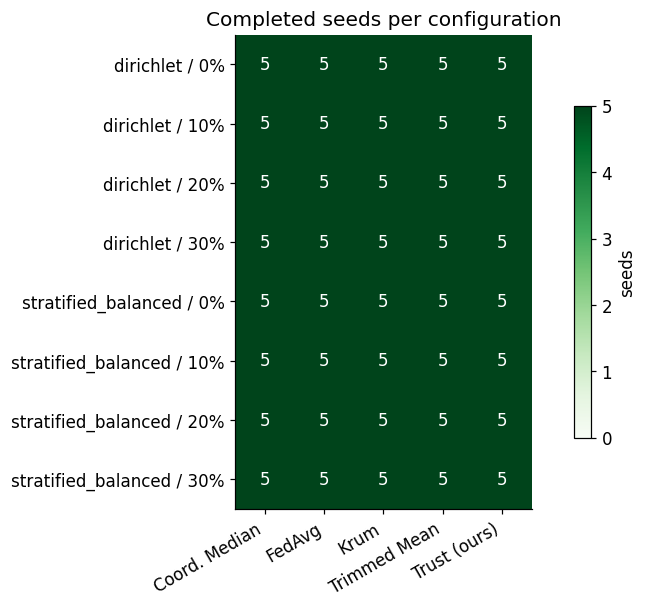


--- Figure 2 — Robustness frontier ---


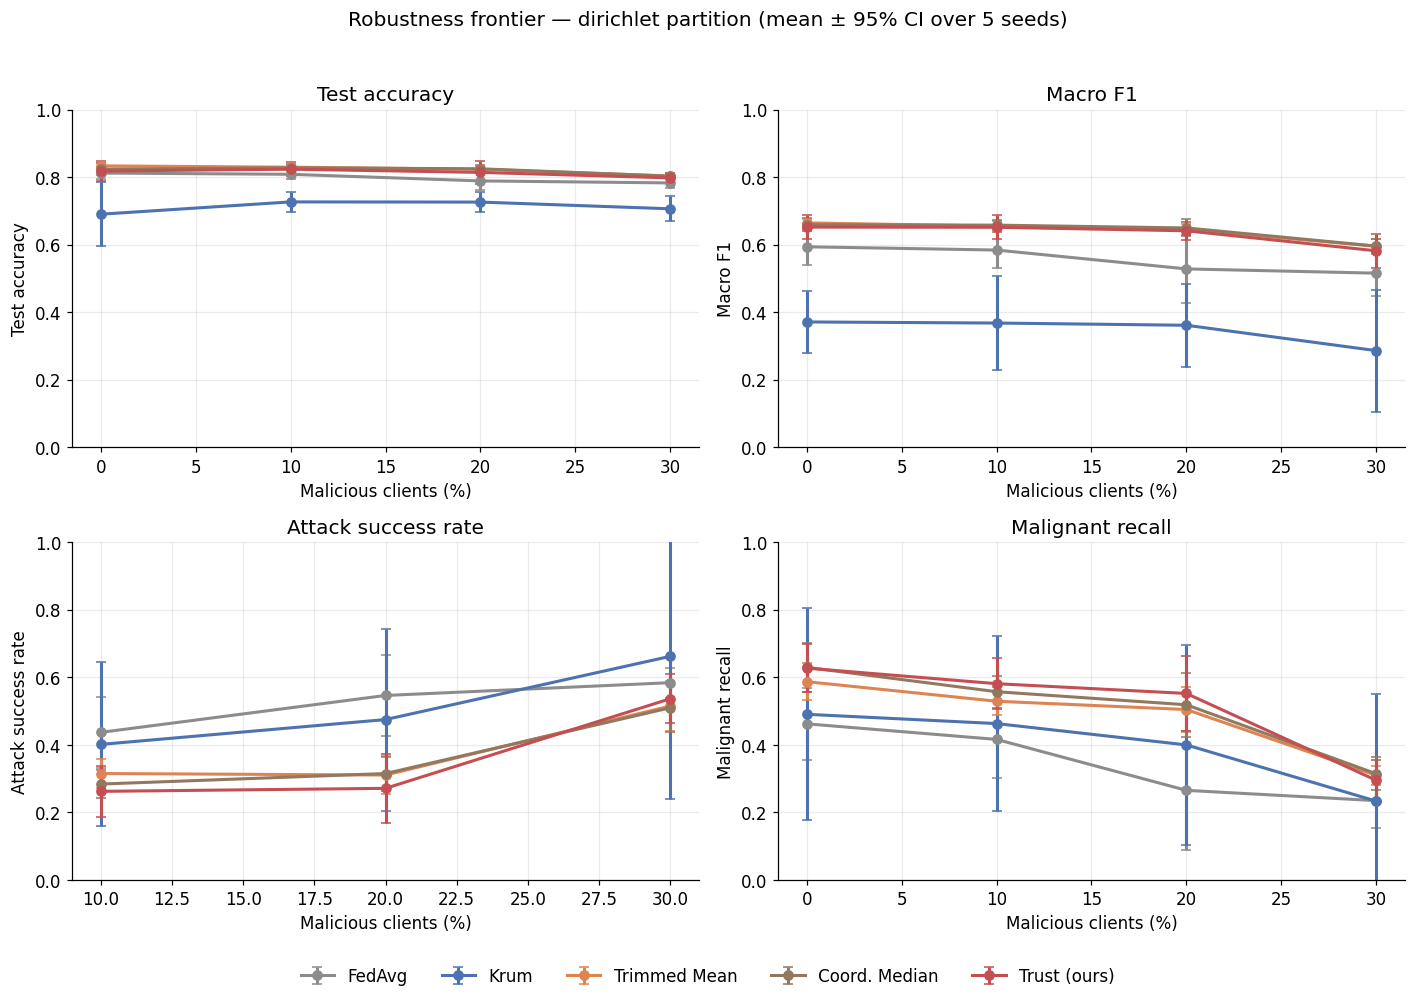

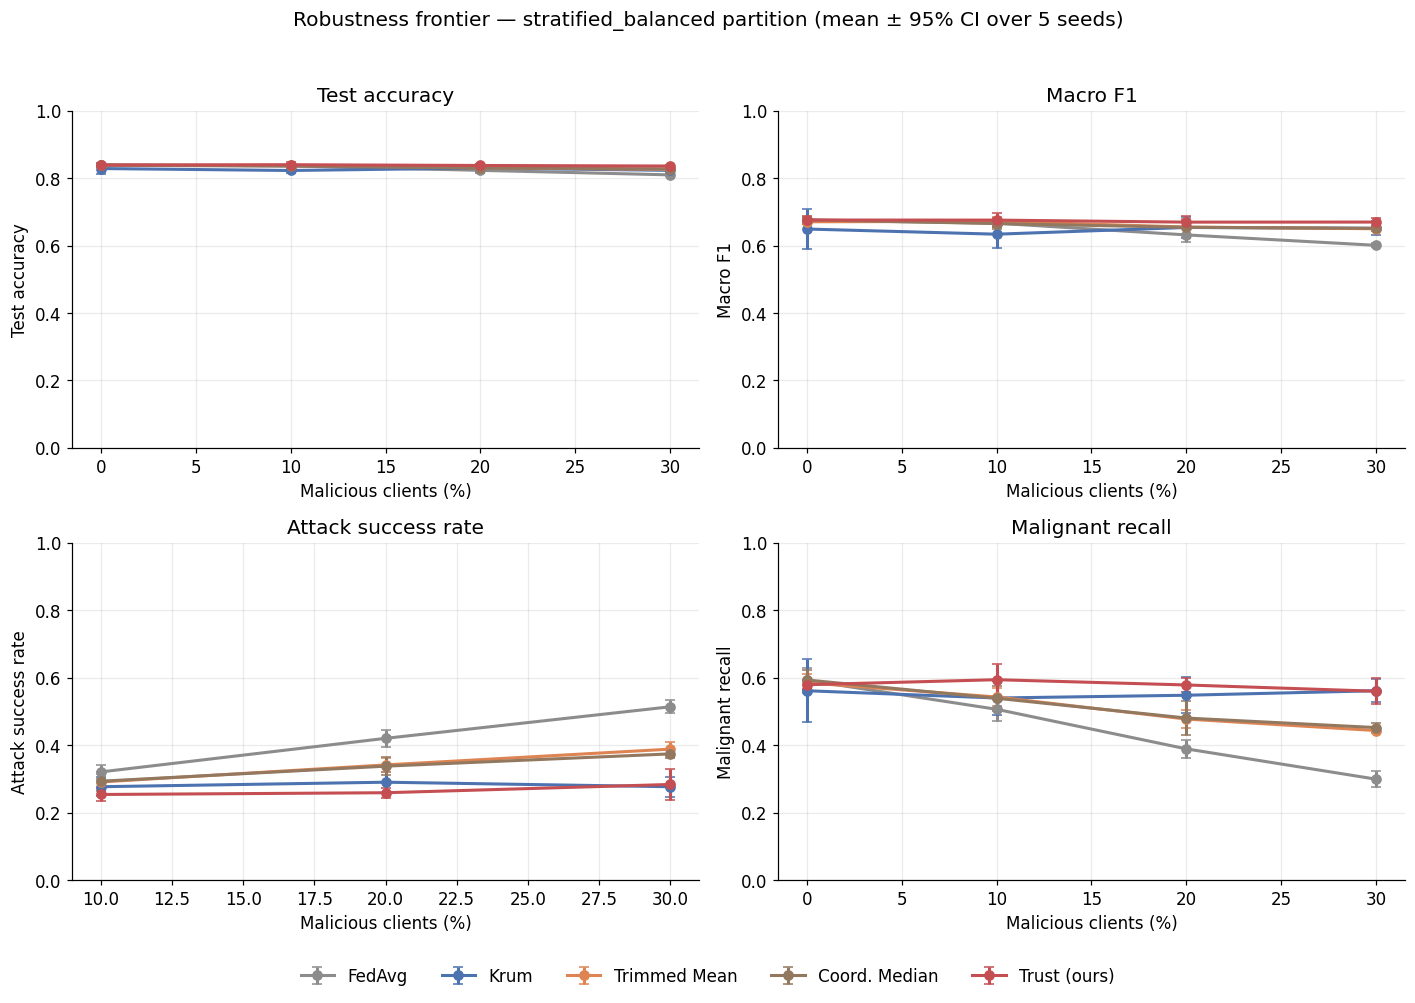


--- Figure 3 — Cost of robustness ---


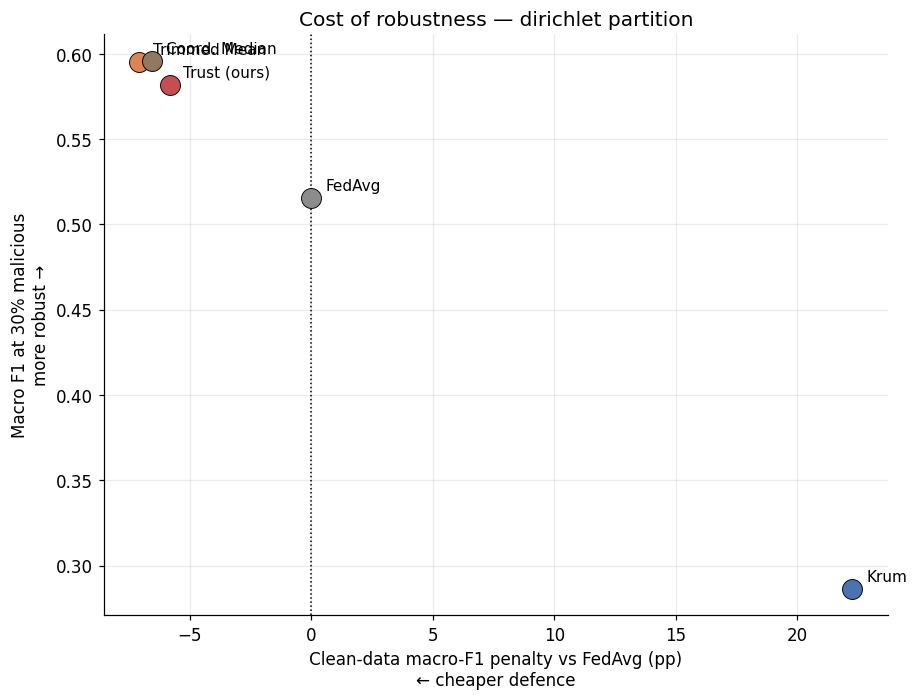

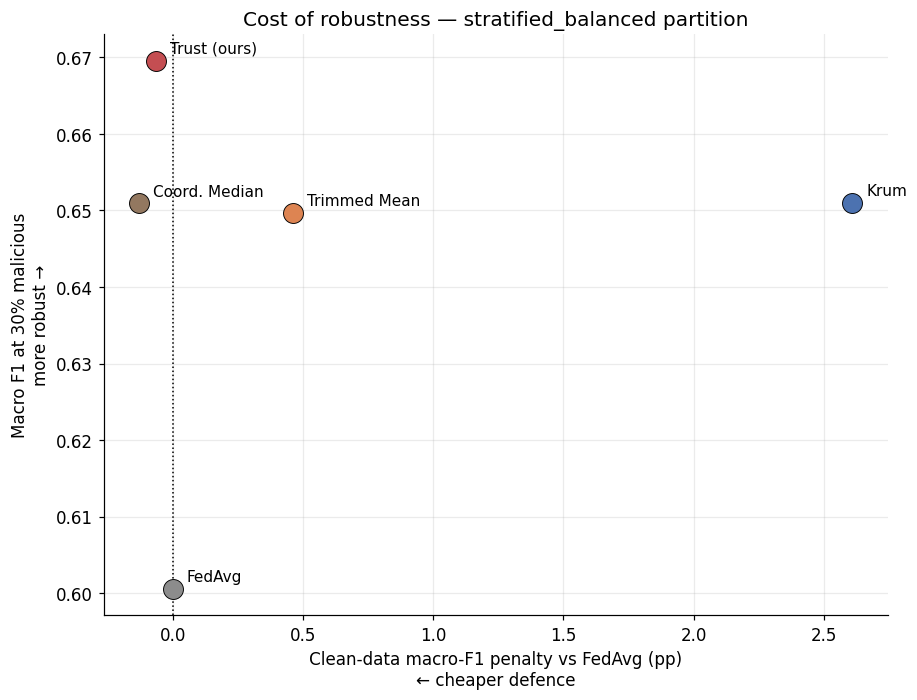


--- Table 1 — Headline results ---


,Partition,Malicious %,Aggregator,Seeds,Accuracy,Macro F1,Macro spec.,Malig. recall,ASR
0,dirichlet,0%,FedAvg,5,0.812 ± 0.014,0.594 ± 0.043,0.935 ± 0.009,0.462 ± 0.085,—
1,dirichlet,0%,Krum,5,0.690 ± 0.076,0.371 ± 0.074,0.922 ± 0.013,0.491 ± 0.253,—
2,dirichlet,0%,Trimmed Mean,5,0.834 ± 0.006,0.665 ± 0.009,0.951 ± 0.001,0.587 ± 0.043,—
3,dirichlet,0%,Coord. Median,5,0.824 ± 0.015,0.659 ± 0.016,0.952 ± 0.002,0.630 ± 0.059,—
4,dirichlet,0%,Trust (ours),5,0.818 ± 0.024,0.652 ± 0.029,0.952 ± 0.002,0.628 ± 0.058,—
5,dirichlet,10%,FedAvg,5,0.809 ± 0.012,0.584 ± 0.044,0.932 ± 0.008,0.416 ± 0.092,0.437 ± 0.084
6,dirichlet,10%,Krum,5,0.727 ± 0.023,0.368 ± 0.113,0.920 ± 0.018,0.463 ± 0.209,0.401 ± 0.195
7,dirichlet,10%,Trimmed Mean,5,0.830 ± 0.005,0.655 ± 0.013,0.946 ± 0.004,0.529 ± 0.034,0.315 ± 0.036
8,dirichlet,10%,Coord. Median,5,0.828 ± 0.008,0.658 ± 0.013,0.948 ± 0.004,0.558 ± 0.038,0.284 ± 0.033
9,dirichlet,10%,Trust (ours),5,0.824 ± 0.016,0.652 ± 0.028,0.949 ± 0.006,0.581 ± 0.061,0.262 ± 0.061



--- Figure 4 — ROC / PR curves ---


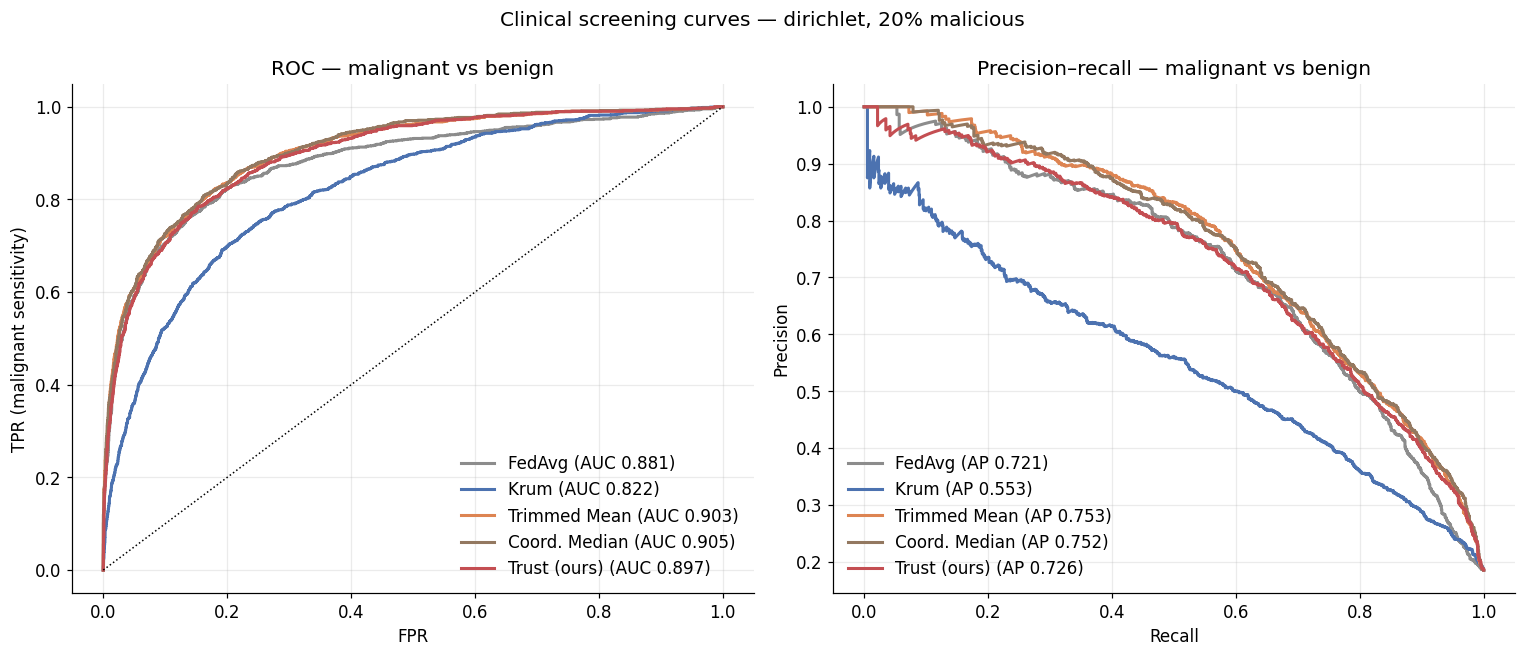

,Aggregator,ROC AUC,AP
0,FedAvg,0.8807,0.7209
1,Krum,0.8216,0.5530
2,Trimmed Mean,0.9029,0.7526
3,Coord. Median,0.9050,0.7523
4,Trust (ours),0.8969,0.7264



--- Figure 5 — Per-class recall heatmap ---


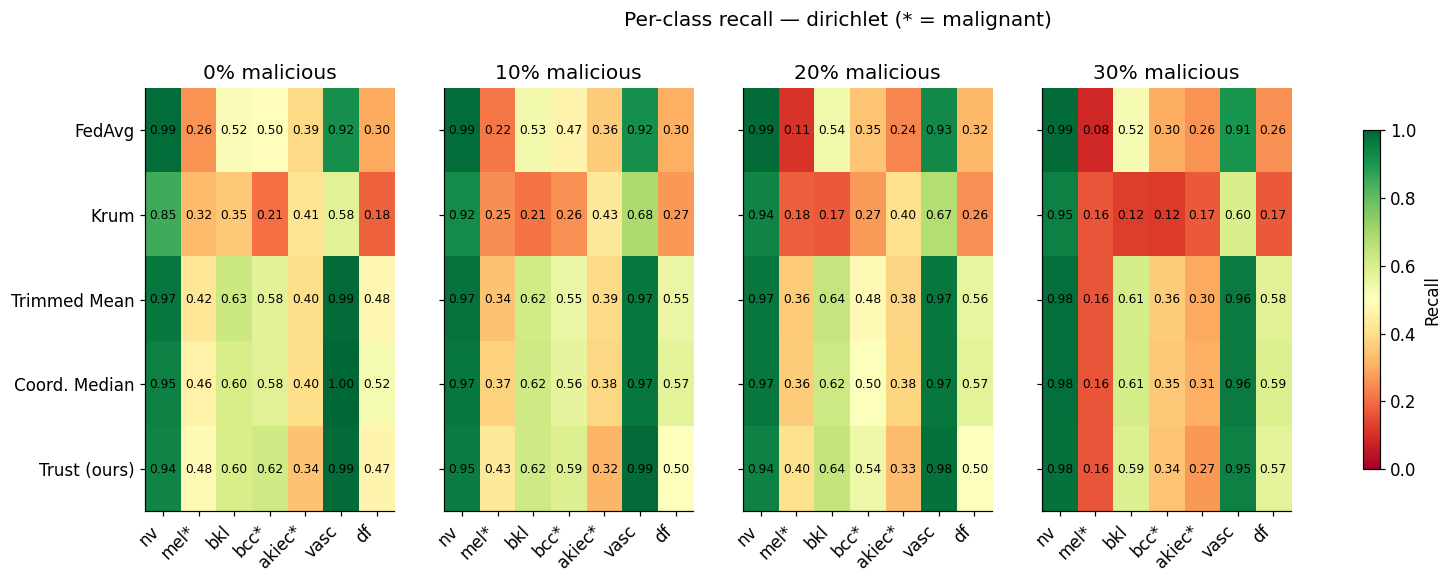


--- Figure 6 — Confusion-matrix differential ---


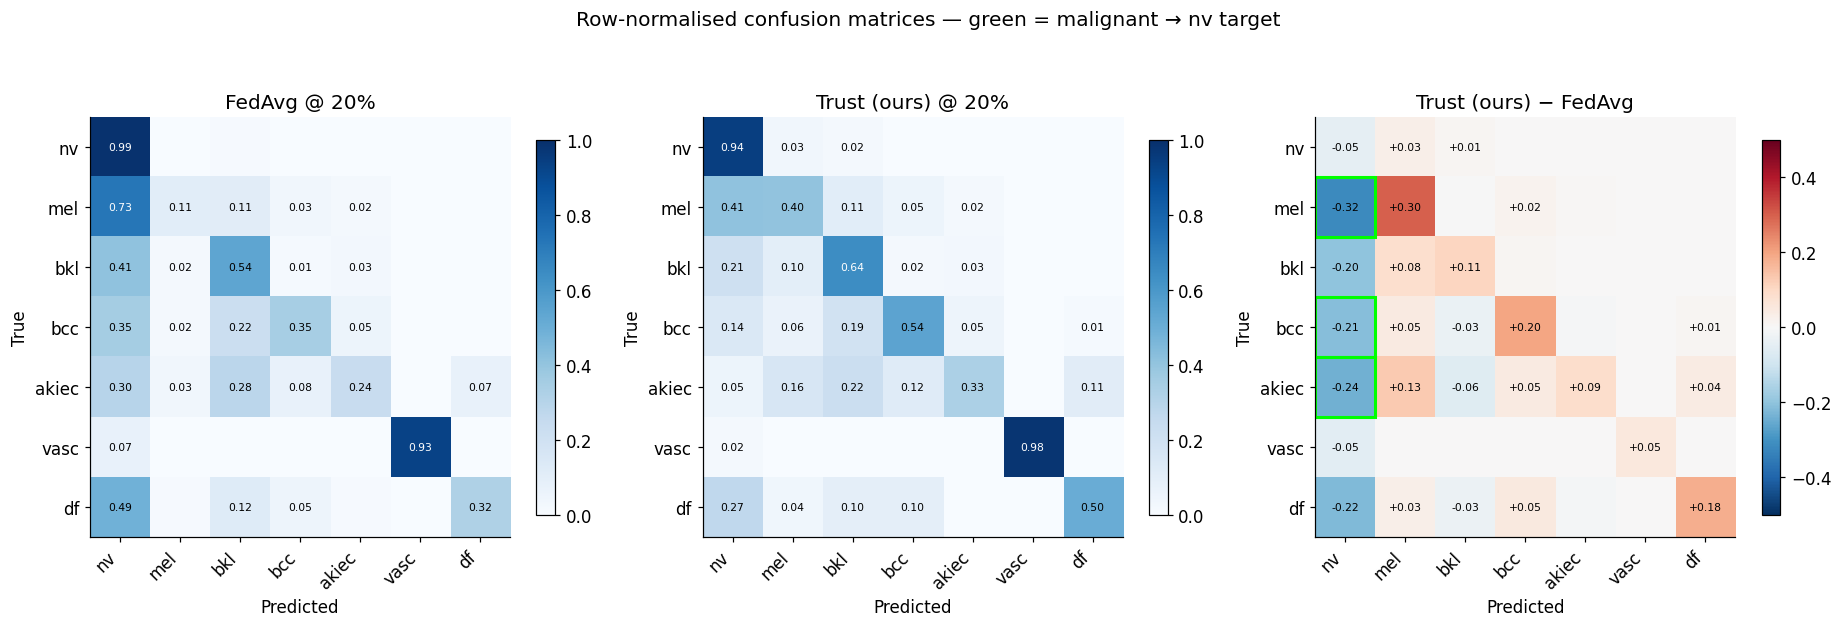


--- Figure 7 — Convergence and attack dynamics ---


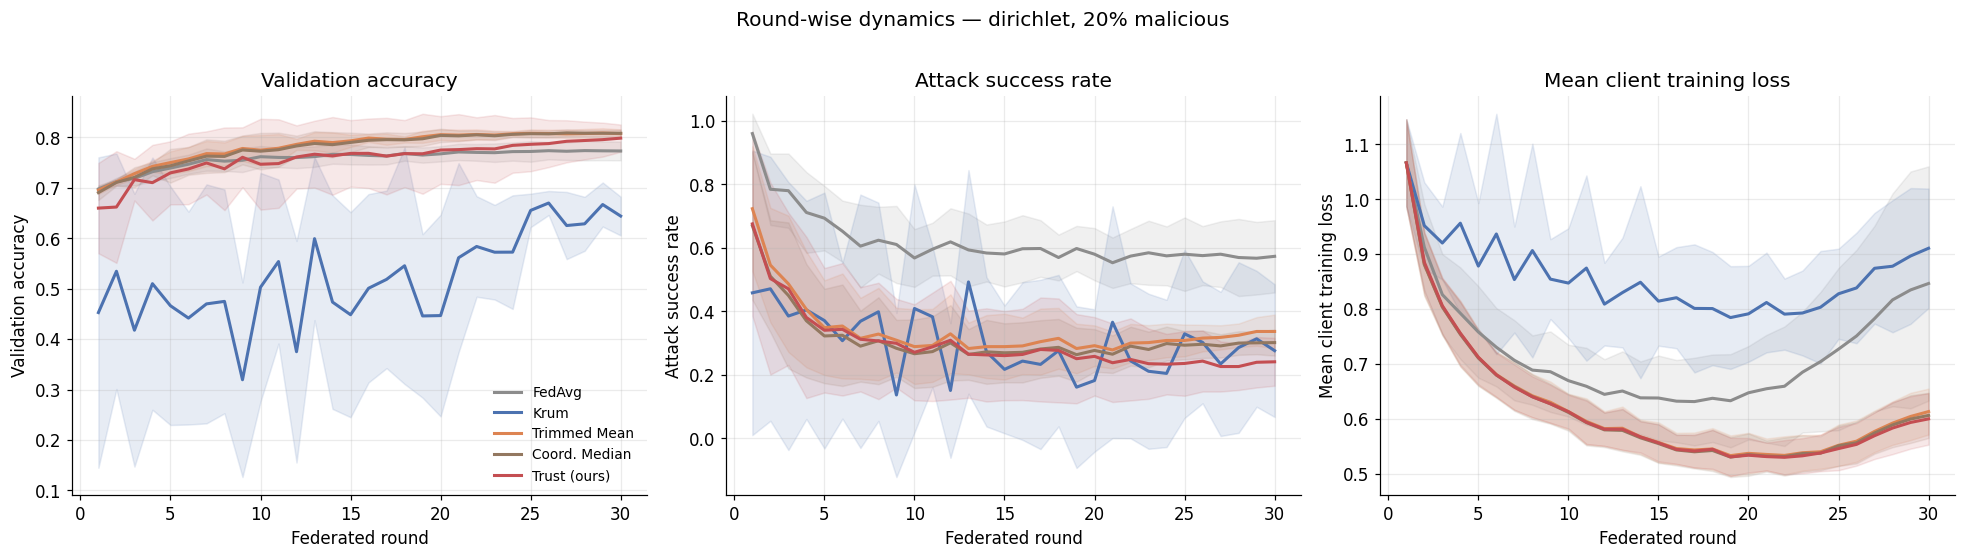


--- Figure 8 — Trust detector diagnostics ---


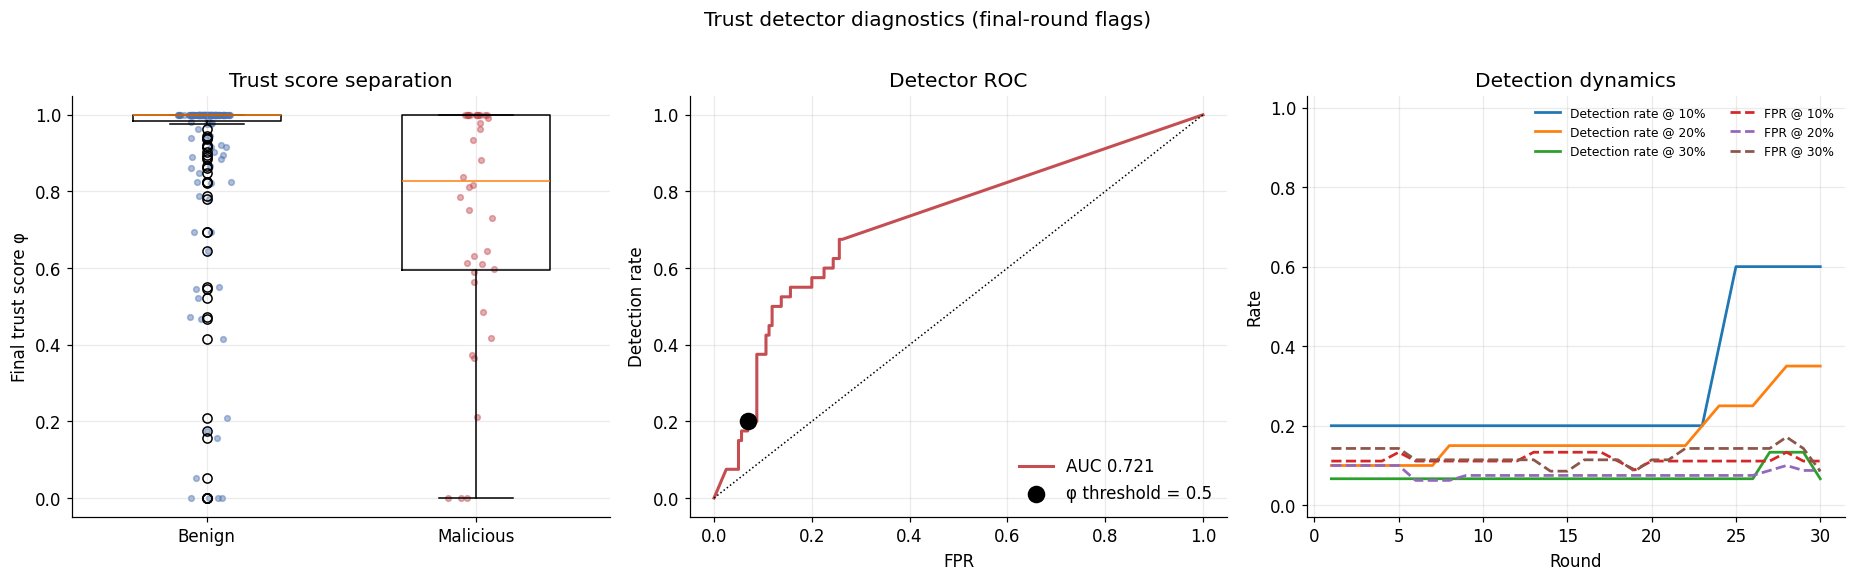

φ benign mean=0.914 n=160  |  φ malicious mean=0.740 n=40
Mann–Whitney p = 1.810e-07

--- Figure 9 — Detection precision/recall/F1 ---


detection_rate               \
                                                 mean    std count   
partition           malicious_fraction                               
dirichlet           0.1                         0.600  0.548     5   
                    0.2                         0.350  0.412    10   
                    0.3                         0.067  0.149     5   
stratified_balanced 0.1                         1.000  0.000     5   
                    0.2                         1.000  0.000     5   
                    0.3                         1.000  0.000     5   

                                       detection_precision               \
                                                      mean    std count   
partition           malicious_fraction                                    
dirichlet           0.1                              0.458  0.417     4   
                    0.2                              0.479  0.431     8   
                    0.3                              0.250  0.500     4   
stratified_balanced 0.1                              0.367  0.075     5   
                    0.2                              0.867  0.183     5   
                    0.3                              1.000  0.000     5   

                                       detection_f1               \
                                               mean    std count   
partition           malicious_fraction                             
dirichlet           0.1                       0.433  0.435     5   
                    0.2                       0.343  0.371    10   
                    0.3                       0.100  0.224     5   
stratified_balanced 0.1                       0.533  0.075     5   
                    0.2                       0.920  0.110     5   
                    0.3                       1.000  0.000     5   

                                       false_positive_rate               
                                                      mean    std count  
partition           malicious_fraction                                   
dirichlet           0.1                              0.111  0.111     5  
                    0.2                              0.088  0.084    10  
                    0.3                              0.086  0.078     5  
stratified_balanced 0.1                              0.200  0.050     5  
                    0.2                              0.050  0.068     5  
                    0.3                              0.000  0.000     5

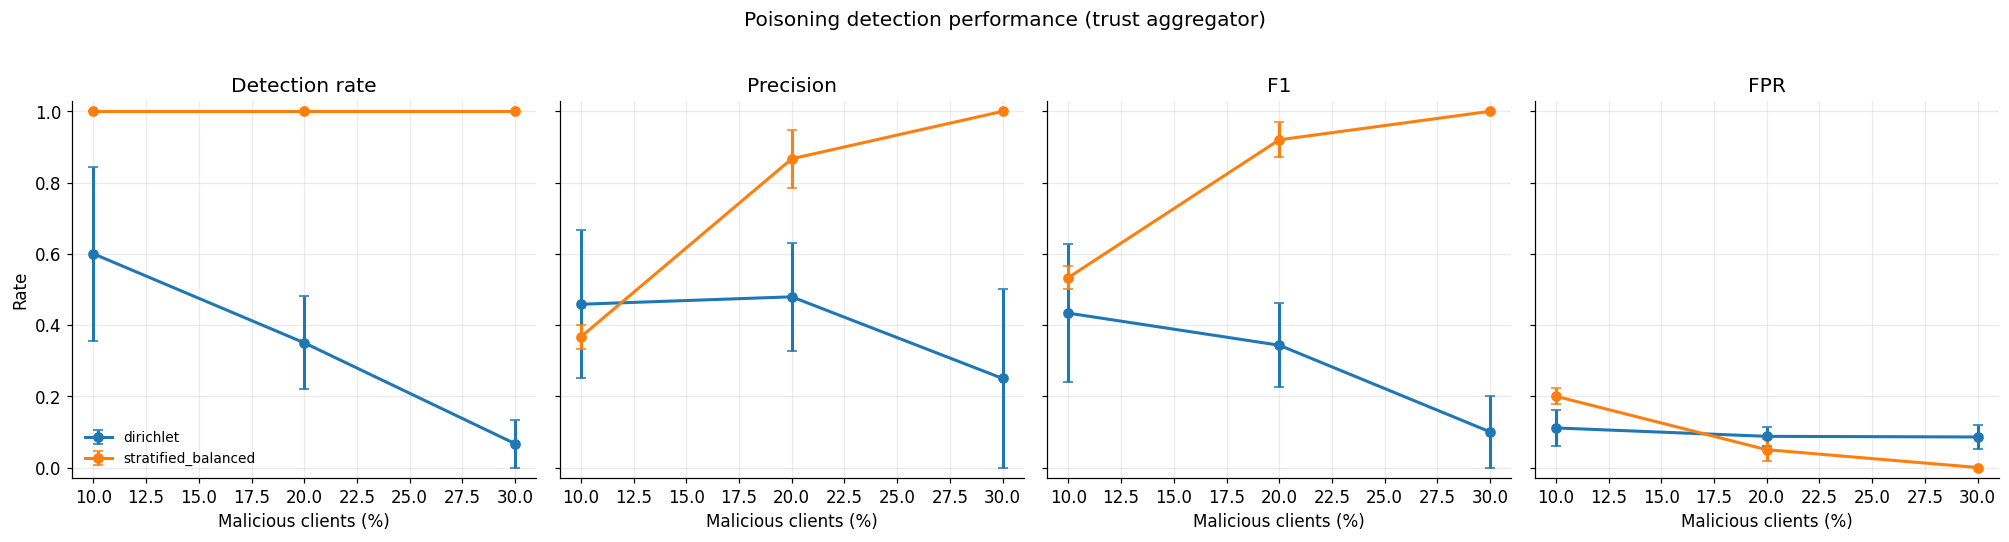


--- Figure 10 — Partition heterogeneity ---
dirichlet: entropy min=0.25 max=1.45 (uniform=1.95)
stratified_balanced: entropy min=1.14 max=1.15 (uniform=1.95)


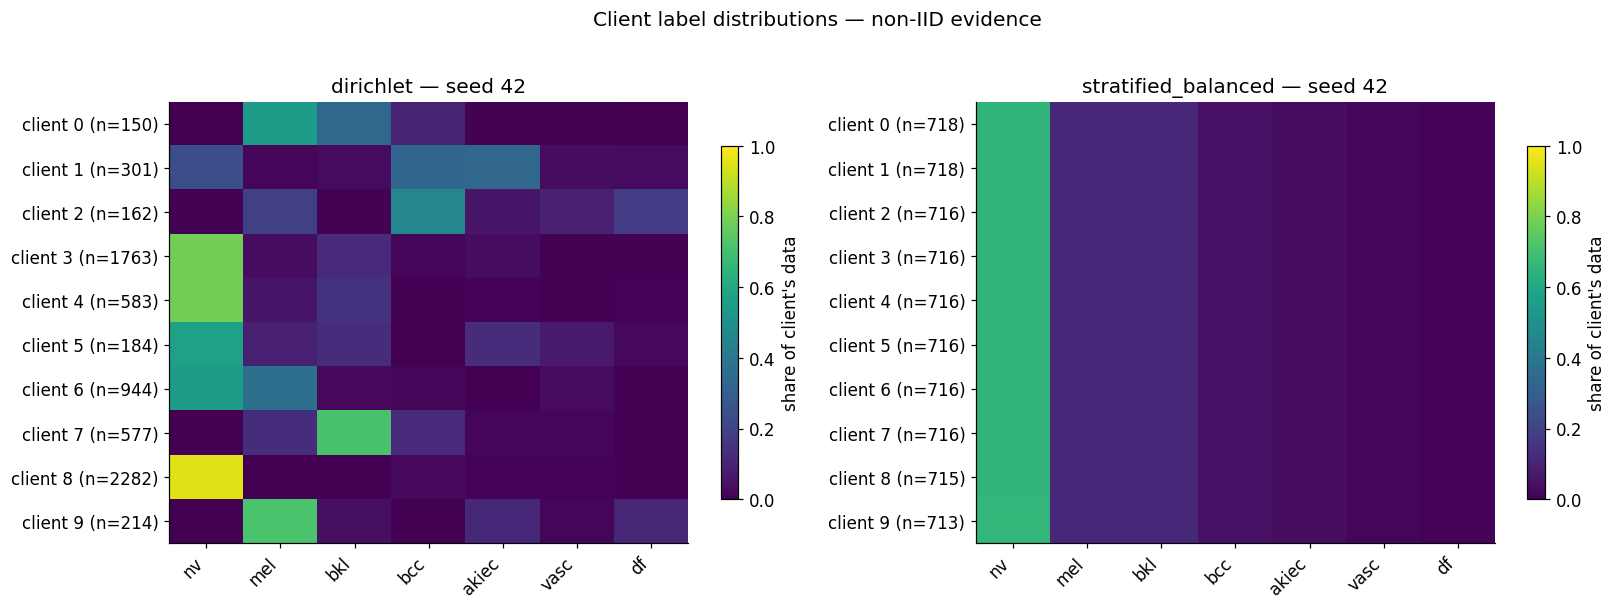


--- Figure 11 — Hyperparameter sensitivity ---


,test_macro_f1,test_asr,detection_rate,false_positive_rate
setting,,,,
ema_fast,0.6392,0.2654,0.6,0.075
ema_slow,0.6396,0.2929,0.6,0.075
flag_high,0.6412,0.2714,0.8,0.100
flag_low,0.6412,0.2714,0.4,0.075
mad_narrow,0.6382,0.2335,0.8,0.100
mad_wide,0.6378,0.3212,0.3,0.050
window_1,0.6412,0.2714,0.4,0.050
window_10,0.6412,0.2714,0.7,0.100


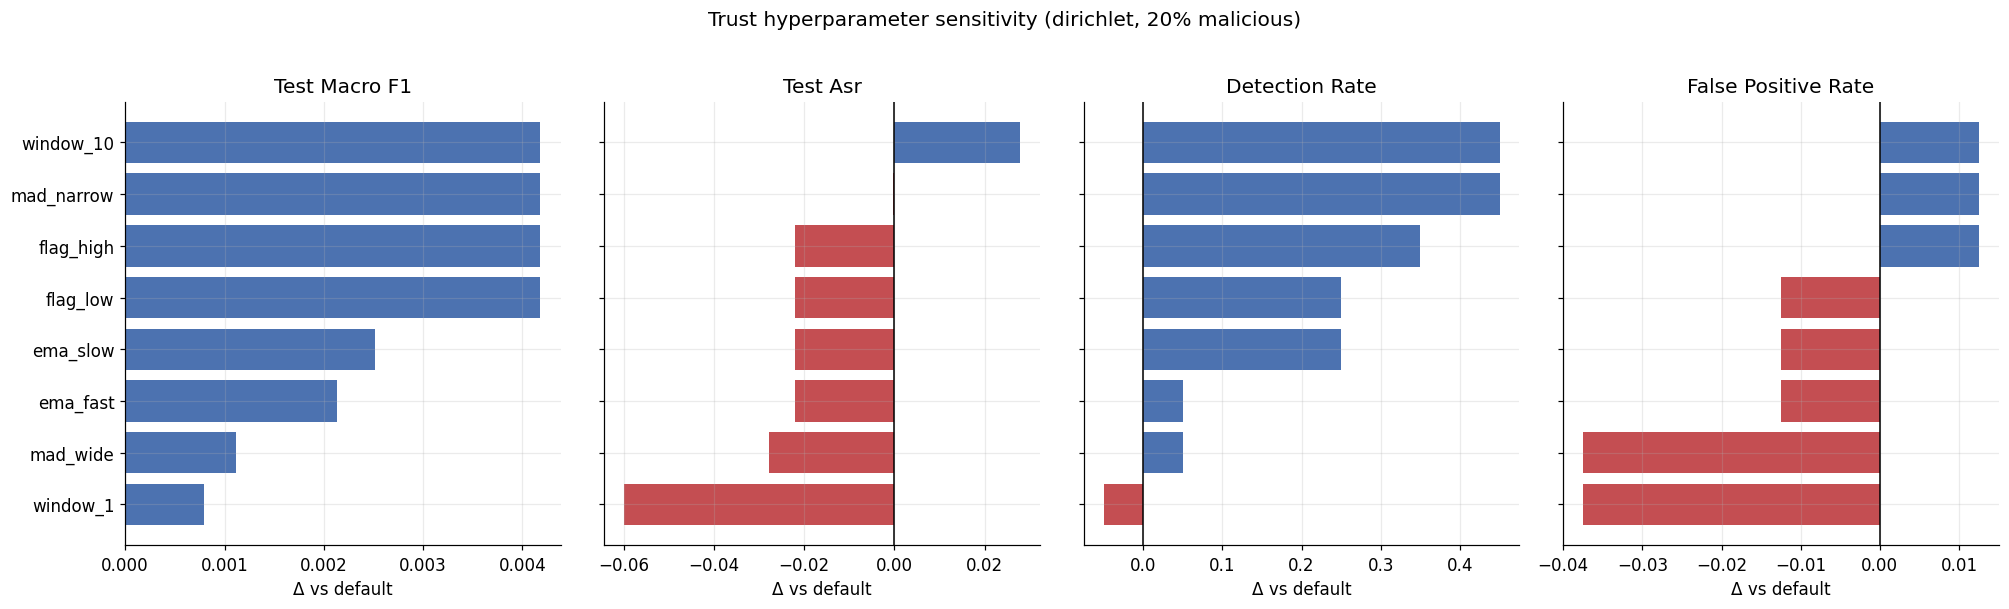


--- Figure 12 — Adaptive adversary ---


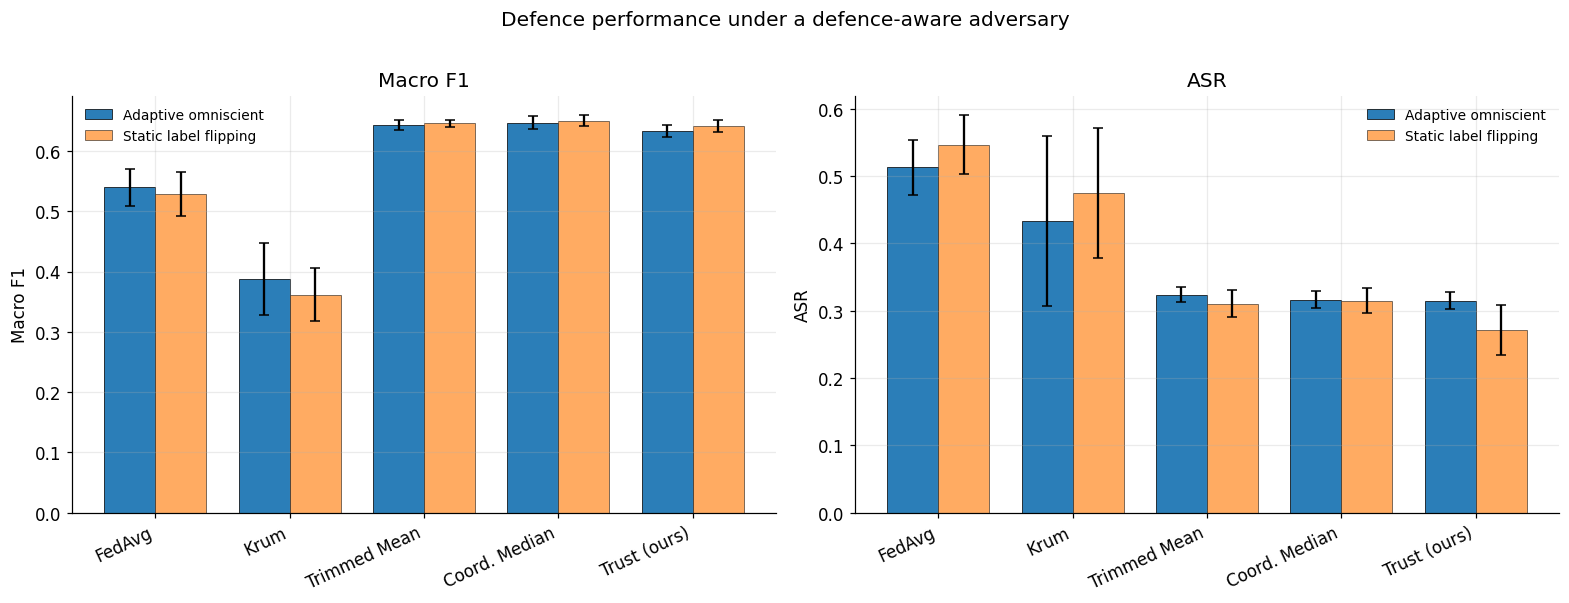

test_macro_f1         test_asr        
                                                 mean     std     mean     std
threat                aggregation                                             
Adaptive omniscient   coordinate_median        0.6467  0.0236   0.3167  0.0288
                      fedavg                   0.5396  0.0695   0.5130  0.0908
                      krum                     0.3881  0.1340   0.4335  0.2816
                      trimmed_mean             0.6432  0.0182   0.3242  0.0250
                      trust                    0.6329  0.0210   0.3152  0.0292
Static label flipping coordinate_median        0.6496  0.0204   0.3152  0.0406
                      fedavg                   0.5283  0.0818   0.5465  0.0976
                      krum                     0.3614  0.0987   0.4751  0.2170
                      trimmed_mean             0.6458  0.0131   0.3108  0.0443
                      trust                    0.6412  0.0220   0.2714  0.0816


--- Table 2 — Paired significance tests ---


,Partition,Malicious %,Comparison,n pairs,Mean Δ,Cohen dz,t p,Wilcoxon p,Holm p,Significant (α=.05)
0,dirichlet,0%,Trust (ours) vs Coord. Median,5,-0.0071,-0.523,0.30753,0.3125,1.00000,no
1,dirichlet,0%,Trust (ours) vs FedAvg,5,0.0583,1.253,0.04876,0.0625,1.00000,no
2,dirichlet,0%,Trust (ours) vs Krum,5,0.2810,3.279,0.00184,0.0625,0.05527,no
3,dirichlet,0%,Trust (ours) vs Trimmed Mean,5,-0.0125,-0.523,0.30682,0.3125,1.00000,no
4,dirichlet,10%,Trust (ours) vs Coord. Median,5,-0.0063,-0.358,0.46849,0.6250,1.00000,no
5,dirichlet,10%,Trust (ours) vs FedAvg,5,0.0675,1.216,0.05300,0.0625,1.00000,no
6,dirichlet,10%,Trust (ours) vs Krum,5,0.2837,2.315,0.00663,0.0625,0.18552,no
7,dirichlet,10%,Trust (ours) vs Trimmed Mean,5,-0.0034,-0.176,0.71339,0.6250,1.00000,no
8,dirichlet,20%,Trust (ours) vs Coord. Median,5,-0.0084,-0.552,0.28496,0.6250,1.00000,no
9,dirichlet,20%,Trust (ours) vs FedAvg,5,0.1129,1.180,0.05764,0.1250,1.00000,no



--- Figure 13 — Compute cost ---


mean_round_seconds       total_seconds       
                                mean   std          mean    std
aggregation                                                    
fedavg                         62.03  1.60       1860.96  47.99
krum                           62.88  1.48       1886.35  44.48
trimmed_mean                   62.68  1.45       1880.36  43.44
coordinate_median              62.70  1.49       1881.10  44.66
trust                          62.66  1.31       1879.79  39.32

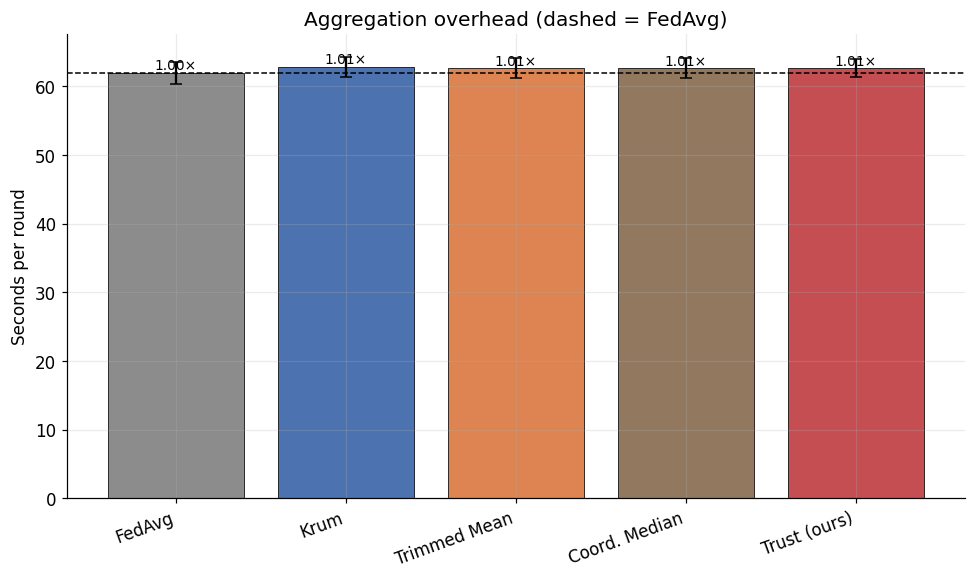

Total study compute: 138.2 GPU-hours across 265 runs / 7950 rounds.

--- Dashboard — self-contained HTML summary ---
Dashboard -> /content/drive/MyDrive/FedResViT_G4_Pass/examiner_figures/fedresvit_dashboard.html  (15 figures embedded)

DEFENSE SUITE — RUN SUMMARY


,Section,Status,Note
0,Figure 1 — Study coverage and provenance audit,OK,
1,Figure 2 — Robustness frontier,OK,
2,Figure 3 — Cost of robustness,OK,
3,Table 1 — Headline results,OK,
4,Figure 4 — ROC / PR curves,OK,
5,Figure 5 — Per-class recall heatmap,OK,
6,Figure 6 — Confusion-matrix differential,OK,
7,Figure 7 — Convergence and attack dynamics,OK,
8,Figure 8 — Trust detector diagnostics,OK,
9,Figure 9 — Detection precision/recall/F1,OK,


16/16 sections generated. Outputs in: /content/drive/MyDrive/FedResViT_G4_Pass/examiner_figures


In [26]:
# ================================================================================
# FED-RESVIT — COMPLETE DEFENSE SUITE (single cell)
# --------------------------------------------------------------------------------
# Generates every figure, table and the HTML dashboard needed to defend the study,
# in one pass, from completed study artifacts only. Nothing here retrains anything
# or writes into STUDY_ROOT/runs/ — every operation is read-only against completed
# runs. Requires `collect_results` and `STUDY_ROOT` to already exist in the kernel.
#
# Produces, in <OUTPUT_DIR>/examiner_figures/:
#   fig01 Coverage & provenance         fig08 Trust detector diagnostics
#   fig02 Robustness frontier            fig09 Detection precision/recall/F1
#   fig03 Cost of robustness             fig10 Partition heterogeneity
#   table01 Headline results (CSV+TeX)   fig11 Hyperparameter sensitivity
#   fig04 ROC / PR curves                fig12 Adaptive adversary
#   fig05 Per-class recall               table02 Paired significance tests
#   fig06 Confusion differential         fig13 Compute cost
#   fig07 Convergence dynamics           fedresvit_dashboard.html
# ================================================================================

import json, base64, traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from IPython.display import display

# ---------------------------------------------------------------------- A0 setup
FIG_DIR = Path(STUDY_ROOT).parent / "examiner_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASS_ORDER_FIG   = ["nv", "mel", "bkl", "bcc", "akiec", "vasc", "df"]
MALIGNANT_FIG     = ["mel", "bcc", "akiec"]
MALIGNANT_IDX_FIG = [CLASS_ORDER_FIG.index(c) for c in MALIGNANT_FIG]
TARGET_BENIGN_FIG = CLASS_ORDER_FIG.index("nv")

AGG_ORDER = ["fedavg", "krum", "multi_krum", "trimmed_mean", "coordinate_median", "trust"]
AGG_LABEL = {"fedavg": "FedAvg", "krum": "Krum", "multi_krum": "Multi-Krum",
             "trimmed_mean": "Trimmed Mean", "coordinate_median": "Coord. Median",
             "trust": "Trust (ours)"}
AGG_COLOR = {"fedavg": "#8c8c8c", "krum": "#4c72b0", "multi_krum": "#64b5cd",
             "trimmed_mean": "#dd8452", "coordinate_median": "#937860", "trust": "#c44e52"}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "legend.frameon": False,
})


def load_results():
    df = collect_results(STUDY_ROOT)
    if df.empty:
        raise ValueError(f"No completed runs under {STUDY_ROOT}")
    df = df.rename(columns={"test_detection_rate": "detection_rate",
                            "test_false_positive_rate": "false_positive_rate"})
    if {"detector_tp", "detector_fp", "detector_fn"}.issubset(df.columns):
        tp = df["detector_tp"].astype(float); fp = df["detector_fp"].astype(float)
        fn = df["detector_fn"].astype(float)
        df["detection_precision"] = np.where(tp + fp > 0, tp / (tp + fp), np.nan)
        df["detection_f1"] = np.where(2 * tp + fp + fn > 0, 2 * tp / (2 * tp + fp + fn), np.nan)
    return df


def main_study(df):
    return df[(df["setting"] == "default")
              & (df["attack"].isin(["none", "targeted_label_flipping"]))].copy()


def aggs_present(values):
    seen = set(values)
    return [a for a in AGG_ORDER if a in seen]


def label(a):
    return AGG_LABEL.get(a, a)


def artifact(row, column=None, name=None):
    """Resolve an artifact relative to artifact_dir (robust to moved/re-mounted study roots)."""
    folder = Path(row["artifact_dir"])
    if name is None:
        name = Path(str(row[column])).name
    path = folder / name
    return path if path.exists() else None


def mean_ci(series, confidence=0.95):
    s = pd.Series(series).dropna().astype(float)
    if len(s) == 0:
        return np.nan, np.nan
    if len(s) == 1:
        return float(s.iloc[0]), 0.0
    half = stats.t.ppf(0.5 + confidence / 2, len(s) - 1) * s.sem()
    return float(s.mean()), float(half)


def save_fig(fig, stem):
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight")


def class_name_map(df, partition):
    """Map short class codes -> the full names used as row labels in classification_report.csv.

    The runner builds reports with target_names=[CLASS_NAMES[c] for c in CLASS_ORDER], so
    reports are indexed by full names, not the short codes used everywhere else in this suite.
    """
    if "CLASS_NAMES" in globals():
        return {code: CLASS_NAMES[code] for code in CLASS_ORDER_FIG}
    probe_row = df[df["partition"] == partition].iloc[0]
    probe_path = artifact(probe_row, column="classification_report_path")
    if probe_path is None:
        return None
    probe = pd.read_csv(probe_path, index_col=0)
    class_rows = [c for c in probe.index if c not in ("accuracy", "macro avg", "weighted avg")]
    if len(class_rows) != len(CLASS_ORDER_FIG):
        return None
    return dict(zip(CLASS_ORDER_FIG, class_rows))


results_df = load_results()
main = main_study(results_df)
print("=" * 88)
print("FED-RESVIT DEFENSE SUITE")
print(f"Completed runs: {len(results_df)}  |  seeds: {results_df['seed'].nunique()}  |  "
      f"partitions: {sorted(results_df['partition'].unique())}")
print(f"Figures -> {FIG_DIR}")
print("=" * 88)

SCOREBOARD = []


def run_section(title, fn):
    print(f"\n--- {title} ---")
    try:
        fn()
        SCOREBOARD.append((title, "OK", ""))
    except Exception as e:
        SCOREBOARD.append((title, "SKIPPED", f"{type(e).__name__}: {e}"))
        print(f"  [skipped] {type(e).__name__}: {e}")


# ============================================================ Fig 1
def fig01():
    coverage = (main.groupby(["partition", "malicious_fraction", "aggregation"])["seed"]
                .nunique().unstack("aggregation").fillna(0).astype(int))
    display(coverage)
    expected = int(main["seed"].nunique())
    missing = coverage[coverage < expected].stack().dropna()
    if len(missing):
        print(f"Incomplete cells (expected {expected} seeds):")
        display(missing.rename("seeds_present").to_frame())
    else:
        print(f"Grid complete: {expected} seeds in every configuration.")

    fig, ax = plt.subplots(figsize=(1.4 * coverage.shape[1] + 3, 0.45 * len(coverage) + 2))
    im = ax.imshow(coverage.values, cmap="Greens", vmin=0, vmax=max(expected, 1))
    ax.set_xticks(range(coverage.shape[1]))
    ax.set_xticklabels([label(c) for c in coverage.columns], rotation=30, ha="right")
    ax.set_yticks(range(len(coverage)))
    ax.set_yticklabels([f"{p} / {int(f * 100)}%" for p, f in coverage.index])
    for i in range(coverage.shape[0]):
        for j in range(coverage.shape[1]):
            ax.text(j, i, coverage.values[i, j], ha="center", va="center",
                    color="white" if coverage.values[i, j] > expected / 2 else "black")
    ax.set_title("Completed seeds per configuration"); ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.7, label="seeds")
    save_fig(fig, "fig01_coverage"); plt.show()

run_section("Figure 1 — Study coverage and provenance audit", fig01)


# ============================================================ Fig 2
def fig02():
    panels = [("test_accuracy", "Test accuracy", (0.0, 1.0)),
              ("test_macro_f1", "Macro F1", (0.0, 1.0)),
              ("test_asr", "Attack success rate", (0.0, 1.0)),
              ("test_malignant_binary_recall", "Malignant recall", (0.0, 1.0))]
    for partition, part_df in main.groupby("partition"):
        fig, axes = plt.subplots(2, 2, figsize=(13, 9))
        for ax, (metric, nice, ylim) in zip(axes.ravel(), panels):
            if metric not in part_df.columns:
                ax.set_visible(False); continue
            for agg in aggs_present(part_df["aggregation"]):
                sub = part_df[part_df["aggregation"] == agg]
                xs, means, halves = [], [], []
                for frac, series in sub.groupby("malicious_fraction")[metric]:
                    m, h = mean_ci(series)
                    if np.isnan(m):
                        continue
                    xs.append(frac * 100); means.append(m); halves.append(h)
                if not xs:
                    continue
                order = np.argsort(xs)
                ax.errorbar(np.array(xs)[order], np.array(means)[order],
                            yerr=np.array(halves)[order], marker="o", capsize=3, lw=2,
                            color=AGG_COLOR.get(agg), label=label(agg))
            ax.set_xlabel("Malicious clients (%)"); ax.set_ylabel(nice)
            ax.set_ylim(*ylim); ax.set_title(nice)
        handles, labels_ = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels_, loc="lower center", ncol=min(6, len(labels_)),
                   bbox_to_anchor=(0.5, -0.02))
        fig.suptitle(f"Robustness frontier — {partition} partition "
                     f"(mean ± 95% CI over {part_df['seed'].nunique()} seeds)", y=0.98)
        fig.tight_layout(rect=[0, 0.03, 1, 0.96])
        save_fig(fig, f"fig02_frontier_{partition}"); plt.show()

run_section("Figure 2 — Robustness frontier", fig02)


# ============================================================ Fig 3
def fig03():
    metric = "test_macro_f1"
    worst = main[main["malicious_fraction"] > 0]["malicious_fraction"].max()
    for partition, part_df in main.groupby("partition"):
        clean = part_df[part_df["malicious_fraction"] == 0].groupby("aggregation")[metric].mean()
        under = part_df[part_df["malicious_fraction"] == worst].groupby("aggregation")[metric].mean()
        if clean.empty or under.empty:
            print(f"{partition}: needs both a 0% and a {worst:.0%} arm; skipping."); continue
        reference = clean.get("fedavg", clean.max())
        fig, ax = plt.subplots(figsize=(8.5, 6.5))
        for agg in aggs_present(part_df["aggregation"]):
            if agg not in clean.index or agg not in under.index:
                continue
            penalty = (reference - clean[agg]) * 100
            ax.scatter(penalty, under[agg], s=170, color=AGG_COLOR.get(agg),
                       edgecolor="black", linewidth=0.6, zorder=3)
            ax.annotate(label(agg), (penalty, under[agg]),
                        textcoords="offset points", xytext=(9, 5), fontsize=10)
        ax.axvline(0, color="black", lw=1, ls=":")
        ax.set_xlabel("Clean-data macro-F1 penalty vs FedAvg (pp)\n← cheaper defence")
        ax.set_ylabel(f"Macro F1 at {worst:.0%} malicious\nmore robust →")
        ax.set_title(f"Cost of robustness — {partition} partition")
        fig.tight_layout(); save_fig(fig, f"fig03_cost_of_robustness_{partition}"); plt.show()

run_section("Figure 3 — Cost of robustness", fig03)


# ============================================================ Table 1
def table01():
    report_metrics = [(m, n) for m, n in
                      [("test_accuracy", "Accuracy"), ("test_macro_f1", "Macro F1"),
                       ("test_macro_specificity", "Macro spec."),
                       ("test_malignant_binary_recall", "Malig. recall"),
                       ("test_asr", "ASR")] if m in main.columns]
    rows = []
    for (partition, frac, agg), grp in main.groupby(["partition", "malicious_fraction", "aggregation"]):
        row = {"Partition": partition, "Malicious %": f"{frac:.0%}",
               "Aggregator": label(agg), "Seeds": grp["seed"].nunique()}
        for metric, nice in report_metrics:
            vals = grp[metric].dropna()
            row[nice] = "—" if vals.empty else f"{vals.mean():.3f} ± {vals.std(ddof=1):.3f}"
        rows.append(row)
    table = pd.DataFrame(rows)
    table["_agg"] = table["Aggregator"].map({label(a): i for i, a in enumerate(AGG_ORDER)}).fillna(99)
    table = table.sort_values(["Partition", "Malicious %", "_agg"]).drop(columns="_agg").reset_index(drop=True)
    display(table)
    table.to_csv(FIG_DIR / "table01_main_results.csv", index=False)
    (FIG_DIR / "table01_main_results.tex").write_text(
        table.to_latex(index=False, escape=True,
                       caption="Fed-ResViT main results (mean ± std over seeds).", label="tab:main"))

run_section("Table 1 — Headline results", table01)


# ============================================================ Fig 4
def fig04():
    TARGET_PARTITION, TARGET_FRACTION = "dirichlet", 0.2
    subset = main[(main["partition"] == TARGET_PARTITION) & (main["malicious_fraction"] == TARGET_FRACTION)]
    if subset.empty:
        raise ValueError(f"No runs for {TARGET_PARTITION} @ {TARGET_FRACTION:.0%}")
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))
    auc_rows = []
    for agg in aggs_present(subset["aggregation"]):
        y_true_all, y_score_all = [], []
        for _, run in subset[subset["aggregation"] == agg].iterrows():
            path = artifact(run, column="prediction_path")
            if path is None:
                continue
            with np.load(path) as data:
                y_true_all.append(np.isin(data["y_true"], MALIGNANT_IDX_FIG).astype(int))
                y_score_all.append(data["y_prob"][:, MALIGNANT_IDX_FIG].sum(axis=1))
        if not y_true_all:
            continue
        y_true_all = np.concatenate(y_true_all); y_score_all = np.concatenate(y_score_all)
        fpr, tpr, _ = roc_curve(y_true_all, y_score_all); roc_auc = auc(fpr, tpr)
        precision, recall, _ = precision_recall_curve(y_true_all, y_score_all)
        ap = average_precision_score(y_true_all, y_score_all)
        ax_roc.plot(fpr, tpr, lw=2, color=AGG_COLOR.get(agg), label=f"{label(agg)} (AUC {roc_auc:.3f})")
        ax_pr.plot(recall, precision, lw=2, color=AGG_COLOR.get(agg), label=f"{label(agg)} (AP {ap:.3f})")
        auc_rows.append({"Aggregator": label(agg), "ROC AUC": round(roc_auc, 4), "AP": round(ap, 4)})
    ax_roc.plot([0, 1], [0, 1], ls=":", color="black", lw=1)
    ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR (malignant sensitivity)")
    ax_roc.set_title("ROC — malignant vs benign"); ax_roc.legend(loc="lower right")
    ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
    ax_pr.set_title("Precision–recall — malignant vs benign"); ax_pr.legend(loc="lower left")
    fig.suptitle(f"Clinical screening curves — {TARGET_PARTITION}, {TARGET_FRACTION:.0%} malicious", y=0.99)
    fig.tight_layout()
    save_fig(fig, f"fig04_roc_pr_{TARGET_PARTITION}_{int(TARGET_FRACTION * 100)}"); plt.show()
    display(pd.DataFrame(auc_rows))

run_section("Figure 4 — ROC / PR curves", fig04)


# ============================================================ Fig 5
def fig05():
    TARGET_PARTITION = "dirichlet"
    name_map = class_name_map(main, TARGET_PARTITION)
    if name_map is None:
        raise ValueError("Could not resolve class-name mapping for classification reports.")
    rows = []
    for _, run in main[main["partition"] == TARGET_PARTITION].iterrows():
        path = artifact(run, column="classification_report_path")
        if path is None:
            continue
        report = pd.read_csv(path, index_col=0)
        for code in CLASS_ORDER_FIG:
            full = name_map[code]
            if full in report.index:
                rows.append({"aggregation": run["aggregation"], "malicious_fraction": run["malicious_fraction"],
                            "seed": run["seed"], "class": code, "recall": float(report.loc[full, "recall"])})
    if not rows:
        raise ValueError("No classification reports resolved.")
    per_class = pd.DataFrame(rows)
    fractions = sorted(per_class["malicious_fraction"].unique())
    fig, axes = plt.subplots(1, len(fractions), figsize=(4.2 * len(fractions), 5), sharey=True, squeeze=False)
    for ax, frac in zip(axes[0], fractions):
        pivot = (per_class[per_class["malicious_fraction"] == frac]
                 .pivot_table(index="aggregation", columns="class", values="recall", aggfunc="mean")
                 .reindex(index=aggs_present(per_class["aggregation"]), columns=CLASS_ORDER_FIG))
        im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(CLASS_ORDER_FIG)))
        ax.set_xticklabels([c + ("*" if c in MALIGNANT_FIG else "") for c in CLASS_ORDER_FIG],
                           rotation=45, ha="right")
        ax.set_yticks(range(len(pivot))); ax.set_yticklabels([label(a) for a in pivot.index])
        ax.set_title(f"{frac:.0%} malicious"); ax.grid(False)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                v = pivot.values[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=axes[0].tolist(), shrink=0.8, label="Recall")
    fig.suptitle(f"Per-class recall — {TARGET_PARTITION} (* = malignant)", y=1.02)
    save_fig(fig, f"fig05_per_class_recall_{TARGET_PARTITION}"); plt.show()

run_section("Figure 5 — Per-class recall heatmap", fig05)


# ============================================================ Fig 6
def fig06():
    TARGET_PARTITION, TARGET_FRACTION = "dirichlet", 0.2
    DEFENCE, BASELINE = "trust", "fedavg"

    def mean_confusion(agg):
        sel = main[(main["partition"] == TARGET_PARTITION) & (main["malicious_fraction"] == TARGET_FRACTION)
                   & (main["aggregation"] == agg)]
        mats = []
        for _, run in sel.iterrows():
            path = artifact(run, name="confusion_matrix.csv")
            if path is None:
                continue
            cm = pd.read_csv(path, index_col=0).reindex(index=CLASS_ORDER_FIG,
                                                        columns=CLASS_ORDER_FIG).values.astype(float)
            totals = cm.sum(axis=1, keepdims=True)
            mats.append(np.divide(cm, totals, out=np.zeros_like(cm), where=totals > 0))
        return np.mean(mats, axis=0) if mats else None

    cm_base, cm_def = mean_confusion(BASELINE), mean_confusion(DEFENCE)
    if cm_base is None or cm_def is None:
        raise ValueError("Missing confusion_matrix.csv for one of the aggregators.")

    fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
    specs = [(cm_base, f"{label(BASELINE)} @ {TARGET_FRACTION:.0%}", "Blues", 0, 1),
             (cm_def, f"{label(DEFENCE)} @ {TARGET_FRACTION:.0%}", "Blues", 0, 1),
             (cm_def - cm_base, f"{label(DEFENCE)} − {label(BASELINE)}", "RdBu_r", -0.5, 0.5)]
    for ax, (matrix, title, cmap, vmin, vmax) in zip(axes, specs):
        im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks(range(7)); ax.set_xticklabels(CLASS_ORDER_FIG, rotation=45, ha="right")
        ax.set_yticks(range(7)); ax.set_yticklabels(CLASS_ORDER_FIG)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title); ax.grid(False)
        for i in range(7):
            for j in range(7):
                if abs(matrix[i, j]) >= 0.01:
                    ax.text(j, i, f"{matrix[i, j]:+.2f}" if vmin < 0 else f"{matrix[i, j]:.2f}",
                            ha="center", va="center", fontsize=7,
                            color="white" if abs(matrix[i, j]) > 0.6 else "black")
        fig.colorbar(im, ax=ax, shrink=0.75)
    for idx in MALIGNANT_IDX_FIG:
        axes[2].add_patch(plt.Rectangle((TARGET_BENIGN_FIG - 0.5, idx - 0.5), 1, 1,
                                        fill=False, edgecolor="lime", lw=2))
    fig.suptitle("Row-normalised confusion matrices — green = malignant → nv target", y=1.02)
    fig.tight_layout(); save_fig(fig, "fig06_confusion_differential"); plt.show()

run_section("Figure 6 — Confusion-matrix differential", fig06)


# ============================================================ Fig 7
def fig07():
    TARGET_PARTITION, TARGET_FRACTION = "dirichlet", 0.2
    sel = main[(main["partition"] == TARGET_PARTITION) & (main["malicious_fraction"] == TARGET_FRACTION)]
    histories = []
    for _, run in sel.iterrows():
        path = artifact(run, name="round_history.csv")
        if path is None:
            continue
        hist = pd.read_csv(path); hist["aggregation"] = run["aggregation"]; hist["seed"] = run["seed"]
        histories.append(hist)
    if not histories:
        raise ValueError("No round_history.csv files resolved.")
    history = pd.concat(histories, ignore_index=True)
    panels = [(c, n) for c, n in [("val_accuracy", "Validation accuracy"), ("val_asr", "Attack success rate"),
                                  ("avg_train_loss", "Mean client training loss")] if c in history.columns]
    fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 5))
    axes = np.atleast_1d(axes)
    for ax, (column, nice) in zip(axes, panels):
        for agg in aggs_present(history["aggregation"]):
            sub = history[history["aggregation"] == agg]
            stat = sub.groupby("round")[column].agg(["mean", "std"]).reset_index()
            ax.plot(stat["round"], stat["mean"], lw=2, color=AGG_COLOR.get(agg), label=label(agg))
            ax.fill_between(stat["round"], stat["mean"] - stat["std"].fillna(0),
                            stat["mean"] + stat["std"].fillna(0), color=AGG_COLOR.get(agg), alpha=0.13)
        ax.set_xlabel("Federated round"); ax.set_ylabel(nice); ax.set_title(nice)
    axes[0].legend(loc="lower right", fontsize=9)
    fig.suptitle(f"Round-wise dynamics — {TARGET_PARTITION}, {TARGET_FRACTION:.0%} malicious", y=1.01)
    fig.tight_layout(); save_fig(fig, "fig07_convergence_dynamics"); plt.show()

run_section("Figure 7 — Convergence and attack dynamics", fig07)


# ============================================================ Fig 8
def fig08():
    TARGET_PARTITION = "dirichlet"
    trust_runs = results_df[(results_df["aggregation"] == "trust") & (results_df["partition"] == TARGET_PARTITION)
                            & (results_df["malicious_fraction"] > 0)
                            & (results_df["setting"] == "default")].copy()
    if trust_runs.empty:
        raise ValueError("No trust runs under attack for this partition.")
    phi_mal, phi_ben, scores, truths = [], [], [], []
    for _, run in trust_runs.iterrows():
        phi, malicious = run.get("trust_final_phi"), run.get("malicious_clients")
        if phi is None or malicious is None or (isinstance(phi, float) and np.isnan(phi)):
            continue
        phi = np.asarray(phi, dtype=float)
        truth = np.array([i in set(malicious) for i in range(len(phi))])
        phi_mal.extend(phi[truth]); phi_ben.extend(phi[~truth])
        scores.extend(1.0 - phi); truths.extend(truth.astype(int))
    if not phi_mal or not phi_ben:
        raise ValueError("Insufficient trust_final_phi data.")

    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
    axes[0].boxplot([phi_ben, phi_mal], widths=0.55)
    axes[0].set_xticks([1, 2]); axes[0].set_xticklabels(["Benign", "Malicious"])
    for i, values in enumerate([phi_ben, phi_mal], start=1):
        jitter = np.random.default_rng(0).normal(i, 0.045, len(values))
        axes[0].scatter(jitter, values, s=14, alpha=0.45, color="#4c72b0" if i == 1 else "#c44e52")
    axes[0].set_ylabel("Final trust score φ"); axes[0].set_title("Trust score separation")

    fpr, tpr, thresholds = roc_curve(truths, scores)
    axes[1].plot(fpr, tpr, lw=2, color="#c44e52", label=f"AUC {auc(fpr, tpr):.3f}")
    axes[1].plot([0, 1], [0, 1], ls=":", color="black", lw=1)
    op = np.argmin(np.abs(thresholds - 0.5))
    axes[1].scatter(fpr[op], tpr[op], s=110, zorder=3, color="black", label="φ threshold = 0.5")
    axes[1].set_xlabel("FPR"); axes[1].set_ylabel("Detection rate")
    axes[1].set_title("Detector ROC"); axes[1].legend(loc="lower right")

    histories = []
    for _, run in trust_runs.iterrows():
        path = artifact(run, name="round_history.csv")
        if path is None:
            continue
        hist = pd.read_csv(path); hist["malicious_fraction"] = run["malicious_fraction"]
        histories.append(hist)
    if histories:
        history = pd.concat(histories, ignore_index=True)
        for column, style, name in [("detection_rate_current", "-", "Detection rate"),
                                    ("false_positive_rate_current", "--", "FPR")]:
            if column not in history.columns:
                continue
            for frac, sub in history.groupby("malicious_fraction"):
                stat = sub.groupby("round")[column].mean()
                axes[2].plot(stat.index, stat.values, style, lw=1.8, label=f"{name} @ {frac:.0%}")
        axes[2].set_xlabel("Round"); axes[2].set_ylabel("Rate"); axes[2].set_ylim(-0.03, 1.03)
        axes[2].set_title("Detection dynamics"); axes[2].legend(fontsize=8, ncol=2)

    fig.suptitle("Trust detector diagnostics (final-round flags)", y=1.01)
    fig.tight_layout(); save_fig(fig, "fig08_detector_diagnostics"); plt.show()
    print(f"φ benign mean={np.mean(phi_ben):.3f} n={len(phi_ben)}  |  "
          f"φ malicious mean={np.mean(phi_mal):.3f} n={len(phi_mal)}")
    print("Mann–Whitney p =",
          f"{stats.mannwhitneyu(phi_ben, phi_mal, alternative='greater').pvalue:.3e}")

run_section("Figure 8 — Trust detector diagnostics", fig08)


# ============================================================ Fig 9
def fig09():
    detect = results_df[(results_df["malicious_fraction"] > 0) & results_df["detection_rate"].notna()
                        & (results_df["setting"] == "default")].copy()
    if detect.empty:
        raise ValueError("No runs with detector output.")
    metrics = [(m, n) for m, n in [("detection_rate", "Detection rate"), ("detection_precision", "Precision"),
                                   ("detection_f1", "F1"), ("false_positive_rate", "FPR")]
              if m in detect.columns]
    summary = detect.groupby(["partition", "malicious_fraction"])[[m for m, _ in metrics]] \
                     .agg(["mean", "std", "count"]).round(3)
    display(summary)
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.6 * len(metrics), 4.8), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (metric, nice) in zip(axes, metrics):
        for partition, sub in detect.groupby("partition"):
            stat = sub.groupby("malicious_fraction")[metric].agg(["mean", "sem"])
            ax.errorbar(stat.index * 100, stat["mean"], yerr=stat["sem"].fillna(0),
                        marker="o", capsize=3, lw=2, label=partition)
        ax.set_xlabel("Malicious clients (%)"); ax.set_title(nice); ax.set_ylim(-0.03, 1.03)
    axes[0].set_ylabel("Rate"); axes[0].legend(fontsize=9)
    fig.suptitle("Poisoning detection performance (trust aggregator)", y=1.02)
    fig.tight_layout(); save_fig(fig, "fig09_detection_performance"); plt.show()

run_section("Figure 9 — Detection precision/recall/F1", fig09)


# ============================================================ Fig 10
def fig10():
    clean = results_df[(results_df["malicious_fraction"] == 0) & (results_df["setting"] == "default")]
    if clean.empty:
        raise ValueError("No clean (0% malicious) run available.")
    fig, axes = plt.subplots(1, clean["partition"].nunique(),
                             figsize=(7.5 * clean["partition"].nunique(), 5.4), squeeze=False)
    for ax, (partition, part_df) in zip(axes[0], clean.groupby("partition")):
        run = part_df.iloc[0]
        path = artifact(run, name="clients.json")
        if path is None:
            ax.set_visible(False); continue
        counts = json.loads(path.read_text())["class_counts"]
        matrix = np.zeros((len(counts), len(CLASS_ORDER_FIG)))
        for cid, mapping in enumerate(counts):
            for key, value in mapping.items():
                matrix[cid, int(key)] = value
        shares = matrix / np.clip(matrix.sum(axis=1, keepdims=True), 1, None)
        im = ax.imshow(shares, cmap="viridis", aspect="auto", vmin=0, vmax=1)
        ax.set_xticks(range(len(CLASS_ORDER_FIG))); ax.set_xticklabels(CLASS_ORDER_FIG, rotation=45, ha="right")
        ax.set_yticks(range(len(counts)))
        ax.set_yticklabels([f"client {i} (n={int(matrix[i].sum())})" for i in range(len(counts))])
        ax.set_title(f"{partition} — seed {run['seed']}"); ax.grid(False)
        fig.colorbar(im, ax=ax, shrink=0.8, label="share of client's data")
        with np.errstate(divide="ignore", invalid="ignore"):
            entropy = -np.nansum(np.where(shares > 0, shares * np.log(shares), 0), axis=1)
        print(f"{partition}: entropy min={entropy.min():.2f} max={entropy.max():.2f} "
              f"(uniform={np.log(len(CLASS_ORDER_FIG)):.2f})")
    fig.suptitle("Client label distributions — non-IID evidence", y=1.02)
    fig.tight_layout(); save_fig(fig, "fig10_partition_heterogeneity"); plt.show()

run_section("Figure 10 — Partition heterogeneity", fig10)


# ============================================================ Fig 11
def fig11():
    sensitivity = results_df[(results_df["aggregation"] == "trust") & (results_df["setting"] != "default")].copy()
    baseline = results_df[(results_df["aggregation"] == "trust") & (results_df["setting"] == "default")
                          & (results_df["partition"] == "dirichlet") & (results_df["malicious_fraction"] == 0.2)]
    if sensitivity.empty:
        raise ValueError("No sensitivity-stage runs (set STUDY_STAGE='sensitivity' to populate).")
    metrics = [m for m in ["test_macro_f1", "test_asr", "detection_rate", "false_positive_rate"]
              if m in results_df.columns]
    reference = {m: baseline[m].mean() for m in metrics}
    summary = sensitivity.groupby("setting")[metrics].mean()
    display(summary.round(4))
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.6 * len(metrics), 5.4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, metric in zip(axes, metrics):
        deltas = (summary[metric] - reference[metric]).sort_values()
        colors = ["#c44e52" if d < 0 else "#4c72b0" for d in deltas]
        ax.barh(range(len(deltas)), deltas.values, color=colors)
        ax.set_yticks(range(len(deltas))); ax.set_yticklabels(deltas.index)
        ax.axvline(0, color="black", lw=1); ax.set_xlabel("Δ vs default")
        ax.set_title(metric.replace("_", " ").title())
    fig.suptitle("Trust hyperparameter sensitivity (dirichlet, 20% malicious)", y=1.02)
    fig.tight_layout(); save_fig(fig, "fig11_sensitivity"); plt.show()

run_section("Figure 11 — Hyperparameter sensitivity", fig11)


# ============================================================ Fig 12
def fig12():
    adaptive = results_df[results_df["attack"] == "adaptive_omniscient_blend"]
    if adaptive.empty:
        raise ValueError("No adaptive-stage runs (set STUDY_STAGE='adaptive' to populate).")
    fractions = sorted(adaptive["malicious_fraction"].unique())
    static = results_df[(results_df["attack"] == "targeted_label_flipping") & (results_df["partition"] == "dirichlet")
                        & (results_df["setting"] == "default") & (results_df["malicious_fraction"].isin(fractions))]
    comparison = pd.concat([static.assign(threat="Static label flipping"),
                            adaptive.assign(threat="Adaptive omniscient")])
    metrics = [(m, n) for m, n in [("test_macro_f1", "Macro F1"), ("test_asr", "ASR")] if m in comparison.columns]
    fig, axes = plt.subplots(1, len(metrics), figsize=(7.2 * len(metrics), 5.4))
    axes = np.atleast_1d(axes)
    order = aggs_present(comparison["aggregation"]); width = 0.38
    for ax, (metric, nice) in zip(axes, metrics):
        for offset, (threat, sub) in zip((-width / 2, width / 2), comparison.groupby("threat")):
            means = [sub[sub["aggregation"] == a][metric].mean() for a in order]
            errs = [sub[sub["aggregation"] == a][metric].sem() for a in order]
            ax.bar(np.arange(len(order)) + offset, means, width, yerr=errs, capsize=3, label=threat,
                   alpha=0.95 if "Adaptive" in threat else 0.65, edgecolor="black", linewidth=0.5)
        ax.set_xticks(range(len(order))); ax.set_xticklabels([label(a) for a in order], rotation=25, ha="right")
        ax.set_ylabel(nice); ax.set_title(nice); ax.legend(fontsize=9)
    fig.suptitle("Defence performance under a defence-aware adversary", y=1.01)
    fig.tight_layout(); save_fig(fig, "fig12_adaptive_adversary"); plt.show()
    display(comparison.groupby(["threat", "aggregation"])[[m for m, _ in metrics]].agg(["mean", "std"]).round(4))

run_section("Figure 12 — Adaptive adversary", fig12)


# ============================================================ Table 2
def table02():
    METRIC, REFERENCE = "test_macro_f1", "trust"
    rows = []
    for (partition, frac), grp in main.groupby(["partition", "malicious_fraction"]):
        pivot = grp.pivot_table(index="seed", columns="aggregation", values=METRIC)
        if REFERENCE not in pivot.columns:
            continue
        for agg in pivot.columns:
            if agg == REFERENCE:
                continue
            paired = pivot[[REFERENCE, agg]].dropna()
            if len(paired) < 3:
                continue
            diff = paired[REFERENCE] - paired[agg]
            _, t_p = stats.ttest_rel(paired[REFERENCE], paired[agg])
            try:
                w_p = stats.wilcoxon(paired[REFERENCE], paired[agg]).pvalue
            except ValueError:
                w_p = np.nan
            dz = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else np.nan
            rows.append({"Partition": partition, "Malicious %": f"{frac:.0%}",
                        "Comparison": f"{label(REFERENCE)} vs {label(agg)}", "n pairs": len(paired),
                        "Mean Δ": round(diff.mean(), 4), "Cohen dz": round(dz, 3), "t p": t_p, "Wilcoxon p": w_p})
    if not rows:
        raise ValueError("Not enough paired seeds for significance testing.")
    tests = pd.DataFrame(rows)
    order = np.argsort(tests["t p"].values); adjusted = np.empty(len(tests)); running = 0.0
    for rank, idx in enumerate(order):
        value = (len(tests) - rank) * tests["t p"].values[idx]
        running = max(running, min(value, 1.0)); adjusted[idx] = running
    tests["Holm p"] = adjusted
    tests["Significant (α=.05)"] = np.where(tests["Holm p"] < 0.05, "yes", "no")
    tests[["t p", "Wilcoxon p", "Holm p"]] = tests[["t p", "Wilcoxon p", "Holm p"]].round(5)
    display(tests)
    tests.to_csv(FIG_DIR / "table02_significance.csv", index=False)

run_section("Table 2 — Paired significance tests", table02)


# ============================================================ Fig 13
def fig13():
    records = []
    for _, run in results_df.iterrows():
        path = artifact(run, name="round_history.csv")
        if path is None:
            continue
        hist = pd.read_csv(path)
        if "round_seconds" not in hist.columns:
            continue
        records.append({"aggregation": run["aggregation"], "mean_round_seconds": hist["round_seconds"].mean(),
                        "total_seconds": hist["round_seconds"].sum(), "rounds": len(hist)})
    if not records:
        raise ValueError("No round_seconds recorded.")
    cost = pd.DataFrame(records)
    order = aggs_present(cost["aggregation"])
    display(cost.groupby("aggregation")[["mean_round_seconds", "total_seconds"]]
            .agg(["mean", "std"]).reindex(order).round(2))
    fedavg_ref = cost[cost["aggregation"] == "fedavg"]["mean_round_seconds"].mean()
    fig, ax = plt.subplots(figsize=(9, 5.4))
    means = [cost[cost["aggregation"] == a]["mean_round_seconds"].mean() for a in order]
    errs = [cost[cost["aggregation"] == a]["mean_round_seconds"].std(ddof=1) for a in order]
    bars = ax.bar([label(a) for a in order], means, yerr=errs, capsize=4,
                  color=[AGG_COLOR.get(a) for a in order], edgecolor="black", linewidth=0.5)
    if not np.isnan(fedavg_ref):
        ax.axhline(fedavg_ref, ls="--", color="black", lw=1)
        for bar, value in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value / fedavg_ref:.2f}×",
                    ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Seconds per round"); ax.set_title("Aggregation overhead (dashed = FedAvg)")
    plt.xticks(rotation=20, ha="right")
    fig.tight_layout(); save_fig(fig, "fig13_compute_cost"); plt.show()
    print(f"Total study compute: {cost['total_seconds'].sum() / 3600:.1f} GPU-hours "
          f"across {len(cost)} runs / {int(cost['rounds'].sum())} rounds.")

run_section("Figure 13 — Compute cost", fig13)


# ============================================================ Dashboard
def dashboard():
    headline_metrics = [m for m in ["test_accuracy", "test_macro_f1", "test_asr", "test_malignant_binary_recall"]
                        if m in main.columns]
    headline = (main.groupby(["partition", "malicious_fraction", "aggregation"])[headline_metrics]
                .mean().round(4).reset_index())
    worst = main[main["malicious_fraction"] > 0]["malicious_fraction"].max()
    attacked = main[main["malicious_fraction"] == worst]
    cards = [(label(a), attacked[attacked["aggregation"] == a]["test_macro_f1"].mean(),
             attacked[attacked["aggregation"] == a]["test_asr"].mean())
            for a in aggs_present(attacked["aggregation"])]
    figure_files = sorted(FIG_DIR.glob("fig*.png"))
    blocks = []
    for path in figure_files:
        encoded = base64.b64encode(path.read_bytes()).decode()
        title = path.stem.split("_", 1)[-1].replace("_", " ").title()
        blocks.append(f'<section><h2>{title}</h2><img src="data:image/png;base64,{encoded}"></section>')
    card_html = "".join(
        f'<div class="card"><h3>{name}</h3><p class="big">{f1:.3f}</p>'
        f'<p class="sub">macro F1 @ {worst:.0%} malicious</p><p class="sub">ASR {asr:.3f}</p></div>'
        for name, f1, asr in cards)
    html = f"""<!doctype html>
<html><head><meta charset="utf-8"><title>Fed-ResViT — Results Dashboard</title>
<style>
 body{{font-family:-apple-system,Segoe UI,Roboto,sans-serif;margin:0;background:#f6f7f9;color:#1c1e21}}
 header{{background:#1f2937;color:#fff;padding:28px 40px}}
 header h1{{margin:0;font-size:26px}} header p{{margin:6px 0 0;opacity:.75;font-size:14px}}
 main{{max-width:1180px;margin:0 auto;padding:28px 20px 60px}}
 .cards{{display:flex;flex-wrap:wrap;gap:14px;margin-bottom:28px}}
 .card{{background:#fff;border-radius:10px;padding:16px 20px;flex:1 1 170px;box-shadow:0 1px 3px rgba(0,0,0,.09)}}
 .card h3{{margin:0 0 6px;font-size:13px;text-transform:uppercase;letter-spacing:.05em;color:#6b7280}}
 .big{{font-size:30px;font-weight:600;margin:0}} .sub{{font-size:12px;color:#6b7280;margin:2px 0 0}}
 section{{background:#fff;border-radius:10px;padding:20px;margin-bottom:22px;box-shadow:0 1px 3px rgba(0,0,0,.09)}}
 section h2{{margin:0 0 14px;font-size:17px}} img{{width:100%;height:auto;border-radius:6px}}
 table{{border-collapse:collapse;width:100%;font-size:13px}}
 th,td{{border-bottom:1px solid #e5e7eb;padding:7px 9px;text-align:left}} th{{background:#f3f4f6}}
</style></head><body>
<header><h1>Fed-ResViT — Federated Robustness Results</h1>
<p>HAM10000 · {len(results_df)} completed runs · {main['seed'].nunique()} seeds ·
   generated {datetime.now():%Y-%m-%d %H:%M}</p></header>
<main><div class="cards">{card_html}</div>
<section><h2>Headline Results</h2>{headline.to_html(index=False, border=0)}</section>
{''.join(blocks)}</main></body></html>"""
    out = FIG_DIR / "fedresvit_dashboard.html"
    out.write_text(html, encoding="utf-8")
    print(f"Dashboard -> {out}  ({len(figure_files)} figures embedded)")

run_section("Dashboard — self-contained HTML summary", dashboard)


# ============================================================ Scoreboard
print("\n" + "=" * 88)
print("DEFENSE SUITE — RUN SUMMARY")
print("=" * 88)
scoreboard_df = pd.DataFrame(SCOREBOARD, columns=["Section", "Status", "Note"])
display(scoreboard_df)
ok = (scoreboard_df["Status"] == "OK").sum()
print(f"{ok}/{len(scoreboard_df)} sections generated. Outputs in: {FIG_DIR}")

## 22. Convergence curves (Manuscript Figure 5)

Plots use stored round histories from completed experiments; no interpolation is performed for missing runs.


Inspecting completed run:
  Run ID              = 53cd48a4e629ef1147a41fa2
  Partition           = stratified_balanced
  Malicious fraction  = 0.0
  Aggregation         = fedavg
  Seed                = 42


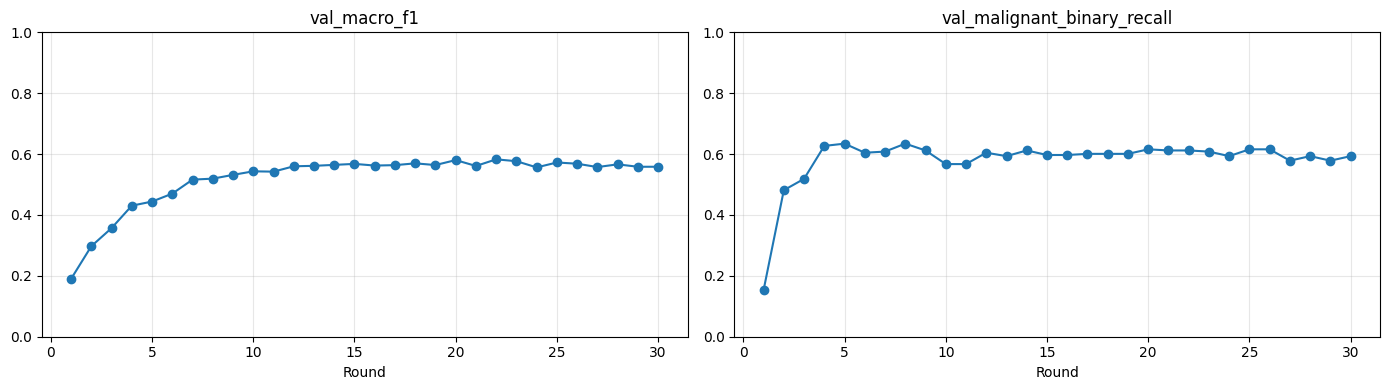

In [ ]:
# Inspect one exact completed run.
# If no run ID is specified, automatically select the first completed run.

SELECTED_RUN_ID = None

if SELECTED_RUN_ID is None:
    if results_df.empty:
        raise ValueError("No completed runs are available for inspection.")

    # Automatically select the first completed run
    selected = results_df.iloc[[0]]
    SELECTED_RUN_ID = selected.iloc[0]["run_id"]
else:
    selected = results_df[
        results_df.run_id == SELECTED_RUN_ID
    ]

    if len(selected) != 1:
        raise ValueError(
            f"Run ID '{SELECTED_RUN_ID}' was not found exactly once "
            f"in the completed results."
        )

print("Inspecting completed run:")
print("  Run ID              =", SELECTED_RUN_ID)
print("  Partition           =", selected.iloc[0]["partition"])
print("  Malicious fraction  =", selected.iloc[0]["malicious_fraction"])
print("  Aggregation         =", selected.iloc[0]["aggregation"])
print("  Seed                =", selected.iloc[0]["seed"])

run_folder = Path(selected.iloc[0].artifact_dir)
history_path = run_folder / "round_history.csv"

if not history_path.exists():
    raise FileNotFoundError(
        f"round_history.csv not found for selected run:\n{history_path}"
    )

history_df = pd.read_csv(history_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric in zip(
    axes,
    ["val_macro_f1", "val_malignant_binary_recall"]
):
    if metric not in history_df.columns:
        raise KeyError(
            f"Metric '{metric}' not found in round_history.csv. "
            f"Available columns: {list(history_df.columns)}"
        )

    ax.plot(history_df["round"], history_df[metric], marker="o")
    ax.set(
        title=metric,
        xlabel="Round",
        ylim=(0, 1)
    )
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Completed runs available: 265
Round-level records loaded: 7950

Convergence groups:
          partition  malicious_fraction       aggregation  n_runs
          dirichlet                 0.0 coordinate_median       5
          dirichlet                 0.0            fedavg       5
          dirichlet                 0.0              krum       5
          dirichlet                 0.0      trimmed_mean       5
          dirichlet                 0.0             trust       5
          dirichlet                 0.1 coordinate_median       5
          dirichlet                 0.1            fedavg       5
          dirichlet                 0.1              krum       5
          dirichlet                 0.1      trimmed_mean       5
          dirichlet                 0.1             trust       5
          dirichlet                 0.2 coordinate_median      10
          dirichlet                 0.2            fedavg      10
          dirichlet                 0.2              krum 

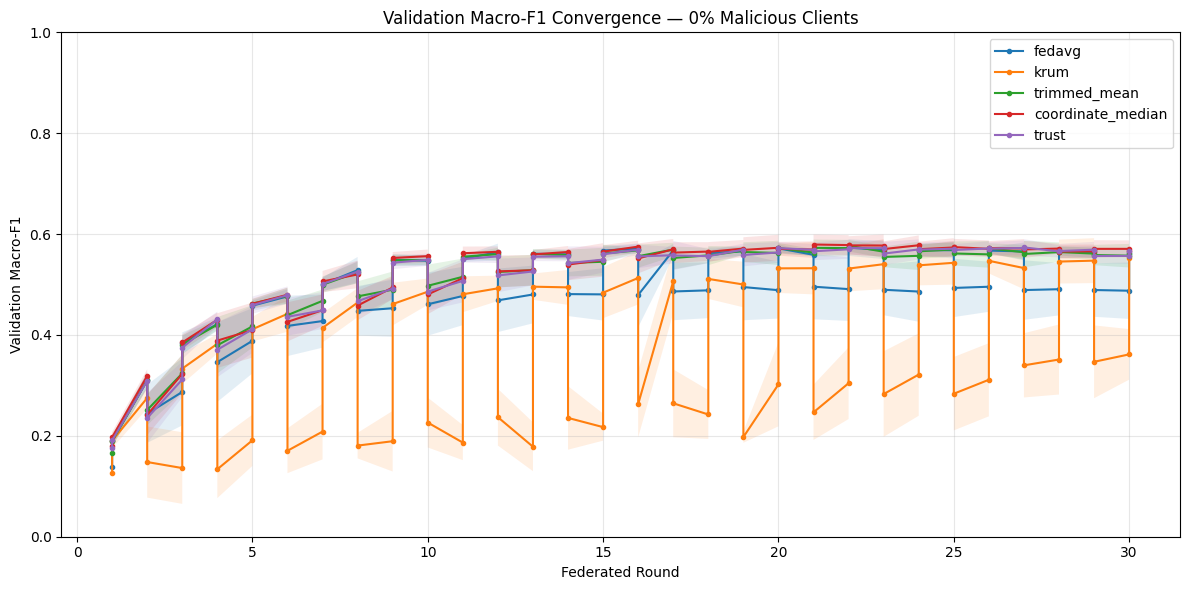

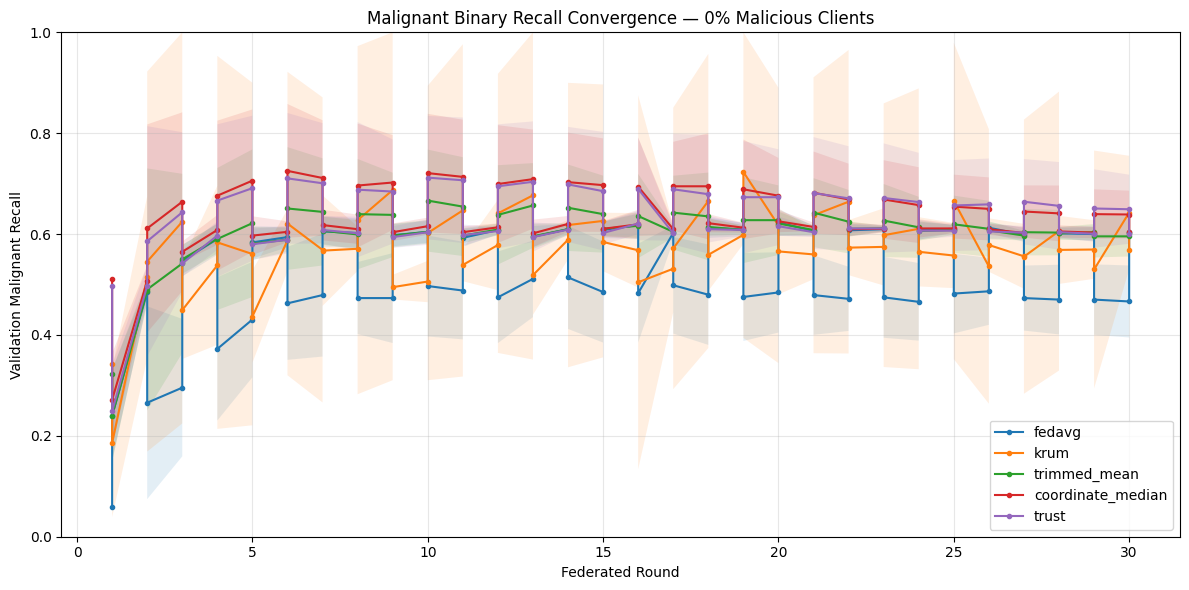

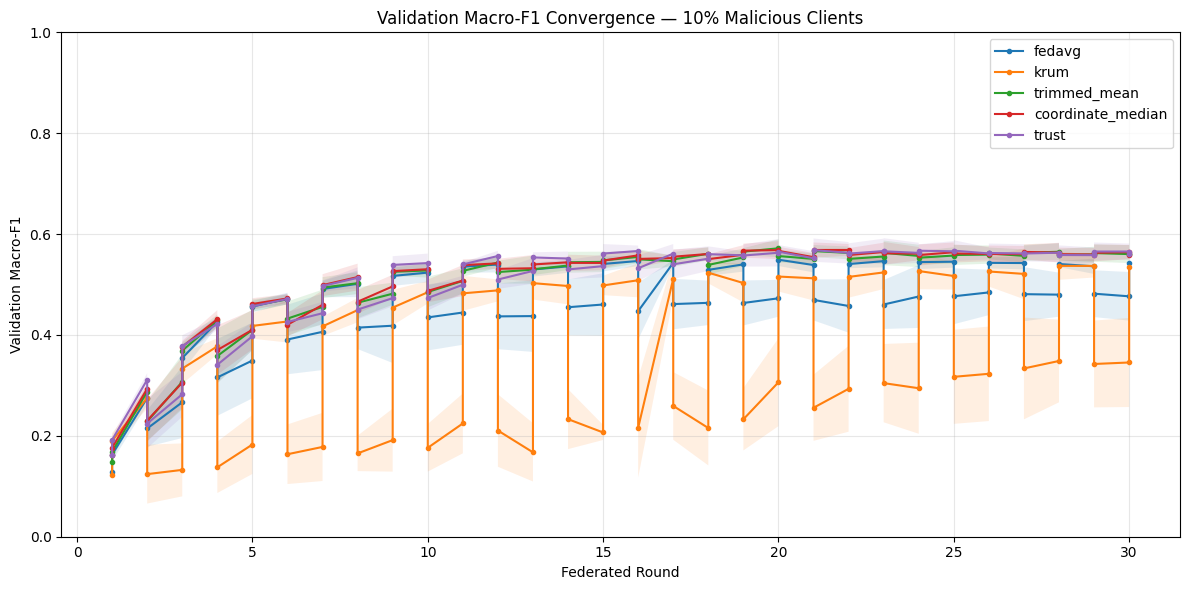

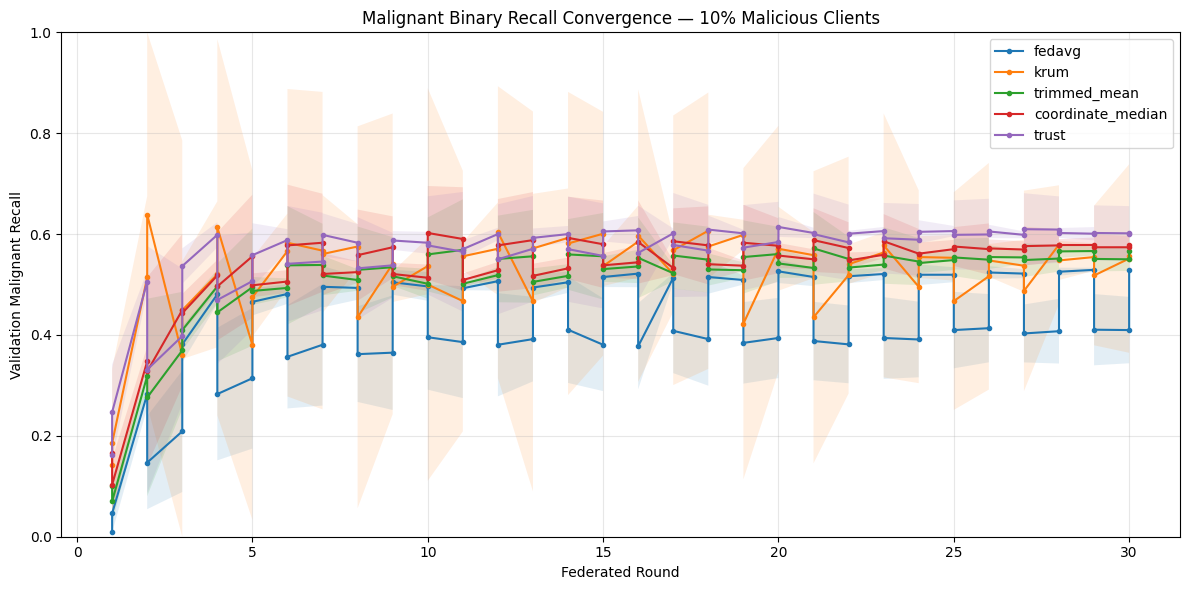

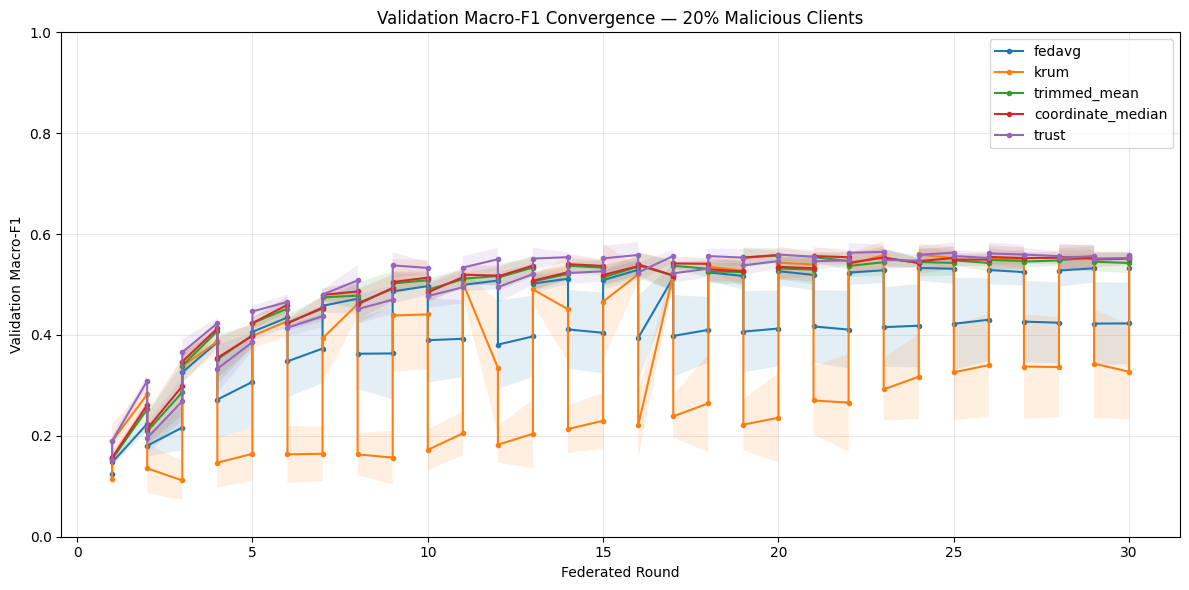

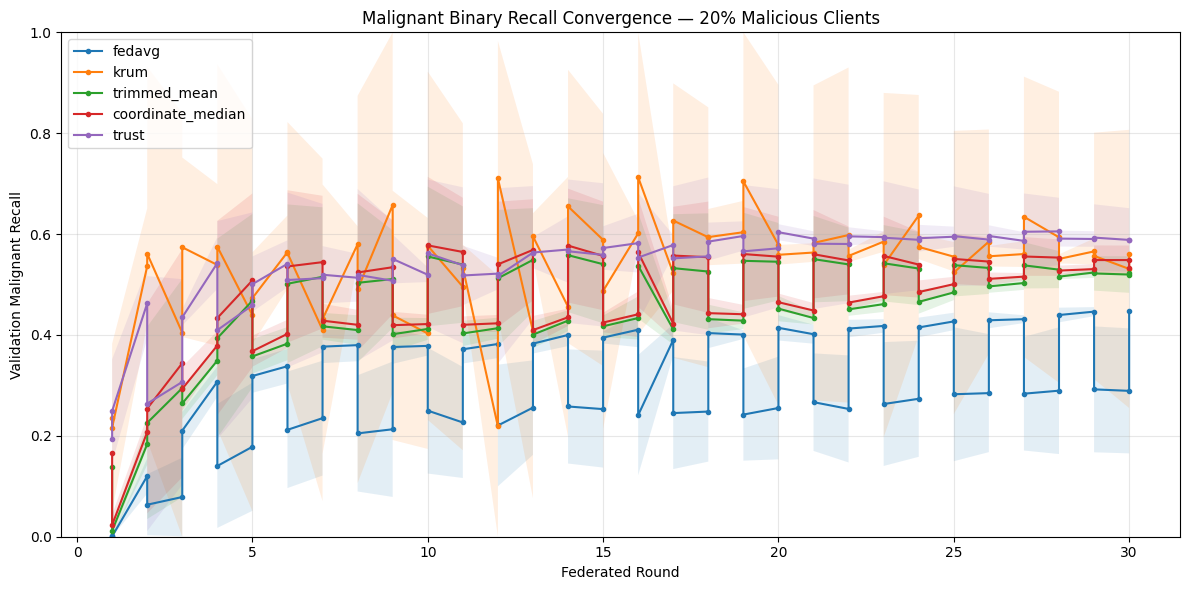

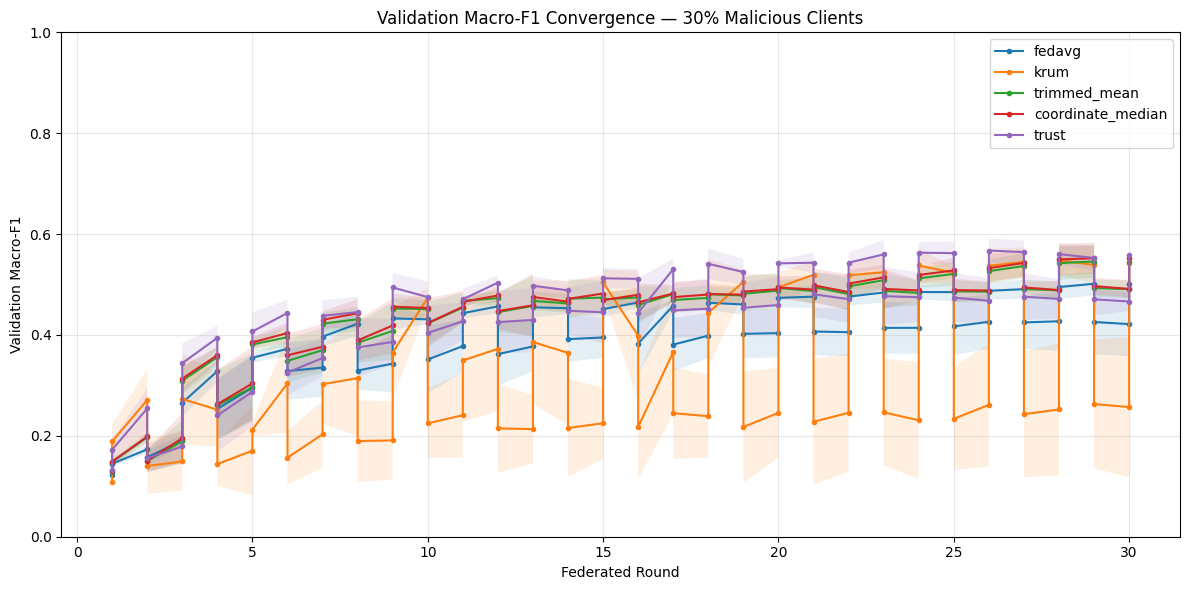

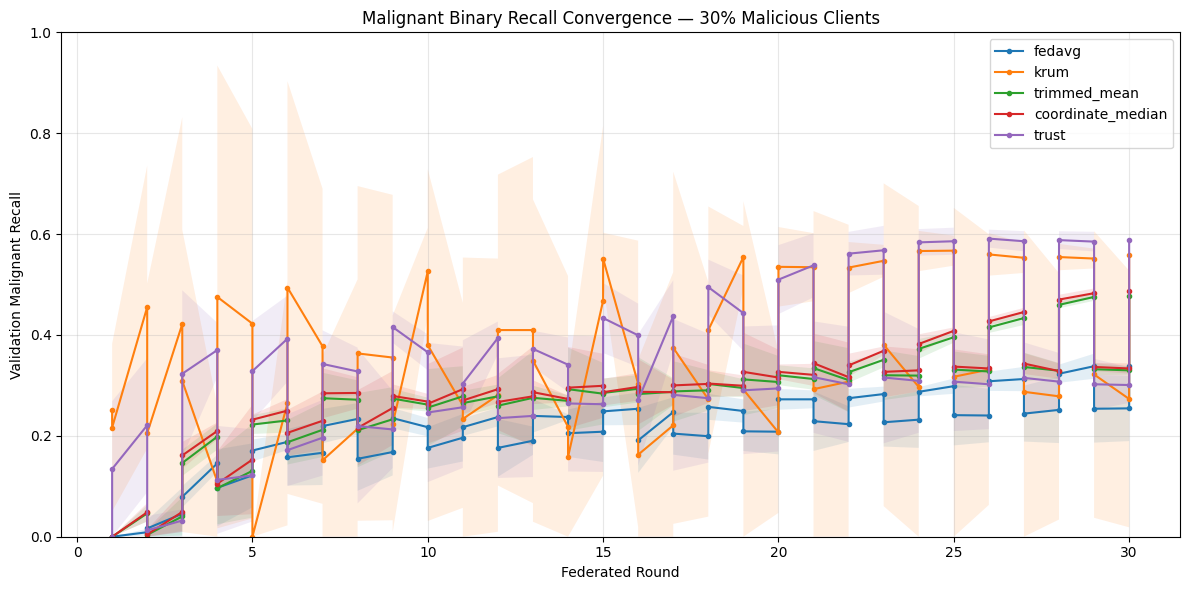


SECTION 22 AGGREGATE CONVERGENCE ANALYSIS COMPLETE


In [ ]:
# Section 22 — Aggregate convergence analysis across completed runs

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Load all currently completed runs
# ------------------------------------------------------------

records = collect_results(STUDY_ROOT)

if records is None or len(records) == 0:
    raise ValueError("No completed runs found in STUDY_ROOT.")

print(f"Completed runs available: {len(records)}")


# ------------------------------------------------------------
# 2. Read round_history.csv from every completed run
# ------------------------------------------------------------

history_records = []

for _, run in records.iterrows():

    run_folder = Path(run["artifact_dir"])
    history_path = run_folder / "round_history.csv"

    if not history_path.exists():
        print(f"Skipping run without round_history.csv: {run['run_id']}")
        continue

    h = pd.read_csv(history_path)

    # Add experiment metadata to every round
    h["run_id"] = run["run_id"]
    h["partition"] = run["partition"]
    h["malicious_fraction"] = run["malicious_fraction"]
    h["aggregation"] = run["aggregation"]
    h["seed"] = run["seed"]

    history_records.append(h)


if not history_records:
    raise ValueError("No round_history.csv files were found.")


history_all = pd.concat(history_records, ignore_index=True)

print(f"Round-level records loaded: {len(history_all)}")


# ------------------------------------------------------------
# 3. Verify required metrics
# ------------------------------------------------------------

required_metrics = [
    "round",
    "val_macro_f1",
    "val_malignant_binary_recall"
]

missing = [
    col for col in required_metrics
    if col not in history_all.columns
]

if missing:
    raise KeyError(
        f"Required convergence columns are missing: {missing}"
    )


# ------------------------------------------------------------
# 4. Restrict analysis to the main study
# ------------------------------------------------------------

# At the current stage your completed runs are the
# stratified_balanced main-study runs.
#
# Keep this filtering explicit so adaptive/sensitivity
# experiments are not accidentally mixed into the main
# convergence plots later.

main_history = history_all[
    history_all["partition"].isin(
        ["stratified_balanced", "dirichlet"]
    )
].copy()


# ------------------------------------------------------------
# 5. Aggregate across seeds
# ------------------------------------------------------------

group_columns = [
    "partition",
    "malicious_fraction",
    "aggregation",
    "round"
]

convergence = (
    main_history
    .groupby(group_columns)
    .agg(
        val_macro_f1_mean=("val_macro_f1", "mean"),
        val_macro_f1_std=("val_macro_f1", "std"),
        malignant_recall_mean=(
            "val_malignant_binary_recall",
            "mean"
        ),
        malignant_recall_std=(
            "val_malignant_binary_recall",
            "std"
        ),
        n_runs=("run_id", "nunique")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 6. Replace NaN standard deviation for single-run groups
# ------------------------------------------------------------

# A single run has no calculable sample standard deviation.
# For plotting an error band, treat it as zero width.

convergence["val_macro_f1_std"] = (
    convergence["val_macro_f1_std"].fillna(0)
)

convergence["malignant_recall_std"] = (
    convergence["malignant_recall_std"].fillna(0)
)


# ------------------------------------------------------------
# 7. Print convergence summary
# ------------------------------------------------------------

print("\nConvergence groups:")
print(
    convergence[
        [
            "partition",
            "malicious_fraction",
            "aggregation",
            "n_runs"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "partition",
            "malicious_fraction",
            "aggregation"
        ]
    )
    .to_string(index=False)
)


# ------------------------------------------------------------
# 8. Plot convergence for each malicious fraction
# ------------------------------------------------------------

aggregators = [
    "fedavg",
    "krum",
    "trimmed_mean",
    "coordinate_median",
    "trust"
]

malicious_fractions = sorted(
    convergence["malicious_fraction"]
    .dropna()
    .unique()
)


for frac in malicious_fractions:

    subset = convergence[
        convergence["malicious_fraction"] == frac
    ]

    # ----------------------------------------
    # Macro F1
    # ----------------------------------------

    plt.figure(figsize=(12, 6))

    for aggregation in aggregators:

        data = subset[
            subset["aggregation"] == aggregation
        ].sort_values("round")

        if data.empty:
            continue

        x = data["round"].to_numpy()
        mean = data["val_macro_f1_mean"].to_numpy()
        std = data["val_macro_f1_std"].to_numpy()

        plt.plot(
            x,
            mean,
            marker="o",
            markersize=3,
            label=aggregation
        )

        plt.fill_between(
            x,
            np.maximum(0, mean - std),
            np.minimum(1, mean + std),
            alpha=0.12
        )

    plt.title(
        f"Validation Macro-F1 Convergence — "
        f"{int(frac * 100)}% Malicious Clients"
    )

    plt.xlabel("Federated Round")
    plt.ylabel("Validation Macro-F1")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


    # ----------------------------------------
    # Malignant recall
    # ----------------------------------------

    plt.figure(figsize=(12, 6))

    for aggregation in aggregators:

        data = subset[
            subset["aggregation"] == aggregation
        ].sort_values("round")

        if data.empty:
            continue

        x = data["round"].to_numpy()

        mean = data[
            "malignant_recall_mean"
        ].to_numpy()

        std = data[
            "malignant_recall_std"
        ].to_numpy()

        plt.plot(
            x,
            mean,
            marker="o",
            markersize=3,
            label=aggregation
        )

        plt.fill_between(
            x,
            np.maximum(0, mean - std),
            np.minimum(1, mean + std),
            alpha=0.12
        )

    plt.title(
        f"Malignant Binary Recall Convergence — "
        f"{int(frac * 100)}% Malicious Clients"
    )

    plt.xlabel("Federated Round")
    plt.ylabel("Validation Malignant Recall")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


print("\nSECTION 22 AGGREGATE CONVERGENCE ANALYSIS COMPLETE")

## 23. Confusion matrix for a selected run (Manuscript Figure 6)

The selected run must exist in the validated completed-results table.


Completed runs available: 265

MATRIX 1 — SELECTED RUN
Run ID             : 53cd48a4e629ef1147a41fa2
Partition          : stratified_balanced
Malicious fraction : 0.0
Aggregation        : fedavg
Seed               : 42


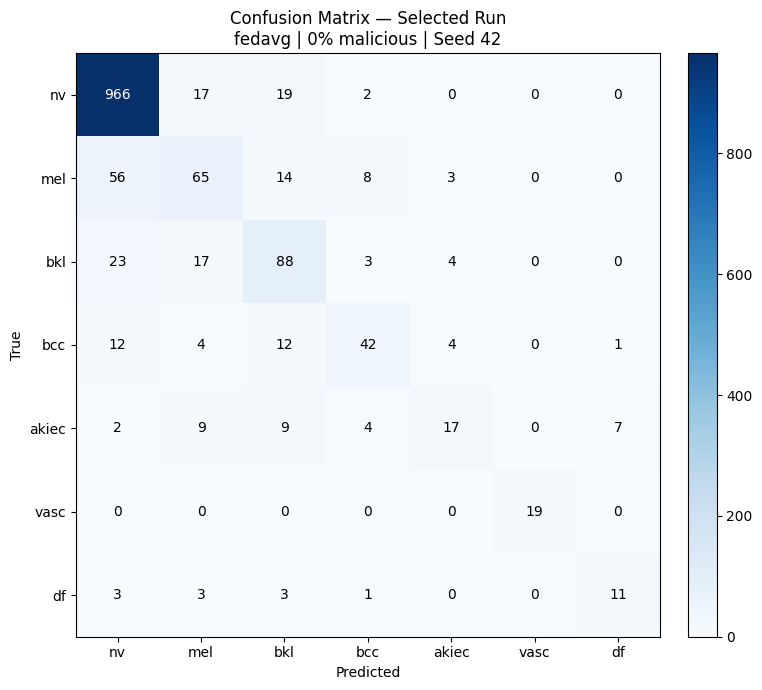


MATRIX 2 — ENTIRE COMPLETED STUDY
Valid confusion matrices included: 265

Aggregate confusion matrix:


,nv,mel,bkl,bcc,akiec,vasc,df
nv,255785,4566,4515,618,151,380,45
mel,18628,13061,3955,1770,1047,209,20
bkl,9666,2768,21215,690,1199,215,22
bcc,4172,1041,3535,9491,1299,116,221
akiec,1611,1795,2441,1206,4342,17,1308
vasc,300,0,5,32,0,4694,4
df,1675,296,562,343,28,37,2624


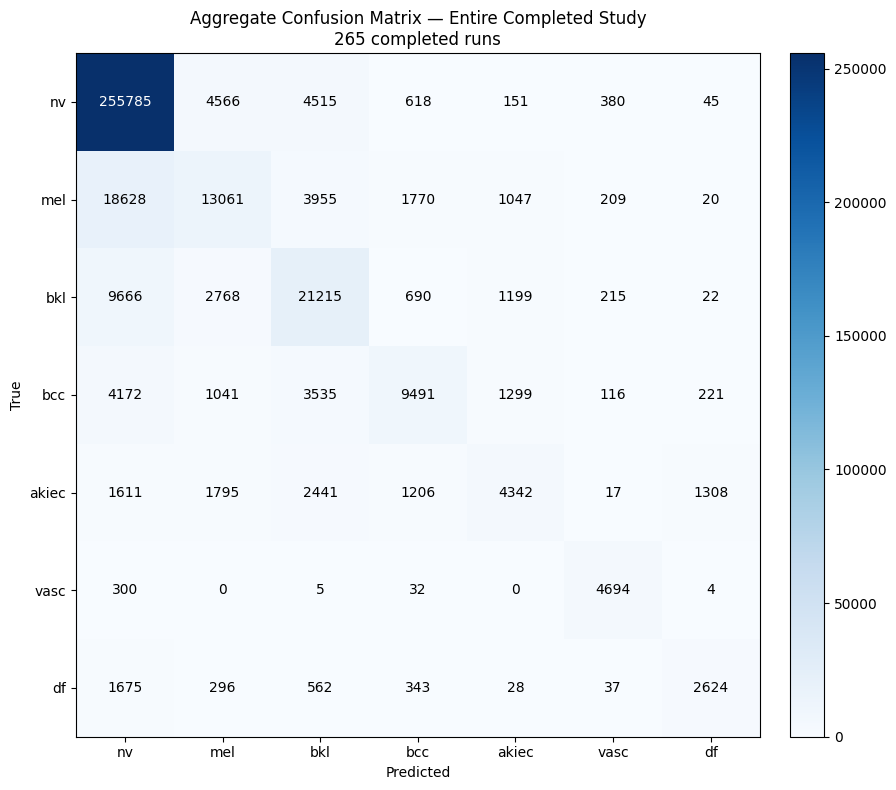


SECTION 23 COMPLETE — 2 CONFUSION MATRICES GENERATED


In [ ]:
# Section 23 — Confusion Matrices
#
# Matrix 1: One selected completed run
# Matrix 2: Aggregate confusion matrix across entire completed study

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD COMPLETED RESULTS
# ============================================================

results_df = collect_results(STUDY_ROOT)

if results_df is None or len(results_df) == 0:
    raise ValueError("No completed runs found in STUDY_ROOT.")

print(f"Completed runs available: {len(results_df)}")


# ============================================================
# 2. MATRIX 1 — ONE SELECTED RUN
# ============================================================

# None = automatically select the first completed run.
# You can later replace None with any valid run_id.

SELECTED_RUN_ID = None

if SELECTED_RUN_ID is None:
    selected = results_df.iloc[[0]]
    SELECTED_RUN_ID = selected.iloc[0]["run_id"]
else:
    selected = results_df[
        results_df["run_id"] == SELECTED_RUN_ID
    ]

    if len(selected) != 1:
        raise ValueError(
            f"Run ID '{SELECTED_RUN_ID}' was not found exactly once."
        )


run_folder = Path(
    selected.iloc[0]["artifact_dir"]
)

cm_path = run_folder / "confusion_matrix.csv"

if not cm_path.exists():
    raise FileNotFoundError(
        f"confusion_matrix.csv not found:\n{cm_path}"
    )

cm_single = pd.read_csv(
    cm_path,
    index_col=0
)


print("\n" + "=" * 70)
print("MATRIX 1 — SELECTED RUN")
print("=" * 70)

print("Run ID             :", SELECTED_RUN_ID)
print("Partition          :", selected.iloc[0]["partition"])
print("Malicious fraction :", selected.iloc[0]["malicious_fraction"])
print("Aggregation        :", selected.iloc[0]["aggregation"])
print("Seed               :", selected.iloc[0]["seed"])


# ------------------------------------------------------------
# Plot selected-run confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    cm_single.values,
    cmap="Blues"
)

ax.set(
    xticks=range(len(CLASS_ORDER)),
    xticklabels=CLASS_ORDER,
    yticks=range(len(CLASS_ORDER)),
    yticklabels=CLASS_ORDER,
    xlabel="Predicted",
    ylabel="True",
    title=(
        f"Confusion Matrix — Selected Run\n"
        f"{selected.iloc[0]['aggregation']} | "
        f"{int(selected.iloc[0]['malicious_fraction'] * 100)}% malicious | "
        f"Seed {selected.iloc[0]['seed']}"
    )
)

for i in range(cm_single.shape[0]):
    for j in range(cm_single.shape[1]):

        value = cm_single.iloc[i, j]

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=(
                "white"
                if value > cm_single.values.max() / 2
                else "black"
            )
        )

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


# ============================================================
# 3. MATRIX 2 — ENTIRE COMPLETED STUDY
# ============================================================

print("\n" + "=" * 70)
print("MATRIX 2 — ENTIRE COMPLETED STUDY")
print("=" * 70)


aggregate_cm = np.zeros(
    (len(CLASS_ORDER), len(CLASS_ORDER)),
    dtype=np.int64
)

valid_runs = 0
skipped_runs = []


for _, run in results_df.iterrows():

    run_folder = Path(run["artifact_dir"])
    cm_path = run_folder / "confusion_matrix.csv"

    if not cm_path.exists():
        skipped_runs.append(
            (run["run_id"], "confusion_matrix.csv missing")
        )
        continue

    try:

        cm = pd.read_csv(
            cm_path,
            index_col=0
        )

        cm_values = cm.values.astype(np.int64)

        if cm_values.shape != (
            len(CLASS_ORDER),
            len(CLASS_ORDER)
        ):
            skipped_runs.append(
                (
                    run["run_id"],
                    f"unexpected shape {cm_values.shape}"
                )
            )
            continue

        aggregate_cm += cm_values
        valid_runs += 1

    except Exception as e:

        skipped_runs.append(
            (run["run_id"], str(e))
        )


if valid_runs == 0:
    raise ValueError(
        "No valid confusion matrices were found."
    )


print(f"Valid confusion matrices included: {valid_runs}")

if skipped_runs:
    print(f"Runs skipped: {len(skipped_runs)}")


# ------------------------------------------------------------
# Display aggregate matrix
# ------------------------------------------------------------

aggregate_cm_df = pd.DataFrame(
    aggregate_cm,
    index=CLASS_ORDER,
    columns=CLASS_ORDER
)

print("\nAggregate confusion matrix:")
display(aggregate_cm_df)


# ------------------------------------------------------------
# Plot aggregate confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    aggregate_cm,
    cmap="Blues"
)

ax.set(
    xticks=range(len(CLASS_ORDER)),
    xticklabels=CLASS_ORDER,
    yticks=range(len(CLASS_ORDER)),
    yticklabels=CLASS_ORDER,
    xlabel="Predicted",
    ylabel="True",
    title=(
        f"Aggregate Confusion Matrix — "
        f"Entire Completed Study\n"
        f"{valid_runs} completed runs"
    )
)

for i in range(aggregate_cm.shape[0]):
    for j in range(aggregate_cm.shape[1]):

        value = aggregate_cm[i, j]

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color=(
                "white"
                if value > aggregate_cm.max() / 2
                else "black"
            )
        )

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


print(
    "\nSECTION 23 COMPLETE — "
    "2 CONFUSION MATRICES GENERATED"
)

## 24. Robustness plots (Manuscript Figure 7)

Robustness figures summarize observed completed configurations only.


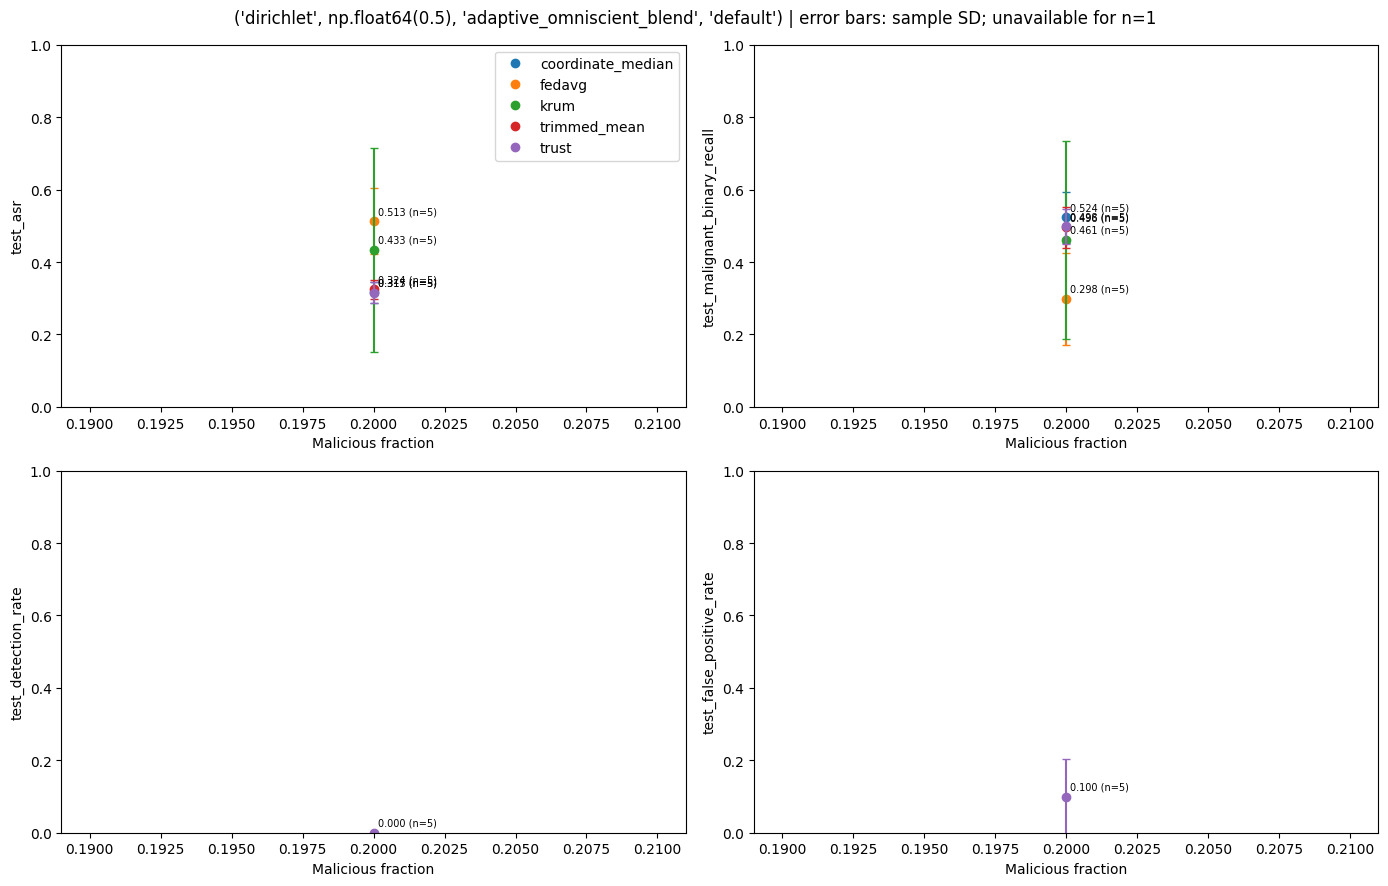

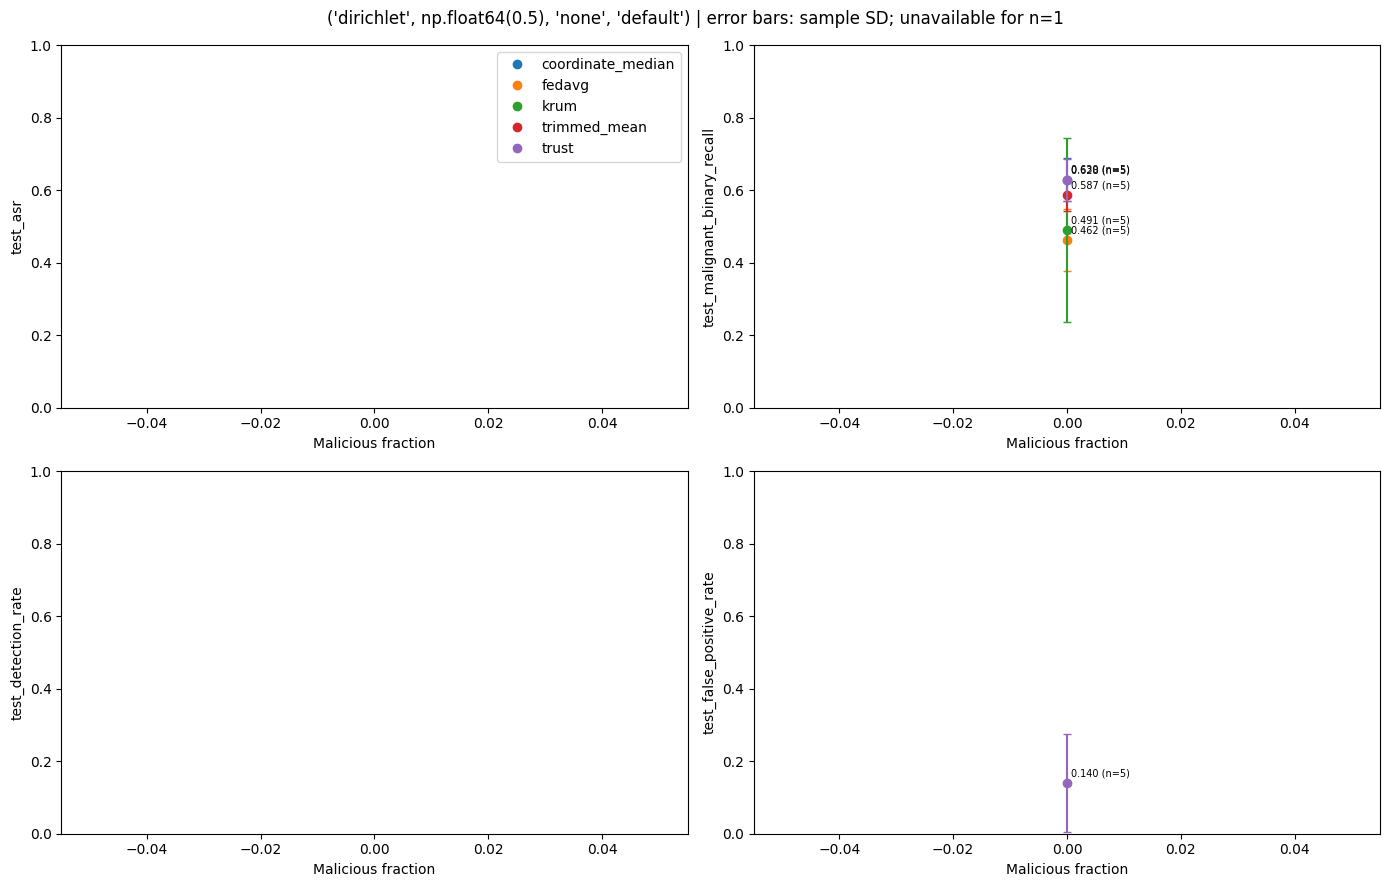

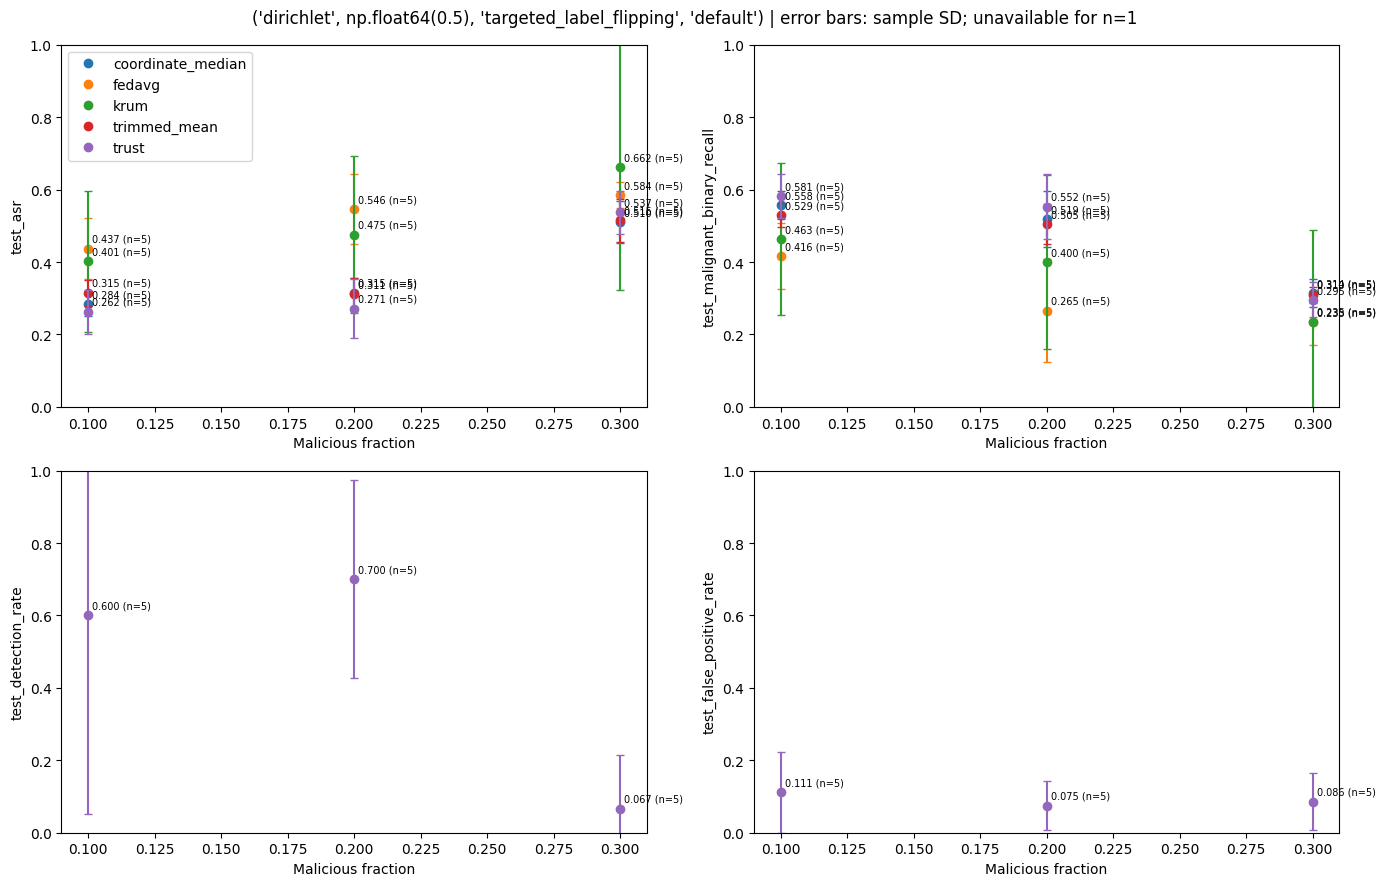

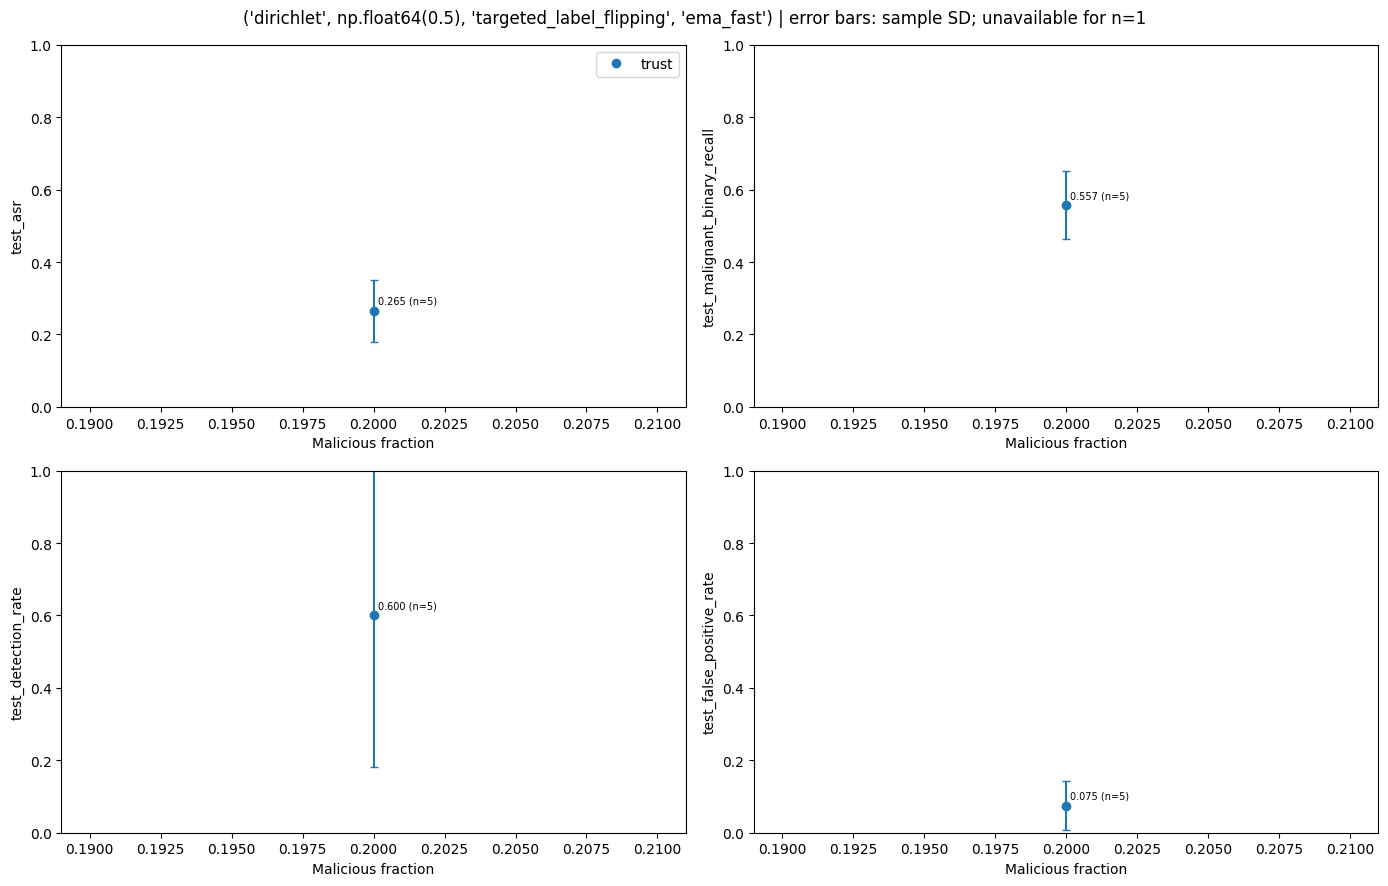

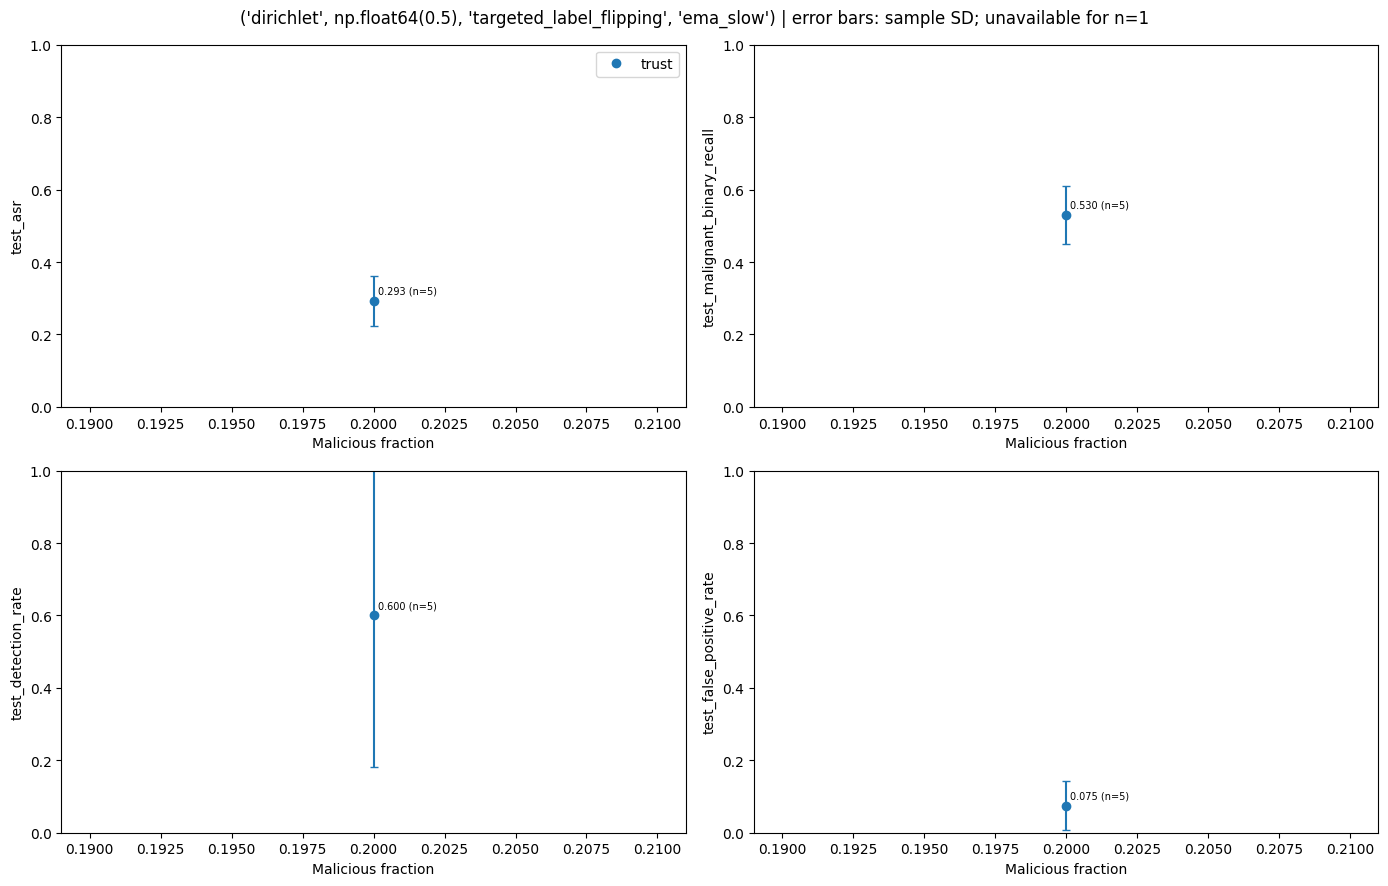

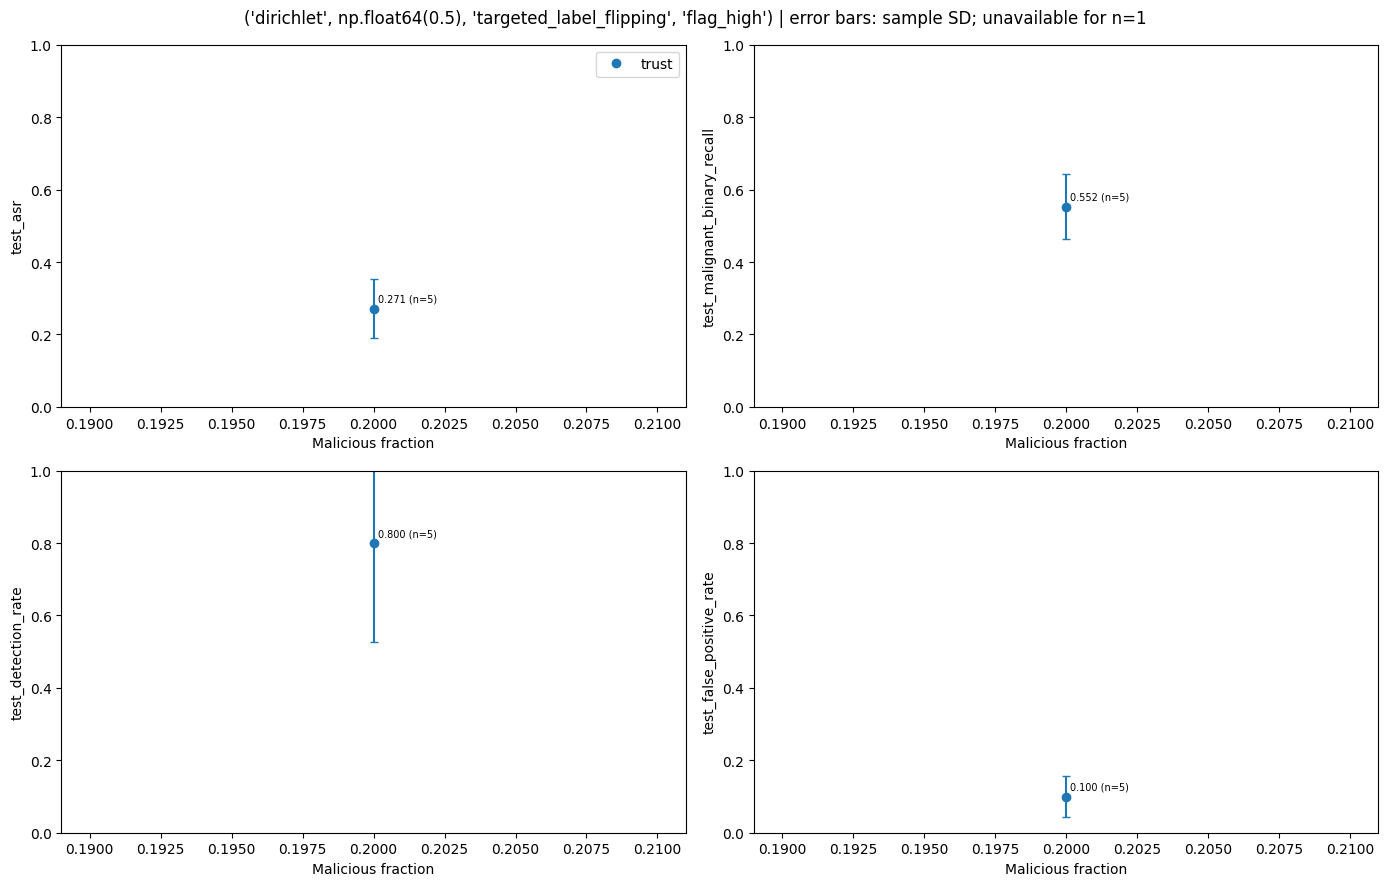

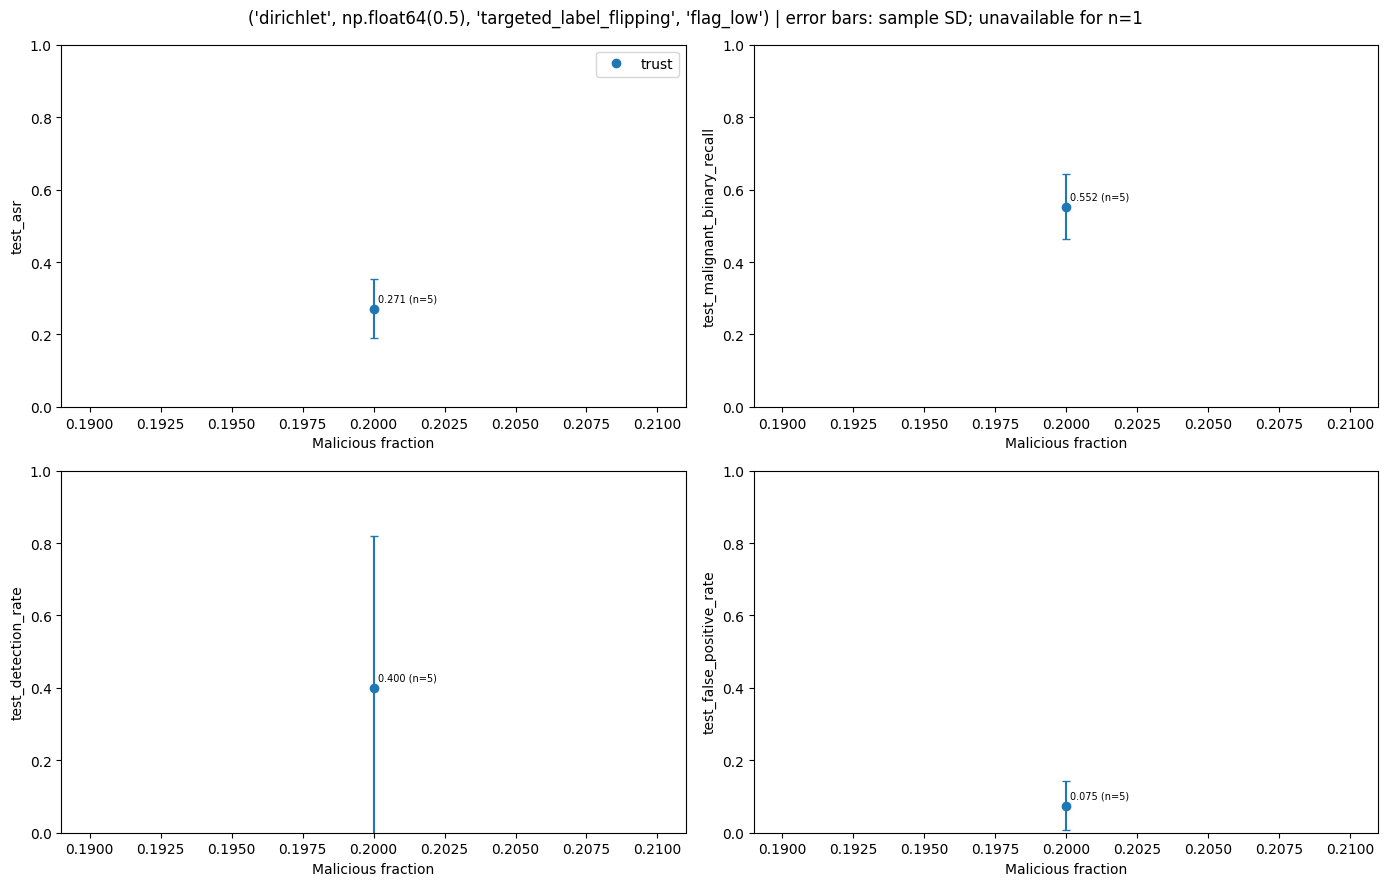

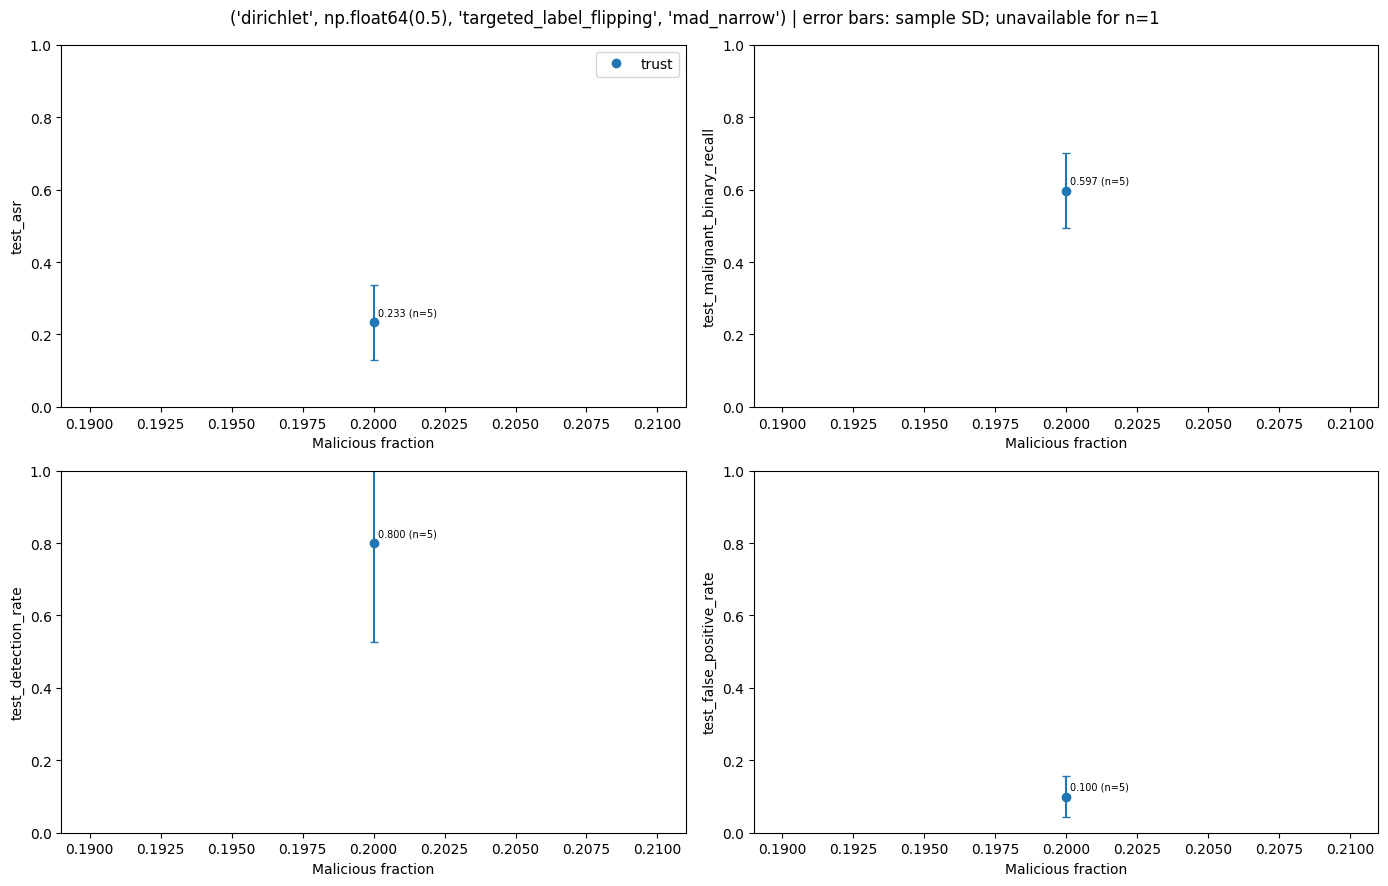

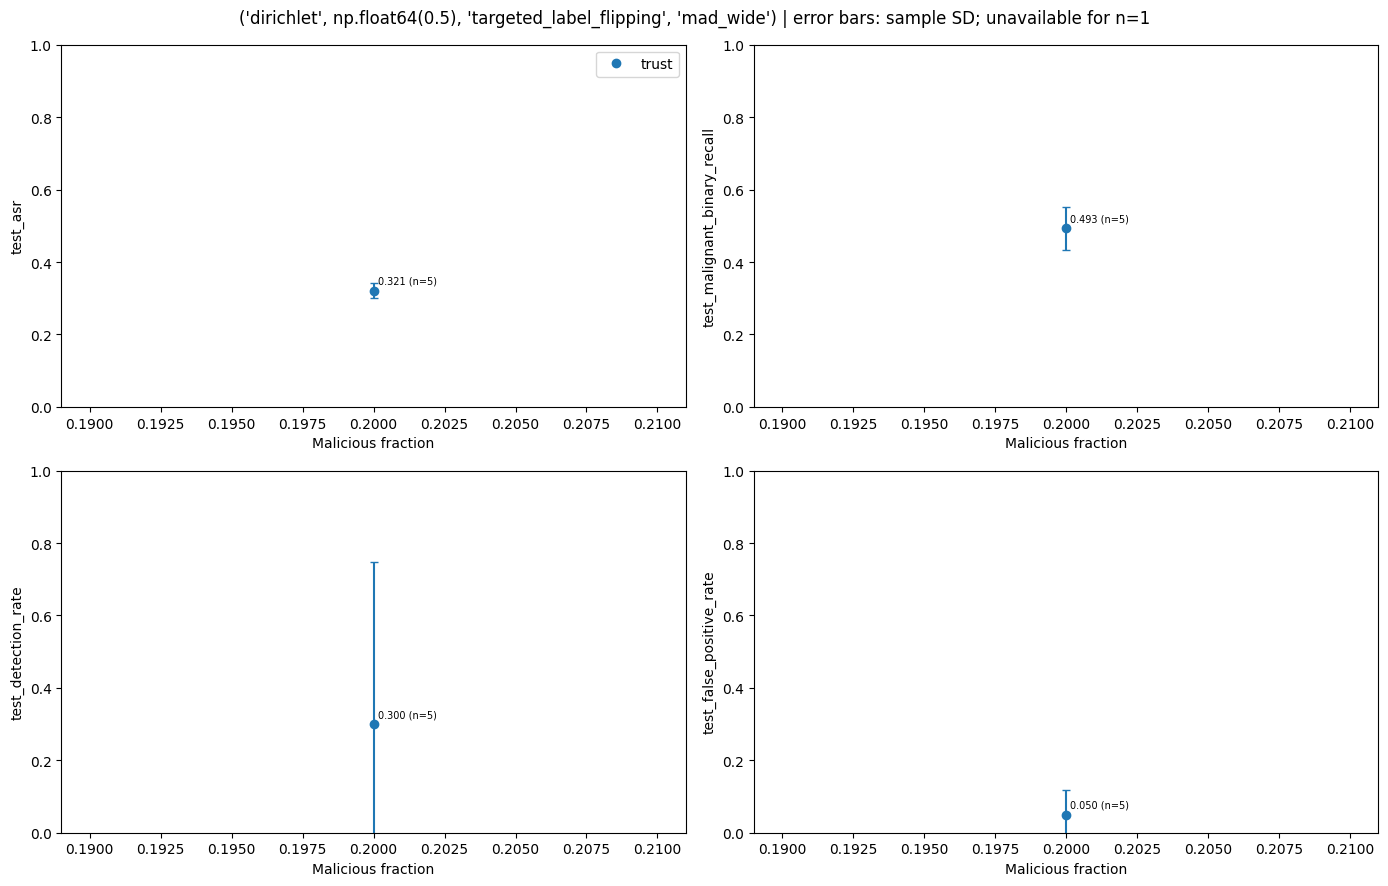

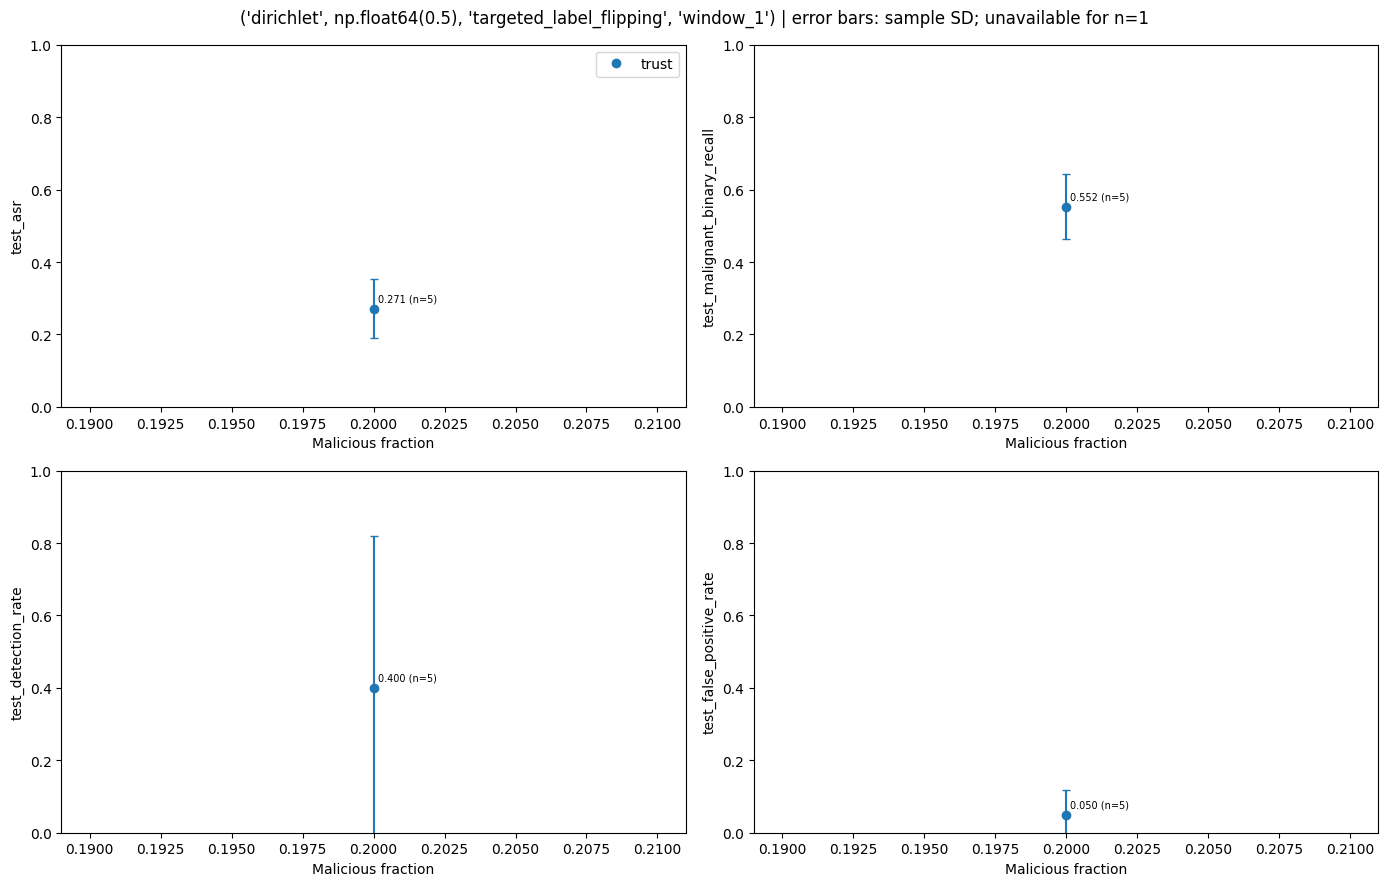

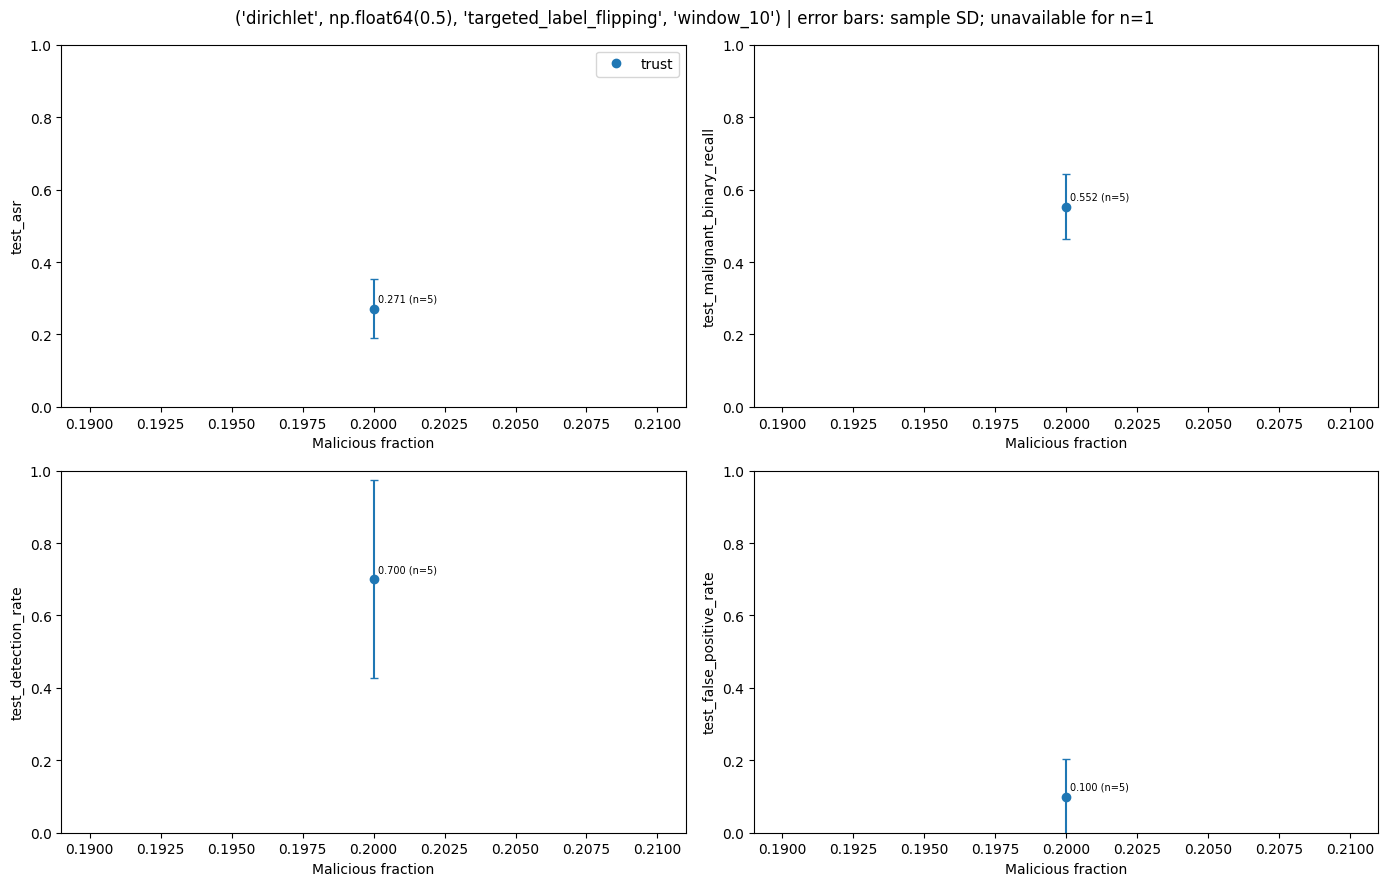

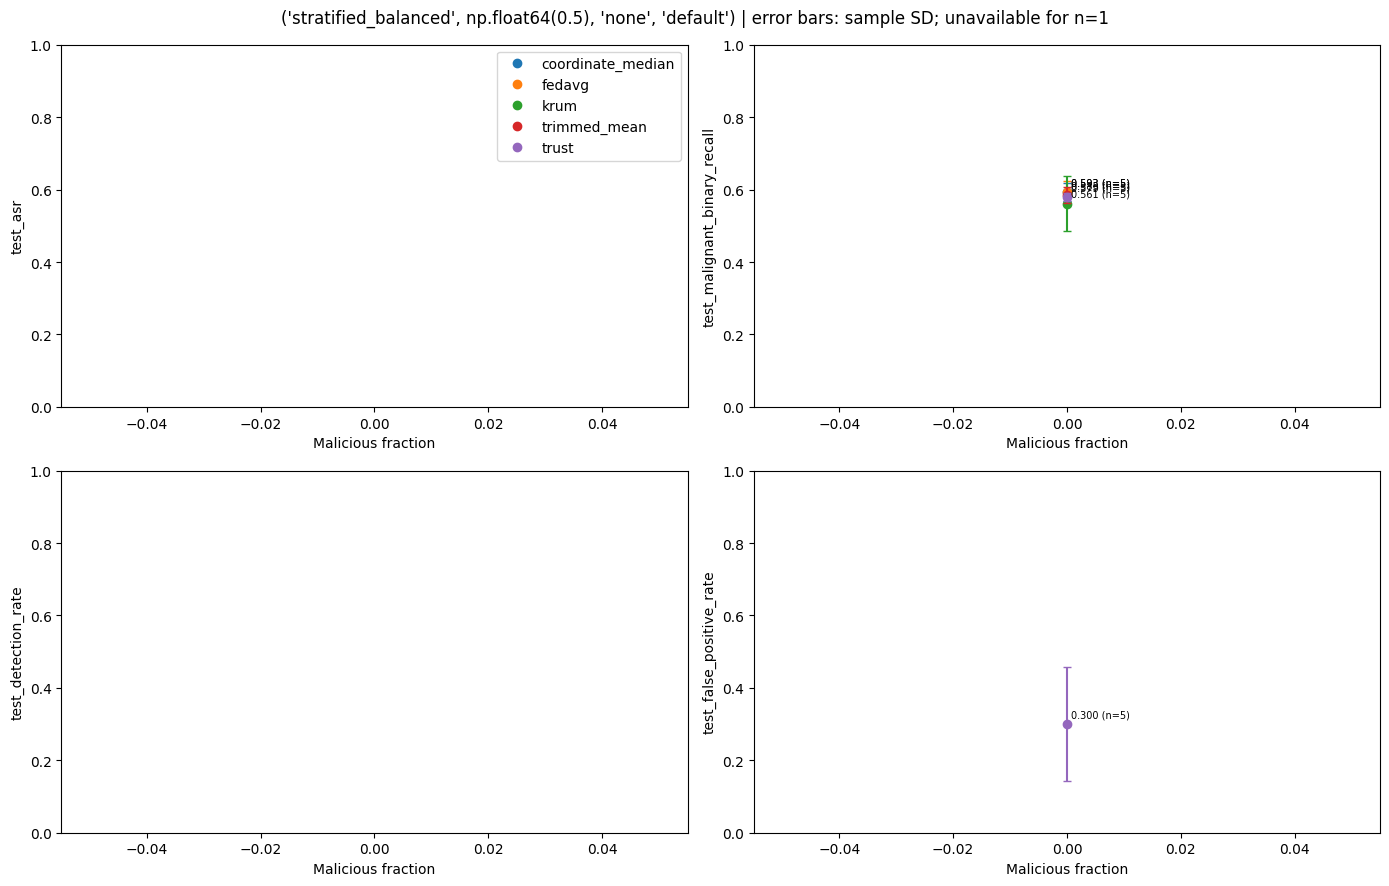

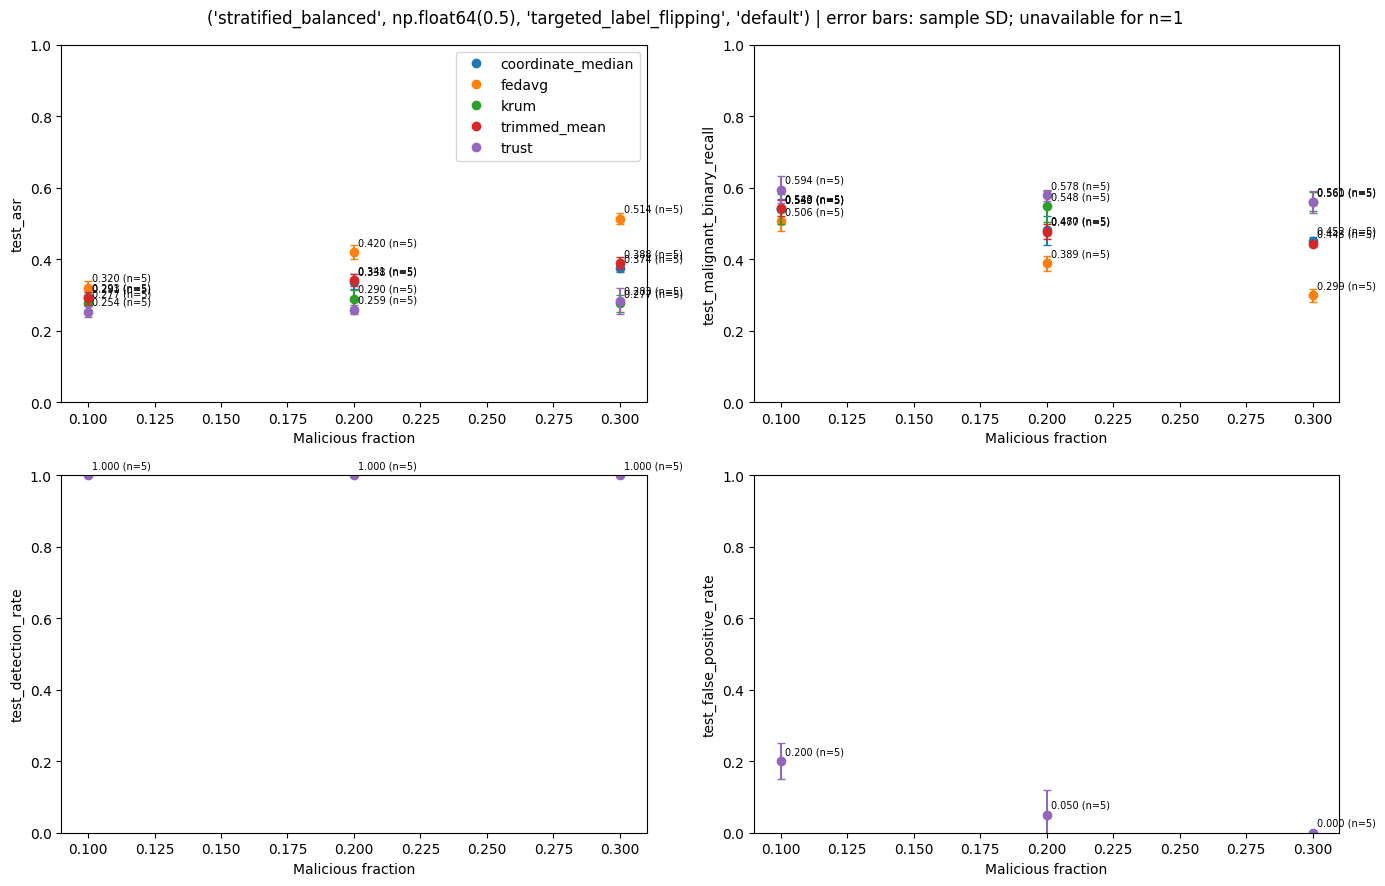

In [ ]:
# Grouped endpoint figures; no interpolation of missing configurations.
if not results_df.empty:
    for keys,sub in results_df.groupby(['partition','dirichlet_alpha','attack','setting'],dropna=False):
        fig,axes=plt.subplots(2,2,figsize=(14,9)); axes=axes.ravel()
        for agg,rows in sub.groupby('aggregation'):
            for ax,metric in zip(axes,['test_asr','test_malignant_binary_recall','test_detection_rate','test_false_positive_rate']):
                z=rows.groupby('malicious_fraction')[metric].agg(['mean','std','count']).dropna(subset=['mean'])
                points=ax.plot(z.index,z['mean'],'o',label=agg)[0]
                multi=z[z['count']>1]
                if len(multi): ax.errorbar(multi.index,multi['mean'],yerr=multi['std'],fmt='none',color=points.get_color(),capsize=3)
                for fraction,row in z.iterrows():
                    ax.annotate(f"{row['mean']:.3f} (n={int(row['count'])})",(fraction,row['mean']),xytext=(3,5),textcoords='offset points',fontsize=7)
                ax.set(xlabel='Malicious fraction',ylabel=metric,ylim=(0,1))
        axes[0].legend(); fig.suptitle(str(keys)+' | error bars: sample SD; unavailable for n=1'); plt.tight_layout(); plt.show()
else: print('No completed runs available: no robustness curves generated.')


## 25. Statistical comparison across seeds (Manuscript Table 5)

Paired analyses use complete seed pairs within a single protocol configuration.


In [ ]:
if not results_df.empty:
    display(statistical_report(results_df,STUDY_ROOT))
    print('Paired tests only for n>=5; Holm correction applies across this export. Five seeds remain a small sample.')
    print('Seeds are paired training/partition randomizations on a fixed split, not independent patient cohorts.')
else: print('Not executed: no inferential results.')


,partition,dirichlet_alpha,attack,malicious_fraction,setting,num_clients,baseline,metric,n,mean_difference,sd_difference,paired_t_p,wilcoxon_p,status,paired_t_p_holm,wilcoxon_p_holm
0,dirichlet,0.5,adaptive_omniscient_blend,0.2,default,10,coordinate_median,test_macro_f1,5,-0.013837,0.019294,0.184048,0.1250,exploratory_small_sample,1.000000,1.0
1,dirichlet,0.5,adaptive_omniscient_blend,0.2,default,10,coordinate_median,test_asr,5,-0.001487,0.032151,0.922609,1.0000,exploratory_small_sample,1.000000,1.0
2,dirichlet,0.5,adaptive_omniscient_blend,0.2,default,10,coordinate_median,test_malignant_binary_recall,5,-0.026022,0.039254,0.212388,0.3125,exploratory_small_sample,1.000000,1.0
3,dirichlet,0.5,adaptive_omniscient_blend,0.2,default,10,coordinate_median,test_macro_precision,5,0.003144,0.012774,0.611341,0.6250,exploratory_small_sample,1.000000,1.0
4,dirichlet,0.5,adaptive_omniscient_blend,0.2,default,10,coordinate_median,test_macro_recall,5,-0.015744,0.025897,0.245611,0.1875,exploratory_small_sample,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,stratified_balanced,0.5,targeted_label_flipping,0.3,default,10,trimmed_mean,test_malignant_binary_recall,5,0.116729,0.034734,0.001678,0.0625,exploratory_small_sample,0.375977,1.0
248,stratified_balanced,0.5,targeted_label_flipping,0.3,default,10,trimmed_mean,test_macro_precision,5,-0.017063,0.005488,0.002249,0.0625,exploratory_small_sample,0.494787,1.0
249,stratified_balanced,0.5,targeted_label_flipping,0.3,default,10,trimmed_mean,test_macro_recall,5,0.027653,0.017629,0.024727,0.0625,exploratory_small_sample,1.000000,1.0
250,stratified_balanced,0.5,targeted_label_flipping,0.3,default,10,trimmed_mean,test_accuracy,5,0.009807,0.003104,0.002118,0.0625,exploratory_small_sample,0.468016,1.0


Paired tests only for n>=5; Holm correction applies across this export. Five seeds remain a small sample.
Seeds are paired training/partition randomizations on a fixed split, not independent patient cohorts.


Completed runs available: 265

MAIN PERFORMANCE COMPARISON


,partition,malicious_fraction,aggregation,metric,mean_std,count
0,dirichlet,0.0,coordinate_median,Attack Success Rate,nan ± NA,0
1,dirichlet,0.0,fedavg,Attack Success Rate,nan ± NA,0
2,dirichlet,0.0,krum,Attack Success Rate,nan ± NA,0
3,dirichlet,0.0,trimmed_mean,Attack Success Rate,nan ± NA,0
4,dirichlet,0.0,trust,Attack Success Rate,nan ± NA,0
...,...,...,...,...,...,...
155,stratified_balanced,0.3,coordinate_median,Test Macro-F1,0.6509 ± 0.0071,5
156,stratified_balanced,0.3,fedavg,Test Macro-F1,0.6005 ± 0.0045,5
157,stratified_balanced,0.3,krum,Test Macro-F1,0.6510 ± 0.0163,5
158,stratified_balanced,0.3,trimmed_mean,Test Macro-F1,0.6497 ± 0.0062,5


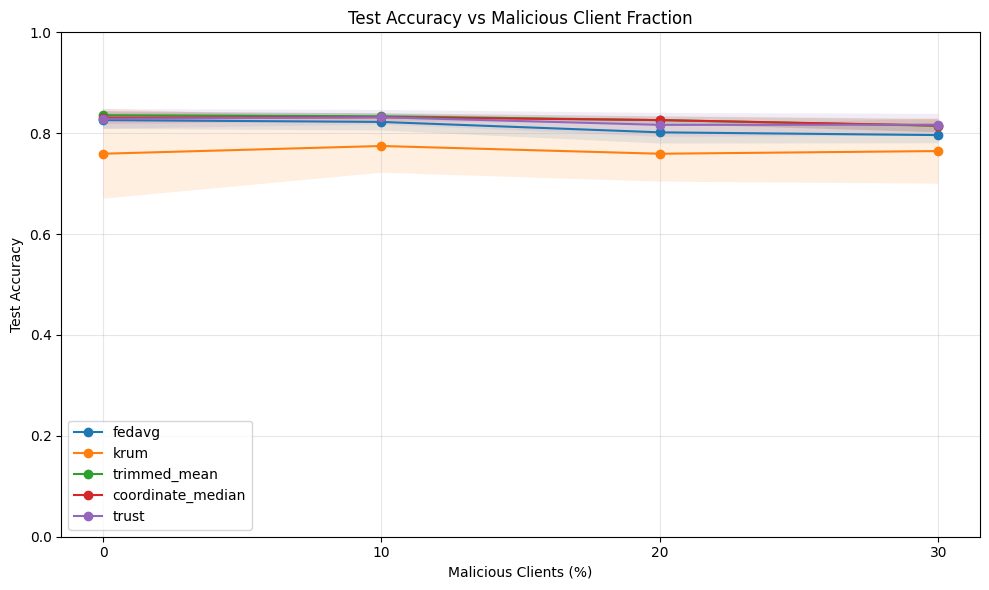

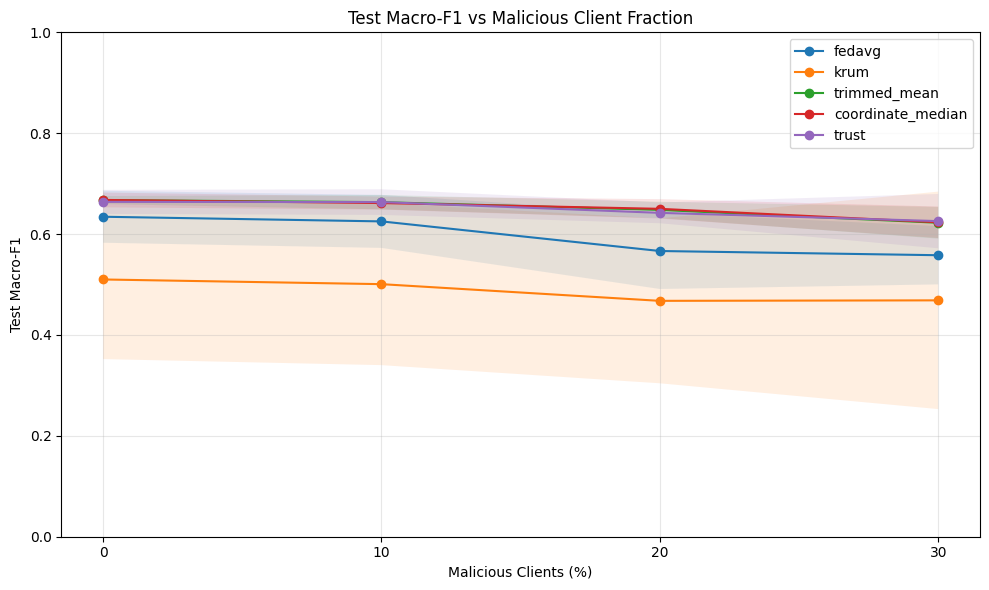

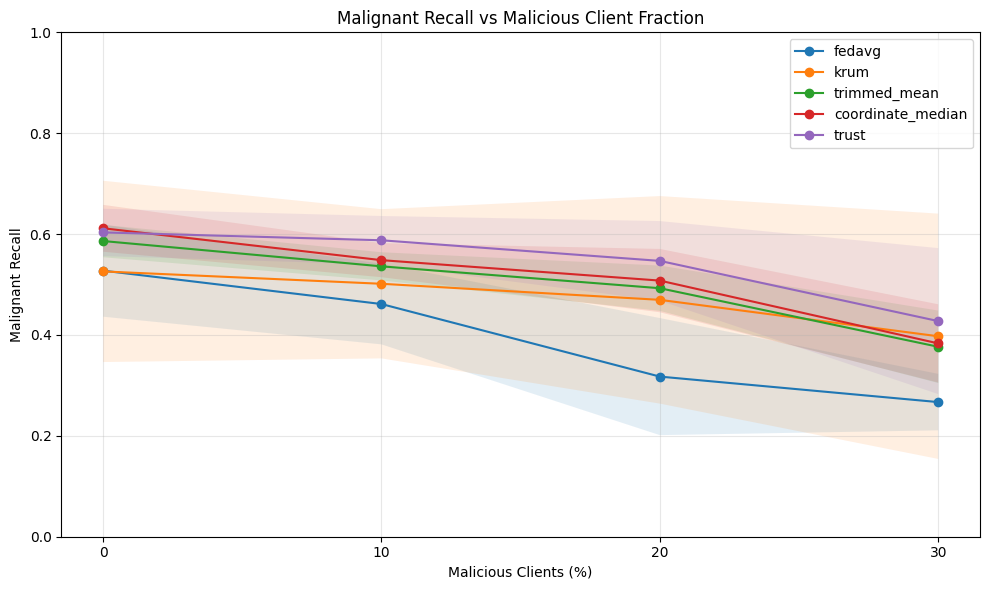

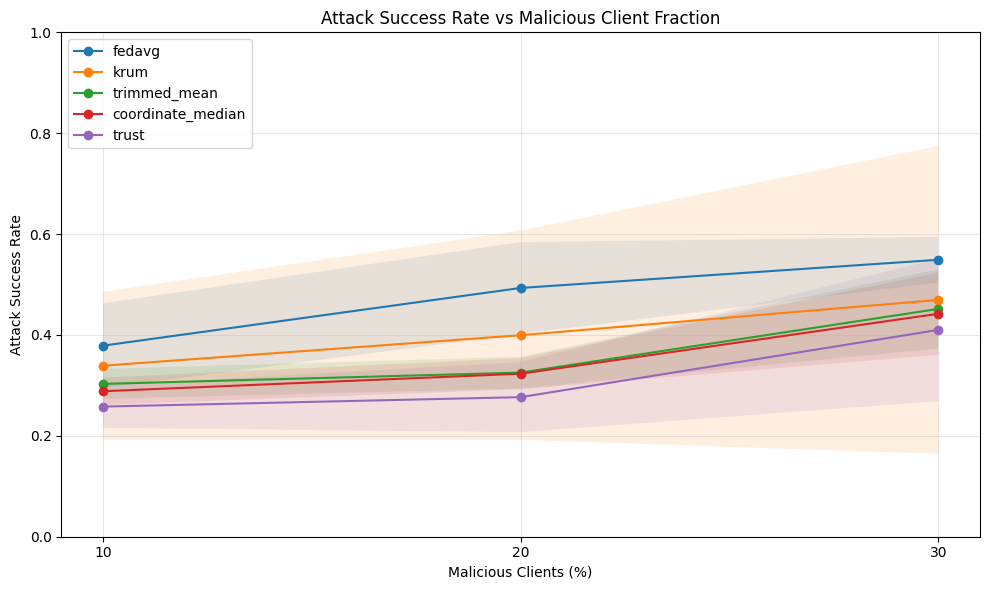


SECTION 24 COMPLETE — MAIN PERFORMANCE COMPARISON


In [ ]:
# ============================================================
# Section 24 — Main Performance Comparison
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Load completed study results
# ------------------------------------------------------------

results_df = collect_results(STUDY_ROOT)

if results_df is None or results_df.empty:
    raise ValueError("No completed study results found.")

print(f"Completed runs available: {len(results_df)}")


# ------------------------------------------------------------
# 2. Keep main-study experiments only
# ------------------------------------------------------------

main_results = results_df[
    results_df["partition"].isin(
        ["stratified_balanced", "dirichlet"]
    )
].copy()

if main_results.empty:
    raise ValueError("No main-study results found.")


# ------------------------------------------------------------
# 3. Metrics to compare
# ------------------------------------------------------------

metrics = {
    "test_accuracy": "Test Accuracy",
    "test_macro_f1": "Test Macro-F1",
    "test_malignant_binary_recall": "Malignant Recall",
    "test_asr": "Attack Success Rate"
}


# ------------------------------------------------------------
# 4. Verify available metrics
# ------------------------------------------------------------

available_metrics = {
    key: label
    for key, label in metrics.items()
    if key in main_results.columns
}

missing_metrics = [
    key
    for key in metrics
    if key not in main_results.columns
]

if missing_metrics:
    print(
        "Metrics not available and therefore excluded:",
        missing_metrics
    )


# ------------------------------------------------------------
# 5. Create aggregate comparison table
# ------------------------------------------------------------

group_columns = [
    "partition",
    "malicious_fraction",
    "aggregation"
]

summary_parts = []

for metric, label in available_metrics.items():

    grouped = (
        main_results
        .groupby(group_columns)[metric]
        .agg(
            mean="mean",
            std="std",
            count="count"
        )
        .reset_index()
    )

    grouped["metric"] = label

    summary_parts.append(grouped)


summary_long = pd.concat(
    summary_parts,
    ignore_index=True
)


# ------------------------------------------------------------
# 6. Create mean ± standard deviation display
# ------------------------------------------------------------

summary_long["mean_std"] = summary_long.apply(
    lambda row:
        f"{row['mean']:.4f} ± {row['std']:.4f}"
        if pd.notna(row["std"])
        else f"{row['mean']:.4f} ± NA",
    axis=1
)


# ------------------------------------------------------------
# 7. Display main comparison table
# ------------------------------------------------------------

comparison_table = (
    summary_long[
        [
            "partition",
            "malicious_fraction",
            "aggregation",
            "metric",
            "mean_std",
            "count"
        ]
    ]
    .sort_values(
        [
            "partition",
            "malicious_fraction",
            "metric",
            "aggregation"
        ]
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("MAIN PERFORMANCE COMPARISON")
print("=" * 80)

display(comparison_table)


# ------------------------------------------------------------
# 8. Plot performance by malicious fraction
# ------------------------------------------------------------

plot_metrics = [
    "test_accuracy",
    "test_macro_f1",
    "test_malignant_binary_recall"
]

aggregators = [
    "fedavg",
    "krum",
    "trimmed_mean",
    "coordinate_median",
    "trust"
]


for metric in plot_metrics:

    if metric not in available_metrics:
        continue

    label = available_metrics[metric]

    plot_data = (
        main_results
        .groupby(
            [
                "malicious_fraction",
                "aggregation"
            ]
        )[metric]
        .agg(
            mean="mean",
            std="std"
        )
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    for aggregation in aggregators:

        data = plot_data[
            plot_data["aggregation"] == aggregation
        ].sort_values("malicious_fraction")

        if data.empty:
            continue

        x = data["malicious_fraction"].to_numpy()
        y = data["mean"].to_numpy()

        std = (
            data["std"]
            .fillna(0)
            .to_numpy()
        )

        plt.plot(
            x * 100,
            y,
            marker="o",
            label=aggregation
        )

        plt.fill_between(
            x * 100,
            np.maximum(0, y - std),
            np.minimum(1, y + std),
            alpha=0.12
        )

    plt.xlabel("Malicious Clients (%)")
    plt.ylabel(label)
    plt.title(
        f"{label} vs Malicious Client Fraction"
    )

    plt.xticks(
        sorted(
            main_results["malicious_fraction"]
            .dropna()
            .unique() * 100
        )
    )

    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9. Attack Success Rate plot
# ------------------------------------------------------------

if "test_asr" in available_metrics:

    asr_data = (
        main_results[
            main_results["malicious_fraction"] > 0
        ]
        .groupby(
            [
                "malicious_fraction",
                "aggregation"
            ]
        )["test_asr"]
        .agg(
            mean="mean",
            std="std"
        )
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    for aggregation in aggregators:

        data = asr_data[
            asr_data["aggregation"] == aggregation
        ].sort_values("malicious_fraction")

        if data.empty:
            continue

        x = data["malicious_fraction"].to_numpy()
        y = data["mean"].to_numpy()

        std = (
            data["std"]
            .fillna(0)
            .to_numpy()
        )

        plt.plot(
            x * 100,
            y,
            marker="o",
            label=aggregation
        )

        plt.fill_between(
            x * 100,
            np.maximum(0, y - std),
            np.minimum(1, y + std),
            alpha=0.12
        )

    plt.xlabel("Malicious Clients (%)")
    plt.ylabel("Attack Success Rate")
    plt.title(
        "Attack Success Rate vs Malicious Client Fraction"
    )

    plt.xticks(
        sorted(
            asr_data["malicious_fraction"].unique() * 100
        )
    )

    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


print(
    "\nSECTION 24 COMPLETE — "
    "MAIN PERFORMANCE COMPARISON"
)


test_accuracy


,partition,aggregation,malicious_fraction,test_accuracy,clean_baseline,absolute_drop,relative_drop_percent
0,dirichlet,coordinate_median,0.0,0.823757,0.823757,0.000000,0.000000
1,dirichlet,coordinate_median,0.1,0.827901,0.823757,-0.004144,-0.503018
2,dirichlet,coordinate_median,0.2,0.824240,0.823757,-0.000483,-0.058685
3,dirichlet,coordinate_median,0.3,0.803039,0.823757,0.020718,2.515091
4,dirichlet,fedavg,0.0,0.812293,0.812293,0.000000,0.000000
5,dirichlet,fedavg,0.1,0.808564,0.812293,0.003729,0.459106
6,dirichlet,fedavg,0.2,0.791160,0.812293,0.021133,2.601598
7,dirichlet,fedavg,0.3,0.783011,0.812293,0.029282,3.604829
8,dirichlet,krum,0.0,0.690331,0.690331,0.000000,0.000000
9,dirichlet,krum,0.1,0.726796,0.690331,-0.036464,-5.282113


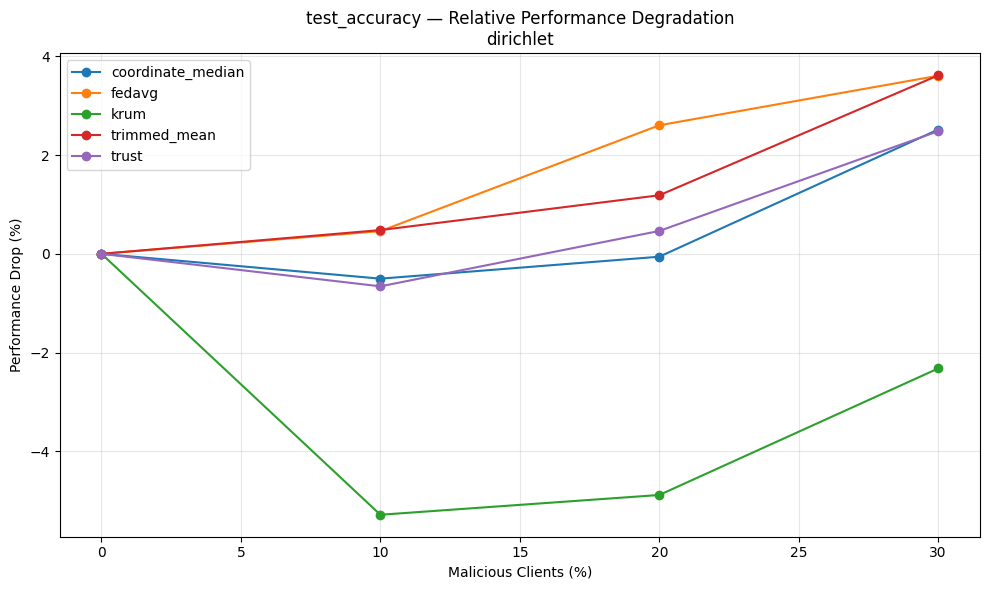

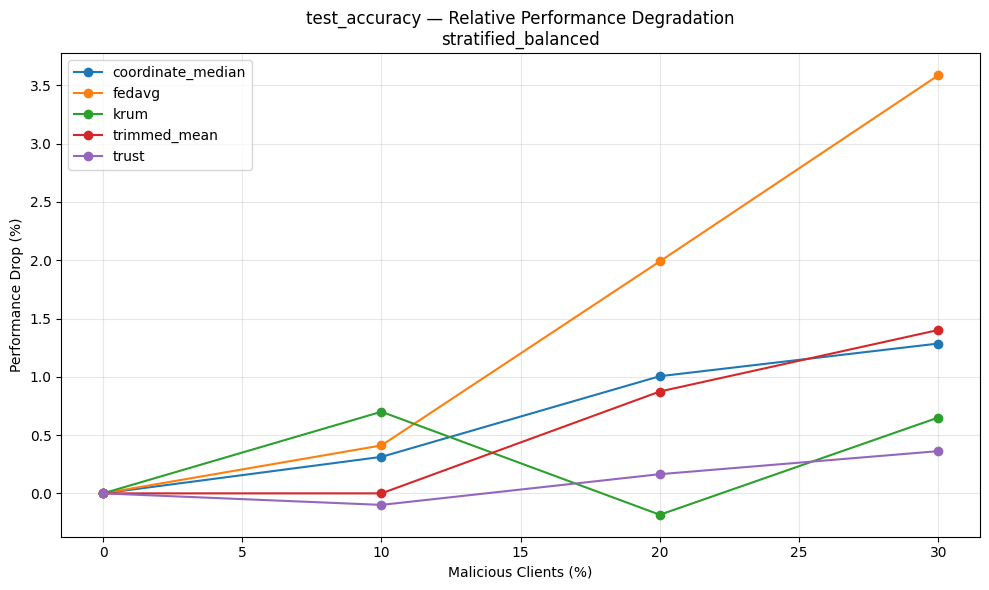


test_macro_f1


,partition,aggregation,malicious_fraction,test_macro_f1,clean_baseline,absolute_drop,relative_drop_percent
0,dirichlet,coordinate_median,0.0,0.659213,0.659213,0.000000,0.000000
1,dirichlet,coordinate_median,0.1,0.657939,0.659213,0.001274,0.193283
2,dirichlet,coordinate_median,0.2,0.648167,0.659213,0.011046,1.675592
3,dirichlet,coordinate_median,0.3,0.595880,0.659213,0.063333,9.607389
4,dirichlet,fedavg,0.0,0.593828,0.593828,0.000000,0.000000
5,dirichlet,fedavg,0.1,0.584152,0.593828,0.009676,1.629382
6,dirichlet,fedavg,0.2,0.533960,0.593828,0.059868,10.081654
7,dirichlet,fedavg,0.3,0.515675,0.593828,0.078152,13.160741
8,dirichlet,krum,0.0,0.371178,0.371178,0.000000,0.000000
9,dirichlet,krum,0.1,0.367925,0.371178,0.003253,0.876324


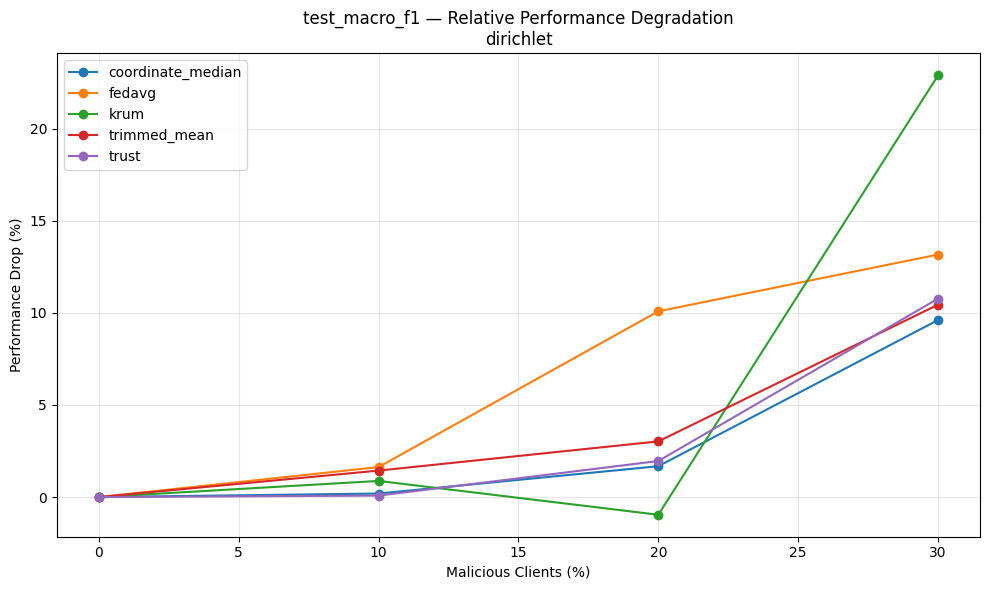

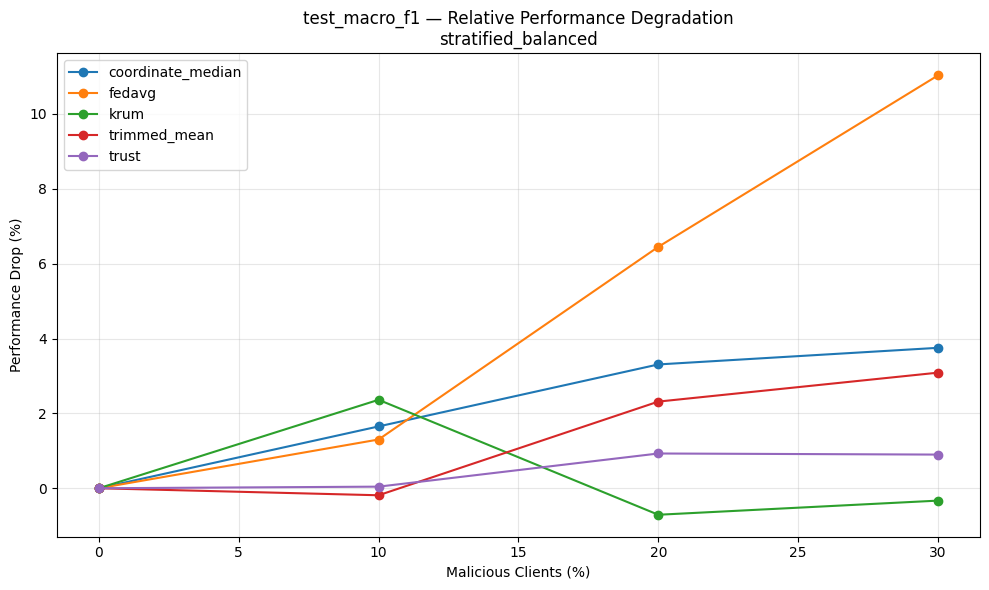


test_malignant_binary_recall


,partition,aggregation,malicious_fraction,test_malignant_binary_recall,clean_baseline,absolute_drop,relative_drop_percent
0,dirichlet,coordinate_median,0.0,0.629740,0.629740,0.000000,0.000000
1,dirichlet,coordinate_median,0.1,0.557621,0.629740,0.072119,11.452184
2,dirichlet,coordinate_median,0.2,0.521561,0.629740,0.108178,17.178276
3,dirichlet,coordinate_median,0.3,0.314498,0.629740,0.315242,50.059032
4,dirichlet,fedavg,0.0,0.462454,0.462454,0.000000,0.000000
5,dirichlet,fedavg,0.1,0.416357,0.462454,0.046097,9.967846
6,dirichlet,fedavg,0.2,0.281784,0.462454,0.180669,39.067524
7,dirichlet,fedavg,0.3,0.234944,0.462454,0.227509,49.196141
8,dirichlet,krum,0.0,0.490706,0.490706,0.000000,0.000000
9,dirichlet,krum,0.1,0.463197,0.490706,0.027509,5.606061


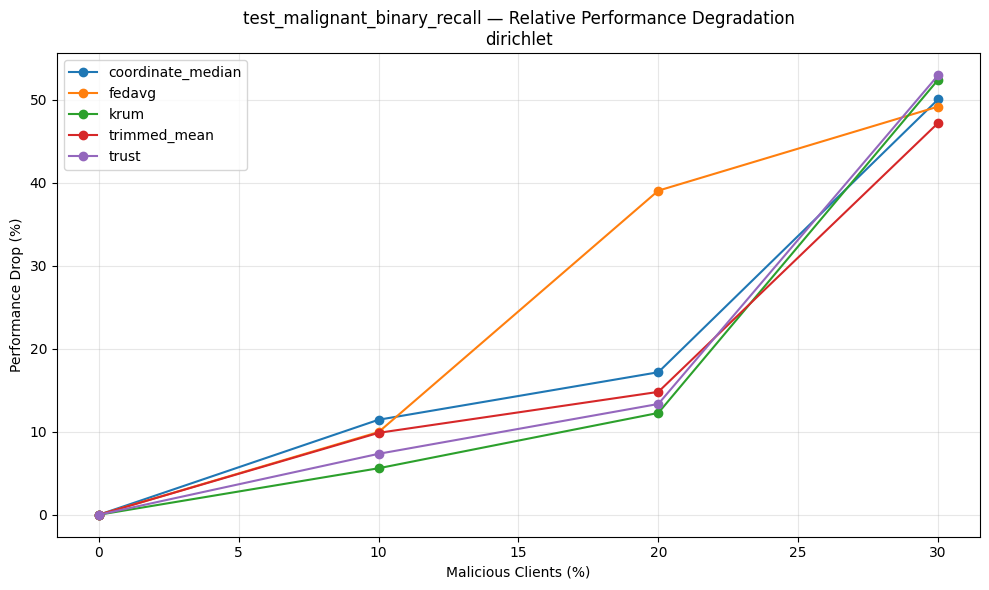

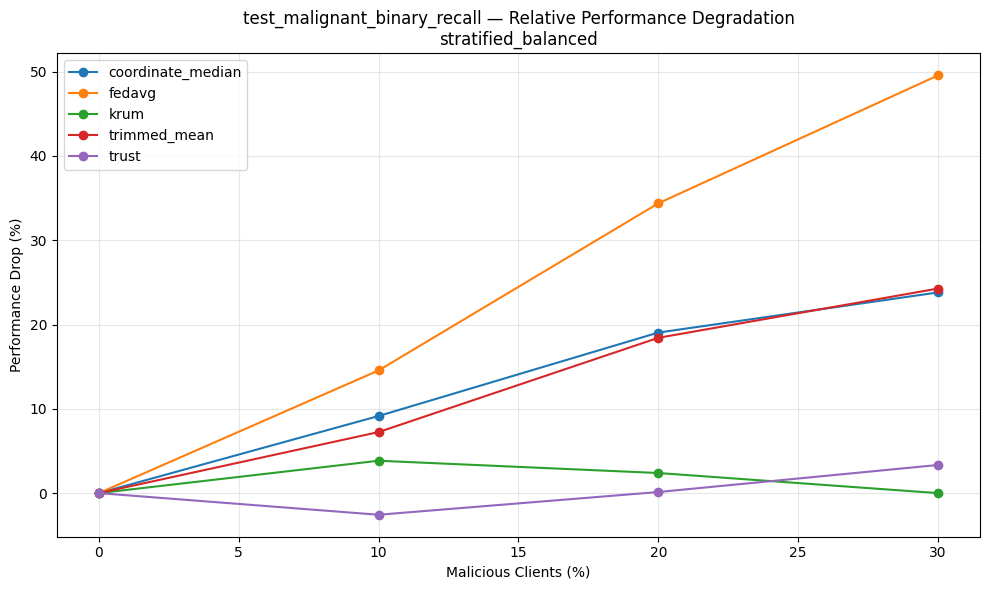


SECTION 25 COMPLETE


In [ ]:
# ============================================================
# Section 25 — Performance Degradation from Clean Baseline
# ============================================================

results_df = collect_results(STUDY_ROOT)

main_results = results_df[
    results_df["partition"].isin(["stratified_balanced", "dirichlet"])
].copy()

metrics = [
    "test_accuracy",
    "test_macro_f1",
    "test_malignant_binary_recall",
]

for metric in metrics:

    if metric not in main_results.columns:
        continue

    baseline = (
        main_results[
            main_results["malicious_fraction"] == 0
        ]
        .groupby(["partition", "aggregation"])[metric]
        .mean()
        .rename("clean_baseline")
        .reset_index()
    )

    poisoned = (
        main_results
        .groupby(
            ["partition", "aggregation", "malicious_fraction"]
        )[metric]
        .mean()
        .reset_index()
    )

    merged = poisoned.merge(
        baseline,
        on=["partition", "aggregation"],
        how="left"
    )

    merged["absolute_drop"] = (
        merged["clean_baseline"] - merged[metric]
    )

    merged["relative_drop_percent"] = (
        merged["absolute_drop"]
        / merged["clean_baseline"]
        * 100
    )

    print(f"\n{metric}")
    display(merged)

    for partition in merged["partition"].unique():

        subset = merged[
            merged["partition"] == partition
        ]

        plt.figure(figsize=(10, 6))

        for aggregation in subset["aggregation"].unique():

            d = subset[
                subset["aggregation"] == aggregation
            ].sort_values("malicious_fraction")

            plt.plot(
                d["malicious_fraction"] * 100,
                d["relative_drop_percent"],
                marker="o",
                label=aggregation
            )

        plt.xlabel("Malicious Clients (%)")
        plt.ylabel("Performance Drop (%)")
        plt.title(
            f"{metric} — Relative Performance Degradation\n"
            f"{partition}"
        )
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

print("\nSECTION 25 COMPLETE")

SECTION 26 — ATTACK SUCCESS RATE ANALYSIS


,partition,malicious_fraction,aggregation,mean,std,count
0,dirichlet,0.1,coordinate_median,0.284015,0.032790,5
1,dirichlet,0.1,fedavg,0.437175,0.084059,5
2,dirichlet,0.1,krum,0.401487,0.195441,5
3,dirichlet,0.1,trimmed_mean,0.315242,0.035501,5
4,dirichlet,0.1,trust,0.262454,0.061005,5
5,dirichlet,0.2,coordinate_median,0.315985,0.033204,10
6,dirichlet,0.2,fedavg,0.529740,0.090590,10
7,dirichlet,0.2,krum,0.454275,0.238001,10
8,dirichlet,0.2,trimmed_mean,0.317472,0.034661,10
9,dirichlet,0.2,trust,0.278513,0.072583,50


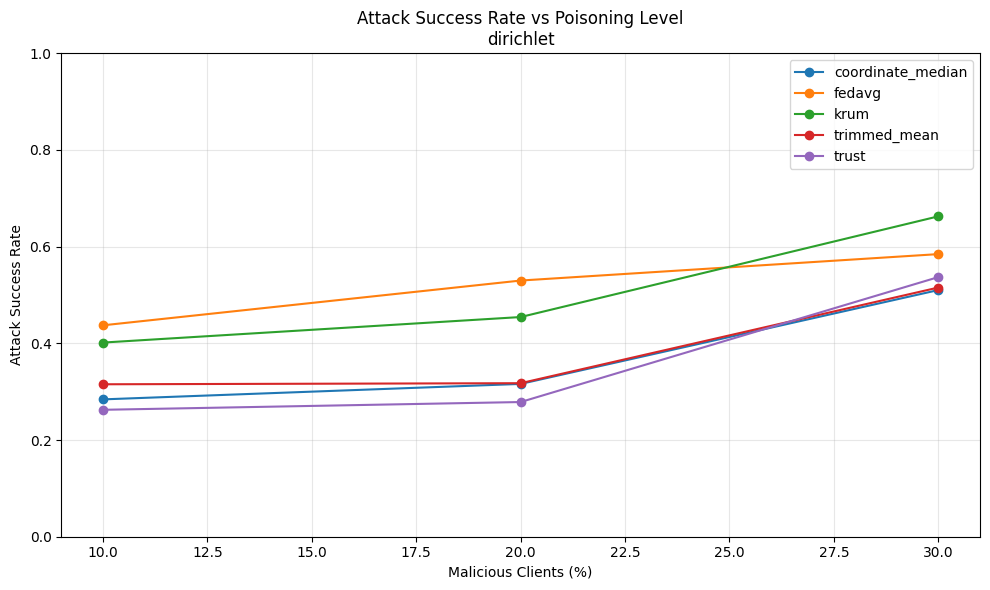

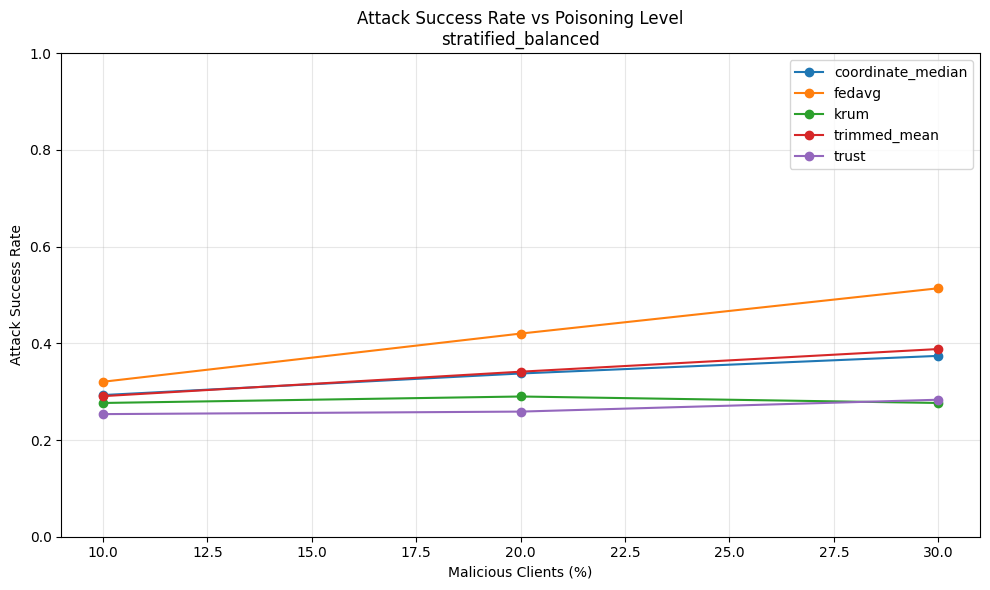


SECTION 26 COMPLETE


In [ ]:
# ============================================================
# Section 26 — Attack Success Rate Analysis
# ============================================================

results_df = collect_results(STUDY_ROOT)

if "test_asr" not in results_df.columns:
    raise KeyError("test_asr is not available in completed results.")

attack_results = results_df[
    results_df["malicious_fraction"] > 0
].copy()

asr_summary = (
    attack_results
    .groupby(
        ["partition", "malicious_fraction", "aggregation"]
    )["test_asr"]
    .agg(
        mean="mean",
        std="std",
        count="count"
    )
    .reset_index()
)

print("=" * 80)
print("SECTION 26 — ATTACK SUCCESS RATE ANALYSIS")
print("=" * 80)

display(asr_summary)


for partition in asr_summary["partition"].unique():

    subset = asr_summary[
        asr_summary["partition"] == partition
    ]

    plt.figure(figsize=(10, 6))

    for aggregation in subset["aggregation"].unique():

        d = subset[
            subset["aggregation"] == aggregation
        ].sort_values("malicious_fraction")

        plt.plot(
            d["malicious_fraction"] * 100,
            d["mean"],
            marker="o",
            label=aggregation
        )

    plt.xlabel("Malicious Clients (%)")
    plt.ylabel("Attack Success Rate")
    plt.title(
        f"Attack Success Rate vs Poisoning Level\n{partition}"
    )
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\nSECTION 26 COMPLETE")

SECTION 27 — MALIGNANT RECALL UNDER POISONING


,partition,malicious_fraction,aggregation,mean,std,count
0,dirichlet,0.0,coordinate_median,0.629740,0.058931,5
1,dirichlet,0.0,fedavg,0.462454,0.085283,5
2,dirichlet,0.0,krum,0.490706,0.252856,5
3,dirichlet,0.0,trimmed_mean,0.587361,0.043432,5
4,dirichlet,0.0,trust,0.627509,0.058152,5
5,dirichlet,0.1,coordinate_median,0.557621,0.038002,5
6,dirichlet,0.1,fedavg,0.416357,0.092228,5
7,dirichlet,0.1,krum,0.463197,0.209413,5
8,dirichlet,0.1,trimmed_mean,0.529368,0.033827,5
9,dirichlet,0.1,trust,0.581413,0.060550,5


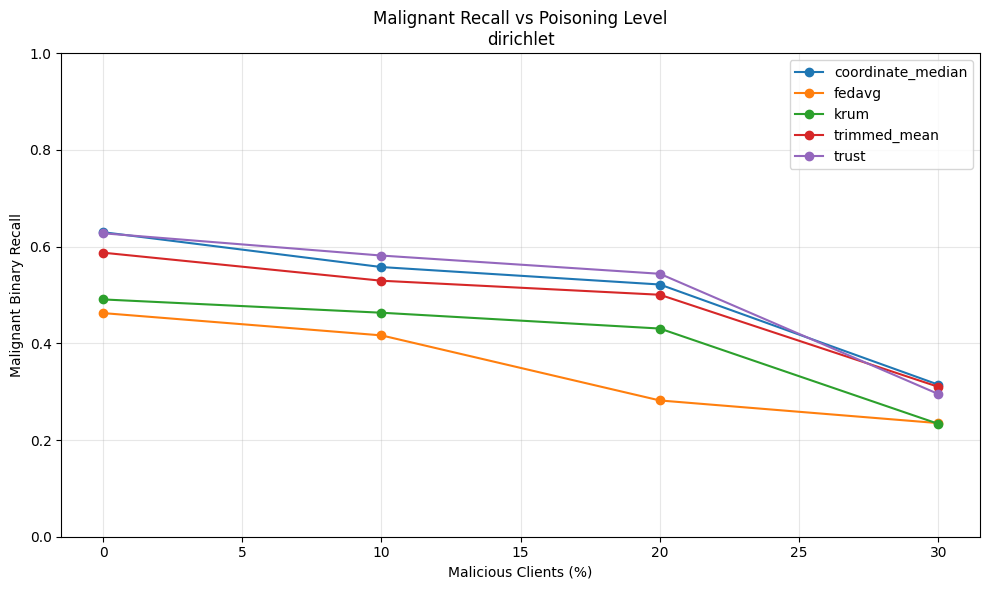

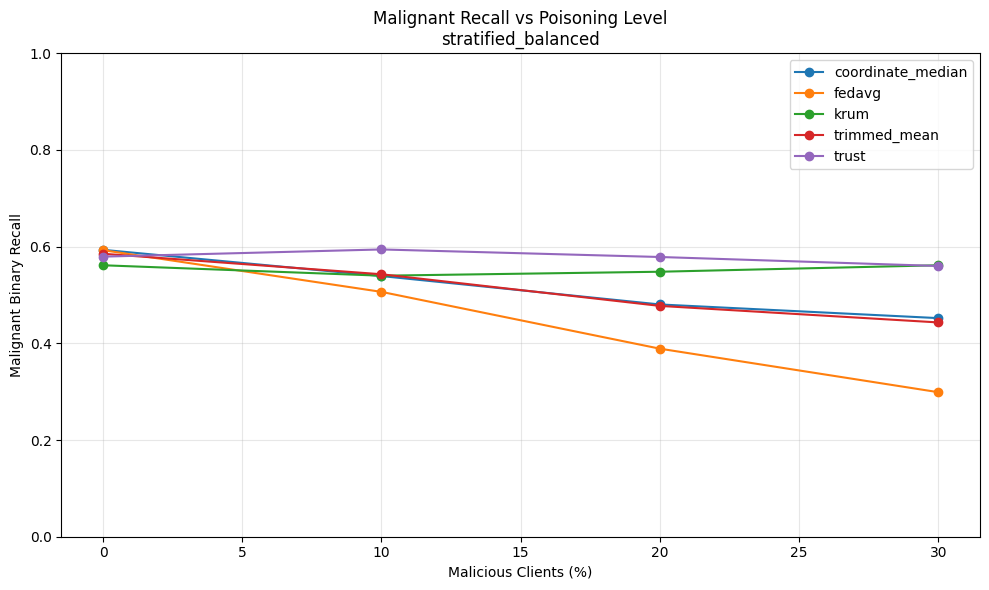


SECTION 27 COMPLETE


In [ ]:
# ============================================================
# Section 27 — Malignant Recall Under Poisoning
# ============================================================

results_df = collect_results(STUDY_ROOT)

metric = "test_malignant_binary_recall"

if metric not in results_df.columns:
    raise KeyError(
        f"{metric} is not available in completed results."
    )

summary = (
    results_df
    .groupby(
        ["partition", "malicious_fraction", "aggregation"]
    )[metric]
    .agg(
        mean="mean",
        std="std",
        count="count"
    )
    .reset_index()
)

print("=" * 80)
print("SECTION 27 — MALIGNANT RECALL UNDER POISONING")
print("=" * 80)

display(summary)


for partition in summary["partition"].unique():

    subset = summary[
        summary["partition"] == partition
    ]

    plt.figure(figsize=(10, 6))

    for aggregation in subset["aggregation"].unique():

        d = subset[
            subset["aggregation"] == aggregation
        ].sort_values("malicious_fraction")

        plt.plot(
            d["malicious_fraction"] * 100,
            d["mean"],
            marker="o",
            label=aggregation
        )

    plt.xlabel("Malicious Clients (%)")
    plt.ylabel("Malignant Binary Recall")
    plt.title(
        f"Malignant Recall vs Poisoning Level\n{partition}"
    )
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\nSECTION 27 COMPLETE")

saved -> /content/drive/MyDrive/FedResViT_G4_Pass/examiner_figures/fig02_frontier_dirichlet.png


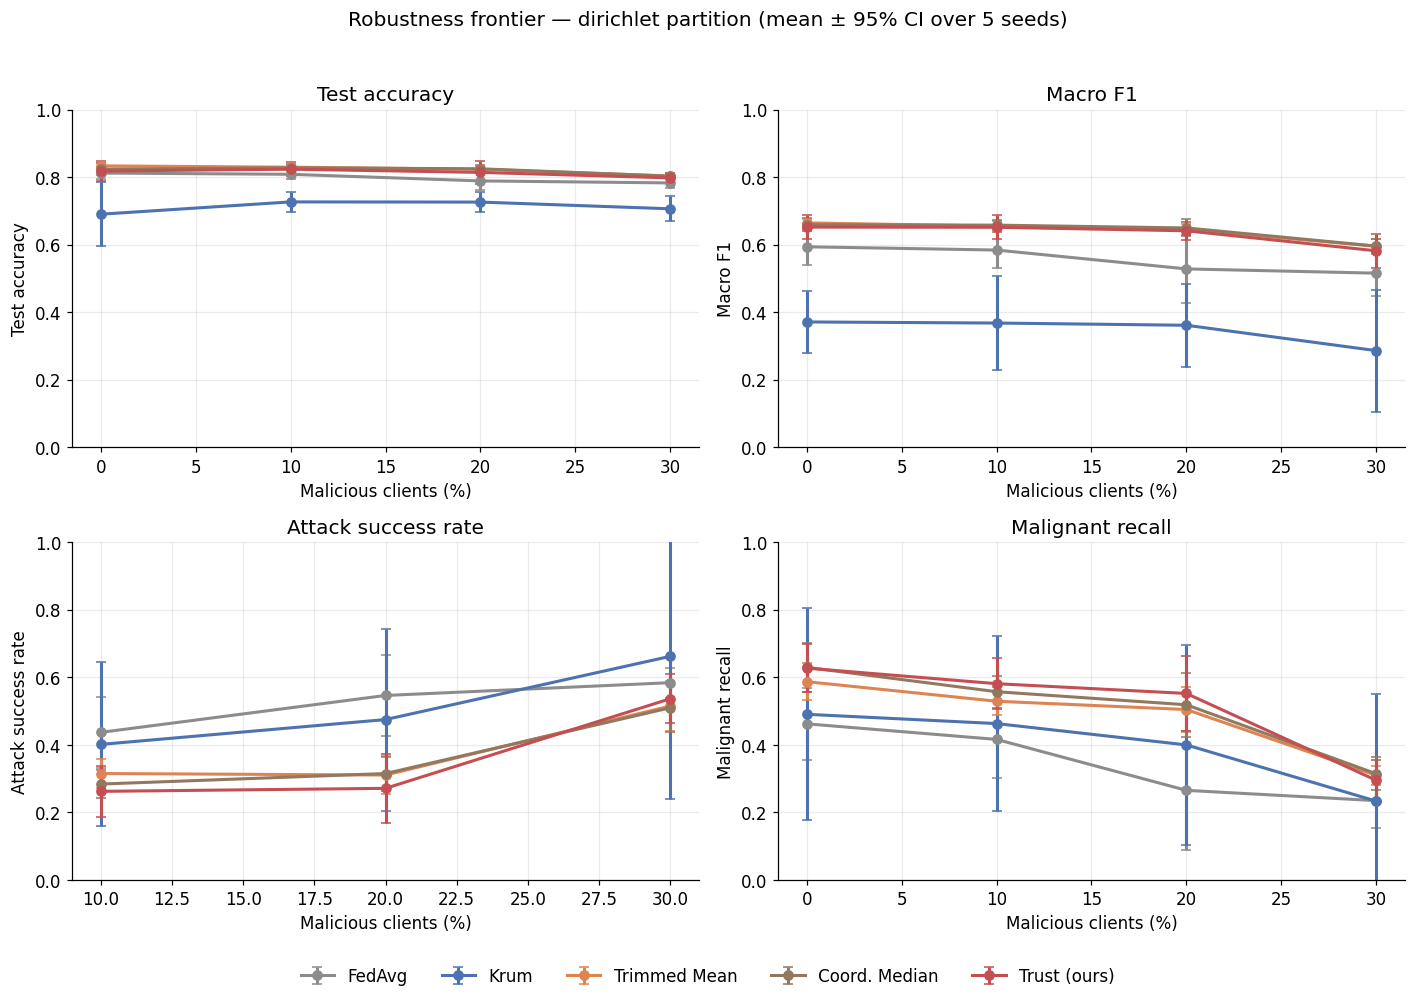

saved -> /content/drive/MyDrive/FedResViT_G4_Pass/examiner_figures/fig02_frontier_stratified_balanced.png


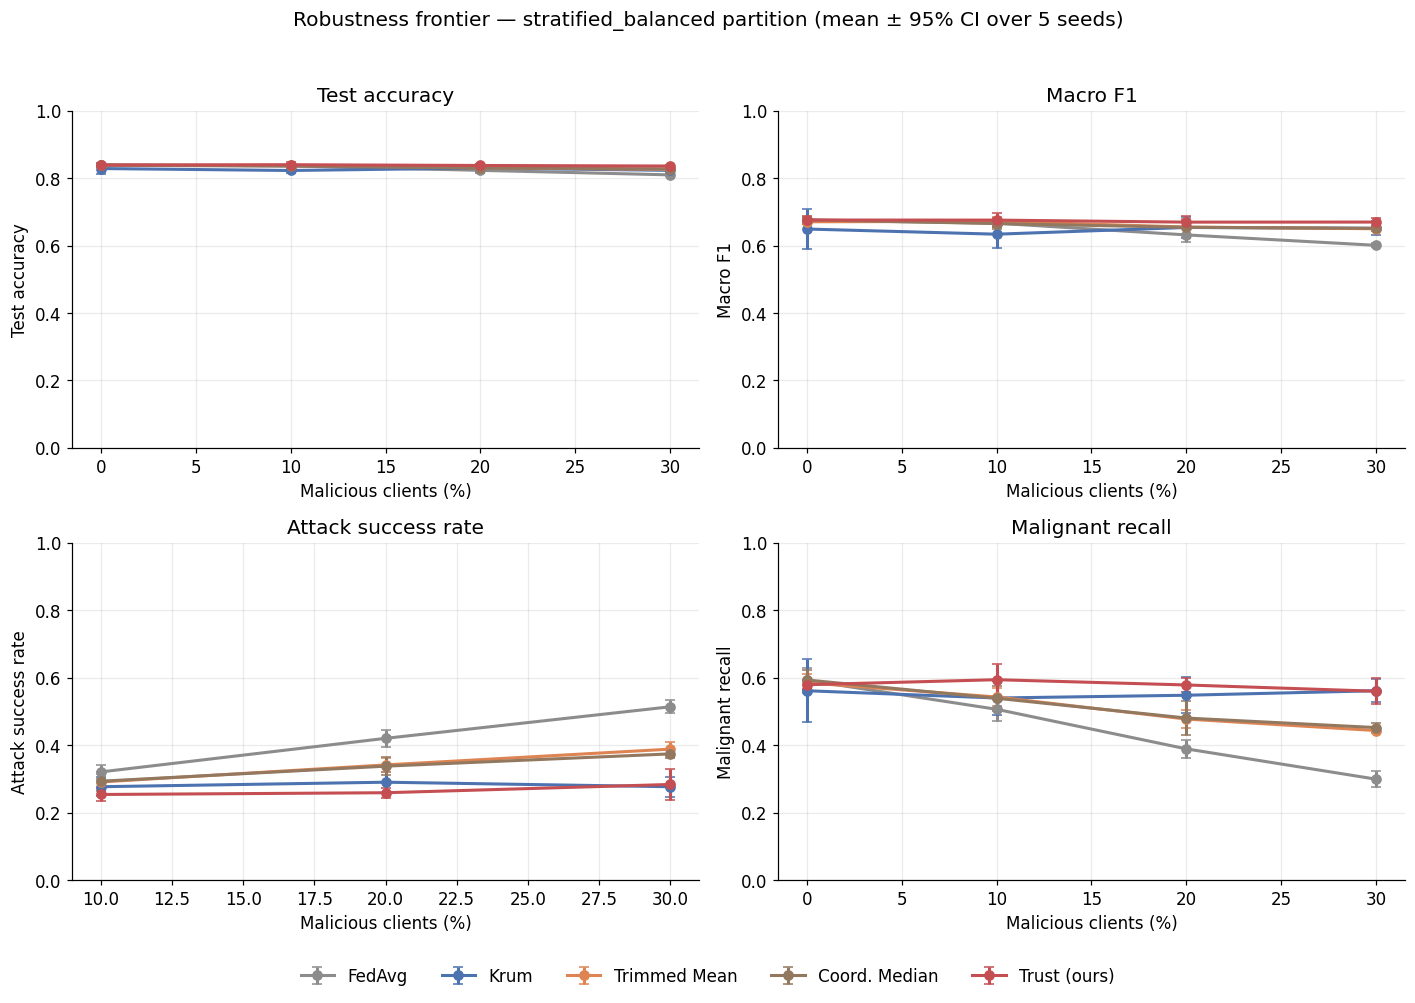

In [8]:
# ============================================================
# Figure 2 — Robustness frontier (utility and attack success)
# ============================================================
main = main_study(results_df)

panels = [("test_accuracy",                 "Test accuracy",            (0.0, 1.0)),
          ("test_macro_f1",                 "Macro F1",                 (0.0, 1.0)),
          ("test_asr",                      "Attack success rate",      (0.0, 1.0)),
          ("test_malignant_binary_recall",  "Malignant recall",         (0.0, 1.0))]

for partition, part_df in main.groupby("partition"):

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    for ax, (metric, nice, ylim) in zip(axes.ravel(), panels):

        if metric not in part_df.columns:
            ax.set_visible(False)
            continue

        for agg in aggs_present(part_df["aggregation"]):
            sub = part_df[part_df["aggregation"] == agg]
            grouped = sub.groupby("malicious_fraction")[metric]
            xs, means, halves = [], [], []
            for frac, series in grouped:
                m, h = mean_ci(series)
                if np.isnan(m):
                    continue
                xs.append(frac * 100)
                means.append(m)
                halves.append(h)
            if not xs:
                continue
            order = np.argsort(xs)
            xs = np.array(xs)[order]
            means = np.array(means)[order]
            halves = np.array(halves)[order]
            ax.errorbar(xs, means, yerr=halves, marker="o", capsize=3, lw=2,
                        color=AGG_COLOR.get(agg), label=label(agg))

        ax.set_xlabel("Malicious clients (%)")
        ax.set_ylabel(nice)
        ax.set_ylim(*ylim)
        ax.set_title(nice)

    handles, labels_ = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", ncol=min(6, len(labels_)),
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f"Robustness frontier — {partition} partition "
                 f"(mean ± 95% CI over {part_df['seed'].nunique()} seeds)", y=0.98)
    fig.tight_layout(rect=[0, 0.03, 1, 0.96])
    save_fig(fig, f"fig02_frontier_{partition}")
    plt.show()

saved -> /content/drive/MyDrive/FedResViT_G4_Pass/examiner_figures/fig04_roc_pr_dirichlet_20.png


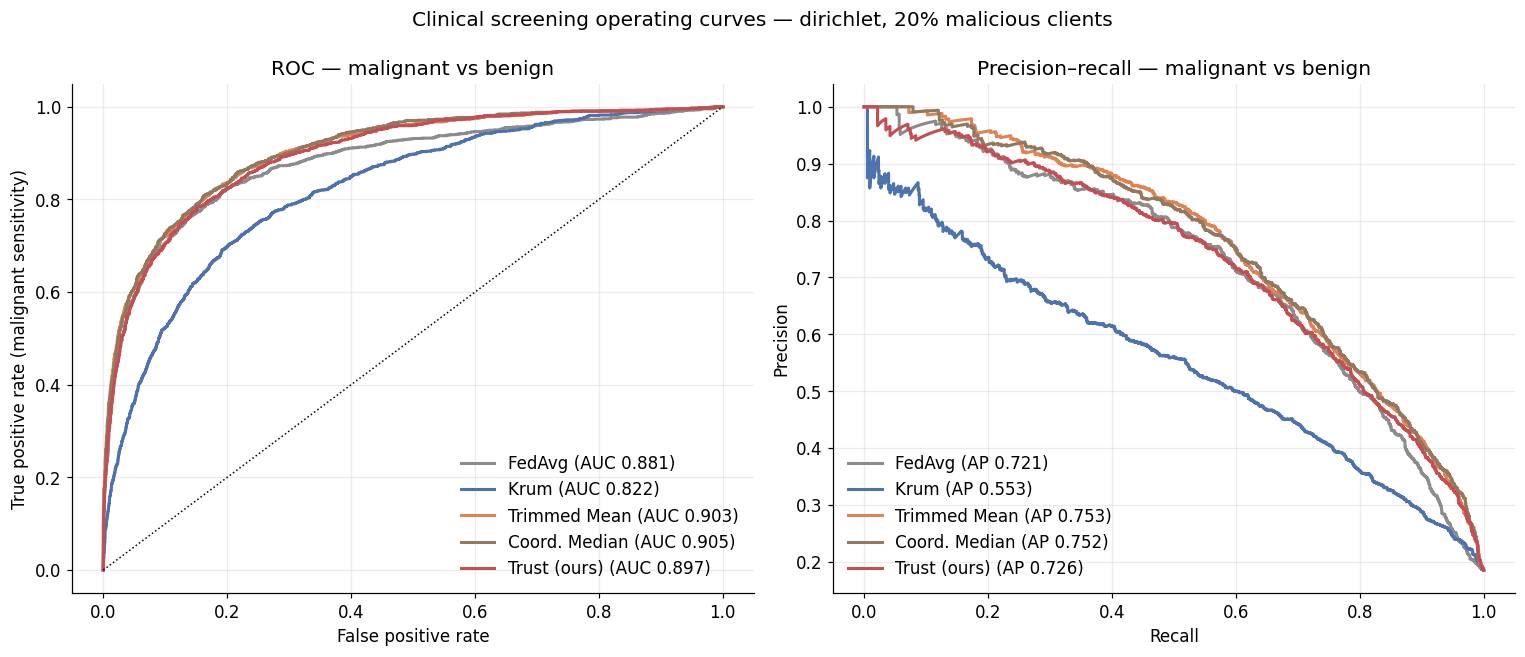

,Aggregator,ROC AUC,Average precision,Seeds pooled
0,FedAvg,0.8807,0.7209,5
1,Krum,0.8216,0.5530,5
2,Trimmed Mean,0.9029,0.7526,5
3,Coord. Median,0.9050,0.7523,5
4,Trust (ours),0.8969,0.7264,5


In [11]:
# ============================================================
# Figure 4 — Malignant-vs-benign ROC and precision-recall curves
# ============================================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

TARGET_PARTITION = "dirichlet"          # edit as needed
TARGET_FRACTION  = 0.2                  # poisoning level to illustrate

main = main_study(results_df)
subset = main[(main["partition"] == TARGET_PARTITION)
              & (main["malicious_fraction"] == TARGET_FRACTION)]

if subset.empty:
    raise ValueError(f"No runs for {TARGET_PARTITION} @ {TARGET_FRACTION:.0%}")

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))
auc_rows = []

for agg in aggs_present(subset["aggregation"]):

    y_true_all, y_score_all = [], []
    for _, run in subset[subset["aggregation"] == agg].iterrows():
        path = artifact(run, column="prediction_path")
        if path is None:
            continue
        with np.load(path) as data:
            y_true = data["y_true"]
            y_prob = data["y_prob"]
        y_true_all.append(np.isin(y_true, MALIGNANT_IDX_FIG).astype(int))
        y_score_all.append(y_prob[:, MALIGNANT_IDX_FIG].sum(axis=1))

    if not y_true_all:
        print(f"{agg}: no prediction files found; skipping.")
        continue

    y_true_all = np.concatenate(y_true_all)
    y_score_all = np.concatenate(y_score_all)

    fpr, tpr, _ = roc_curve(y_true_all, y_score_all)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true_all, y_score_all)
    ap = average_precision_score(y_true_all, y_score_all)

    ax_roc.plot(fpr, tpr, lw=2, color=AGG_COLOR.get(agg),
                label=f"{label(agg)} (AUC {roc_auc:.3f})")
    ax_pr.plot(recall, precision, lw=2, color=AGG_COLOR.get(agg),
               label=f"{label(agg)} (AP {ap:.3f})")
    auc_rows.append({"Aggregator": label(agg), "ROC AUC": round(roc_auc, 4),
                     "Average precision": round(ap, 4),
                     "Seeds pooled": subset[subset["aggregation"] == agg]["seed"].nunique()})

ax_roc.plot([0, 1], [0, 1], ls=":", color="black", lw=1)
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate (malignant sensitivity)")
ax_roc.set_title("ROC — malignant vs benign")
ax_roc.legend(loc="lower right")

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision–recall — malignant vs benign")
ax_pr.legend(loc="lower left")

fig.suptitle(f"Clinical screening operating curves — {TARGET_PARTITION}, "
             f"{TARGET_FRACTION:.0%} malicious clients", y=0.99)
fig.tight_layout()
save_fig(fig, f"fig04_roc_pr_{TARGET_PARTITION}_{int(TARGET_FRACTION * 100)}")
plt.show()

display(pd.DataFrame(auc_rows))

saved -> /content/drive/MyDrive/FedResViT_G4_Pass/examiner_figures/fig06_confusion_differential.png


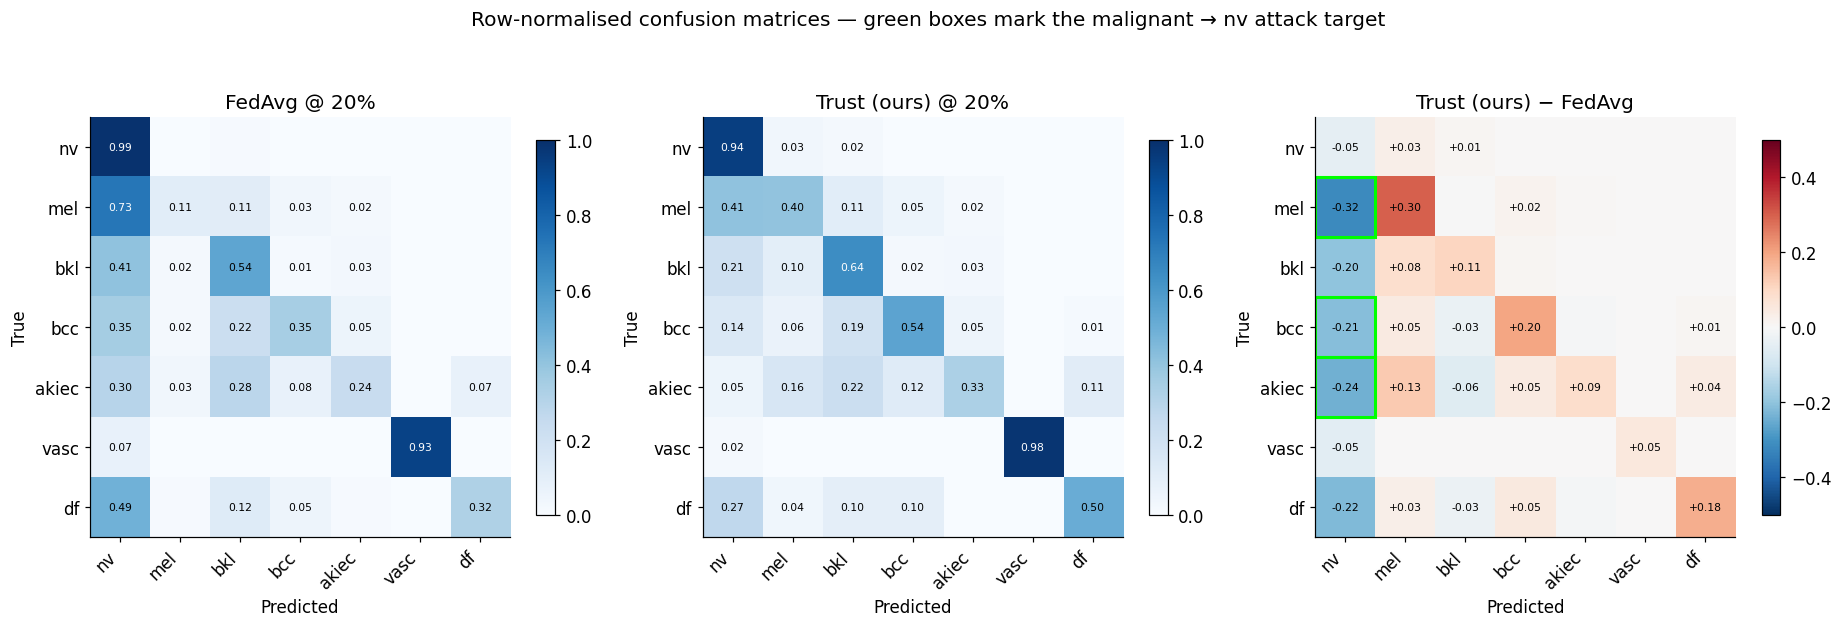

In [13]:
# ============================================================
# Figure 6 — Confusion matrices and differential under attack
# ============================================================
TARGET_PARTITION = "dirichlet"
TARGET_FRACTION  = 0.2
DEFENCE, BASELINE = "trust", "fedavg"

main = main_study(results_df)


def mean_confusion(aggregation):
    sel = main[(main["partition"] == TARGET_PARTITION)
               & (main["malicious_fraction"] == TARGET_FRACTION)
               & (main["aggregation"] == aggregation)]
    mats = []
    for _, run in sel.iterrows():
        path = artifact(run, name="confusion_matrix.csv")
        if path is None:
            continue
        cm = pd.read_csv(path, index_col=0).reindex(index=CLASS_ORDER_FIG,
                                                    columns=CLASS_ORDER_FIG).values.astype(float)
        totals = cm.sum(axis=1, keepdims=True)
        mats.append(np.divide(cm, totals, out=np.zeros_like(cm), where=totals > 0))
    if not mats:
        return None
    return np.mean(mats, axis=0)


cm_base = mean_confusion(BASELINE)
cm_def = mean_confusion(DEFENCE)

if cm_base is None or cm_def is None:
    raise ValueError("Missing confusion_matrix.csv for one of the aggregators.")

fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
specs = [(cm_base, f"{label(BASELINE)} @ {TARGET_FRACTION:.0%}", "Blues", 0, 1),
         (cm_def, f"{label(DEFENCE)} @ {TARGET_FRACTION:.0%}", "Blues", 0, 1),
         (cm_def - cm_base, f"{label(DEFENCE)} − {label(BASELINE)}", "RdBu_r", -0.5, 0.5)]

for ax, (matrix, title, cmap, vmin, vmax) in zip(axes, specs):
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(7)); ax.set_xticklabels(CLASS_ORDER_FIG, rotation=45, ha="right")
    ax.set_yticks(range(7)); ax.set_yticklabels(CLASS_ORDER_FIG)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title); ax.grid(False)
    for i in range(7):
        for j in range(7):
            if abs(matrix[i, j]) >= 0.01:
                ax.text(j, i, f"{matrix[i, j]:+.2f}" if vmin < 0 else f"{matrix[i, j]:.2f}",
                        ha="center", va="center", fontsize=7,
                        color="white" if abs(matrix[i, j]) > 0.6 else "black")
    fig.colorbar(im, ax=ax, shrink=0.75)

for idx in MALIGNANT_IDX_FIG:
    axes[2].add_patch(plt.Rectangle((TARGET_BENIGN_FIG - 0.5, idx - 0.5), 1, 1,
                                    fill=False, edgecolor="lime", lw=2))

fig.suptitle("Row-normalised confusion matrices — green boxes mark the "
             "malignant → nv attack target", y=1.02)
fig.tight_layout()
save_fig(fig, "fig06_confusion_differential")
plt.show()

In [ ]:
# ============================================================
# Section 30 — Statistical Summary and Effect Size
# ============================================================

results_df = collect_results(STUDY_ROOT)

metric = "test_macro_f1"

if metric not in results_df.columns:
    raise KeyError(
        f"{metric} is not available."
    )

rows = []

for frac in sorted(
    results_df["malicious_fraction"].dropna().unique()
):

    subset = results_df[
        results_df["malicious_fraction"] == frac
    ]

    trust = subset[
        subset["aggregation"] == "trust"
    ][metric].dropna()

    fedavg = subset[
        subset["aggregation"] == "fedavg"
    ][metric].dropna()

    if len(trust) == 0 or len(fedavg) == 0:
        continue

    trust_mean = trust.mean()
    fedavg_mean = fedavg.mean()

    pooled_std = np.sqrt(
        (
            (len(trust) - 1) * trust.var(ddof=1)
            +
            (len(fedavg) - 1) * fedavg.var(ddof=1)
        )
        /
        (
            len(trust) + len(fedavg) - 2
        )
    ) if len(trust) > 1 and len(fedavg) > 1 else np.nan

    cohens_d = (
        (trust_mean - fedavg_mean) / pooled_std
        if pd.notna(pooled_std) and pooled_std != 0
        else np.nan
    )

    rows.append({
        "malicious_fraction": frac,
        "trust_mean": trust_mean,
        "fedavg_mean": fedavg_mean,
        "trust_minus_fedavg": trust_mean - fedavg_mean,
        "cohens_d": cohens_d,
        "trust_n": len(trust),
        "fedavg_n": len(fedavg),
    })


effect_table = pd.DataFrame(rows)

print("=" * 80)
print("SECTION 30 — TRUST VS FEDAVG EFFECT SIZE")
print("=" * 80)

display(effect_table)

print(
    "\nNote: effect-size interpretation should be treated as "
    "preliminary until the planned seed coverage is complete."
)

print("\nSECTION 30 COMPLETE")

SECTION 30 — TRUST VS FEDAVG EFFECT SIZE


,malicious_fraction,trust_mean,fedavg_mean,trust_minus_fedavg,cohens_d,trust_n,fedavg_n
0,0.0,0.663880,0.634403,0.029476,0.733918,10,10
1,0.1,0.663470,0.625171,0.038299,0.927837,10,10
2,0.2,0.647817,0.566457,0.081360,1.454667,15,15
3,0.3,0.625728,0.558107,0.067620,1.210483,10,10



Note: effect-size interpretation should be treated as preliminary until the planned seed coverage is complete.

SECTION 30 COMPLETE


SECTION 31 — ADAPTIVE ATTACK ANALYSIS


test_accuracy                 test_macro_f1                  \
                           mean       std count          mean       std count   
aggregation                                                                     
coordinate_median      0.823619  0.008744     5      0.646713  0.023650     5   
fedavg                 0.793370  0.018346     5      0.539625  0.069537     5   
krum                   0.721823  0.026958     5      0.388116  0.134023     5   
trimmed_mean           0.823895  0.008500     5      0.643178  0.018157     5   
trust                  0.820856  0.011797     5      0.632876  0.020954     5   

                  test_malignant_binary_recall                  test_asr  \
                                          mean       std count      mean   
aggregation                                                                
coordinate_median                     0.524164  0.070289     5  0.316729   
fedavg                                0.298141  0.127791     5  0.513011   
krum                                  0.460967  0.274225     5  0.433457   
trimmed_mean                          0.495911  0.056108     5  0.324164   
trust                                 0.498141  0.047607     5  0.315242   

                                   
                        std count  
aggregation                        
coordinate_median  0.028843     5  
fedavg             0.090793     5  
krum               0.281580     5  
trimmed_mean       0.024993     5  
trust              0.029201     5

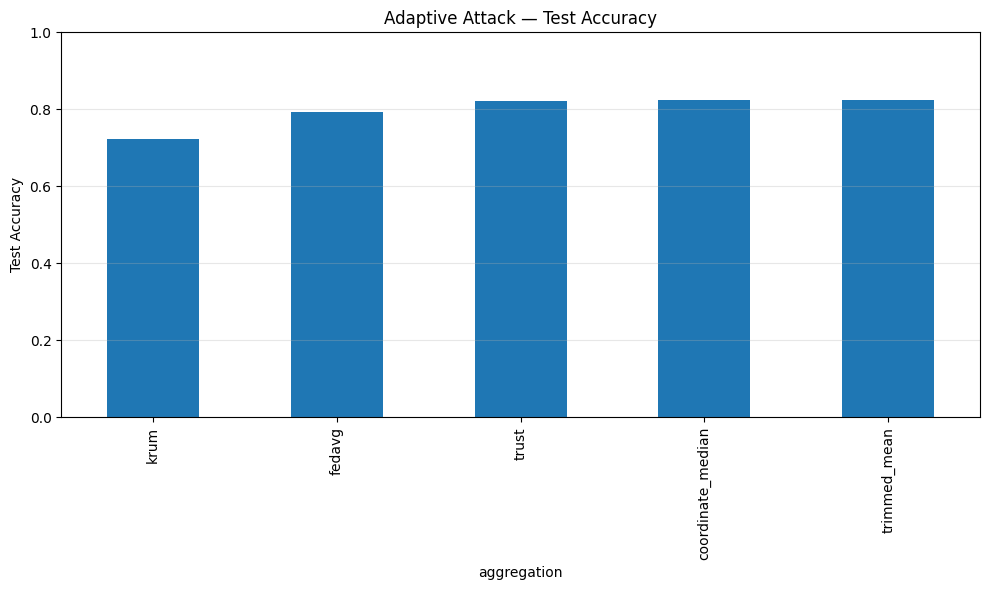

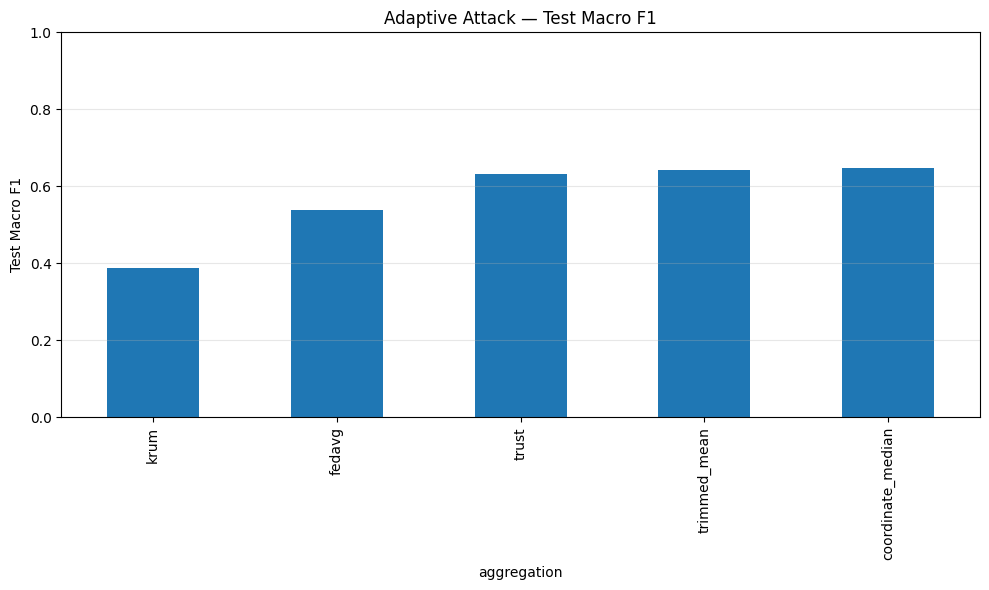

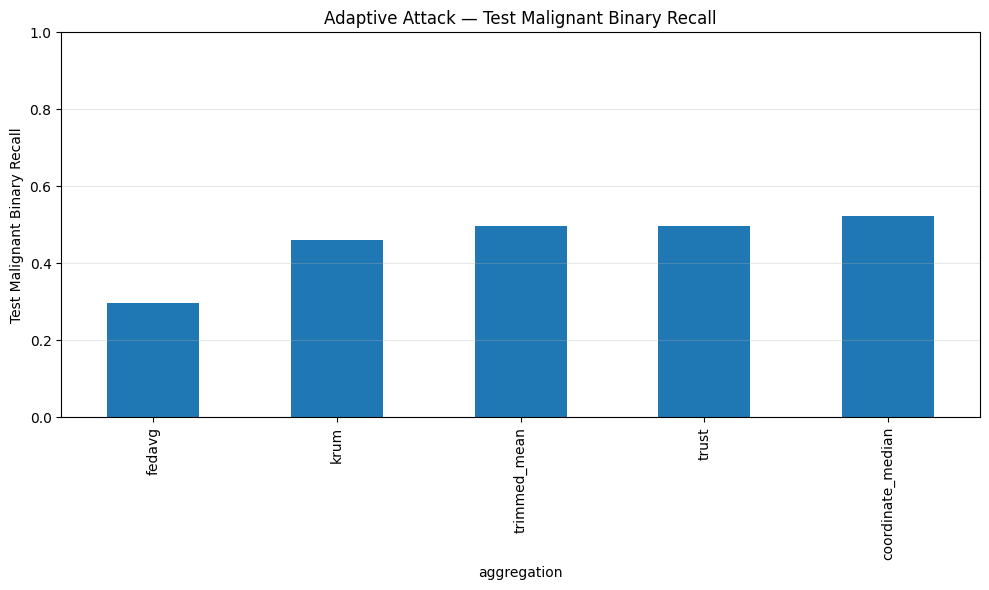

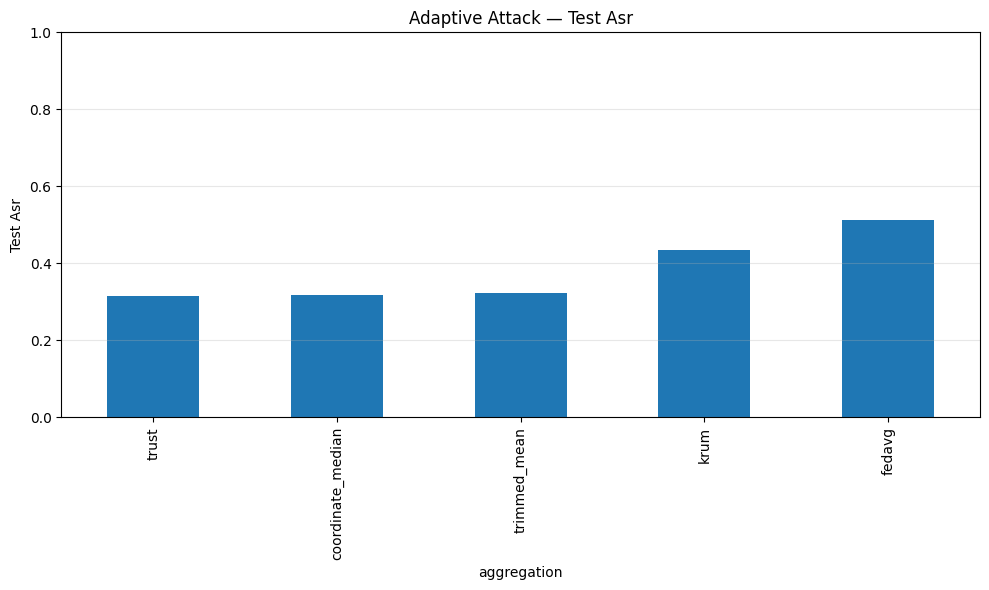


SECTION 31 COMPLETE


In [ ]:
# ============================================================
# Section 31 — Adaptive Attack Analysis
# ============================================================

results_df = collect_results(STUDY_ROOT)

adaptive = results_df[
    results_df["attack"].astype(str)
    == "adaptive_omniscient_blend"
].copy()

if adaptive.empty:
    print(
        "No adaptive-attack runs have completed yet."
    )

else:

    print("=" * 80)
    print("SECTION 31 — ADAPTIVE ATTACK ANALYSIS")
    print("=" * 80)

    metrics = [
        "test_accuracy",
        "test_macro_f1",
        "test_malignant_binary_recall",
        "test_asr",
        "detection_rate",
        "false_positive_rate",
    ]

    available = [
        m for m in metrics
        if m in adaptive.columns
    ]

    summary = (
        adaptive
        .groupby(["aggregation"])[available]
        .agg(["mean", "std", "count"])
    )

    display(summary)

    for metric in available:

        data = (
            adaptive
            .groupby("aggregation")[metric]
            .mean()
            .sort_values()
        )

        plt.figure(figsize=(10, 6))

        data.plot(
            kind="bar"
        )

        plt.ylabel(
            metric.replace("_", " ").title()
        )

        plt.title(
            f"Adaptive Attack — "
            f"{metric.replace('_', ' ').title()}"
        )

        plt.ylim(0, 1)
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

print("\nSECTION 31 COMPLETE")

SECTION 32 — TRUST SENSITIVITY ANALYSIS


,setting,test_accuracy,test_macro_f1,test_malignant_binary_recall,test_asr
0,default,0.810571,0.605599,0.481652,0.378524


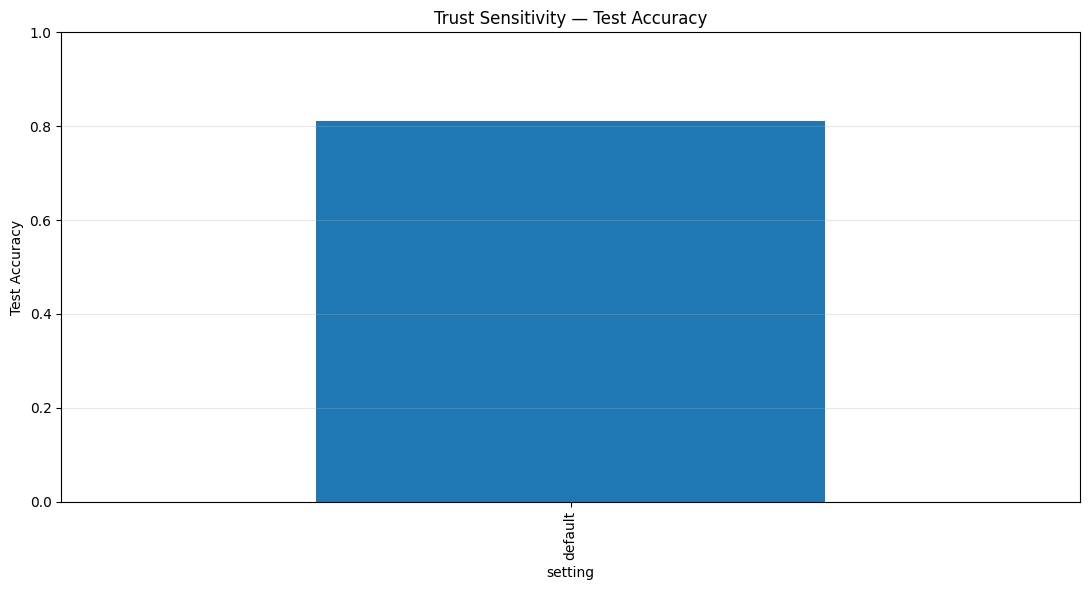

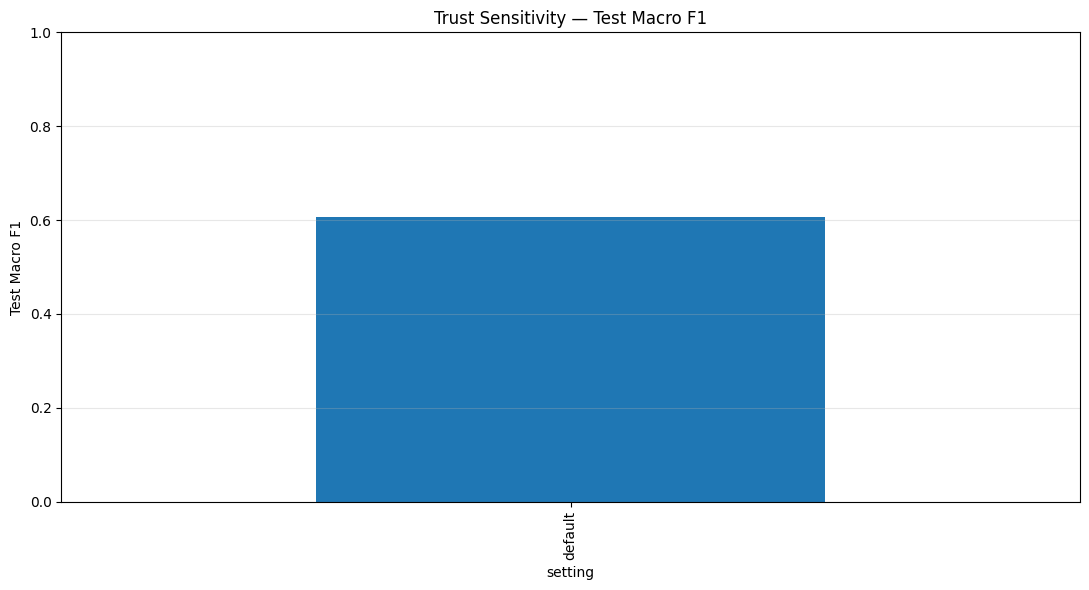

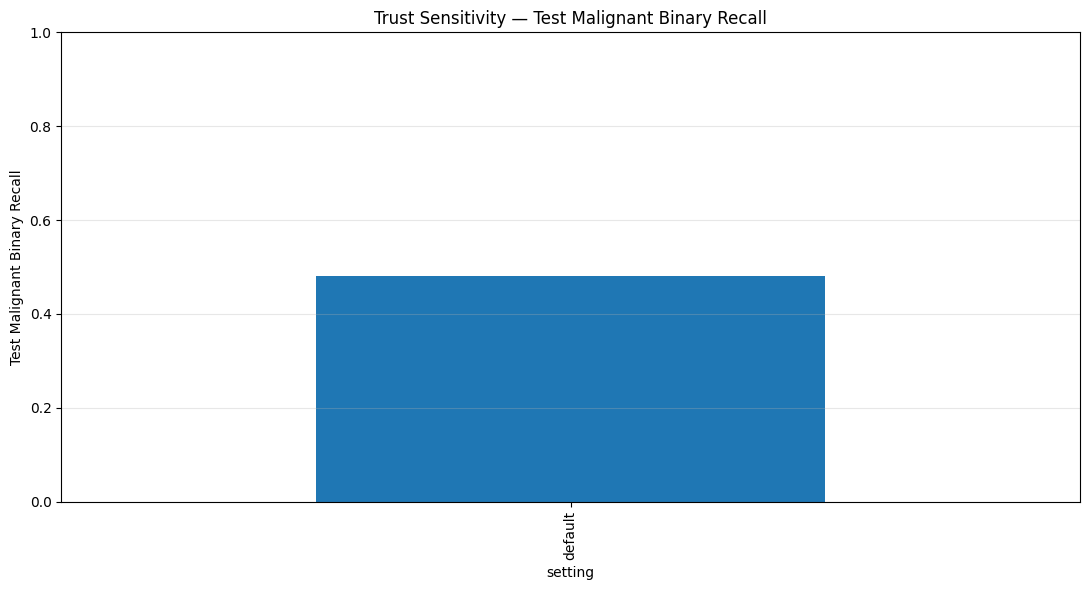

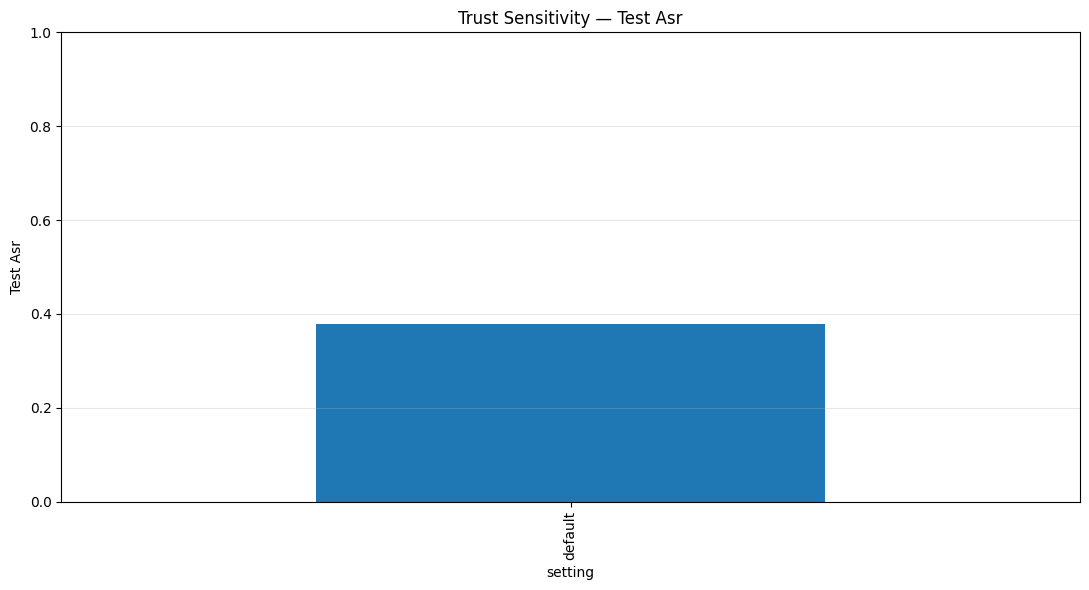


SECTION 32 COMPLETE


In [ ]:
# ============================================================
# Section 32 — Trust Sensitivity Analysis
# ============================================================

results_df = collect_results(STUDY_ROOT)

sensitivity = results_df[
    results_df["setting"].astype(str).isin([
        "default",
        "mad_narrow",
        "mad_wide",
        "ema_fast",
        "ema_slow",
        "flag_low",
        "flag_high",
        "window_1",
        "window_10",
    ])
].copy()

if sensitivity.empty:

    print(
        "No Trust sensitivity runs have completed yet."
    )

else:

    print("=" * 80)
    print("SECTION 32 — TRUST SENSITIVITY ANALYSIS")
    print("=" * 80)

    metrics = [
        "test_accuracy",
        "test_macro_f1",
        "test_malignant_binary_recall",
        "test_asr",
        "detection_rate",
        "false_positive_rate",
    ]

    available = [
        m for m in metrics
        if m in sensitivity.columns
    ]

    summary = (
        sensitivity
        .groupby("setting")[available]
        .mean()
        .reset_index()
    )

    display(summary)

    for metric in available:

        plot_data = (
            sensitivity
            .groupby("setting")[metric]
            .mean()
            .sort_values()
        )

        plt.figure(figsize=(11, 6))

        plot_data.plot(
            kind="bar"
        )

        plt.ylabel(
            metric.replace("_", " ").title()
        )

        plt.title(
            f"Trust Sensitivity — "
            f"{metric.replace('_', ' ').title()}"
        )

        plt.ylim(0, 1)
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

print("\nSECTION 32 COMPLETE")

In [ ]:
# ============================================================
# Section 34 — Final Consolidated Results
# ============================================================

results_df = collect_results(STUDY_ROOT)

if results_df.empty:
    raise ValueError("No completed results found.")


print("=" * 80)
print("SECTION 34 — FINAL CONSOLIDATED RESULTS")
print("=" * 80)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

metrics = [
    "test_accuracy",
    "test_macro_f1",
    "test_malignant_binary_recall",
    "test_asr",
    "detection_rate",
    "false_positive_rate",
]


available = [
    m for m in metrics
    if m in results_df.columns
]


# ------------------------------------------------------------
# Aggregate results
# ------------------------------------------------------------

final_summary = (
    results_df
    .groupby(
        [
            "partition",
            "malicious_fraction",
            "aggregation",
        ]
    )[available]
    .agg(
        ["mean", "std", "count"]
    )
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(final_summary)


# ------------------------------------------------------------
# Export consolidated table
# ------------------------------------------------------------

final_output_path = (
    Path(STUDY_ROOT)
    / "final_consolidated_results.csv"
)

final_summary.to_csv(
    final_output_path
)

print(
    "\nConsolidated results saved to:"
)

print(final_output_path)


# ------------------------------------------------------------
# Best-performing aggregation by Macro-F1
# ------------------------------------------------------------

if "test_macro_f1" in results_df.columns:

    ranking = (
        results_df
        .groupby(
            [
                "partition",
                "malicious_fraction",
                "aggregation",
            ]
        )["test_macro_f1"]
        .mean()
        .reset_index()
        .sort_values(
            [
                "partition",
                "malicious_fraction",
                "test_macro_f1",
            ],
            ascending=[True, True, False]
        )
    )

    print("\nMacro-F1 ranking:")
    display(ranking)


print(
    "\nSECTION 34 COMPLETE — "
    "FINAL CONSOLIDATED RESULTS"
)

SECTION 34 — FINAL CONSOLIDATED RESULTS


test_accuracy  \
                                                                  mean   
partition           malicious_fraction aggregation                       
dirichlet           0.0                coordinate_median      0.823757   
                                       fedavg                 0.812293   
                                       krum                   0.690331   
                                       trimmed_mean           0.833564   
                                       trust                  0.818232   
                    0.1                coordinate_median      0.827901   
                                       fedavg                 0.808564   
                                       krum                   0.726796   
                                       trimmed_mean           0.829558   
                                       trust                  0.823619   
                    0.2                coordinate_median      0.824240   
                                       fedavg                 0.791160   
                                       krum                   0.724033   
                                       trimmed_mean           0.823688   
                                       trust                  0.817541   
                    0.3                coordinate_median      0.803039   
                                       fedavg                 0.783011   
                                       krum                   0.706354   
                                       trimmed_mean           0.803453   
                                       trust                  0.797928   
stratified_balanced 0.0                coordinate_median      0.838122   
                                       fedavg                 0.839641   
                                       krum                   0.828315   
                                       trimmed_mean           0.837707   
                                       trust                  0.838812   
                    0.1                coordinate_median      0.835497   
                                       fedavg                 0.836188   
                                       krum                   0.822514   
                                       trimmed_mean           0.837707   
                                       trust                  0.839641   
                    0.2                coordinate_median      0.829696   
                                       fedavg                 0.822928   
                                       krum                   0.829834   
                                       trimmed_mean           0.830387   
                                       trust                  0.837431   
                    0.3                coordinate_median      0.827348   
                                       fedavg                 0.809530   
                                       krum                   0.822928   
                                       trimmed_mean           0.825967   
                                       trust                  0.835773   

                                                                          \
                                                               std count   
partition           malicious_fraction aggregation                         
dirichlet           0.0                coordinate_median  0.014983     5   
                                       fedavg             0.014274     5   
                                       krum               0.076379     5   
                                       trimmed_mean       0.006235     5   
                                       trust              0.023965     5   
                    0.1                coordinate_median  0.008264     5   
                                       fedavg             0.012300     5   
                                       krum               0.023387     5   
                                      


Consolidated results saved to:
/content/drive/MyDrive/FedResViT_G4_Pass/study/final_consolidated_results.csv

Macro-F1 ranking:


,partition,malicious_fraction,aggregation,test_macro_f1
3,dirichlet,0.0,trimmed_mean,0.664592
0,dirichlet,0.0,coordinate_median,0.659213
4,dirichlet,0.0,trust,0.652141
1,dirichlet,0.0,fedavg,0.593828
2,dirichlet,0.0,krum,0.371178
5,dirichlet,0.1,coordinate_median,0.657939
8,dirichlet,0.1,trimmed_mean,0.655033
9,dirichlet,0.1,trust,0.651611
6,dirichlet,0.1,fedavg,0.584152
7,dirichlet,0.1,krum,0.367925



SECTION 34 COMPLETE — FINAL CONSOLIDATED RESULTS


## 26. Save final outputs

Save the active configuration, execution environment and result exports after analysis.


In [ ]:
# SECTION 25A — FREEZE COMPLETED ADAPTIVE STUDY METADATA
# Safe checkpoint — does NOT run training.

import json
import os
import platform
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

study_root = Path(STUDY_ROOT)
study_root.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Construct the ACTUAL completed Adaptive configuration
# ============================================================

adaptive_config = dict(CONFIG)

adaptive_config.update({
    'STUDY_STAGE': 'adaptive',
    'PARTITION_METHOD': 'dirichlet',
    'DIRICHLET_ALPHA': 0.5,
    'ATTACK_MODE': 'adaptive_omniscient_blend',
    'SETTING': 'default',
    'MALICIOUS_FRACTIONS': [0.2],
    'AGGREGATORS': [
        'fedavg',
        'krum',
        'trimmed_mean',
        'coordinate_median',
        'trust'
    ],
    'SEEDS': [42, 43, 44, 45, 46],
    'NUM_CLIENTS': 10,
    'NUM_ROUNDS': 30,
    'LOCAL_EPOCHS': 2,
    'BATCH_SIZE': 16,
    'ADAPTIVE_BLEND_GRID': [1.0, 0.75, 0.5, 0.25, 0.1, 0.0],
    'JOB_START': 0,
    'JOB_STOP': 25,
    'TRAIN_ENABLED': True,
})

# ============================================================
# 2. Save Adaptive configuration
# ============================================================

adaptive_config_path = (
    study_root / 'adaptive_completed_config.json'
)

with open(adaptive_config_path, 'w', encoding='utf-8') as f:
    json.dump(adaptive_config, f, indent=2, default=str)

# ============================================================
# 3. Capture current runtime environment
# ============================================================

packages = {}

for package in [
    'torch',
    'torchvision',
    'timm',
    'numpy',
    'pandas',
    'scikit-learn',
    'scipy',
    'Pillow',
]:
    try:
        packages[package] = version(package)
    except PackageNotFoundError:
        packages[package] = 'unavailable'

cuda_available = bool(torch.cuda.is_available())

adaptive_environment = {
    'python': platform.python_version(),
    'platform': platform.platform(),

    'torch': packages['torch'],
    'torchvision': packages['torchvision'],
    'timm': packages['timm'],
    'numpy': packages['numpy'],
    'pandas': packages['pandas'],
    'scikit_learn': packages['scikit-learn'],
    'scipy': packages['scipy'],
    'Pillow': packages['Pillow'],

    'cuda_available': cuda_available,
    'cuda_version': torch.version.cuda if cuda_available else None,

    'cuda_device_count': (
        torch.cuda.device_count()
        if cuda_available else 0
    ),

    'cuda_device': (
        torch.cuda.get_device_name(0)
        if cuda_available else None
    ),

    'cudnn_version': (
        torch.backends.cudnn.version()
        if cuda_available else None
    ),

    'deterministic': (
        torch.are_deterministic_algorithms_enabled()
    ),

    'cudnn_benchmark': torch.backends.cudnn.benchmark,

    'cudnn_deterministic': torch.backends.cudnn.deterministic,

    # Correct PyTorch attribute
    'matmul_tf32': (
        torch.backends.cuda.matmul.allow_tf32
        if cuda_available else None
    ),

    # Correct cuDNN TF32 attribute
    'cudnn_tf32': (
        torch.backends.cudnn.allow_tf32
        if cuda_available else None
    ),

    'cublas_workspace': os.environ.get(
        'CUBLAS_WORKSPACE_CONFIG'
    ),
}

# ============================================================
# 4. Save Adaptive environment
# ============================================================

adaptive_environment_path = (
    study_root / 'adaptive_completed_environment.json'
)

with open(
    adaptive_environment_path,
    'w',
    encoding='utf-8'
) as f:
    json.dump(
        adaptive_environment,
        f,
        indent=2,
        default=str
    )

# ============================================================
# 5. Verify everything
# ============================================================

print('=' * 65)
print('ADAPTIVE STUDY METADATA FROZEN')
print('=' * 65)

print('\nAdaptive configuration:')
print(adaptive_config_path)
print('Exists:', adaptive_config_path.exists())
print('Size:', adaptive_config_path.stat().st_size, 'bytes')

print('\nAdaptive environment:')
print(adaptive_environment_path)
print('Exists:', adaptive_environment_path.exists())
print('Size:', adaptive_environment_path.stat().st_size, 'bytes')

print('\nFrozen Adaptive configuration:')
print('  STUDY_STAGE:', adaptive_config['STUDY_STAGE'])
print('  PARTITION_METHOD:', adaptive_config['PARTITION_METHOD'])
print('  DIRICHLET_ALPHA:', adaptive_config['DIRICHLET_ALPHA'])
print('  ATTACK_MODE:', adaptive_config['ATTACK_MODE'])
print('  MALICIOUS_FRACTIONS:', adaptive_config['MALICIOUS_FRACTIONS'])
print('  AGGREGATORS:', adaptive_config['AGGREGATORS'])
print('  SEEDS:', adaptive_config['SEEDS'])
print('  JOBS:', adaptive_config['JOB_STOP'])

print('\nAdaptive results are NOT modified.')
print('No training was executed.')

ADAPTIVE STUDY METADATA FROZEN

Adaptive configuration:
/content/drive/MyDrive/FedResViT_G4_Pass/study/adaptive_completed_config.json
Exists: True
Size: 2737 bytes

Adaptive environment:
/content/drive/MyDrive/FedResViT_G4_Pass/study/adaptive_completed_environment.json
Exists: True
Size: 597 bytes

Frozen Adaptive configuration:
  STUDY_STAGE: adaptive
  PARTITION_METHOD: dirichlet
  DIRICHLET_ALPHA: 0.5
  ATTACK_MODE: adaptive_omniscient_blend
  MALICIOUS_FRACTIONS: [0.2]
  AGGREGATORS: ['fedavg', 'krum', 'trimmed_mean', 'coordinate_median', 'trust']
  SEEDS: [42, 43, 44, 45, 46]
  JOBS: 25

Adaptive results are NOT modified.
No training was executed.


In [ ]:
# SECTION 26 — FREEZE MAIN STUDY CONFIGURATION

import json
from pathlib import Path

main_config_path = Path(STUDY_ROOT) / "main_completed_config.json"
main_environment_path = Path(STUDY_ROOT) / "main_completed_environment.json"

atomic_json(main_config_path, CONFIG)
atomic_json(main_environment_path, environment_record())

print("Main study configuration frozen:")
print(main_config_path)

print("Main study environment frozen:")
print(main_environment_path)

print("Main results:")
print(Path(STUDY_ROOT) / "all_completed_results.csv")
print(Path(STUDY_ROOT) / "summary.csv")
print(Path(STUDY_ROOT) / "final_consolidated_results.csv")

Main study configuration frozen:
/content/drive/MyDrive/FedResViT_G4_Pass/study/main_completed_config.json
Main study environment frozen:
/content/drive/MyDrive/FedResViT_G4_Pass/study/main_completed_environment.json
Main results:
/content/drive/MyDrive/FedResViT_G4_Pass/study/all_completed_results.csv
/content/drive/MyDrive/FedResViT_G4_Pass/study/summary.csv
/content/drive/MyDrive/FedResViT_G4_Pass/study/final_consolidated_results.csv


## Execution checklist

- Validate the study plan before training.
- Keep pilot/recovery validation separate from paper results.
- Do not pool different code revisions for the same protocol key.
- Preserve completed artifacts, manifests, recovery files and checksums.
- Report per-class and malignant-safety metrics alongside aggregate accuracy/F1.
- Use complete five-seed pairs for paired statistical comparisons.


In [ ]:
print('Stage:',STUDY_STAGE,'| completed:',len(results_df),'| requested:',len(plan))

# Fed-ResViT — Reproducibility and Experimental Protocol

This notebook is the executable research artifact. The active configuration and study-control block are the source of truth for all reported experiments.

## Experimental design

- **Dataset:** HAM10000, seven diagnostic classes, lesion-disjoint train/validation/test split.
- **Model:** ResNet-50 + ViT-small hybrid with feature fusion and a seven-class classification head.
- **Federated protocol:** 10 clients, 30 rounds, 2 local epochs, batch size 16, five seeds (42–46).
- **Client heterogeneity:** stratified-balanced and Dirichlet α=0.5 partitions.
- **Attack:** targeted label flipping of MEL/BCC/AKIEC to NV at 0%, 10%, 20% and 30% malicious-client fractions.
- **Aggregators:** FedAvg, Krum, coordinate-wise trimmed mean, coordinate-wise median and Trust-aware aggregation. Multi-Krum remains disabled unless explicitly enabled in the study controls.
- **Adaptive stage:** bounded same-round defense-aware blending toward the honest-update geometric median at 20% malicious clients.
- **Sensitivity stage:** nine Trust settings × five seeds; unchanged defaults reuse the corresponding main-stage results, so only 40 additional full runs are required.

## Workload

| Stage | Full runs |
|---|---:|
| Main | 200 |
| Adaptive | 25 |
| Sensitivity | 45 configured / 40 additional |
| **Distinct full runs** | **265** |

Five pilot runs are validation-only and are not pooled with the full study.

## Recovery and provenance

Every run receives an identity derived from the research revision, research-code hash, scientific configuration, pipeline description and dataset manifest. Completed runs are immutable and their required artifacts are checksum-verified before reuse. Incomplete runs resume from the latest valid round boundary.

The recovery state includes the global model state, best-validation state, Trust/adaptive state and random-number state needed by the round-boundary algorithm. Two alternating recovery generations protect incomplete writes. A session budget stops before beginning another round once the configured time limit is reached.

Historical artifacts from different code revisions are never silently pooled. When multiple completed folders share the same protocol key, result collection prefers the artifact produced by the currently loaded research-code hash; when historical artifacts predate that hash, it selects the newest completed artifact for the protocol key and preserves the other folders as provenance.

## Reporting rules

- Do not report pilot results as final study evidence.
- Do not interpolate missing configurations.
- Report sample counts and variability for seed-based summaries.
- Use complete five-seed pairs for paired statistical comparisons.
- Detection/FPR are reported only for Trust-aware runs where a client detector exists; absence of a detector for another aggregator is **not** equivalent to zero.
- ASR is the malignant-to-NV error rate under attack; `malignant_safety = 1 − ASR` is retained as a derived compatibility metric, not an independent clinical safety endpoint.
- Preserve the run manifests, round histories, model/prediction artifacts, confusion matrices, poisoning statistics and completion checksums with the reported results.

## Session procedure

1. Mount the persistent experiment root.
2. Run setup, dependencies, imports/configuration, dataset preparation, split, model, evaluation, aggregation and runner cells in order.
3. Review the displayed plan and execution controls.
4. Run the desired stage or disjoint plan slice.
5. After a session ends, recreate the runtime and rerun the setup cells; the runner will skip validated completed runs and resume incomplete runs.
6. After Main is complete, run Adaptive and then Sensitivity using the same scientific recipe and study root.

A clean notebook must not require ad-hoc compatibility cells before training. All research helpers are defined in the notebook before the federated runner is invoked.
